# The paper's figures

Every figure in the Mag$\nu$s paper (`resources/paper/`), produced by one run of this
notebook.

Two rules govern what is computed here and what is read from a file.

**Mag$\nu$s's own numbers are computed as this runs.** A figure showing frozen numbers for
this package would go stale the moment the package changed, and nothing would say so.

**Every other code's numbers are read from `notebooks/external_*.json`.** None of the codes
compared against here has to be installed to redraw these figures, and none of them is its
own judge: each comparison is refereed by a method that is neither code's. Notebook 25 is
where those comparisons are made and discussed.

Figures are written to `resources/paper/figs/` as PDF, which is what `main.tex` includes.
Set `MAGNUS_PAPER_FIGDIR` to send them elsewhere. A rerun rewrites every PDF whether or not
anything changed and the bytes differ between runs, so `git status` will show them modified
even when the figures are identical --- commit them only when a figure actually changed.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

## Setup, house style, and the helpers every figure uses

Six helpers, each here because getting it wrong is easy and the wrong answer looks
ordinary: a Hamiltonian builder that passes every mixing angle by keyword, a chord that
remembers `distance_traveled_inside_earth` returns kilometres, a probability that
remembers $|U|^2$ comes out indexed the other way round, and an ODE reference handed the
*same* Hamiltonian as the code under test.

Two tolerance settings, and the difference matters. `RTOL_FIG` is used wherever a figure
shows a probability: the package default of $10^{-3}$ is a working setting, not a
publication one. `RTOL_ACC` is used where a figure *measures* accuracy, and is tightened
until the residual stops being a property of the setting --- which, as the next cell
shows, happens at $10^{-12}$ and not below.

In [2]:
import hashlib
import json
import re
import os
import pathlib
import platform
import time
import warnings

import numpy as np
import mpmath as mp
import shutil
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Wedge, Circle, Polygon
from matplotlib.ticker import (FuncFormatter, LogLocator, AutoMinorLocator,
                               MaxNLocator, NullLocator)
from scipy.integrate import solve_ivp
from scipy.linalg import expm

from magnus import magnus
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.avgprob as avgprob
import magnus.globaldefs as gd
import magnus.solarmodels as solarmodels

HERE = pathlib.Path.cwd()
FIGDIR = pathlib.Path(os.environ.get('MAGNUS_PAPER_FIGDIR',
                                     HERE.parent/'resources'/'paper'/'figs'))
FIGDIR.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, GREEN, RED = '#1c71d8', '#e66100', '#2ec27e', '#c01c28'
PURPLE, INK, GRID = '#813d9c', '#333333', '#cccccc'

# Colour means one thing across Fig. 2: the truncation order.  DOP853 is the only curve
# that is not a Magnus order, so it is the only one drawn in black.
ORDER_COLOR = {2: GREEN, 4: BLUE, 6: PURPLE, 8: ORANGE, 10: RED}

plt.rcParams.update({
    # These override notebooks/matplotlibrc, whose sizes are set for a 5-inch standalone
    # figure.  Every figure here is drawn at the width it is included at, so a size set
    # here is the size it renders at on the page: the paper's body is 10 pt and its
    # captions are 8 pt, and nothing in a figure should be smaller than its own caption.
    'font.size': 9, 'axes.labelsize': 9.5, 'axes.titlesize': 9.5,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5, 'legend.fontsize': 8,
    'axes.linewidth': 0.7, 'lines.linewidth': 1.2,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.major.pad': 1.8, 'ytick.major.pad': 1.8,
    'xtick.major.size': 3.2, 'ytick.major.size': 3.2,
    'xtick.minor.size': 1.8, 'ytick.minor.size': 1.8,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'legend.framealpha': 1.0, 'legend.edgecolor': 'black',
    'legend.fancybox': False, 'legend.borderpad': 0.3,
    'figure.dpi': 130, 'savefig.bbox': 'tight', 'savefig.pad_inches': 0.02,
})

# LaTeX where there is a LaTeX, mathtext where there is not.  `notebooks/matplotlibrc`
# asks for it unconditionally, which is right on a machine that typesets the paper and
# wrong on a runner with no TeX installation, where every `savefig` then raises.  Deciding
# here means these figures are drawn locally exactly as they reach the page, and that the
# notebook still executes where it cannot be.  It also means a macro the paper defines,
# such as \magnus, is not available to a label: labels spell the name out.
plt.rcParams['text.usetex'] = shutil.which('latex') is not None
print('text.usetex = %s' % plt.rcParams['text.usetex'])

# The real \columnwidth and \textwidth of the paper, so that a size set here is the
# size that reaches the page: drawing narrower and letting \includegraphics stretch
# the result was scaling text by 1.01 to 1.34, differently in every figure.
COL, WIDE = 3.487, 7.224
trapz = getattr(np, 'trapezoid', None) or np.trapz

OSC = gd.load_nufit_params('NuFIT 6.1')
# Python floats, not NumPy scalars: a cache key writes these with repr, and NumPy 2 writes
# np.sqrt(0.10) as 'np.float64(0.316...)' where NumPy 1 wrote '0.316...'.
STERILE4 = dict(s14=float(np.sqrt(0.10)), s24=float(np.sqrt(0.10)), s34=0.0, D41=1.0)
STERILE5 = dict(s14=float(np.sqrt(0.10)), s24=float(np.sqrt(0.10)), s34=0.0,
                s15=float(np.sqrt(0.06)), s25=float(np.sqrt(0.06)), s35=0.0, D41=1.0, D51=1.7)
EPS = dict(eps_ee=0.10, eps_em=0.05+0.0j, eps_et=0.0j, eps_mm=0.0,
           eps_mt=0.03+0.0j, eps_tt=0.0)
FLAVOR_LABEL = {2: r'$2\nu$', 3: r'$3\nu$', 4: r'$3+1$', 5: r'$3+2$'}

# The accuracy setting used wherever a figure shows a probability rather than
# sweeping a tolerance.  The default 1e-3 is a working setting, not a publication
# one: a plotted curve should not carry a discretization error a reader could see.
RTOL_FIG, ATOL_FIG = 1.0e-8, 1.0e-10
# And where a figure MEASURES accuracy, both sides are tightened until the residual
# stops being the setting.  See the note in fig 1.
RTOL_ACC, ATOL_ACC = 1.0e-12, 1.0e-14
ODE_RTOL, ODE_ATOL = 1.0e-12, 1.0e-14


def _plain(v, _pos=None):
    r"""Tick label: 1 rather than $10^0$, 0.1 rather than $10^{-1}$."""
    if v <= 0:
        return ''
    e = np.log10(v)
    if -3.001 < e < 4.001:
        s = ('%f' % v).rstrip('0').rstrip('.')
        return s if s else '0'
    return r'$10^{%d}$' % round(e)


def logx(ax):
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(FuncFormatter(_plain))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=tuple(np.arange(2, 10)*0.1),
                                          numticks=100))
    ax.xaxis.set_minor_formatter(FuncFormatter(lambda *_: ''))


def logy(ax):
    ax.set_yscale('log')
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=tuple(np.arange(2, 10)*0.1),
                                          numticks=100))
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ''))


def snug(ax, x, log=False):
    r"""No dead margin left or right of the data.  Applied to every panel."""
    x = np.asarray(x, dtype=float)
    ax.set_xlim(float(np.min(x)), float(np.max(x)))


def xticks_at(ax, values):
    r"""Explicit major ticks on a log axis whose range spans less than two decades.

    A decade locator puts one label on a 2-60 GeV axis, which reads as an axis with
    no scale at all.
    """
    from matplotlib.ticker import FixedLocator
    ax.xaxis.set_major_locator(FixedLocator(list(values)))
    ax.xaxis.set_major_formatter(FuncFormatter(_plain))


def minor_log_ticks(ax, which='y', length=3.6):
    r"""Minor ticks between the decades of a log axis, drawn on both sides.

    ``ytick.minor.visible`` is off in the rc, and a minor locator alone is not enough to
    guarantee they are drawn at a useful size: the length has to be set explicitly, and
    generously, or they vanish against the major ticks the rc sets to 10 points.
    """
    axis = ax.yaxis if which == 'y' else ax.xaxis
    axis.set_minor_locator(LogLocator(base=10.0, subs=tuple(range(2, 10)), numticks=200))
    axis.set_minor_formatter(FuncFormatter(lambda *_: ''))
    side = dict(left=True, right=True) if which == 'y' else dict(bottom=True, top=True)
    ax.tick_params(axis=which, which='minor', length=length, width=0.8,
                   direction='in', **side)


def unit_as_one(ax, which='y'):
    r"""Write the decade $10^0$ as ``1``.

    A log axis that crosses unity reads better with the unit written plainly: the
    surrounding ticks are powers because they have to be, but ``1`` is not clearer as
    $10^{0}$.  Every other decade keeps its exponent.
    """
    axis = ax.yaxis if which == 'y' else ax.xaxis
    axis.set_major_formatter(FuncFormatter(
        lambda v, _p=None: r'$1$' if abs(np.log10(v)) < 1.0e-9
        else r'$10^{%d}$' % round(np.log10(v))))


def minor_y(ax, n=5):
    ax.yaxis.set_minor_locator(AutoMinorLocator(n))


def corner(ax, text, loc='upper right', fontsize=8.5, x=None, y=0.94):
    r"""A rounded-box label in a corner, in place of a panel title.

    loc names the corner.  In the lower two the box hangs from its bottom edge, so
    y is then where its bottom sits rather than its top.
    """
    ha, va = 'right', 'top'
    xx = 0.965 if x is None else x
    if loc in ('upper left', 'lower left'):
        xx, ha = (0.035 if x is None else x), 'left'
    if loc in ('lower left', 'lower right'):
        va = 'bottom'
    # Black, not the INK grey the curves use: a boxed label is a caption on the panel and
    # should read as text rather than as another datum.
    ax.text(xx, y, text, transform=ax.transAxes, ha=ha, va=va, fontsize=fontsize,
            color='black', zorder=10,
            bbox=dict(boxstyle='round,pad=0.32', facecolor='white',
                      edgecolor='black', linewidth=0.6))


def stamp(ax, text, x=0.035, y=0.06, fontsize=8.0, ha='left', va='bottom'):
    r"""Free text over a busy panel: black, outlined in white so it stays legible."""
    ax.text(x, y, text, transform=ax.transAxes, ha=ha, va=va, fontsize=fontsize,
            color='black', zorder=10,
            path_effects=[pe.withStroke(linewidth=1.8, foreground='white')])


MP_CACHE = pathlib.Path('paper_figure_cache.json')
# Continuous integration regenerates these notebooks on every push, and the expensive
# inputs here are either machine-specific (timings) or settled functions of the
# configuration (references).  Neither is worth re-deriving there.  With
# MAGNUS_PAPER_CACHE_ONLY set, a cache miss stops the build and says which section moved,
# instead of quietly spending the better part of an hour recomputing it.
CACHE_ONLY = bool(os.environ.get('MAGNUS_PAPER_CACHE_ONLY'))
# What the stored numbers were produced by.  A configuration fingerprint cannot see a
# change inside the package, so the version is what decides when the stored accuracies
# are worth re-checking.
# `magnus` is bound to the submodule in these notebooks, so the package is imported
# again under its own name to read the version off it.
import magnus as _magnus_pkg
MAGNUS_VERSION = getattr(_magnus_pkg, '__version__', 'unknown')


def cache_miss(section, key):
    if CACHE_ONLY:
        raise RuntimeError(
            'paper cache miss in section %r (fingerprint %s) while '
            'MAGNUS_PAPER_CACHE_ONLY is set.  The configuration behind this section '
            'changed, so it has to be re-measured on a quiet machine and the refreshed '
            '%s committed:  MAGNUS_PAPER_REDO=1 python notebooks/make_notebooks.py '
            '--only 28' % (section, key[:12], MP_CACHE.name))
CACHE_SECTIONS = ('what', 'fixed', 'scan', 'orders', 'timings', 'oracle', 'prem_timings')
CACHE_WHAT = ('Everything in the paper figures that is a property of the CONFIGURATION '
              'rather than of this run: reference probabilities, and wall-clock timings. '
              'Each section is keyed on a fingerprint of the configuration it was computed '
              'for, so changing an energy, a tolerance or a code recomputes it and changing '
              'nothing reuses it.  This exists so that regenerating the notebooks -- which '
              'continuous integration does on every push -- does not re-measure minutes of '
              'reference arithmetic and stopwatch that cannot have moved.  Set '
              'MAGNUS_PAPER_REDO=1 to force every section to be recomputed, which is what '
              'to do after moving the paper to another machine.')


def write_cache(blob):
    """Write the whole blob.

    This used to write only an allow-list of section names, so that a change of format
    could not leave its predecessor's keys behind.  That silently threw away every
    section not on the list --- which is every section added after the list was written
    --- and it was unsafe besides: sections are written the moment one of them
    recomputes, so an early section writing before a later one had been read would have
    dropped the later one's stored value.  Stale keys are a job for a one-off cleanup,
    not for a filter that runs on every write.
    """
    blob.setdefault('what', CACHE_WHAT)
    MP_CACHE.write_text(json.dumps(blob, indent=1) + '\n')


# Profiles enter every fingerprint as nine samples of what they return, never as the
# callable itself: a function's repr carries its memory address, which changes on every
# run and would invalidate the cache each time it was consulted.
def profile_samples(func, L):
    return np.asarray(func(np.linspace(0.0, L, 9)), dtype=float)


# Floats enter the hash at this many significant digits, not at their exact bits.  A
# float64 carries 15 to 17, so twelve is far below anything a configuration change could
# hide in and far above the last-place noise that is NOT reproducible between machines:
# NumPy dispatches exp and the power used by logspace through SIMD paths chosen by CPU
# feature, so `np.exp` can differ in its final unit in the last place between one runner
# and the next.  Hashing raw bytes made the key machine-dependent, and the same commit
# then hit the cache on one GitHub runner and missed on another -- which with
# MAGNUS_PAPER_CACHE_ONLY set is a failed build rather than a slow one.
FINGERPRINT_DIGITS = 12


def _hashable(value):
    """A float rendered at FINGERPRINT_DIGITS, so a last-place difference does not show."""
    return '%.*e' % (FINGERPRINT_DIGITS - 1, value)


def _python_scalars(value):
    """The value with every NumPy scalar in it made the Python scalar it holds.

    What is not an array or a float is hashed through repr, and NumPy 2 writes a scalar's repr
    as 'np.float64(0.3)' where NumPy 1 wrote '0.3'.  So a key holding one, such as a sorted
    dict of mixing parameters, hit the cache under one version and missed under the other, and
    with MAGNUS_PAPER_CACHE_ONLY set the build failed.  Python's repr of the value is what NumPy
    1 printed, digit for digit, so no key written under NumPy 1 changes.
    """
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, (list, tuple)):
        return type(value)(_python_scalars(v) for v in value)
    if isinstance(value, dict):
        return {_python_scalars(k): _python_scalars(v) for k, v in value.items()}
    return value


def fingerprint(*parts):
    """Everything a stored result depends on, in one hash.

    Profiles enter as samples of the array they produce rather than as the parameters that
    built them, so a change anywhere upstream -- a mixing angle, an energy, a potential, a
    baseline -- invalidates the entry without having to be enumerated.

    Floats are quantized first; see FINGERPRINT_DIGITS for why.  The cost is that a change
    below the twelfth significant digit no longer invalidates an entry, which is the point:
    a difference that small is the machine talking, not the physics.  NumPy scalars enter as
    the Python scalars they hold, so the key is the same under NumPy 1 and 2; see
    `_python_scalars`.
    """
    h = hashlib.sha256()
    for part in parts:
        if isinstance(part, np.ndarray):
            a = np.ascontiguousarray(part)
            if a.dtype.kind == 'f':
                h.update('|'.join(_hashable(x) for x in a.ravel().tolist()).encode())
            else:
                h.update(a.tobytes())
        elif isinstance(part, float):
            h.update(_hashable(part).encode())
        elif isinstance(part, (list, tuple)) and part and all(
                isinstance(x, float) for x in part):
            h.update('|'.join(_hashable(x) for x in part).encode())
        else:
            h.update(repr(_python_scalars(part)).encode())
    return h.hexdigest()


def legacy_fingerprint(*parts):
    """The exact-bits hash this file used before quantization, for reading old entries.

    Kept only so that a cache written under the old scheme is recognised and restamped
    rather than recomputed.  It is not written any more.
    """
    h = hashlib.sha256()
    for part in parts:
        if isinstance(part, np.ndarray):
            h.update(np.ascontiguousarray(part).tobytes())
        else:
            h.update(repr(part).encode())
    return h.hexdigest()


def restamp(blob, section, key, *key_parts):
    """Relabel an entry written under the exact-bits hash, without recomputing it.

    Called where a section keys itself rather than going through `cached`.  The legacy
    hash matching is the proof that the stored value was computed for exactly this
    configuration, so only the label changes; a section that really has moved matches
    neither hash and is recomputed as it always was.  Does nothing once migrated.
    """
    entry = blob.get(section) or {}
    stored = entry.get('fingerprint')
    if stored is not None and stored != key and stored == legacy_fingerprint(*key_parts):
        print('  %s restamped %s -> %s, same configuration under the quantized hash'
              % (section, stored[:12], key[:12]))
        blob[section] = dict(entry, fingerprint=key)
        write_cache(blob)


def cached(section, key_parts, compute, what=''):
    """Compute a figure input once, then read it from disk until its configuration moves.

    References and timings are both properties of the configuration: the first exactly,
    the second up to the machine.  Re-deriving either on every rebuild costs minutes and
    tells nobody anything, so both are stored, keyed on the configuration alone.  The
    machine and the date are stored beside them, because a number that does not say where
    it came from cannot be checked.

    With MAGNUS_PAPER_CACHE_ONLY set, a section whose stored entry is missing or was
    computed for another configuration raises instead of recomputing; see `cache_miss`.
    """
    blob = json.loads(MP_CACHE.read_text()) if MP_CACHE.exists() else {}
    key = fingerprint(*key_parts)
    got = blob.get(section)
    stored = got.get('fingerprint') if got else None
    # An entry written before the hash was quantized is recognised by the old scheme and
    # restamped with the new key.  The configuration is proven unchanged by the legacy
    # hash matching, so nothing is recomputed and nothing is taken on trust: a section
    # that really has moved matches neither key and is recomputed as before.
    if (got and stored != key and stored == legacy_fingerprint(*key_parts)
            and not os.environ.get('MAGNUS_PAPER_REDO')):
        print('  %s restamped %s -> %s, same configuration under the quantized hash'
              % (section, stored[:12], key[:12]))
        blob[section] = dict(got, fingerprint=key)
        write_cache(blob)
        stored = key
    if got and stored == key and not os.environ.get('MAGNUS_PAPER_REDO'):
        print('  %s read from %s, unchanged configuration %s (measured %s on %s)'
              % (section, MP_CACHE.name, key[:12], got.get('measured', '?'),
                 got.get('machine', 'an unrecorded machine')))
        return got['value']
    # Anything past this point is a miss.  Under MAGNUS_PAPER_CACHE_ONLY that stops the
    # build and names the section, as the scan and timing sections always did; this helper
    # used to recompute instead, on a runner that then threw the result away (issue #63).
    # Without the variable, cache_miss does nothing and the section is recomputed.
    cache_miss(section, key)
    print('  %s: configuration moved, recomputing' % section)
    t0 = time.perf_counter()
    value = compute()
    blob[section] = dict(fingerprint=key, value=value, what=what,
                         machine=platform.node(), measured=time.strftime('%Y-%m-%d'),
                         seconds=round(time.perf_counter() - t0, 1))
    write_cache(blob)
    print('    %s computed in %.0f s' % (section, time.perf_counter() - t0))
    return value


def save(fig, name):
    fig.savefig(FIGDIR/name)
    print('  wrote %s' % (FIGDIR/name))


def vacuum_hamiltonian(d):
    if d == 2:
        return hamiltonians.hamiltonian_2nu_vacuum_energy_independent(
            sth=OSC['s12'], Dm2=OSC['D21'])
    if d == 3:
        return hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
            s12=OSC['s12'], s23=OSC['s23'], s13=OSC['s13'], dCP=OSC['dCP'],
            D21=OSC['D21'], D31=OSC['D31'])
    if d == 4:
        return hamiltonians.hamiltonian_4nu_vacuum_energy_independent(
            s12=OSC['s12'], s23=OSC['s23'], s13=OSC['s13'], d13=OSC['dCP'],
            s14=STERILE4['s14'], d14=0.0, s24=STERILE4['s24'], d24=0.0,
            s34=STERILE4['s34'], D21=OSC['D21'], D31=OSC['D31'], D41=STERILE4['D41'])
    if d == 5:
        return hamiltonians.hamiltonian_5nu_vacuum_energy_independent(
            s12=OSC['s12'], s23=OSC['s23'], s13=OSC['s13'], d13=OSC['dCP'],
            s14=STERILE5['s14'], d14=0.0, s15=STERILE5['s15'], d15=0.0,
            s24=STERILE5['s24'], d24=0.0, s25=STERILE5['s25'],
            s34=STERILE5['s34'], s35=STERILE5['s35'], d35=0.0,
            D21=OSC['D21'], D31=OSC['D31'], D41=STERILE5['D41'], D51=STERILE5['D51'])
    raise ValueError(d)


def make_H_func(d, energy, vcc_func):
    # The vacuum term does not vary along the trajectory, so it is divided by the energy
    # once here rather than at every evaluation.  The ODE solver is the one that notices,
    # because it calls this once per step on a scalar: hoisting buys it 8 per cent and
    # buys Magnus nothing, which evaluates every node of a slab in one vectorised call.
    h_vac_over_e = np.asarray(vacuum_hamiltonian(d), dtype=complex)/energy
    proj = np.asarray(matter.matter_potential_projector(d), dtype=complex)

    def H_func(l):
        l = np.asarray(l, dtype=float)
        return h_vac_over_e + np.asarray(vcc_func(l))[..., None, None]*proj

    return H_func


def chord(costhz):
    return earth.distance_traveled_inside_earth(costhz)*gd.UNIT_KM


def prob_from_U(U):
    return (np.abs(U)**2).T


def ode_reference(H_func, L, d, rtol=ODE_RTOL, atol=ODE_ATOL):
    """DOP853 on the whole evolution matrix, in a single call.

    Integrating the d columns one at a time solves d initial-value problems where one
    will do and pays SciPy's per-step overhead d times over; batching them is worth a
    factor of 2.5 to 2.8 here.  That is not merely convenience.  This routine is the code
    the center panel of Fig. 2 times against Magnus, and timing against a needlessly slow
    competitor measures the implementation rather than the method.
    """
    def rhs(l, y):
        return (-1j*(H_func(float(l)) @ y.reshape(d, d))).ravel()

    sol = solve_ivp(rhs, (0.0, L), np.eye(d, dtype=complex).ravel(), method='DOP853',
                    rtol=rtol, atol=atol)
    return (np.abs(sol.y[:, -1].reshape(d, d))**2).T


def accumulated_phase(H_func, L, n=4001):
    l = np.linspace(0.0, L, n)
    w = np.linalg.eigvalsh(H_func(l))
    return float(trapz(w[:, -1] - w[:, 0], l))


def quiet(call, *args, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return call(*args, **kwargs)

text.usetex = True


## Figure 1 --- accuracy, unitarity, and the limit of the reference

**Tighter is not always better, and the oracle has to be checked first.** At $10^{-14}$
the residual is an order of magnitude *worse* than at $10^{-12}$: the ladder is chasing
round-off, and the extra factors in the ordered product cost more than the finer grid
buys. And at four and five flavors the `DOP853` reference itself moves by $4\times10^{-11}$
between `rtol=1e-12` and `1e-13` --- above what an earlier version of this figure was
plotting. The cell below therefore computes that spread per panel and draws it as a
floor: nothing beneath it is a measurement.

One profile serves every panel. Only the energy window differs, and it has to: an eV-scale
$\Delta m^2_{41}$ and a Standard-Model splitting do not resonate at the same energy.

In [3]:
# ============================================================ Figure 1
# ONE profile for every panel -- a supernova-envelope exponential, central density
# 3e3 g/cm^3, scale height 10 km, baseline 25 km.  Only the energy window differs,
# because an eV-scale sterile splitting and a Standard-Model one do not resonate at
# the same energy: at the energies that make the sterile panels legible the active
# sector has stopped oscillating, and vice versa.
RHO0_1, LS_KM_1, L_KM_1 = 3.0e3, 10.0, 25.0
rho_1 = matter.exp_density_profile(RHO0_1*gd.UNIT_G_PER_CM3, LS_KM_1*gd.UNIT_KM)
VCC_1 = matter.vcc_func_from_rho_func(rho_1, L0=0.0)
L_1 = L_KM_1*gd.UNIT_KM
CASES = {2: (0.0005, 0.05), 3: (0.002, 0.2), 4: (2.0, 20.0), 5: (2.0, 20.0)}
N_PLOT, N_REF = 140, 26

# Check the oracle before using it.  DOP853 at rtol=1e-12 is worth something only if
# tightening it does not move the answer, and how far it moves is a property of the
# problem: at two and three flavors it is 4e-14, at four and five it is 4e-11, which
# is ABOVE the residual being measured there.  Drawn as a floor on each panel rather
# than left for a reader to assume it away.
def compute_validation():
    """Probabilities, the DOP853 oracle, and the oracle's own spread, for every panel.

    Two {\tt DOP853} solutions per reference energy at four flavor counts is the bulk of
    this figure's cost, and none of it depends on the machine: it is arithmetic on a fixed
    configuration.  Computed once and stored.
    """
    out = {}
    for d, (lo, hi) in CASES.items():
        E_plot = np.logspace(np.log10(lo), np.log10(hi), N_PLOT)*gd.UNIT_GEV
        E_ref = np.logspace(np.log10(lo), np.log10(hi), N_REF)*gd.UNIT_GEV
        P_plot = np.array([np.asarray(quiet(oscprob.osc_prob, make_H_func(d, E, VCC_1),
                                            0.0, L_1, rtol=RTOL_ACC, atol=ATOL_ACC))
                           for E in E_plot])
        Pm, Pr, floor = [], [], []
        for E in E_ref:
            Hf = make_H_func(d, E, VCC_1)
            Pm.append(np.asarray(quiet(oscprob.osc_prob, Hf, 0.0, L_1,
                                       rtol=RTOL_ACC, atol=ATOL_ACC)))
            r12 = ode_reference(Hf, L_1, d, rtol=1.0e-12, atol=1.0e-14)
            r13 = ode_reference(Hf, L_1, d, rtol=1.0e-13, atol=1.0e-15)
            Pr.append(r12)
            floor.append(float(np.max(np.abs(r12 - r13))))
        Pm, Pr = np.array(Pm), np.array(Pr)
        out[str(d)] = dict(E_plot=E_plot.tolist(), P_plot=P_plot.tolist(),
                           E_ref=E_ref.tolist(), Pr=Pr.tolist(), floor=floor,
                           resid=np.max(np.abs(Pm - Pr), axis=(1, 2)).tolist(),
                           unit=np.max(np.abs(P_plot.sum(axis=2) - 1.0), axis=1).tolist())
    return out


_val = cached('oracle',
              (profile_samples(VCC_1, L_1), float(L_1), N_PLOT, N_REF, RTOL_ACC, ATOL_ACC,
               repr(sorted(CASES.items())), repr(sorted(OSC.items())),
               repr(sorted(STERILE4.items())), repr(sorted(STERILE5.items()))),
              compute_validation,
              what='Figure 1: probabilities, the DOP853 oracle, and the oracle spread.')
results = {int(k): {kk: np.array(vv) for kk, vv in v.items()} for k, v in _val.items()}
for d in sorted(results):
    r = results[d]
    print('d=%d  %d points   max|dP| %.2e   oracle floor %.2e   unitarity %.2e'
          % (d, N_PLOT, r['resid'].max(), r['floor'].max(), r['unit'].max()))

  oracle read from paper_figure_cache.json, unchanged configuration a058b760ff69 (measured 2026-09-12 on laptop-6)
d=2  140 points   max|dP| 2.74e-13   oracle floor 2.47e-13   unitarity 1.79e-14
d=3  140 points   max|dP| 1.97e-12   oracle floor 1.77e-12   unitarity 1.03e-13
d=4  140 points   max|dP| 1.26e-12   oracle floor 6.33e-13   unitarity 1.44e-12
d=5  140 points   max|dP| 2.67e-12   oracle floor 1.05e-12   unitarity 6.05e-12


### Drawing it

  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/validation.pdf


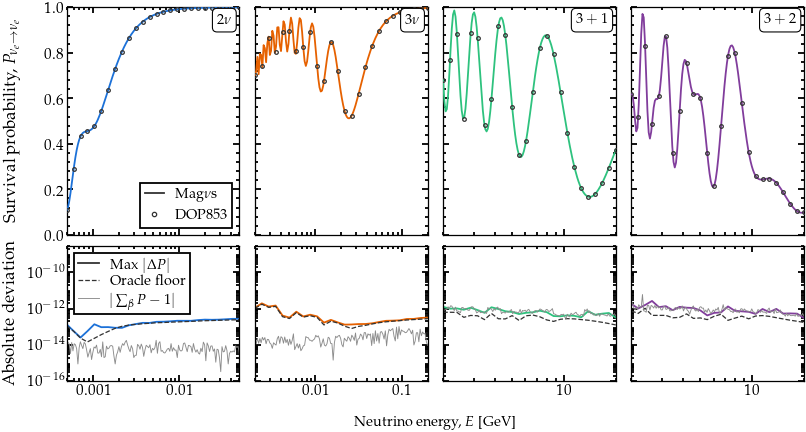

In [4]:
# The bottom row is given a larger share than the 1.0 it began with, and the
# figure a matching 0.23 in of extra height so the top row keeps its size: at the
# original proportions the residual legend sat on the curves it describes.
fig, axes = plt.subplots(2, 4, figsize=(WIDE, 3.48), sharex='col',
                         gridspec_kw=dict(height_ratios=[2.05, 1.22], hspace=0.06,
                                          wspace=0.09))
COLORS = {2: BLUE, 3: ORANGE, 4: GREEN, 5: PURPLE}
for j, d in enumerate((2, 3, 4, 5)):
    r = results[d]
    top, bot = axes[0, j], axes[1, j]
    x = r['E_plot']/gd.UNIT_GEV
    top.plot(x, r['P_plot'][:, 0, 0], color=COLORS[d], lw=1.0, zorder=3)
    top.plot(r['E_ref']/gd.UNIT_GEV, r['Pr'][:, 0, 0], ls='none', marker='o', ms=2.0,
             mfc='none', mew=0.7, color=INK, zorder=4)
    logx(top); snug(top, x); top.set_ylim(0.0, 1.0); minor_y(top, 5)
    corner(top, FLAVOR_LABEL[d], fontsize=8.0, x=0.955, y=0.975)
    bot.semilogy(r['E_ref']/gd.UNIT_GEV, np.maximum(r['resid'], 1.0e-18),
                 color=COLORS[d], lw=1.0)
    bot.semilogy(r['E_ref']/gd.UNIT_GEV, np.maximum(r['floor'], 1.0e-18), color=INK,
                 lw=0.7, ls='--')
    bot.semilogy(x, np.maximum(r['unit'], 1.0e-18), color='0.55', lw=0.5)
    logx(bot); logy(bot); snug(bot, x); bot.set_ylim(1.0e-16, 3.0e-9)
    if j:
        top.tick_params(labelleft=False)
        bot.tick_params(labelleft=False)
axes[0, 0].set_ylabel(r'Survival probability, $P_{\nu_e \to \nu_e}$')
axes[1, 0].set_ylabel(r'Absolute deviation')
axes[0, 0].plot([], [], color=INK, lw=1.0, label=r'Mag$\nu$s')
axes[0, 0].plot([], [], ls='none', marker='o', ms=2.4, mfc='none', mew=0.7, color=INK,
                label='DOP853')
axes[0, 0].legend(loc='lower right', handlelength=1.3)
axes[1, 0].plot([], [], color=INK, lw=1.0, label=r'Max $|\Delta P|$')
axes[1, 0].plot([], [], color=INK, lw=0.7, ls='--', label='Oracle floor')
axes[1, 0].plot([], [], color='0.55', lw=0.5, label=r'$|\sum_\beta P - 1|$')
leg = axes[1, 0].legend(loc='upper left', handlelength=1.4, labelspacing=0.18,
                        fontsize=8.0)
# Translucent fill, opaque border.  `framealpha` would do the first but applies the
# alpha to the patch as a whole, fading the black edge the house style asks for to
# grey; setting the face colour directly leaves the edge alone.
frame = leg.get_frame()
frame.set_alpha(None)
frame.set_facecolor((1.0, 1.0, 1.0, 0.75))
frame.set_edgecolor('black')
# Centred on the four columns rather than on the figure, which the y-axis label
# would otherwise pull left, and close to the axis it belongs to.
fig.align_labels()
box = [axes[1, j].get_position() for j in range(4)]
fig.text(0.5*(box[0].x0 + box[3].x1), box[0].y0 - 0.075,
         r'Neutrino energy, $E$ [GeV]', ha='center', va='top', fontsize=8)
save(fig, 'validation.pdf')

### Figure 1b --- how a call is answered

Seven engines can answer a request, tried in a fixed order; each declines what it cannot
serve honestly and falls through to the next.

  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/strategies.pdf


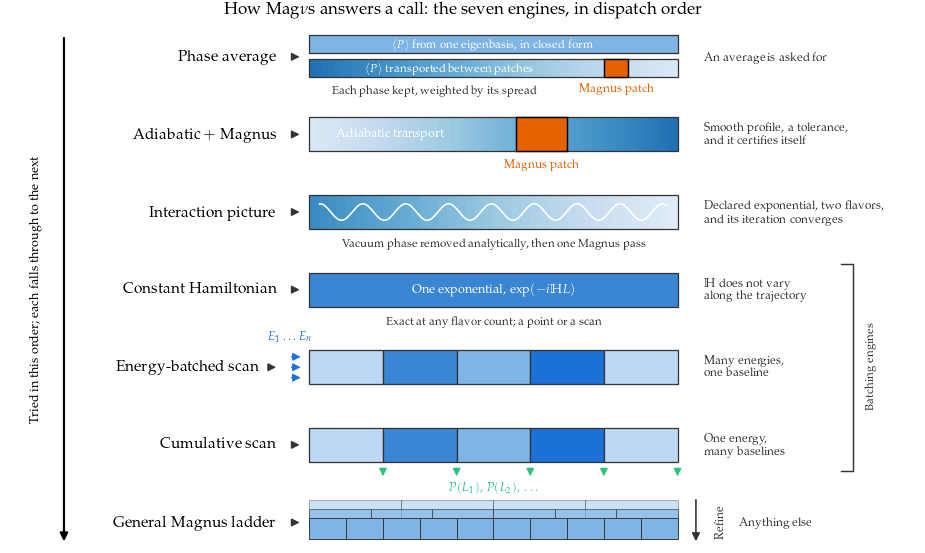

In [5]:
# ------------------------------------------- Figure 1b: the seven engines, in order
# Same idiom as the slab-composition figure of the companion paper: one bar per
# engine, shaded by density, with what each does to the trajectory drawn rather
# than named.  The order is the dispatch order of the three scenario wrappers.
SLAB = ['#eaf2fb', '#bcd8f3', '#7fb4e6', '#3a86d4', '#1c71d8']
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(WIDE, 4.3))
ax.set_xlim(0, 90); ax.set_ylim(0, 100); ax.axis('off')
X0, X1 = 30.0, 66.0                      # the bar spans the same x in every row
H = 6.2                                  # bar height
rows = [
 ('Phase average',         'An average is asked for'),
 ('Adiabatic $+$ Magnus',  'Smooth profile, a tolerance,\nand it certifies itself'),
 ('Interaction picture',   'Declared exponential, two flavors,\nand its iteration converges'),
 ('Constant Hamiltonian',  '$\\mathbb{H}$ does not vary\nalong the trajectory'),
 ('Energy-batched scan',   'Many energies,\none baseline'),
 ('Cumulative scan',       'One energy,\nmany baselines'),
 ('General Magnus ladder', 'Anything else'),
]
ys = np.linspace(87, 2, len(rows))

def bar(y, edges, shades, lw=0.7):
    for (a, b), c in zip(edges, shades):
        ax.add_patch(Rectangle((a, y), b-a, H, facecolor=c, edgecolor=INK, lw=lw, zorder=2))

for i, ((name, when), y) in enumerate(zip(rows, ys)):
    # The energy-batched row has arrows entering at its left edge, so its name needs
    # more clearance than the others.
    ax.text(X0-(5.0 if i == 4 else 3.3), y+H/2, name, ha='right', va='center',
            fontsize=8.6, color='black')
    # The ladder row carries the refine arrow just past its bar, so its condition
    # text starts further right than the others'.
    ax.text(X1+(6.0 if i == 6 else 2.6), y+H/2, when, ha='left', va='center',
            fontsize=6.6, color=INK)
    # Every engine takes the neutrino along the path -- the phase average too, which crosses
    # the same windows the hybrid patches and only tracks no phase between them.  The
    # energy-batched row already has three blue arrows entering at X0, so its black one
    # starts further left rather than hiding behind them.
    bx = X0 - (2.9 if i == 4 else 0.6)
    ax.annotate('', xy=(bx, y+H/2), xytext=(bx-1.2, y+H/2),
                arrowprops=dict(arrowstyle='-|>', color=INK, lw=0.8))
    if i == 0:
        # Two cases of one expression, Eq. (averaged_varying), stacked in the row's space.
        # Top: one eigenbasis serves the whole path and there is no crossing, so <P> comes in
        # closed form.  Drawn flat and undivided, as the constant-Hamiltonian row below is.
        # Bottom: H varies -- the eigenbases at the two ends and a Magnus patch at each
        # crossing between them.  In both, each phase is kept, weighted by its spread (the
        # phase average).
        # Taller than half a row each, using the free space under the title, with a clear
        # gap between them so they read as two cases rather than one striped bar.
        h2, gap = 3.3, 1.1
        yb = y - 0.6
        yt = yb + h2 + gap
        ax.add_patch(Rectangle((X0, yt), X1-X0, h2, facecolor=SLAB[2], edgecolor=INK,
                               lw=0.7, zorder=2))
        ax.text((X0+X1)/2, yt+h2/2, r'$\langle P\rangle$ from one eigenbasis, in closed form',
                ha='center', va='center', fontsize=6.4, color='white', zorder=5)
        n = 60; e = np.linspace(X0, X1, n+1)
        g = plt.cm.Blues(np.linspace(0.75, 0.15, n))
        for (l, r), c in zip(zip(e[:-1], e[1:]), g):
            ax.add_patch(Rectangle((l, yb), r-l, h2, facecolor=c, edgecolor='none', zorder=2))
        ax.add_patch(Rectangle((X0, yb), X1-X0, h2, fill=False, edgecolor=INK, lw=0.7, zorder=3))
        px = X0 + 0.80*(X1-X0)
        ax.add_patch(Rectangle((px, yb), 2.4, h2, facecolor=ORANGE, edgecolor='black',
                               lw=0.8, zorder=4))
        ax.text(px+1.2, yb-0.9, 'Magnus patch', ha='center', va='top',
                fontsize=6.6, color=ORANGE)
        ax.text(X0+0.38*(X1-X0), yb+h2/2, r'$\langle P\rangle$ transported between patches',
                ha='center', va='center', fontsize=6.4, color='white', zorder=5)
        # Near the middle of the bar, a little left of it, so that it clears the patch label.
        ax.text(X0+0.34*(X1-X0), yb-1.4, 'Each phase kept, weighted by its spread',
                ha='center', va='top', fontsize=6.4, color=INK)
    elif i == 1:                                 # smooth gradient, one exact patch
        n = 60; e = np.linspace(X0, X1, n+1)
        g = plt.cm.Blues(np.linspace(0.15, 0.75, n))
        bar(y, list(zip(e[:-1], e[1:])), g, lw=0.0)
        ax.add_patch(Rectangle((X0, y), X1-X0, H, fill=False, edgecolor=INK, lw=0.7, zorder=3))
        px = X0 + 0.56*(X1-X0)
        ax.add_patch(Rectangle((px, y), 5.0, H, facecolor=ORANGE, edgecolor='black',
                               lw=0.8, zorder=4))
        ax.text(px+2.5, y-1.2, 'Magnus patch', ha='center', va='top',
                fontsize=6.6, color=ORANGE)
        ax.text(X0+0.22*(X1-X0), y+H/2, 'Adiabatic transport', ha='center', va='center',
                fontsize=7.0, color='white', zorder=5)
    elif i == 2:                                 # fast phase factored out first
        n = 40; e = np.linspace(X0, X1, n+1)
        g = plt.cm.Blues(np.linspace(0.65, 0.12, n))
        bar(y, list(zip(e[:-1], e[1:])), g, lw=0.0)
        ax.add_patch(Rectangle((X0, y), X1-X0, H, fill=False, edgecolor=INK, lw=0.7, zorder=3))
        xs = np.linspace(X0+1, X1-1, 300)
        ax.plot(xs, y+H/2 + 1.5*np.sin((xs-X0)*1.5), color='white', lw=0.9, zorder=5)
        ax.text((X0+X1)/2, y-1.6, r'Vacuum phase removed analytically, then one Magnus pass',
                ha='center', va='top', fontsize=6.4, color=INK)
    elif i == 3:                                 # nothing to compose: one exponential
        # The series terminates at its first term when H does not vary, so the whole
        # path is a single exact exponential.  Drawn undivided, like the average row,
        # because there are no slabs to show -- but shaded as a propagation, which the
        # average row is not.
        bar(y, [(X0, X1)], [SLAB[3]])
        ax.text((X0+X1)/2, y+H/2, r'One exponential, $\exp(-i\mathbb{H}L)$',
                ha='center', va='center', fontsize=7.0, color='white')
        ax.text((X0+X1)/2, y-1.6, 'Exact at any flavor count; a point or a scan',
                ha='center', va='top', fontsize=6.4, color=INK)
    elif i == 4:                                 # profile once, many energies
        ed = np.linspace(X0, X1, 6)
        bar(y, list(zip(ed[:-1], ed[1:])), [SLAB[1], SLAB[3], SLAB[2], SLAB[4], SLAB[1]])
        for dy in (1.9, 0.0, -1.9):
            ax.annotate('', xy=(X0-0.5, y+H/2+dy), xytext=(X0-2.1, y+H/2+dy),
                        arrowprops=dict(arrowstyle='-|>', color=BLUE, lw=0.7))
        ax.text(X0-2.0, y+H+1.2, r'$E_1 \ldots E_n$', ha='center', va='bottom',
                fontsize=6.6, color=BLUE)
    elif i == 5:                                 # one pass, many baselines out
        ed = np.linspace(X0, X1, 6)
        bar(y, list(zip(ed[:-1], ed[1:])), [SLAB[1], SLAB[3], SLAB[2], SLAB[4], SLAB[1]])
        for xx in ed[1:]:
            ax.annotate('', xy=(xx, y-3.3), xytext=(xx, y-0.5),
                        arrowprops=dict(arrowstyle='-|>', color=GREEN, lw=0.7))
        ax.text((X0+X1)/2, y-3.6, r'$P(L_1),\, P(L_2),\, \ldots$', ha='center', va='top',
                fontsize=6.6, color=GREEN)
    else:                                        # the ladder: refine until two levels agree
        for tier, (nsl, dy, al) in enumerate([(4, 3.4, 0.40), (6, 1.7, 0.68), (10, 0.0, 1.0)]):
            ed = np.linspace(X0, X1, nsl+1)
            for a, b in zip(ed[:-1], ed[1:]):
                ax.add_patch(Rectangle((a, y+dy), b-a, H*0.62, facecolor=SLAB[2],
                                       edgecolor=INK, lw=0.5, alpha=al, zorder=2))
        # The refine arrow spans the ladder exactly, top tier to bottom, and its label starts
        # where the ladder does.  shrinkA/B are zeroed: annotate otherwise trims 2 points off
        # each end of the arrow, and it would stop short of the bars it is measured against.
        ladder_bottom, ladder_top = y, y + 3.4 + H*0.62
        refine_arrow = ax.annotate('', xy=(X1+1.8, ladder_bottom), xytext=(X1+1.8, ladder_top),
                    arrowprops=dict(arrowstyle='-|>', color=INK, lw=0.9, shrinkA=0, shrinkB=0))
        refine_bottom = ladder_bottom
        ax.text(X1+4.3, ladder_bottom, 'Refine', ha='center', va='bottom', fontsize=6.6,
                color=INK, rotation=90)


# The order they are tried in, drawn once in the margin: down the middle it crossed
# every bar and collided with the notes under rows 1, 3 and 5.
ax.annotate('', xy=(6.0, ys[-1]-1.0), xytext=(6.0, ys[0]+H+1.0),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.2))
ax.text(3.2, (ys[0]+ys[-1])/2 + H/2, 'Tried in this order; each falls through to the next',
        rotation=90, ha='center', va='center', fontsize=7.0, color='black')

# The three engines that reuse work across an array, which is the grouping Sec. 4293 of
# the paper uses: the general ladder below them computes point by point and is not one.
# Their conditions are short, so the bracket sits well left of the widest row above it.
gy0, gy1 = ys[5] - 1.6, ys[3] + H + 1.6
gx = 82.0
ax.plot([gx, gx+1.2, gx+1.2, gx], [gy0, gy0, gy1, gy1], color=INK, lw=0.8,
        solid_joinstyle='miter')
ax.text(gx + 2.8, (gy0 + gy1)/2, 'Batching engines', rotation=90,
        ha='center', va='center', fontsize=6.4, color=INK)
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)

# The title goes last, centred on what the page will show rather than on the axes.  The
# saved figure is cropped to its content, and that content is not symmetric about the axes:
# the dispatch-order note hangs off the left, the batching bracket off the right.  So the
# extent of everything else is measured first, and the title placed at its middle.
fig.canvas.draw()
# FancyArrowPatch stops a '-|>' head about a point short of the end it is given, even with
# shrinkB=0, and against the ladder's bottom edge that shows.  Measured once laid out, and the
# end moved down by exactly the shortfall.
tip = refine_arrow.arrow_patch.get_window_extent(fig.canvas.get_renderer()).y0
short = tip - ax.transData.transform((0.0, refine_bottom))[1]
end = ax.transData.transform(refine_arrow.xy)
refine_arrow.xy = tuple(ax.transData.inverted().transform((end[0], end[1] - short)))
fig.canvas.draw()
content = fig.get_tightbbox(fig.canvas.get_renderer())          # inches
x_mid = ax.transData.inverted().transform(((content.x0 + content.x1)/2*fig.dpi, 0.0))[0]
ax.text(x_mid, 98.6, r'How Mag$\nu$s answers a call: the seven engines, in dispatch order',
        ha='center', va='center', fontsize=9.4, color='black')
save(fig, 'strategies.pdf')

## Figure 1c --- how the modules fit together

  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/architecture.pdf


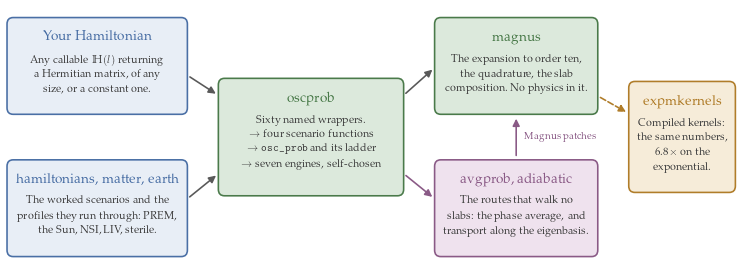

In [6]:
# ------------------------------------------- Figure 1c: the module architecture
# Same idiom, and deliberately the same style, as the architecture figure of the
# companion paper: the four colour pairs, the box geometry, and the title and body
# both set from the top of the box so that no box carries dead space at its foot.
from matplotlib.patches import FancyBboxPatch

C_IN, C_CORE, C_ACC, C_COMP = '#e8eef6', '#dce9dc', '#f6ecd9', '#efe2ee'
E_IN, E_CORE, E_ACC, E_COMP = '#4a6fa5', '#4a7a4a', '#b07d2a', '#8a5a86'

fig, axd = plt.subplots(figsize=(WIDE, WIDE*0.34))
axd.set_axis_off(); axd.set_xlim(0.0, 30.0); axd.set_ylim(0.0, 10.2)


def _abox(x, y, w, h, face, edge, title, body):
    axd.add_patch(FancyBboxPatch((x, y), w, h,
                                 boxstyle='round,pad=0.12,rounding_size=0.25',
                                 facecolor=face, edgecolor=edge, lw=0.9, zorder=2))
    axd.text(x + w/2.0, y + h - 0.42, title, ha='center', va='top', fontsize=7.6,
             color=edge, zorder=3,
             fontfamily='monospace' if title[0].islower() else None)
    if body:
        axd.text(x + w/2.0, y + h - 1.30, body, ha='center', va='top', fontsize=6.0,
                 color='0.25', zorder=3, linespacing=1.5)


def _aarr(x0, y0, x1, y1, color='0.35', ls='-'):
    axd.annotate('', xy=(x1, y1), xytext=(x0, y0), zorder=1,
                 arrowprops=dict(arrowstyle='-|>', mutation_scale=8, lw=0.9,
                                 color=color, linestyle=ls, shrinkA=2, shrinkB=2))


# Left: what goes in.  Middle: where a request is met.  Right: the three routes out.
_abox(0.3, 6.00, 7.1, 3.50, C_IN, E_IN, 'Your Hamiltonian',
      'Any callable $\\mathbb{H}(l)$ returning\na Hermitian matrix, of any\nsize, or a constant one.')
_abox(0.3, 0.50, 7.1, 3.50, C_IN, E_IN, 'hamiltonians, matter, earth',
      'The worked scenarios and the\nprofiles they run through: PREM,\nthe Sun, NSI, LIV, sterile.')
_abox(8.9, 2.85, 7.3, 4.30, C_CORE, E_CORE, 'oscprob',
      'Sixty named wrappers.\n$\\rightarrow$ four scenario functions\n'
      '$\\rightarrow$ {\\tt osc\\_prob} and its ladder\n$\\rightarrow$ seven engines, self-chosen')
_abox(17.7, 6.00, 6.4, 3.50, C_CORE, E_CORE, 'magnus',
      'The expansion to order ten,\nthe quadrature, the slab\ncomposition. No physics in it.')
_abox(17.7, 0.50, 6.4, 3.50, C_COMP, E_COMP, 'avgprob, adiabatic',
      'The routes that walk no\nslabs: the phase average, and\ntransport along the eigenbasis.')
_abox(25.6, 2.98, 4.1, 4.05, C_ACC, E_ACC, 'expmkernels',
      'Compiled kernels:\nthe same numbers,\n$6.8{\\times}$ on the\nexponential.')

_aarr(7.5, 7.4, 8.8, 6.6)
_aarr(7.5, 2.6, 8.8, 3.6)
_aarr(16.3, 6.6, 17.6, 7.7)
_aarr(16.3, 3.6, 17.6, 2.6, color=E_COMP)
_aarr(20.9, 4.15, 20.9, 5.85, color=E_COMP)
_aarr(24.2, 6.6, 25.5, 5.9, color=E_ACC, ls='--')
axd.text(21.2, 5.00, 'Magnus patches', ha='left', va='center', fontsize=5.6, color=E_COMP)
save(fig, 'architecture.pdf')

## Figure 1d --- the four layers of oscprob

A request enters at a named wrapper and descends, left to right, to the engine that answers
it: the wrapper packs its named parameters into a dictionary, a scenario function builds the
Hamiltonian, `osc_prob_energy_baseline` runs the scan over energies and baselines, and
`osc_prob` computes each point. The wrappers are a product set --- the same fourteen
environment-and-scenario names at each of four flavor counts --- so the box lists the fourteen
once under the name pattern, and $4 \times 14 = 56$ is every wrapper there is.

  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/layers.pdf


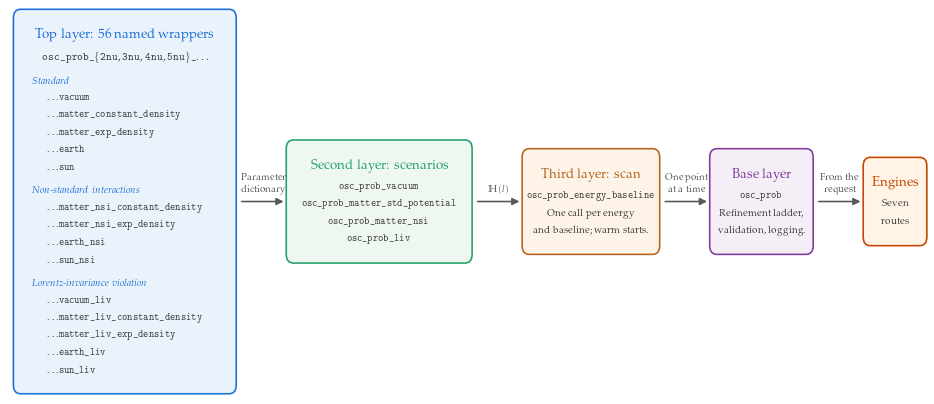

In [7]:
from matplotlib.patches import FancyBboxPatch
# ------------------------------------------------ the four layers of oscprob
# A request enters at a named wrapper and descends, left to right, to the engine that
# answers it.  The wrappers are a product set: the same fourteen environment-and-scenario
# names at each of four flavor counts, so the box lists the fourteen once under the name
# pattern, and 4 x 14 = 56 is every wrapper there is.
C_TOP, E_TOP = '#eaf2fb', '#1c71d8'
C_2ND, E_2ND = '#eef7f0', '#26a269'
C_3RD, E_3RD = '#fdf3e7', '#b5651d'
C_BASE, E_BASE = '#f4eef7', '#813d9c'
C_ENG, E_ENG = '#fff4e6', '#c64600'

fig, axd = plt.subplots(figsize=(WIDE, 3.15))
axd.set_xlim(-0.2, 32.5); axd.set_ylim(0, 11.5); axd.axis('off')
YMID = 5.75                                             # the arrows' line
# One set of vertical margins for every box, so the white space above the title and below
# the last line is the same everywhere whatever the box holds.
PAD, TITLE_DROP, LINE, LINE_H = 0.42, 0.66, 0.50, 0.30   # data units


def tt(s):
    return r'\texttt{%s}' % s.replace('_', r'\_')


def box(x, w, face, edge, title, items, size=6.0):
    """A box sized to its content.  `items` are (text, style, extra_gap_after) with style
    one of 'centre', 'head', 'name'; the box height follows from them."""
    body = TITLE_DROP + sum(LINE + gap for _, _, gap in items) - LINE + LINE_H
    h = PAD + body + PAD
    y0 = YMID - h/2.0
    axd.add_patch(FancyBboxPatch((x, y0), w, h, boxstyle='round,pad=0.12,rounding_size=0.25',
                                 facecolor=face, edgecolor=edge, lw=0.9, zorder=2))
    top = y0 + h - PAD
    axd.text(x + w/2.0, top, title, ha='center', va='top', fontsize=7.4, color=edge,
             zorder=3)
    y = top - TITLE_DROP
    for text, style, gap in items:
        if style == 'centre':
            axd.text(x + w/2.0, y, text, ha='center', va='top', fontsize=size, color='0.25',
                     zorder=3)
        elif style == 'head':
            axd.text(x + 0.55, y, r'\emph{%s}' % text, ha='left', va='top', fontsize=5.6,
                     color=edge, zorder=3)
        else:
            axd.text(x + 1.05, y, r'$\ldots$' + tt(text), ha='left', va='top', fontsize=5.6,
                     color='0.25', zorder=3)
        y -= LINE + gap


def arrow(x0, x1, label):
    axd.annotate('', xy=(x1, YMID), xytext=(x0, YMID), zorder=1,
                 arrowprops=dict(arrowstyle='-|>', mutation_scale=8, lw=0.9, color='0.35',
                                 shrinkA=1, shrinkB=1))
    axd.text(0.5*(x0 + x1), YMID + 0.22, label, ha='center', va='bottom', fontsize=5.4,
             color='0.35', zorder=3, linespacing=1.25)


pattern = (tt('osc_prob_') + r'$\{$' + tt('2nu') + ', ' + tt('3nu') + ', ' + tt('4nu') + ', '
           + tt('5nu') + r'$\}$' + tt('_') + r'$\ldots$')
STD = ['vacuum', 'matter_constant_density', 'matter_exp_density', 'earth', 'sun']
NSI = ['matter_nsi_constant_density', 'matter_nsi_exp_density', 'earth_nsi', 'sun_nsi']
LIV = ['vacuum_liv', 'matter_liv_constant_density', 'matter_liv_exp_density', 'earth_liv',
       'sun_liv']
top_items = [(pattern, 'centre', 0.20), ('Standard', 'head', 0.0)]
top_items += [(n, 'name', 0.0) for n in STD[:-1]] + [(STD[-1], 'name', 0.16)]
top_items += [('Non-standard interactions', 'head', 0.0)]
top_items += [(n, 'name', 0.0) for n in NSI[:-1]] + [(NSI[-1], 'name', 0.16)]
top_items += [('Lorentz-invariance violation', 'head', 0.0)]
top_items += [(n, 'name', 0.0) for n in LIV]
box(0.3, 7.6, C_TOP, E_TOP, 'Top layer: 56 named wrappers', top_items)

arrow(8.15, 9.75, 'Parameter\ndictionary')
box(9.9, 6.3, C_2ND, E_2ND, 'Second layer: scenarios',
    [(tt('osc_prob_vacuum'), 'centre', 0.0),
     (tt('osc_prob_matter_std_potential'), 'centre', 0.0),
     (tt('osc_prob_matter_nsi'), 'centre', 0.0),
     (tt('osc_prob_liv'), 'centre', 0.0)], size=5.6)
arrow(16.45, 18.05, '$\\mathbb{H}(l)$')
box(18.2, 4.6, C_3RD, E_3RD, 'Third layer: scan',
    [(tt('osc_prob_energy_baseline'), 'centre', 0.0),
     ('One call per energy', 'centre', 0.0),
     ('and baseline; warm starts.', 'centre', 0.0)], size=5.6)
arrow(23.05, 24.65, 'One point\nat a time')
box(24.8, 3.4, C_BASE, E_BASE, 'Base layer',
    [(tt('osc_prob'), 'centre', 0.0),
     ('Refinement ladder,', 'centre', 0.0),
     ('validation, logging.', 'centre', 0.0)], size=5.6)
arrow(28.45, 30.05, 'From the\nrequest')
box(30.2, 2.0, C_ENG, E_ENG, 'Engines', [('Seven', 'centre', 0.0), ('routes', 'centre', 0.0)],
    size=5.6)

fig.tight_layout(pad=0.3)
save(fig, 'layers.pdf')

## Figure 2 --- slab width follows the profile, not the phase

Three measurements: one slab against a constant Hamiltonian over six decades of $\Phi$;
the cost of a *delivered* accuracy as $\Phi$ grows; and what the truncation order buys at
fixed $\Phi$.

**All three panels are measured against the same reference**: a midpoint slab product
carried in `mpmath` and Richardson-extrapolated three times, with its own convergence
reported so that no panel has to be taken on trust. `DOP853` appears in the center panel
as the code being timed, never as a reference. For a constant Hamiltonian the
extrapolation collapses to a single exponential, which the left panel checks rather than
assumes.

In [8]:
# ============================================================ Figure 2
D2 = 3
RHO0_2, LS_KM_2, RHO_CONST = 100.0, 300.0, 3.0
rho2 = matter.exp_density_profile(RHO0_2*gd.UNIT_G_PER_CM3, LS_KM_2*gd.UNIT_KM)
VCC2 = matter.vcc_func_from_rho_func(rho2, L0=0.0)
L2 = 3000.0*gd.UNIT_KM
E_FIX = 0.2*gd.UNIT_GEV
Hf2 = make_H_func(D2, E_FIX, VCC2)

# The six configurations both lower panels carry: what an order buys, beside what it costs.
# Orders two, four and six run on the Gauss-Legendre collocation schemes, which is what
# the package does by default.  Above eight no such scheme exists, so the only route is
# cumulative quadrature; order six is run on it too, as a control, because the change in
# convergence rate belongs to the quadrature path and not to the higher orders.
SERIES = [('gl', 2), ('gl', 4), ('gl', 6), ('simpson', 6), ('simpson', 8), ('simpson', 10)]

MP_DPS_FIX, MP_NS_FIX = 50, (4096, 8192, 16384, 32768)
MP_DPS_SCAN, MP_SCAN_TARGET = 30, 1.0e-11
def slab_product(H_func, L, n_slabs):
    """The piecewise-constant operator, H frozen at each slab midpoint.

    The algorithm a closed-form slab code runs, written out here so that this
    comparison needs no second package installed.  The midpoint rather than the edge
    is what makes it second order: the linear part of the error cancels between a
    slab's two halves.
    """
    edges = np.linspace(0.0, L, n_slabs + 1)
    Hs = H_func(0.5*(edges[:-1] + edges[1:]))
    h = edges[1] - edges[0]
    U = np.eye(Hs.shape[-1], dtype=complex)
    for k in range(n_slabs):
        U = expm(-1j*Hs[k]*h) @ U
    return prob_from_U(U)


def chunked_prob(H_func, L, n_slabs, order, integration_method='gl', n_tpts=65,
                 max_cells=20000):
    """The package's slab chain, composed a batch at a time.

    Orders above six have no Gauss-Legendre scheme and run on cumulative quadrature,
    which carries ``n_tpts`` samples per slab.  At order ten the recursion holds of
    order a hundred intermediates of shape ``(n_slabs, n_tpts, d, d)``, about 6 MB per
    slab, and exhausts memory past roughly a thousand slabs.  Composition is a product
    of independent per-slab operators, so the chain can be built in chunks and
    multiplied in, which holds memory flat in ``n_slabs``.  The cell below checks this
    against ``osc_prob`` at every order.
    """
    edges = np.linspace(0.0, L, n_slabs + 1)
    nodes = (magnus.gl_nodes(order) if integration_method == 'gl'
             else np.linspace(0.0, 1.0, n_tpts))
    m = len(nodes)
    d = np.asarray(H_func(0.0)).shape[-1]
    chunk = max(1, min(n_slabs, int(max_cells//m)))
    U = np.eye(d, dtype=complex)
    for a in range(0, n_slabs, chunk):
        b = min(a + chunk, n_slabs)
        lo, hi = edges[a:b], edges[a + 1:b + 1]
        t = lo[:, None] + (hi - lo)[:, None]*nodes[None, :]
        At = -1j*np.asarray(H_func(t.ravel()), dtype=complex).reshape(b - a, m, d, d)
        Us = quiet(magnus.evolution_operators_from_samples, At, hi - lo, order=order,
                   integration_method=integration_method, validate_input=False)
        for k in range(b - a):
            U = Us[k] @ U
    return prob_from_U(U)


def mp_midpoint(H_func, L, n, dps):
    r"""A midpoint slab product carried at ``dps`` decimal digits, in mpmath.

    The panels below have to resolve deviations near $10^{-15}$, which no
    double-precision reference can certify.  A {\tt DOP853} solution moves by
    $2 \cdot 10^{-13}$ between ${\tt rtol} = 10^{-13}$ and $10^{-14}$, and a
    double-precision {\tt expm} of a constant Hamiltonian is itself wrong by
    $2 \cdot 10^{-10}$ at the largest phase the left panel reaches.  The probabilities
    come back as {\tt mpf} rather than as {\tt float}, since rounding them to double at
    this point would put a floor of $10^{-16}$ under everything built from them.
    """
    mp.mp.dps = dps
    edges = np.linspace(0.0, L, n + 1)
    Hs = H_func(0.5*(edges[:-1] + edges[1:]))
    h = mp.mpf(float(edges[1] - edges[0]))
    d = Hs.shape[-1]
    U = mp.eye(d)
    for k in range(n):
        M = mp.matrix([[mp.mpc(complex(Hs[k][i, j])) for j in range(d)] for i in range(d)])
        U = mp.expm(-1j*M*h)*U
    P = np.array([[mp.fabs(U[i, j])**2 for j in range(d)] for i in range(d)], dtype=object)
    return P.T


def richardson3(P, ns):
    r"""Remove $N^{-2}$, $N^{-4}$ and $N^{-6}$ in turn, staying in mpmath throughout.

    The midpoint product's error runs in even powers of the slab width, so
    $[4P(2N) - P(N)]/3$ removes the leading term, $[16Q(2N) - Q(N)]/15$ the next and
    $[64R(2N) - R(N)]/63$ the one after.  An earlier version returned {\tt float}
    probabilities from each product and combined them in double precision; it converged
    to $1.1 \cdot 10^{-16}$, which is double-precision epsilon and not the
    extrapolation.  Returns the reference together with its own self-convergence, so no
    panel has to take the reference on trust.
    """
    Q = {n: (4*P[2*n] - P[n])/3 for n in ns[:-1]}
    R = {n: (16*Q[2*n] - Q[n])/15 for n in ns[:-2]}
    T = (64*R[ns[1]] - R[ns[0]])/63
    return T, float(max(abs(x) for x in (T - R[ns[1]]).ravel()))


def mp_reference(H_func, L, base, dps=MP_DPS_SCAN, target=MP_SCAN_TARGET, cap=2048):
    r"""Triple-Richardson reference, with the base slab count raised until it converges.

    The base a trajectory needs grows with the accumulated phase: nine hundred radians
    needs $512$ where eight radians needs $64$.  Doubling until the self-convergence
    clears ``target`` finds it rather than assuming it.
    """
    while True:
        ns = (base, 2*base, 4*base, 8*base)
        T, sc = richardson3({n: mp_midpoint(H_func, L, n, dps) for n in ns}, ns)
        if sc < target or base >= cap:
            return T, sc, base
        base *= 2




# One reference machinery serves all three panels.  For a constant Hamiltonian every
# midpoint slab product is the same exponential whatever N, so the triple Richardson of
# them collapses to that one exponential; the print below measures the collapse rather
# than assuming it.  This matters: the double-precision expm this panel used to be
# measured against is itself wrong by 2e-10 at the largest phase here, so the old curve
# was as much the reference's round-off as the method's.
VCC_CONST = float(matter.vcc_func_from_rho_func(RHO_CONST*gd.UNIT_G_PER_CM3))
E_CONST = np.logspace(np.log10(50.0), np.log10(5.0e-6), 60)*gd.UNIT_GEV
PROJ2 = np.asarray(matter.matter_potential_projector(D2), dtype=complex)
HVAC2 = np.asarray(vacuum_hamiltonian(D2), dtype=complex)


def const_H_func(Hc):
    def f(l):
        return np.broadcast_to(Hc, np.shape(l) + Hc.shape).copy()
    return f


phase_a, err_a, collapse = [], [], []
for E in E_CONST:
    Hc = HVAC2/E + VCC_CONST*PROJ2
    w = np.linalg.eigvalsh(Hc)
    phase_a.append(float((w[-1] - w[0])*L2))
    Hcf = const_H_func(Hc)
    T, sc, _ = mp_reference(Hcf, L2, 4, dps=MP_DPS_FIX, target=1.0e-40)
    collapse.append(float(max(abs(x) for x in (T - mp_midpoint(Hcf, L2, 1, MP_DPS_FIX)).ravel())))
    P1 = np.asarray(quiet(oscprob.osc_prob, lambda l, H=Hc: H, 0.0, L2, n_slabs=1,
                          rtol=None, atol=None))
    err_a.append(max(float(max(abs(x) for x in (P1 - T).ravel())), 1.0e-18))
phase_a, err_a = np.array(phase_a), np.array(err_a)
print('left panel: %d points, phase %.1e to %.1e rad' % (len(phase_a), phase_a.min(), phase_a.max()))
print('  triple Richardson vs one exponential, constant H: %.1e' % max(collapse))
print('  deviation of one slab: %.1e to %.1e, growing as Phi^%.2f'
      % (err_a.min(), err_a.max(),
         np.polyfit(np.log(phase_a[phase_a > 1e2]), np.log(err_a[phase_a > 1e2]), 1)[0]))
print('  for comparison, Phi*eps at the largest phase is %.1e' % (phase_a.max()*2.220446e-16))

left panel: 60 points, phase 1.7e+00 to 3.8e+06 rad
  triple Richardson vs one exponential, constant H: 6.1e-50
  deviation of one slab: 1.3e-16 to 6.2e-10, growing as Phi^0.98
  for comparison, Phi*eps at the largest phase is 8.5e-10


### The center panel --- cost at an accuracy each code actually delivers

In [9]:
# --------------------------- Figure 2, cost panel: price at one fixed, tight tolerance
# Every configuration is run at one tolerance, fixed before the sweep starts and never
# retuned -- the solver included, so that nothing is asked for less than anything else.
# Searching per energy for the cheapest setting that just clears an accuracy target was
# what made this panel jagged: the ladders are discrete, so neighbouring energies landed
# on different rungs and the cost jumped between them for no reason a reader could see.
# It is also not how the code is used.  A tolerance is chosen once and the energies are
# swept under it, so that is what the panel measures.
#
# A tolerance is a request, not a guarantee, so what each configuration DELIVERS at it is
# measured rather than assumed, and the spread is reported with the figure.
RTOL_FIXED = 1.0e-8
ENERGIES2 = np.logspace(np.log10(20.0), np.log10(0.02), 41)


# Order two converges as N^-2, so it refines to 106204 slabs at the highest phase swept
# here -- five times the 20000 the Gauss-Legendre path caps at by default, which would
# have truncated it silently.  The ceiling is raised for every Gauss-Legendre
# configuration rather than for order two alone, so that none of them is capped where the
# others are not, and the cost each is charged is the cost of the work it actually did.
GL_SLAB_CEILING = 400000


def magnus_call(Hf, order, meth, n_tpts):
    kw = dict(magnus_exp_order=order, integration_method=meth)
    if meth == 'gl':
        kw.update(max_n_slabs=GL_SLAB_CEILING, max_num_loops=80)
    elif n_tpts is not None:
        kw.update(n_tpts_per_slab=n_tpts, min_n_tpts_per_slab=n_tpts,
                  max_n_tpts_per_slab=n_tpts)
    return lambda rt: np.asarray(quiet(oscprob.osc_prob, Hf, 0.0, L2, rtol=rt,
                                       atol=rt*1e-2, **kw))


def dop853_call(Hf):
    return lambda rt: ode_reference(Hf, L2, D2, rtol=rt, atol=rt*1e-2)


# One entry per curve.  The panel carries the same six configurations as the panel beside
# it, so that what an order costs can be read against what it buys, together with the
# solver they are all timed against.
CODES = [('dop853', 'Runge-Kutta order 8 (DOP853)', INK, '-', None, None)]
for _meth, _order in SERIES:
    CODES.append(('%s%d' % (_meth, _order),
                  '%d, %s' % (_order, 'GL' if _meth == 'gl' else 'Simpson'),
                  ORDER_COLOR[_order], '-' if _meth == 'gl' else '--', _meth, _order))


def fixed_setting(name, meth):
    """The single setting this configuration is run at, at every energy.

    A tolerance and nothing else.  Pinning the samples per slab for the cumulative-
    quadrature configurations would hold their delivered accuracies closer together, but
    it is a setting no caller types: the package refines that knob from the tolerance
    along with the slab count, and whatever it costs to do so is part of what the call
    costs.  The panel beside this one pins it, on purpose --- there the slab count is the
    variable under study, so the quadrature has to be held out of the way.
    """
    return {'rtol': RTOL_FIXED}


def call_for(name, meth, order, Hf, setting):
    return (dop853_call(Hf) if name == 'dop853'
            else magnus_call(Hf, order, meth, setting.get('n_tpts')))


def delivered(call, rt, T):
    return float(max(abs(x) for x in (np.asarray(call(rt)) - T).ravel()))


def measure_once(name, meth, order, Hf, rt, T):
    """One call, read twice: what it delivers, and what its ladder settled on.

    Asking those separately would run the whole configuration twice at identical settings
    --- order ten unpinned is not cheap enough to pay for that.
    """
    if name == 'dop853':
        P = np.asarray(dop853_call(Hf)(rt))
        return float(max(abs(x) for x in (P - T).ravel())), {}
    info = {}
    kw = dict(magnus_exp_order=order, integration_method=meth, convergence_info=info)
    if meth == 'gl':
        kw.update(max_n_slabs=GL_SLAB_CEILING, max_num_loops=80)
    P = np.asarray(quiet(oscprob.osc_prob, Hf, 0.0, L2, rtol=rt, atol=rt*1e-2, **kw))
    return (float(max(abs(x) for x in (P - T).ravel())),
            {k: int(info[k]) for k in ('n_slabs', 'n_tpts_per_slab') if k in info})


def scan_setup():
    """Reference and tuned setting at each energy, computed once and read from disk after.

    Five minutes of mpmath and a two-knob search that runs order ten at its tightest
    settings are worth spending once rather than on every rebuild.  Both are properties of
    the configuration and not of the machine, so both are cached; only the timings below
    have to be measured live.  The cached settings are re-verified rather than trusted ---
    one call per configuration per energy --- so a change in the package that moved them
    cannot pass silently.
    """
    key = fingerprint(profile_samples(VCC2, L2), float(L2), D2, MP_DPS_SCAN, MP_SCAN_TARGET,
                      [c[0] for c in CODES],
                      [float(e) for e in ENERGIES2], RTOL_FIXED, 'fixed-tolerance')
    blob = json.loads(MP_CACHE.read_text()) if MP_CACHE.exists() else {}
    cached = blob.get('scan', {})
    # This section keys itself rather than going through `cached()`, so it needs the same
    # restamp: an entry written under the exact-bits hash is recognised by that hash and
    # relabelled with the quantized one.  Matching the legacy hash proves the
    # configuration is the one the entry was computed for, so nothing is recomputed.
    if (cached and cached.get('fingerprint') != key
            and cached.get('fingerprint') == legacy_fingerprint(
                profile_samples(VCC2, L2), float(L2), D2, MP_DPS_SCAN, MP_SCAN_TARGET,
                [c[0] for c in CODES],
                [float(e) for e in ENERGIES2], RTOL_FIXED, 'fixed-tolerance')):
        print('  scan restamped %s -> %s, same configuration under the quantized hash'
              % (cached['fingerprint'][:12], key[:12]))
        cached = dict(cached, fingerprint=key)
        blob['scan'] = cached
        write_cache(blob)
    entries = cached.get('entries') if cached.get('fingerprint') == key else None
    if entries is not None:
        mp.mp.dps = MP_DPS_SCAN
        Ts = [np.array([[mp.mpf(x) for x in row] for row in e['P']], dtype=object)
              for e in entries]
        # Spot-checked rather than fully re-run: the fingerprint already covers the
        # configuration, so this is here to catch a change inside the package that moved
        # the answers under an unchanged configuration.  Three energies at the ends and
        # the middle of the sweep do that; forty-one would cost minutes on every
        # regeneration to re-derive what the fingerprint already settled.
        # Once per package version, not once per regeneration.  The fingerprint already
        # covers the configuration; what it cannot see is a change inside the package
        # that moves the answers under a configuration that did not move.  Tying the
        # check to the version catches exactly that, and costs nothing on the format
        # edits that make up most rebuilds.  A cache written before this field existed
        # is adopted rather than re-probed: the code that wrote it was this code.
        seen_version = cached.get('magnus_version')
        if seen_version == MAGNUS_VERSION or seen_version is None:
            if seen_version is None:
                blob['scan'] = dict(cached, magnus_version=MAGNUS_VERSION)
                write_cache(blob)
            print('  references and delivered accuracies read from %s, configuration %s'
                  % (MP_CACHE.name, key[:12]))
            return Ts, entries
        print('  package moved from %s to %s: spot-checking the stored accuracies'
              % (seen_version, MAGNUS_VERSION))
        probe = sorted({0, len(entries)//2, len(entries) - 1})
        stale = []
        for i in probe:
            e, T = entries[i], Ts[i]
            Hf = make_H_func(D2, e['E']*gd.UNIT_GEV, VCC2)
            for name, _, _, _, meth, order in CODES:
                st = e['setting'][name]
                now = delivered(call_for(name, meth, order, Hf, st), st['rtol'], T)
                if not (0.5 <= now/max(e['acc'][name], 1.0e-18) <= 2.0):
                    stale.append((e['E'], name, e['acc'][name], now))
        if not stale:
            blob['scan'] = dict(cached, magnus_version=MAGNUS_VERSION)
            write_cache(blob)
            print('  stored accuracies still hold under %s, re-verified at %d energies'
                  % (MAGNUS_VERSION, len(probe)))
            return Ts, entries
        print('  the package now delivers differently at %d spot checks '
              '(e.g. %s at %.3f GeV: %.1e stored, %.1e now): recomputing'
              % (len(stale), stale[0][1], stale[0][0], stale[0][2], stale[0][3]))
    else:
        cache_miss('scan', key)
    print('  energy scan: configuration moved, recomputing')
    t0 = time.perf_counter()
    Ts, entries = [], []
    for Egev in ENERGIES2:
        Hf = make_H_func(D2, Egev*gd.UNIT_GEV, VCC2)
        T, sc, base = mp_reference(Hf, L2, 32)
        setting = {name: fixed_setting(name, meth)
                   for name, _, _, _, meth, _ in CODES}
        got = {name: measure_once(name, meth, order, Hf, setting[name]['rtol'], T)
               for name, _, _, _, meth, order in CODES}
        acc = {k: v[0] for k, v in got.items()}
        chose = {k: v[1] for k, v in got.items()}
        Ts.append(T)
        entries.append(dict(E=float(Egev), phase=accumulated_phase(Hf, L2), base=int(base),
                            self_conv=float(sc), setting=setting, acc=acc, chose=chose,
                            P=[[mp.nstr(x, MP_DPS_SCAN - 5) for x in row] for row in T]))
        print('    %6.3f GeV done, worst delivered %.1e (%.0f s elapsed)'
              % (Egev, max(acc.values()), time.perf_counter() - t0), flush=True)
    print('  %d references in %.0f s, worst self-convergence %.1e'
          % (len(Ts), time.perf_counter() - t0, max(e['self_conv'] for e in entries)))
    blob['scan'] = dict(dps=MP_DPS_SCAN, target=MP_SCAN_TARGET, rtol=RTOL_FIXED,
                        fingerprint=key, entries=entries)
    write_cache(blob)
    return Ts, entries


REFS2, REF_INFO2 = scan_setup()
print('at rtol = %.0e, over %d energies:' % (RTOL_FIXED, len(REF_INFO2)))
for _n, _lab, _, _, _, _ in CODES:
    _a = [e['acc'][_n] for e in REF_INFO2]
    _c = [e.get('chose', {}).get(_n, {}) for e in REF_INFO2]
    _ns = [d['n_slabs'] for d in _c if 'n_slabs' in d]
    _nt = [d['n_tpts_per_slab'] for d in _c if 'n_tpts_per_slab' in d]
    print('  %-30s delivered %.1e to %.1e%s%s'
          % (_lab, min(_a), max(_a),
             '' if not _ns else ',  %d-%d slabs' % (min(_ns), max(_ns)),
             '' if not _nt else ',  %d-%d samples/slab' % (min(_nt), max(_nt))))


def best_of(fn, k=5):
    out = []
    for _ in range(k):
        t0 = time.perf_counter()
        fn()
        out.append(time.perf_counter() - t0)
    return min(out)


# A fixed workload interleaved through the sweep, so machine drift is visible rather than
# absorbed into the curves.
H_CTRL = make_H_func(D2, 1.0*gd.UNIT_GEV, VCC2)
_CTRL0 = []


def control_baseline():
    """The control's first value, measured on demand.

    At cell scope this ran a warm-up and five timed repeats on every regeneration of the
    notebook, including the ones that only moved a label.  It is an input to the timings
    and to nothing else, so it belongs behind the same cache they do.
    """
    if not _CTRL0:
        quiet(oscprob.osc_prob, H_CTRL, 0.0, L2, rtol=1e-8, atol=1e-10)  # warm numba
        _CTRL0.append(best_of(lambda: quiet(oscprob.osc_prob, H_CTRL, 0.0, L2,
                                            rtol=1e-8, atol=1e-10)))
    return _CTRL0[0]

def measure_timings():
    """Time each configuration at its tuned setting, once, and read from disk after.

    Timing is the only part of this figure that is a property of the machine rather than
    of the configuration, which is the argument for measuring it live.  It is also minutes
    of work on every rebuild, and the notebooks are regenerated in continuous integration,
    where minutes of stopwatch tell nobody anything.  So it is cached like everything else,
    keyed on the configuration alone: change an energy, a code, a tolerance target or a
    tuned setting and it is re-measured; change nothing and the stored numbers stand.

    The machine and the date are stored beside the numbers, because a timing that does not
    say where it came from cannot be checked.  Set MAGNUS_PAPER_RETIME=1 to force a fresh
    measurement without changing the configuration -- which is what to do after moving the
    paper to another machine.
    """
    key = fingerprint(profile_samples(VCC2, L2), float(L2), D2, RTOL_FIXED, [c[0] for c in CODES],
                      [float(e['E']) for e in REF_INFO2],
                      [repr(e['setting']) for e in REF_INFO2])
    blob = json.loads(MP_CACHE.read_text()) if MP_CACHE.exists() else {}
    restamp(blob, 'timings', key, profile_samples(VCC2, L2), float(L2), D2, RTOL_FIXED, [c[0] for c in CODES], [float(e['E']) for e in REF_INFO2], [repr(e['setting']) for e in REF_INFO2])
    stored = blob.get('timings', {})
    if stored.get('fingerprint') == key and not os.environ.get('MAGNUS_PAPER_RETIME'):
        print('  timings read from %s, unchanged configuration %s, measured on %s'
              % (MP_CACHE.name, key[:12], stored.get('machine', 'an unrecorded machine')))
        return stored['rows']
    cache_miss('timings', key)
    print('  timings: configuration moved, re-measuring')
    out = []
    for e in REF_INFO2:
        Hf = make_H_func(D2, e['E']*gd.UNIT_GEV, VCC2)
        # The control is measured beside the point, not once at the start, and divided
        # out.  A sweep of forty-one energies takes long enough that the machine drifts
        # under it, and drift that is not divided out is read off the panel as structure.
        ctrl = best_of(lambda: quiet(oscprob.osc_prob, H_CTRL, 0.0, L2,
                                     rtol=1e-8, atol=1e-10), 5)
        drift = ctrl/control_baseline()
        t = {}
        for name, _, _, _, meth, order in CODES:
            st = e['setting'][name]
            call, rt = call_for(name, meth, order, Hf, st), st['rtol']
            t[name] = best_of(lambda c=call, x=rt: c(x), 5)/drift
        out.append(dict(phase=e['phase'], E=e['E'], t=t, acc=e['acc'], ctrl=drift))
    blob['timings'] = dict(fingerprint=key, rows=out,
                           machine=platform.node() + ', ' + platform.processor(),
                           measured=time.strftime('%Y-%m-%d'))
    write_cache(blob)
    return out


rows = measure_timings()
ph = np.array([r['phase'] for r in rows])
times = {name: np.array([r['t'][name] for r in rows]) for name, _, _, _, _, _ in CODES}
print('cost panel: %d points, phase %.1f to %.0f rad' % (len(rows), ph.min(), ph.max()))
for name, lab, _, _, _, _ in CODES:
    tt = times[name]
    print('  %-28s phase^%5.2f  %7.2f ms to %8.1f ms   worst delivered %.1e'
          % (lab, np.polyfit(np.log(ph), np.log(tt), 1)[0], 1e3*tt[0], 1e3*tt[-1],
             max(r['acc'][name] for r in rows)))
ctrl = np.array([r['ctrl'] for r in rows])
print('  interleaved control held between %.2f and %.2f of its first value'
      % (ctrl.min(), ctrl.max()))

  references and delivered accuracies read from paper_figure_cache.json, configuration 611330b7b7bd
at rtol = 1e-08, over 41 energies:
  Runge-Kutta order 8 (DOP853)   delivered 1.1e-09 to 2.4e-07
  2, GL                          delivered 1.5e-10 to 2.6e-09,  6216-106204 slabs,  2-2 samples/slab
  4, GL                          delivered 1.9e-11 to 7.5e-10,  243-3848 slabs,  2-2 samples/slab
  6, GL                          delivered 3.2e-12 to 3.0e-10,  108-1710 slabs,  2-2 samples/slab
  6, Simpson                     delivered 1.8e-12 to 1.2e-10,  72-1228 slabs,  94-500 samples/slab
  8, Simpson                     delivered 2.5e-13 to 4.9e-11,  48-819 slabs,  63-500 samples/slab
  10, Simpson                    delivered 8.4e-14 to 1.5e-11,  32-819 slabs,  42-500 samples/slab


  timings read from paper_figure_cache.json, unchanged configuration 1290da4b0a96, measured on laptop-6, x86_64
cost panel: 41 points, phase 6.2 to 952 rad
  Runge-Kutta order 8 (DOP853) phase^ 0.77     5.29 ms to    266.4 ms   worst delivered 2.4e-07
  2, GL                        phase^ 0.29    12.68 ms to     66.3 ms   worst delivered 2.6e-09
  4, GL                        phase^ 0.23     2.82 ms to     13.0 ms   worst delivered 7.5e-10
  6, GL                        phase^ 0.21     2.69 ms to     11.9 ms   worst delivered 3.0e-10
  6, Simpson                   phase^ 0.91    61.71 ms to  13178.5 ms   worst delivered 1.2e-10
  8, Simpson                   phase^ 0.95   100.70 ms to  23621.4 ms   worst delivered 4.9e-11
  10, Simpson                  phase^ 0.95   314.04 ms to  64414.5 ms   worst delivered 1.5e-11
  interleaved control held between 0.97 and 1.14 of its first value


### The right panel --- what the truncation order buys

In [10]:
# ------------------------ Figure 2, right panel: what the truncation order buys
def fixed_reference():
    """The fixed-phase reference: fifty digits, Richardson three times, cached.

    Two and a half minutes of mpmath is not worth paying on every rebuild of the figure.
    """
    key = fingerprint(np.asarray(Hf2(np.linspace(0.0, L2, 9))).view(float), float(L2), MP_DPS_FIX, MP_NS_FIX)
    blob = json.loads(MP_CACHE.read_text()) if MP_CACHE.exists() else {}
    restamp(blob, 'fixed', key, np.asarray(Hf2(np.linspace(0.0, L2, 9))).view(float), float(L2), MP_DPS_FIX, MP_NS_FIX)
    if blob.get('fixed', {}).get('fingerprint') == key:
        mp.mp.dps = MP_DPS_FIX
        print('  fixed-phase reference read from %s, unchanged configuration %s'
              % (MP_CACHE.name, key[:12]))
        P = {int(n): np.array([[mp.mpf(x) for x in row] for row in m], dtype=object)
             for n, m in blob['fixed']['products'].items()}
    else:
        print('  fixed-phase reference: configuration moved, recomputing')
        t0 = time.perf_counter()
        P = {n: mp_midpoint(Hf2, L2, n, MP_DPS_FIX) for n in MP_NS_FIX}
        print('  %d-digit slab products at N = %s in %.0f s'
              % (MP_DPS_FIX, ', '.join(str(n) for n in MP_NS_FIX), time.perf_counter() - t0))
        blob['fixed'] = dict(dps=MP_DPS_FIX, n_slabs=list(MP_NS_FIX), fingerprint=key,
                             products={str(n): [[mp.nstr(x, MP_DPS_FIX + 5) for x in row]
                                                for row in P[n]] for n in MP_NS_FIX})
        write_cache(blob)
    return richardson3(P, MP_NS_FIX)


P_TRUE, REF_FLOOR = fixed_reference()
print('  the reference and the next-coarser extrapolation of it differ by %.1e' % REF_FLOOR)

# The chunked composition has to BE the package's answer, not merely close to it.
for order, meth in ((2, 'gl'), (6, 'gl'), (8, 'simpson'), (10, 'simpson')):
    a = np.asarray(quiet(oscprob.osc_prob, Hf2, 0.0, L2, n_slabs=32, magnus_exp_order=order,
                         integration_method=meth, n_tpts_per_slab=65, rtol=None, atol=None))
    print('  chunked composition vs osc_prob, order %2d on %-8s: %.1e'
          % (order, meth, np.max(np.abs(a - chunked_prob(Hf2, L2, 32, order, meth)))))

# Half-octave steps, so the curves read as curves rather than as line segments.
NS = np.array(sorted(set(int(round(2**(k/2.0))) for k in range(2, 29))))
M_HI = 65
# Orders two, four and six on the Gauss-Legendre collocation schemes, which is what
# the package does by default.  Above eight no such scheme exists, so the only route is
# cumulative quadrature; order six is run on it too, as a control, because the change in
# convergence rate belongs to the quadrature path and not to the higher orders.


def order_curves():
    """The six curves, computed once and read from disk after.

    Order ten over twenty-seven slab counts out to N = 16384 is twenty minutes of
    cumulative quadrature.  The curves are exact functions of the configuration, so they
    cache exactly as the reference does.
    """
    key = fingerprint(np.asarray(Hf2(np.linspace(0.0, L2, 9))).view(float), float(L2), MP_DPS_FIX, MP_NS_FIX, [int(n) for n in NS], M_HI,
                      [list(x) for x in SERIES])
    blob = json.loads(MP_CACHE.read_text()) if MP_CACHE.exists() else {}
    restamp(blob, 'orders', key, np.asarray(Hf2(np.linspace(0.0, L2, 9))).view(float), float(L2), MP_DPS_FIX, MP_NS_FIX, [int(n) for n in NS], M_HI, [list(x) for x in SERIES])
    if blob.get('orders', {}).get('fingerprint') == key:
        print('  order curves read from %s, unchanged configuration %s'
              % (MP_CACHE.name, key[:12]))
        return {tuple(k.split('_')[:1]) + (int(k.split('_')[1]),): np.array(v)
                for k, v in blob['orders']['curves'].items()}
    print('  order curves: configuration moved, recomputing')
    t0 = time.perf_counter()
    out = {}
    for meth, order in SERIES:
        out[(meth, order)] = np.array(
            [max(float(max(abs(x) for x in
                           (chunked_prob(Hf2, L2, int(n), order, meth, n_tpts=M_HI)
                            - P_TRUE).ravel())), 1.0e-19) for n in NS])
    print('  six curves over %d slab counts in %.0f s' % (len(NS), time.perf_counter() - t0))
    blob['orders'] = dict(n_slabs=[int(n) for n in NS], n_tpts=M_HI, fingerprint=key,
                          curves={'%s_%d' % k: v.tolist() for k, v in out.items()})
    write_cache(blob)
    return out


curves = order_curves()

# The convergence rate, fitted where the curve is asymptotic: below the large-error
# regime at small N, above the round-off floor at large N.  The label each curve carries
# in the figure is the nearest even power, and the fit is printed so that the two can be
# seen to agree rather than assumed to.
POWERS = {}
print('    curve                 measured slope   label')
for k in SERIES:
    c = curves[k]
    # Below the regime where the series has not yet converged, above the round-off floor.
    # A window reaching up to 1e-2 catches the plunge between the two and fits it as slope.
    w = (c > 1.0e-12) & (c < 1.0e-5) & (NS >= 16)
    slope = np.polyfit(np.log(NS[w]), np.log(c[w]), 1)[0]
    POWERS[k] = int(round(slope/2.0))*2
    print('    order %2d on %-8s  %13.2f   N^%d' % (k[1], k[0], slope, POWERS[k]))

# Order two IS the midpoint slab product, so only one of the two is drawn.  That they
# coincide is checked here rather than plotted twice.
agree = [float(np.max(np.abs(chunked_prob(Hf2, L2, int(n), 2, 'gl')
                             - slab_product(Hf2, L2, int(n))))) for n in NS]
print('  order 2 against the midpoint slab product, matrix by matrix: %.1e to %.1e'
      % (min(agree), max(agree)))
print('  every curve bottoms out and turns up again; the floor is the round-off of the')
print('  ordered product, which no truncation order can get under:')
for k in SERIES:
    c = curves[k]
    i = int(np.argmin(c))
    print('    order %2d on %-8s  minimum %.1e at N = %5d, %.1e at N = %d'
          % (k[1], k[0], c[i], NS[i], c[-1], NS[-1]))

  fixed-phase reference read from paper_figure_cache.json, unchanged configuration 66efa4f0780f
  the reference and the next-coarser extrapolation of it differ by 3.0e-20
  chunked composition vs osc_prob, order  2 on gl      : 8.9e-16
  chunked composition vs osc_prob, order  6 on gl      : 6.7e-16


  chunked composition vs osc_prob, order  8 on simpson : 6.7e-16


  chunked composition vs osc_prob, order 10 on simpson : 3.6e-16
  order curves read from paper_figure_cache.json, unchanged configuration d7e33ffdd4b4
    curve                 measured slope   label
    order  2 on gl                -2.00   N^-2
    order  4 on gl                -3.99   N^-4
    order  6 on gl                -6.01   N^-6
    order  6 on simpson           -8.03   N^-8
    order  8 on simpson          -10.05   N^-10
    order 10 on simpson          -12.27   N^-12


  order 2 against the midpoint slab product, matrix by matrix: 1.8e-15 to 7.2e-14
  every curve bottoms out and turns up again; the floor is the round-off of the
  ordered product, which no truncation order can get under:
    order  2 on gl        minimum 1.7e-08 at N = 16384, 1.7e-08 at N = 16384
    order  4 on gl        minimum 2.9e-14 at N =  8192, 6.5e-14 at N = 16384
    order  6 on gl        minimum 2.2e-15 at N =  1448, 7.5e-14 at N = 16384
    order  6 on simpson   minimum 7.1e-15 at N =   724, 6.5e-14 at N = 16384
    order  8 on simpson   minimum 7.6e-15 at N =   362, 6.5e-14 at N = 16384
    order 10 on simpson   minimum 7.8e-15 at N =   362, 6.5e-14 at N = 16384


### Drawing it

  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/phase_vs_profile.pdf


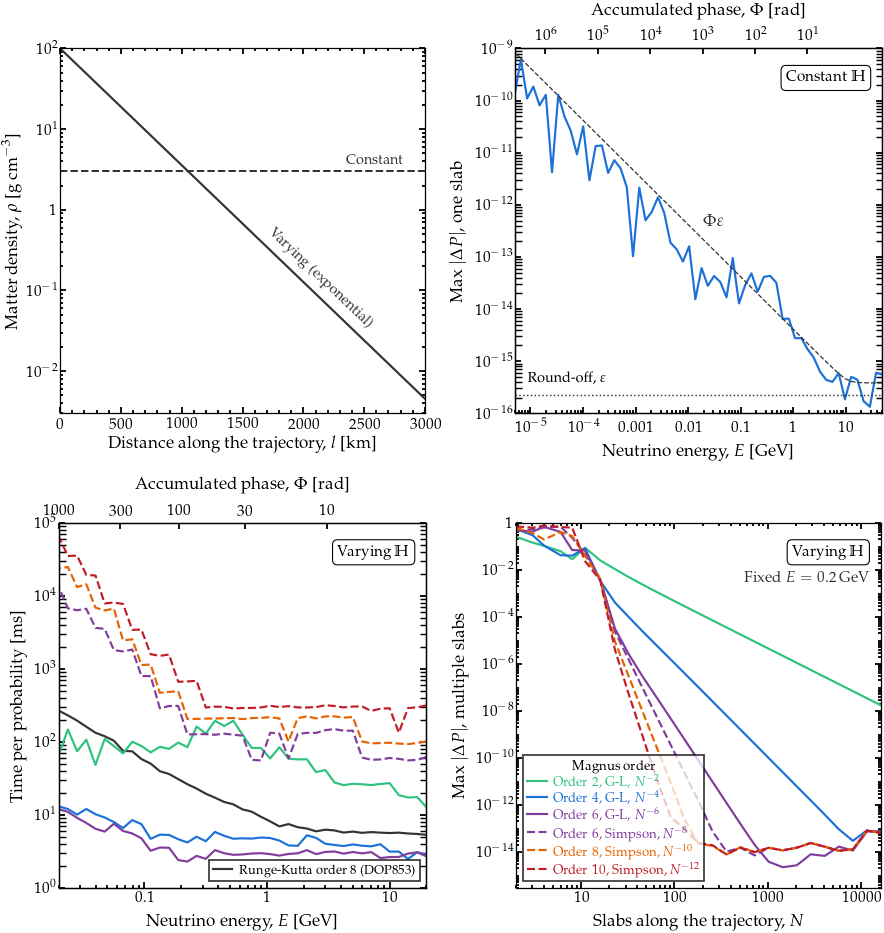

In [11]:
def label_along(ax, xs, ys, i, text, color, fontsize=8.0, offset=(4, 4), chord=False):
    """Label a curve in place, rotated to the angle its curve makes ON THE PAGE.

    A fixed rotation cannot serve six slopes differing by a factor of six: it put the
    shallowest label through its own curve and the steepest one off the edge.  The angle
    is read from ``ax.transData``, so this must be called once the geometry is final.
    """
    if chord:
        # The angle a straight label needs is the one of the chord it actually spans,
        # not the tangent at its anchor.  On a curve that steepens under the words --
        # the solar profile does -- the tangent is the shallower of the two, and the
        # curve closes on the text and cuts through it before the last character.
        f = ax.figure
        f.canvas.draw()
        probe = ax.text(0, 0, text, fontsize=fontsize)
        w = probe.get_window_extent(f.canvas.get_renderer()).width
        probe.remove()
        P = ax.transData.transform(np.column_stack([np.asarray(xs), np.asarray(ys)]))
        m = i
        while m < len(xs) - 1 and P[m, 0] - P[i, 0] < w:
            m += 1
        a, b = P[i], P[m]
    else:
        j, k = max(i - 1, 0), min(i + 1, len(xs) - 1)
        a = ax.transData.transform((xs[j], ys[j]))
        b = ax.transData.transform((xs[k], ys[k]))
    ax.annotate(text, xy=(xs[i], ys[i]), xytext=offset, textcoords='offset points',
                color=color, fontsize=fontsize,
                rotation=np.degrees(np.arctan2(b[1] - a[1], b[0] - a[0])),
                rotation_mode='anchor')


def phase_axis(axis, energy, phase, ticks, powers=False):
    r"""A secondary top axis carrying the accumulated phase.

    The phase is what a stepping solver's cost tracks, but it is not a dial: what a user
    sets is the energy, so the energy carries the primary axis.  The two are not
    reciprocal.  Below about $0.2$ GeV the vacuum term dominates and $\Phi$ goes as
    $1/E$; above it the matter potential fixes the eigenvalue splitting and $\Phi$ barely
    moves, so a thousandfold in energy is only a hundred and fiftyfold in phase.  The top
    ticks are therefore unevenly spaced, which is the physics rather than a defect.
    """
    o = np.argsort(phase)
    tw = axis.twiny()
    tw.set_xscale('log')
    tw.set_xlim(axis.get_xlim())
    tw.set_xticks(np.exp(np.interp(np.log(ticks), np.log(np.asarray(phase)[o]),
                                   np.log(np.asarray(energy)[o]))))
    # Powers of ten only where every tick is one.  Writing half-decades that way rounds
    # 30 and 300 onto 10^1 and 10^2, which prints the same label twice.
    tw.set_xticklabels([(r'$10^{%d}$' % round(np.log10(t))) if powers else ('%g' % t)
                        for t in ticks])
    tw.set_xlabel(r'Accumulated phase, $\Phi$ [rad]', labelpad=8.5, fontsize=9.5)
    # Ticks point inward, so the labels have to be pushed clear of the spine or they
    # sit on top of it.
    tw.tick_params(axis='x', direction='in', which='both', top=True, pad=2.2, labelsize=8.5)
    # Only the twin's OWN x minors.  minorticks_off() would take the y axis with it,
    # and twiny() shares that axis with the panel underneath --- which silently
    # stripped the minor ticks off both panels that carry a phase axis.
    tw.xaxis.set_minor_locator(NullLocator())
    return tw


fig = plt.figure(figsize=(WIDE, 7.48))
gs = fig.add_gridspec(2, 2, hspace=0.30, wspace=0.24)
axd = fig.add_subplot(gs[0, 0])
ax = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

l_km = np.linspace(0.0, 3000.0, 600)
axd.semilogy(l_km, RHO0_2*np.exp(-l_km/LS_KM_2), '-', color=INK, lw=1.2)
axd.axhline(RHO_CONST, color=INK, ls='--', lw=1.1)
axd.set_xlim(0.0, 3000.0); axd.set_ylim(3.0e-3, 1.0e2)
axd.set_xlabel(r'Distance along the trajectory, $l$ [km]', labelpad=1.5)
axd.set_ylabel(r'Matter density, $\rho$ [g cm$^{-3}$]', labelpad=2.0)
logy(axd)
unit_as_one(axd)
RHO_EXP = RHO0_2*np.exp(-l_km/LS_KM_2)

ax[0].loglog(E_CONST/gd.UNIT_GEV, err_a, '-', color=BLUE, lw=1.2)
ax[0].axhline(2.2e-16, color=INK, ls=':', lw=0.8)
ax[0].loglog(E_CONST/gd.UNIT_GEV, np.maximum(phase_a*2.2e-16, 2.2e-16), ls='--',
             color=INK, lw=0.7)
stamp(ax[0], r'Round-off, $\varepsilon$', y=0.075)
ax[0].set_xlabel(r'Neutrino energy, $E$ [GeV]')
ax[0].set_ylabel(r'Max $|\Delta P|$, one slab')
ax[0].set_ylim(1.0e-16, 1.0e-9)
logx(ax[0]); logy(ax[0]); snug(ax[0], E_CONST/gd.UNIT_GEV)
# Every decade carries a label; the default locator thins them once the range is
# this deep, which leaves the panel with three ticks over eight decades.
ax[0].yaxis.set_major_locator(LogLocator(base=10.0, numticks=20))
# Minor ticks between the decades, and the energy labels pushed clear of the spine
# that the inward-pointing ticks share with them.
minor_log_ticks(ax[0])
ax[0].tick_params(axis='x', which='major', pad=4.2)
corner(ax[0], r'Constant $\mathbb{H}$', x=0.955, y=0.94)

E_row = np.array([r['E'] for r in rows])
# Only the solver is named here.  The six Magnus configurations are named in the panel
# beside it, where the rate they converge at belongs; colour and line style are the same
# in both, so one legend identifies them twice.
for name, lab, col, ls, meth, order in CODES:
    ax[1].loglog(E_row, 1e3*times[name], ls=ls, color=col, lw=1.2,
                 label=(lab if meth is None else '_nolegend_'))
ax[1].set_xlabel(r'Neutrino energy, $E$ [GeV]')
ax[1].set_ylabel(r'Time per probability [ms]')
ax[1].set_ylim(1.0, 1.0e5)
# Five decades now that the cumulative-quadrature curves reach a minute per
# probability, so the ticks go by decade rather than by halves.
ax[1].yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=20))
unit_as_one(ax[1])
minor_log_ticks(ax[1])
logx(ax[1]); logy(ax[1]); snug(ax[1], E_row)
corner(ax[1], r'Varying $\mathbb{H}$', x=0.955, y=0.94)
ax[1].legend(loc='lower right', handlelength=1.5,
             fontsize=7.2, labelspacing=0.2, borderpad=0.3, handletextpad=0.5,
             framealpha=0.75)

STYLE = {k: (ORDER_COLOR[k[1]], '-' if k[0] == 'gl' else '--') for k in SERIES}
LABELS = {('gl',2):'Order 2, G-L', ('gl',4):'Order 4, G-L',
          ('gl',6):'Order 6, G-L', ('simpson',6):'Order 6, Simpson',
          ('simpson',8):'Order 8, Simpson', ('simpson',10):'Order 10, Simpson'}
for k in SERIES:
    col, ls = STYLE[k]
    ax[2].loglog(NS, curves[k], ls=ls, color=col, lw=1.2,
                 label=r'%s, $N^{%d}$' % (LABELS[k], POWERS[k]))
ax[2].set_xlabel(r'Slabs along the trajectory, $N$')
ax[2].set_ylabel(r'Max $|\Delta P|$, multiple slabs')
logx(ax[2]); logy(ax[2]); snug(ax[2], NS)
ax[2].set_ylim(3.0e-16, 1.0)
unit_as_one(ax[2])
corner(ax[2], r'Varying $\mathbb{H}$', x=0.955, y=0.94)
# Flush with the *border* of the box above it, not with the text inside it: the box
# adds 0.32 of its font size as padding, so the two align only once that is added back.
ax[2].annotate(r'Fixed $E = %g$ GeV' % (E_FIX/gd.UNIT_GEV), xy=(0.955, 0.868),
               xycoords='axes fraction', xytext=(0.32*8.5 + 0.3, 0),
               textcoords='offset points', ha='right', va='top', fontsize=8.5,
               color=INK, zorder=10)
# The six configurations are named here rather than in the cost panel, because the rate
# each converges at is what this panel measures.  Each entry is set in its curve's colour.
_leg = ax[2].legend(loc='lower left', handlelength=1.5, fontsize=7.4, labelspacing=0.2,
                    borderpad=0.3, handletextpad=0.5, title='Magnus order',
                    framealpha=0.75)
_leg.get_title().set_fontsize(7.4)
for _txt, _k in zip(_leg.get_texts(), SERIES):
    _txt.set_color(STYLE[_k][0])

# Square panels: the box aspect is set on the axes rather than left to the figure shape,
# so it survives whatever the layout does to the margins.
for _a in [axd] + list(ax):
    _a.set_box_aspect(1.0)
# Margins are set explicitly rather than by tight_layout, whose layout engine re-runs at
# draw time -- when the twinned axes below exist and it cannot place them.  Fixing the
# margins here makes the geometry deterministic and lets the twins be added safely.
# Sized so the cells are square before set_box_aspect has to shrink anything: leftover
# slack inside a cell is what opens the gaps between panels.
fig.subplots_adjust(left=0.108, right=0.985, top=0.935, bottom=0.072,
                    wspace=0.20, hspace=0.26)
# The profile labels ride their own curves, at the angle the curve makes on the page.
label_along(axd, l_km, RHO_EXP, 330, 'Varying (exponential)', INK, fontsize=8.0,
            offset=(4, 5))
label_along(axd, l_km, np.full_like(l_km, RHO_CONST), 470, 'Constant', INK, fontsize=8.0,
            offset=(0, 4))
phase_axis(ax[0], E_CONST/gd.UNIT_GEV, phase_a,
           [10, 100, 1000, 10000, 100000, 1000000], powers=True)
# The rising guide carries its own name, upright and at the middle of its own line:
# rotating it to the curve angle left the epsilon unreadable at this size, and a stamp
# cannot say which of the two guides it means.
_g = np.maximum(phase_a*2.2e-16, 2.2e-16)
_i = len(_g)//2
ax[0].annotate(r'$\Phi\varepsilon$', xy=(E_CONST[_i]/gd.UNIT_GEV, _g[_i]),
               xytext=(4, 3.5), textcoords='offset points', color=INK, fontsize=9.5)
phase_axis(ax[1], E_row, ph, [10, 30, 100, 300, 1000])
save(fig, 'phase_vs_profile.pdf')

## Figure 3 --- new physics, four matrices in one slot

All four panels are the survival channel. The rows sit three decades apart in energy
because the two families of new physics do.

**The standard curve is flat at one in the lower row and that is physics, not an
artifact**: the vacuum term falls as $1/E$, so above about 100 GeV the active sector has
stopped oscillating over an Earth chord. The cell prints the range it spans.

five scenarios, survival channel, in 1.1 s
  b3 = 5.406e-14 eV; LIV departs from standard by up to 0.976
  standard at 1-30 TeV spans 0.9988-1.0000: the vacuum term goes as 1/E and has switched off


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/bsm.pdf


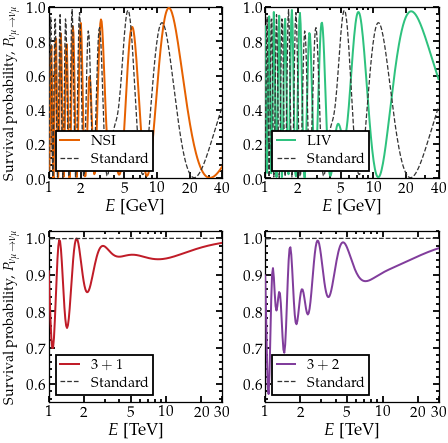

In [12]:
COSTHZ = -0.9
L = chord(COSTHZ)
LIV = dict(b1=0.0, b2=0.0, b3=np.pi/L, Lambda=1.0, sxi12=0.0,
           sxi23=1.0/np.sqrt(2.0), sxi13=0.0, dxiCP=0.0, n_liv=0)
KW = dict(nu_i=gd.NUMU, nu_f=gd.NUMU, rtol=RTOL_FIG, atol=ATOL_FIG)

E_GEV = np.logspace(np.log10(1.0), np.log10(40.0), 260)*gd.UNIT_GEV
E_TEV = np.logspace(np.log10(1.0), np.log10(30.0), 200)*gd.UNIT_TEV

t0 = time.perf_counter()
std_gev = np.asarray(quiet(oscprob.osc_prob_3nu_earth, E_GEV, costhz=COSTHZ, L=L,
                           **OSC, **KW))
nsi_gev = np.asarray(quiet(oscprob.osc_prob_3nu_earth_nsi, E_GEV, costhz=COSTHZ, L=L,
                           **OSC, **EPS, **KW))
liv_gev = np.asarray(quiet(oscprob.osc_prob_3nu_earth_liv, E_GEV, costhz=COSTHZ, L=L,
                           **OSC, **LIV, **KW))
std_tev = np.asarray(quiet(oscprob.osc_prob_3nu_earth, E_TEV, costhz=COSTHZ, L=L,
                           **OSC, **KW))
ste1_tev = np.asarray(quiet(oscprob.osc_prob_4nu_earth, E_TEV, costhz=COSTHZ, L=L,
                            **OSC, **STERILE4, **KW))
ste2_tev = np.asarray(quiet(oscprob.osc_prob_5nu_earth, E_TEV, costhz=COSTHZ, L=L,
                            **OSC, **STERILE5, **KW))
print('five scenarios, survival channel, in %.1f s' % (time.perf_counter() - t0))
print('  b3 = %.3e eV; LIV departs from standard by up to %.3f'
      % (LIV['b3'], np.max(np.abs(liv_gev - std_gev))))
print('  standard at 1-30 TeV spans %.4f-%.4f: the vacuum term goes as 1/E and has'
      ' switched off' % (std_tev.min(), std_tev.max()))

PANELS = [(E_GEV/gd.UNIT_GEV, std_gev, nsi_gev, ORANGE, 'NSI', r'$E$ [GeV]'),
          (E_GEV/gd.UNIT_GEV, std_gev, liv_gev, GREEN, 'LIV', r'$E$ [GeV]'),
          (E_TEV/gd.UNIT_TEV, std_tev, ste1_tev, RED, r'$3+1$', r'$E$ [TeV]'),
          (E_TEV/gd.UNIT_TEV, std_tev, ste2_tev, PURPLE, r'$3+2$', r'$E$ [TeV]')]
fig, axes = plt.subplots(2, 2, figsize=(COL, 3.45))
YLIM = {0: (0.0, 1.0), 1: (0.55, 1.02)}
TICKS = {r'$E$ [GeV]': (1, 2, 5, 10, 20, 40), r'$E$ [TeV]': (1, 2, 5, 10, 20, 30)}
for k, (ax, (x, base, curve, color, label, xl)) in enumerate(zip(axes.ravel(), PANELS)):
    ax.plot(x, curve, color=color, lw=1.1, zorder=3, label=label)
    ax.plot(x, base, color=INK, lw=0.7, ls='--', zorder=4, label='Standard')
    logx(ax); snug(ax, x); xticks_at(ax, TICKS[xl])
    ax.set_ylim(*YLIM[k//2]); minor_y(ax, 5)
    ax.set_xlabel(xl, labelpad=1.5)
    ax.legend(loc='lower left', handlelength=1.3, labelspacing=0.2, fontsize=8.0)
for ax in axes[:, 0]:
    ax.set_ylabel(r'Survival probability, $P_{\nu_\mu \to \nu_\mu}$', fontsize=8.0)
fig.tight_layout(pad=0.3, w_pad=0.8, h_pad=0.9)
save(fig, 'bsm.pdf')

## Figure 3b --- the bi-probability plane at DUNE

Notebook 5's DUNE setting, $1300$~km through the crust at $2$~GeV, with $\delta_{\rm CP}$
run once around the circle for a neutrino and for an antineutrino. The standard locus and,
on the same panel, the one non-standard interactions draw at the couplings of Fig. 3, taken
from notebook 8. Both come from the constant-density wrappers, which carry the antineutrino
sign and the conjugation of the couplings themselves; nothing here is built by hand.

  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/biprobability.pdf


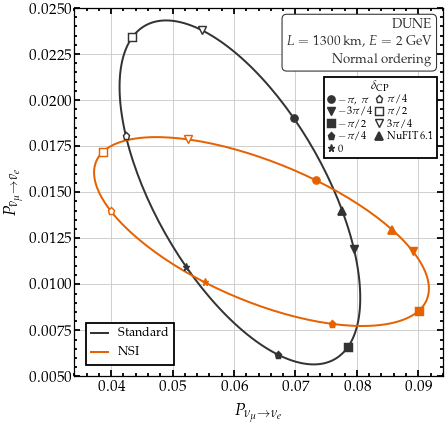

In [13]:
# ------------------------------------------------ the bi-probability plane at DUNE
# Notebook 5's DUNE setup -- 1300 km, 2 GeV, crust density -- with the standard locus and,
# on the same panel, the one non-standard interactions draw at the couplings of Fig. 3,
# from notebook 8.  The wrappers carry the antineutrino sign and the conjugation of the
# couplings themselves.
DUNE_L_KM, DUNE_E_GEV, DUNE_RHO = 1300.0, 2.0, 3.0
dcp_grid = np.linspace(-np.pi, np.pi, 181)
DCP_SEL = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0.0, 0.25*np.pi, 0.5*np.pi,
           0.75*np.pi]
DCP_LABEL = [r'$-\pi,\,\pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$',
             r'$\pi/2$', r'$3\pi/4$']
DCP_MARK = ['o', 'v', 's', 'p', '*', 'p', 's', 'v']
DCP_FILL = [True, True, True, True, True, False, False, False]


def appearance(dcp, nubar, nsi):
    """P(nu_mu -> nu_e) at DUNE for one delta_CP; the antineutrino's with nubar=True."""
    params = dict(OSC, dCP=dcp)
    common = dict(density_matter_is_in_g_per_cm3=True, nubar=nubar, nu_i=gd.NUMU,
                  nu_f=gd.NUE)
    if nsi:
        return float(oscprob.osc_prob_3nu_matter_nsi_constant_density(
            DUNE_E_GEV*gd.UNIT_GEV, DUNE_L_KM*gd.UNIT_KM, DUNE_RHO, **params, **EPS,
            **common))
    return float(oscprob.osc_prob_3nu_matter_constant_density(
        DUNE_E_GEV*gd.UNIT_GEV, DUNE_L_KM*gd.UNIT_KM, DUNE_RHO, **params, **common))


loci = {}
for name, nsi in (('std', False), ('nsi', True)):
    loci[name] = (np.array([appearance(d, False, nsi) for d in dcp_grid]),
                  np.array([appearance(d, True, nsi) for d in dcp_grid]),
                  [(appearance(d, False, nsi), appearance(d, True, nsi)) for d in DCP_SEL],
                  (appearance(OSC['dCP'], False, nsi), appearance(OSC['dCP'], True, nsi)))

fig, ax = plt.subplots(figsize=(COL, 3.55))
curve_handles = []
for name, color, label in (('std', INK, 'Standard'), ('nsi', ORANGE, 'NSI')):
    pnu, pnubar, sel, fit = loci[name]
    h, = ax.plot(pnu, pnubar, color=color, lw=1.1, zorder=3, label=label)
    curve_handles.append(h)
    for (x, y), m, f in zip(sel, DCP_MARK, DCP_FILL):
        ax.plot(x, y, marker=m, ms=4.0, color=color, mfc=color if f else 'white', mew=0.8,
                ls='none', zorder=4)
    ax.plot(fit[0], fit[1], marker='^', ms=4.5, color=color, ls='none', zorder=5)
# The delta_CP markers, drawn once in ink for their own legend.
marker_handles = [ax.plot([], [], marker=m, ms=4.0, color=INK, mfc=INK if f else 'white',
                          mew=0.8, ls='none', label=lab)[0]
                  for m, f, lab in zip(DCP_MARK, DCP_FILL, DCP_LABEL)]
marker_handles.append(ax.plot([], [], marker='^', ms=4.5, color=INK, ls='none',
                              label='NuFIT 6.1')[0])
ax.set_xlabel(r'$P_{\nu_\mu \to \nu_e}$')
ax.set_ylabel(r'$P_{\bar{\nu}_\mu \to \bar{\nu}_e}$')
ax.set_box_aspect(1.0)
ax.set_xlim(0.034, 0.094)
ax.set_ylim(0.005, 0.025)
ax.grid(True, which='major', color=GRID, lw=0.5); ax.set_axisbelow(True)
tag = ax.text(0.97, 0.97, 'DUNE\n$L = 1300$~km, $E = 2$~GeV\nNormal ordering',
              transform=ax.transAxes, ha='right', va='top', fontsize=7.4, color=INK,
              zorder=6, linespacing=1.4,
              bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=INK, lw=0.6))
# The delta_CP legend hangs below the label, flush with its right border; both are measured
# from the drawn box, since a text's anchor is the text and not its frame.
fig.canvas.draw()
frame = tag.get_bbox_patch().get_window_extent(fig.canvas.get_renderer())
right, bottom = ax.transAxes.inverted().transform((frame.x1, frame.y0))
leg1 = ax.legend(handles=marker_handles, loc='upper right',
                 bbox_to_anchor=(right, bottom - 0.012), ncol=2, fontsize=5.8,
                 handlelength=0.7, handletextpad=0.35, columnspacing=0.4, labelspacing=0.18,
                 borderpad=0.35, borderaxespad=0.0, title=r'$\delta_{\rm CP}$',
                 title_fontsize=6.8)
ax.add_artist(leg1)
ax.legend(handles=curve_handles, loc='lower left', bbox_to_anchor=(0.015, 0.015),
          fontsize=7.0, handlelength=1.3, borderpad=0.4)
fig.tight_layout(pad=0.4)
save(fig, 'biprobability.pdf')

## Figure 3c --- a neutrino and an antineutrino through the Earth

The chord, tolerance, energies and sterile parameters of Fig. 3, with every wrapper called
twice: once as it is and once with `nubar=True`, which is the whole of the antineutrino
case. The two-flavor system is the $(\nu_e, \nu_\mu)$ reduction of the 1--3 sector,
$\theta_{13}$ and $\Delta m^2_{31}$, where the Earth's matter resonance lives. The cell
prints where each pair separates most: in the GeV row it is the neutrino that meets the
resonance, in the TeV row the antineutrino.

four flavor counts, both signs, in 1.8 s
  2nu  |P - Pbar| largest at   4.21 GeV: 0.751 (P = 0.247, Pbar = 0.998); min P 0.247 at   4.21 GeV, min Pbar 0.916 at   1.26 GeV
  3nu  |P - Pbar| largest at   3.71 GeV: 0.840 (P = 0.133, Pbar = 0.973); min P 0.003 at  21.99 GeV, min Pbar 0.003 at  22.31 GeV
  3+1  |P - Pbar| largest at   1.34 TeV: 0.566 (P = 0.850, Pbar = 0.283); min P 0.699 at   1.07 TeV, min Pbar 0.268 at   1.36 TeV
  3+2  |P - Pbar| largest at   4.35 TeV: 0.970 (P = 0.979, Pbar = 0.009); min P 0.572 at   1.07 TeV, min Pbar 0.004 at   4.20 TeV


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/nu_nubar_earth.pdf


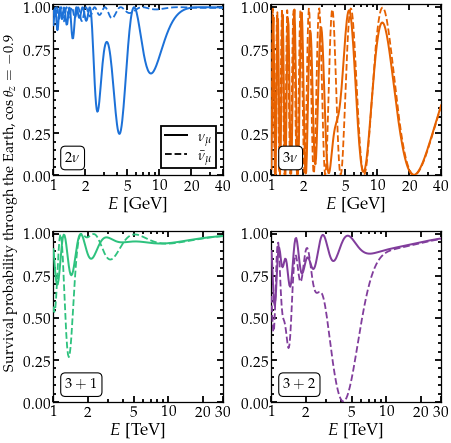

In [14]:
# ------------------------------------------------ a neutrino and an antineutrino, through the Earth
# COSTHZ, L, KW, E_GEV, E_TEV and TICKS are Fig. 3's, defined two cells up.  The two-flavor
# case is the (nu_e, nu_mu) reduction of the 1-3 sector, theta_13 and Delta m^2_31, which
# is the sector the Earth's matter resonance lives in.
from matplotlib.lines import Line2D


def both_signs(wrapper, E, **params):
    """The survival probability for a neutrino, then for an antineutrino."""
    return [np.asarray(quiet(wrapper, E, costhz=COSTHZ, L=L, nubar=nubar, **params, **KW))
            for nubar in (False, True)]


t0 = time.perf_counter()
nu2 = both_signs(oscprob.osc_prob_2nu_earth, E_GEV, sth=OSC['s13'], Dm2=OSC['D31'])
nu3 = both_signs(oscprob.osc_prob_3nu_earth, E_GEV, **OSC)
nu4 = both_signs(oscprob.osc_prob_4nu_earth, E_TEV, **OSC, **STERILE4)
nu5 = both_signs(oscprob.osc_prob_5nu_earth, E_TEV, **OSC, **STERILE5)
print('four flavor counts, both signs, in %.1f s' % (time.perf_counter() - t0))
for name, (p, pbar), E, unit in (('2nu', nu2, E_GEV, 'GeV'), ('3nu', nu3, E_GEV, 'GeV'),
                                 ('3+1', nu4, E_TEV, 'TeV'), ('3+2', nu5, E_TEV, 'TeV')):
    scale = gd.UNIT_GEV if unit == 'GeV' else gd.UNIT_TEV
    k = np.argmax(np.abs(p - pbar))
    print('  %-4s |P - Pbar| largest at %6.2f %s: %.3f (P = %.3f, Pbar = %.3f);'
          ' min P %.3f at %6.2f %s, min Pbar %.3f at %6.2f %s'
          % (name, E[k]/scale, unit, abs(p[k] - pbar[k]), p[k], pbar[k],
             p.min(), E[np.argmin(p)]/scale, unit, pbar.min(), E[np.argmin(pbar)]/scale, unit))

PANELS = [(E_GEV/gd.UNIT_GEV, nu2, BLUE, r'$2\nu$', r'$E$ [GeV]'),
          (E_GEV/gd.UNIT_GEV, nu3, ORANGE, r'$3\nu$', r'$E$ [GeV]'),
          (E_TEV/gd.UNIT_TEV, nu4, GREEN, r'$3+1$', r'$E$ [TeV]'),
          (E_TEV/gd.UNIT_TEV, nu5, PURPLE, r'$3+2$', r'$E$ [TeV]')]
fig, axes = plt.subplots(2, 2, figsize=(COL, 3.45))
for k, (ax, (x, (p, pbar), color, label, xl)) in enumerate(zip(axes.ravel(), PANELS)):
    ax.plot(x, p, color=color, lw=1.1, zorder=3)
    ax.plot(x, pbar, color=color, lw=1.0, ls='--', zorder=4)
    logx(ax); snug(ax, x); xticks_at(ax, TICKS[xl])
    ax.set_ylim(0.0, 1.02); minor_y(ax, 5)
    ax.set_xlabel(xl, labelpad=1.5)
    corner(ax, label, loc='lower left', fontsize=8.0, x=0.07, y=0.06)
# One legend for the four panels, in black: the line style is what it names, and the
# color belongs to the flavor count, which the corner labels give.
handles = [Line2D([], [], color='black', lw=1.1, label=r'$\nu_\mu$'),
           Line2D([], [], color='black', lw=1.0, ls='--', label=r'$\bar{\nu}_\mu$')]
axes[0, 0].legend(handles=handles, loc='lower right', handlelength=1.5, labelspacing=0.2,
                  fontsize=8.0)
fig.tight_layout(pad=0.3, w_pad=0.8, h_pad=0.9)
# One y label for the four panels, on the figure's left edge and centered on the two
# rows.  The panels are shifted right by the label's width, measured, so that the
# saved figure stays at the column width instead of growing past it.
Y_LABEL = r'Survival probability through the Earth, $\cos\theta_z = -0.9$'
ylab = fig.supylabel(Y_LABEL, fontsize=8.0, x=0.005, ha='left', va='center')
fig.canvas.draw()
_r = fig.canvas.get_renderer()
_label_w = ylab.get_window_extent(_r).width/fig.bbox.width
_ticks_x0 = min(t.get_window_extent(_r).x0 for ax in axes[:, 0]
                for t in ax.get_yticklabels() if t.get_text())/fig.bbox.width
_tick_w = axes[0, 0].get_position().x0 - _ticks_x0
_gap = 0.05/fig.get_size_inches()[0]
fig.subplots_adjust(left=0.005 + _label_w + _gap + _tick_w)
ylab.set_y(0.5*(axes[1, 0].get_position().y0 + axes[0, 0].get_position().y1))
save(fig, 'nu_nubar_earth.pdf')

## Figure 3d --- the arrangement of matter, not only its mean

NuOscProbExact's test of its slab composition (its notebook 10), run through Magnus: four
profiles built from twenty-four slabs of $250$~km, all with a mean density of
$5$~g~cm$^{-3}$, in four arrangements. The slab edges go to `t_breakpoints`, so each curve is
the exact product of twenty-four exponentials, and the antineutrino is added below. The cell
prints how far each profile departs from the uniform one.

four profiles, both signs, in 0.1 s
  nu    Castle wall  peak 0.325 at  5.39 GeV; largest |P - P_uniform| 0.093 at  0.46 GeV
  nu    Serrated     peak 0.324 at  5.39 GeV; largest |P - P_uniform| 0.035 at  1.17 GeV
  nu    Random wall  peak 0.292 at  5.78 GeV; largest |P - P_uniform| 0.098 at  2.81 GeV
  nu    Uniform      peak 0.325 at  5.39 GeV; largest |P - P_uniform| 0.000 at  0.20 GeV
  nubar Castle wall  peak 0.182 at  0.20 GeV; largest |P - P_uniform| 0.034 at  0.53 GeV
  nubar Serrated     peak 0.174 at  0.20 GeV; largest |P - P_uniform| 0.020 at  0.22 GeV
  nubar Random wall  peak 0.102 at  0.63 GeV; largest |P - P_uniform| 0.124 at  0.20 GeV
  nubar Uniform      peak 0.186 at  0.20 GeV; largest |P - P_uniform| 0.000 at  0.20 GeV


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/density_arrangement.pdf


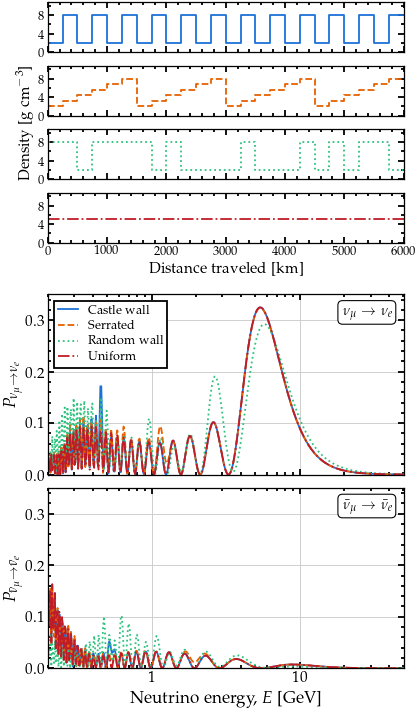

In [15]:
# ------------------------------------------------ the arrangement of matter, not only its mean
# NuOscProbExact's notebook 10, Fig. "density_arrangement": four profiles built from 24
# slabs of 250 km, with the same mean density of 5 g/cm^3 in four arrangements.  Here
# every probability comes from Magnus, with the slab edges declared as breakpoints, and
# the antineutrino is added below.
TOTAL_KM, N_SLAB = 6000.0, 24
RHO_LO, RHO_HI = 2.0, 8.0
widths_km = np.full(N_SLAB, TOTAL_KM/N_SLAB)
edges_km = np.concatenate(([0.0], np.cumsum(widths_km)))
castle = np.where(np.arange(N_SLAB) % 2 == 0, RHO_LO, RHO_HI)
serrated = np.tile(np.linspace(RHO_LO, RHO_HI, 6), 4)
# A permutation of the castle wall, not a fresh draw, so that its mean is exactly the
# castle wall's; the same mean density for all four is the premise of the comparison.
random_wall = np.random.default_rng(20260801).permutation(castle)
uniform = np.full(N_SLAB, 0.5*(RHO_LO + RHO_HI))
PROFILES = [('Castle wall', castle, BLUE, '-'), ('Serrated', serrated, ORANGE, '--'),
            ('Random wall', random_wall, GREEN, ':'), ('Uniform', uniform, RED, '-.')]
for name, rho, _, _ in PROFILES:
    assert abs(rho.mean() - 5.0) < 1e-12, name


def step_profile(rho):
    """The piecewise-constant density, in g/cm^3, as a function of position in eV^-1."""
    edges = edges_km*gd.UNIT_KM
    def rho_func(l):
        k = np.clip(np.searchsorted(edges, np.asarray(l, dtype=float), side='right') - 1,
                    0, N_SLAB - 1)
        return rho[k]
    return rho_func


E_GEV = np.logspace(-0.7, 1.7, 400)
BREAKPOINTS = edges_km[1:-1]*gd.UNIT_KM
t0 = time.perf_counter()
curves = {}
for name, rho, _, _ in PROFILES:
    for nubar in (False, True):
        curves[name, nubar] = np.asarray(quiet(
            oscprob.osc_prob_matter_std_potential, 3, step_profile(rho), E_GEV*gd.UNIT_GEV,
            TOTAL_KM*gd.UNIT_KM, OSC, t_breakpoints=BREAKPOINTS, nubar=nubar,
            nu_i=gd.NUMU, nu_f=gd.NUE, density_matter_is_in_g_per_cm3=True,
            rtol=RTOL_FIG, atol=ATOL_FIG))
print('four profiles, both signs, in %.1f s' % (time.perf_counter() - t0))
for nubar, tag in ((False, 'nu'), (True, 'nubar')):
    ref = curves['Uniform', nubar]
    for name, _, _, _ in PROFILES:
        p = curves[name, nubar]
        k = np.argmax(p)
        print('  %-5s %-12s peak %.3f at %5.2f GeV; largest |P - P_uniform| %.3f at %5.2f GeV'
              % (tag, name, p[k], E_GEV[k], np.abs(p - ref).max(), E_GEV[np.argmax(np.abs(p - ref))]))

fig = plt.figure(figsize=(COL, 6.2))
# Row 4 is a gap between the profiles and the probabilities.
gs = fig.add_gridspec(7, 1, height_ratios=[1.0, 1.0, 1.0, 1.0, 0.5, 3.6, 3.6], hspace=0.16)
axes_p = [fig.add_subplot(gs[i]) for i in range(4)]
ax_nu = fig.add_subplot(gs[5])
ax_nubar = fig.add_subplot(gs[6], sharex=ax_nu)
for axp, (name, rho, color, ls) in zip(axes_p, PROFILES):
    axp.step(edges_km, np.concatenate((rho[:1], rho)), ls=ls, where='pre', lw=1.0,
             color=color)
    axp.set_xlim(0.0, edges_km[-1]); axp.set_ylim(0.0, RHO_HI*1.35)
    axp.set_yticks([0.0, 4.0, 8.0])
    axp.yaxis.set_minor_locator(AutoMinorLocator(2))
    axp.tick_params(labelsize=7.0)
    if axp is not axes_p[-1]:
        axp.tick_params(labelbottom=False)
axes_p[-1].set_xlabel('Distance traveled [km]', labelpad=2.0, fontsize=8.5)
for ax, nubar, label in ((ax_nu, False, r'$\nu_\mu \to \nu_e$'),
                         (ax_nubar, True, r'$\bar{\nu}_\mu \to \bar{\nu}_e$')):
    for name, rho, color, ls in PROFILES:
        ax.plot(E_GEV, curves[name, nubar], ls=ls, color=color, lw=1.0, label=name)
    logx(ax); ax.set_xlim(E_GEV[0], E_GEV[-1])
    # One range for both channels, so the antineutrino reads against the neutrino.
    ax.set_ylim(0.0, 0.35); ax.set_yticks([0.0, 0.1, 0.2, 0.3]); minor_y(ax, 5)
    ax.grid(True, which='major', color=GRID, lw=0.5); ax.set_axisbelow(True)
    corner(ax, label, loc='upper right', fontsize=8.0, y=0.94)
ax_nu.tick_params(labelbottom=False)
ax_nu.set_ylabel(r'$P_{\nu_\mu \to \nu_e}$', labelpad=2.0)
ax_nubar.set_ylabel(r'$P_{\bar{\nu}_\mu \to \bar{\nu}_e}$', labelpad=2.0)
ax_nubar.set_xlabel(r'Neutrino energy, $E$ [GeV]', labelpad=2.0)
ax_nu.legend(loc='upper left', ncol=1, fontsize=7.0, handlelength=1.6, labelspacing=0.25)
fig.canvas.draw()
# One density label for the four strips, centered on them and set just left of their tick
# labels, which are narrower than the probability panels' and so end short of the margin.
_r = fig.canvas.get_renderer()
_ticks_x0 = min(t.get_window_extent(_r).x0 for axp in axes_p
                for t in axp.get_yticklabels() if t.get_text())/fig.bbox.width
top, bottom = axes_p[0].get_position(), axes_p[-1].get_position()
fig.text(_ticks_x0 - 0.03/fig.get_size_inches()[0], 0.5*(top.y1 + bottom.y0),
         r'Density [g cm$^{-3}$]', rotation='vertical', va='center', ha='right', fontsize=8.5)
save(fig, 'density_arrangement.pdf')

## Figure 3e --- the Earth, as PREM describes it

Before any chord: the density profile every Earth calculation reads, against radial
distance. The bands are the layers, the dashed lines the three radii at which the
electron fraction changes, and the cut-away globe carries the same colors. Every
`osc_prob_*_earth` call places a slab edge wherever its chord crosses one of the nine
PREM boundaries, so no slab of the expansion straddles a density jump.

  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/prem_profile.pdf


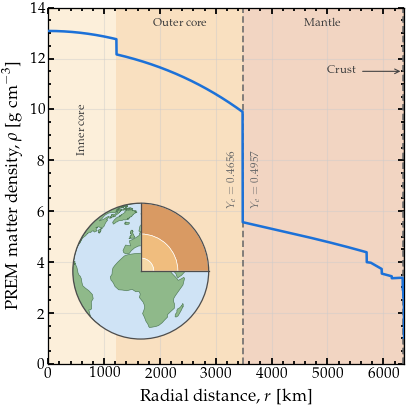

In [16]:
# --- Figure 3e -- the Earth's density, with a cut-away globe
#
# Land polygons: Natural Earth 1:110m, public domain, outer rings only,
# decimated to 30 polygons and 1993 points.  Inlined rather than fetched,
# because the notebooks run in continuous integration with no network.
LAND = [[[-45.15,-78.05],[-43.92,-78.48],[-43.49,-79.09],[-43.37,-79.52],[-43.33,-80.03],[-44.88,-80.34],[-46.51,-80.59],[-48.39,-80.83],[-50.48,-81.03],[-52.85,-80.97],[-54.16,-80.63],[-53.99,-80.22],[-51.85,-79.95],[-50.99,-79.61],[-50.36,-79.18],[-49.91,-78.81],[-49.31,-78.46],[-48.66,-78.05],[-48.66,-78.05],[-48.15,-78.05],[-46.66,-77.83],[-45.15,-78.05]],[[-68.45,-70.96],[-68.33,-71.41],[-68.51,-71.8],[-68.78,-72.17],[-69.96,-72.31],[-71.08,-72.5],[-72.39,-72.48],[-71.9,-72.09],[-73.07,-72.23],[-74.19,-72.37],[-74.95,-72.07],[-75.01,-71.66],[-73.92,-71.27],[-73.92,-71.27],[-73.23,-71.15],[-72.07,-71.19],[-71.78,-70.68],[-71.72,-70.31],[-71.74,-69.51],[-71.17,-69.04],[-70.25,-68.88],[-69.72,-69.25],[-69.49,-69.62],[-69.06,-70.07],[-68.73,-70.51],[-68.45,-70.96]],[[-58.61,-64.15],[-59.79,-64.21],[-61.3,-64.54],[-62.51,-65.09],[-62.59,-65.86],[-62.81,-66.43],[-64.29,-66.84],[-65.51,-67.58],[-65.31,-68.37],[-63.96,-68.91],[-62.79,-69.62],[-62.28,-70.38],[-61.51,-71.09],[-61.08,-72.38],[-60.69,-73.17],[-61.38,-74.11],[-63.3,-74.58],[-64.35,-75.26],[-67.19,-75.79],[-69.8,-76.22],[-72.21,-76.67],[-75.56,-76.71],[-76.93,-77.1],[-74.28,-77.56],[-74.77,-78.22],[-77.93,-78.38],[-78.02,-79.18],[-76.63,-79.89],[-73.24,-80.42],[-70.01,-81.0],[-65.7,-81.47],[-61.55,-82.04],[-58.71,-82.85],[-57.01,-82.87],[-53.62,-82.26],[-49.76,-81.73],[-44.83,-81.85],[-42.16,-81.65],[-38.24,-81.34],[-34.39,-80.91],[-30.1,-80.59],[-29.25,-79.99],[-29.69,-79.26],[-33.68,-79.46],[-35.91,-79.08],[-35.33,-78.12],[-32.21,-77.65],[-29.78,-77.07],[-27.51,-76.5],[-25.47,-76.28],[-22.46,-76.11],[-20.01,-75.67],[-17.52,-75.13],[-15.7,-74.5],[-16.47,-73.87],[-15.45,-73.15],[-13.31,-72.72],[-11.51,-72.01],[-10.3,-71.27],[-8.61,-71.66],[-7.38,-71.32],[-5.79,-71.03],[-4.34,-71.46],[-1.8,-71.17],[-0.23,-71.64],[1.89,-71.13],[4.14,-70.85],[6.27,-70.46],[7.74,-69.89],[9.53,-70.01],[10.82,-70.83],[12.4,-70.25],[14.73,-70.03],[15.95,-70.03],[18.2,-69.87],[20.38,-70.01],[21.92,-70.4],[23.67,-70.52],[25.98,-70.48],[28.09,-70.32],[30.03,-69.93],[31.99,-69.66],[33.3,-68.84],[34.91,-68.66],[36.16,-69.25],[37.91,-69.52],[39.67,-69.54],[40.92,-68.93],[42.94,-68.46],[44.9,-68.05],[46.5,-67.6],[48.34,-67.37],[49.93,-67.11],[50.95,-66.52],[52.61,-66.05],[54.53,-65.82],[56.36,-65.97],[57.26,-66.68],[58.74,-67.29],[60.61,-67.68],[62.39,-68.01],[64.05,-67.41],[65.97,-67.74],[67.89,-67.93],[69.71,-68.97],[69.56,-69.68],[67.81,-70.31],[69.07,-70.68],[68.42,-71.44],[68.71,-72.17],[71.02,-72.09],[71.91,-71.32],[73.08,-70.72],[73.86,-69.87],[75.63,-69.74],[77.64,-69.46],[78.43,-68.7],[80.09,-68.07],[81.48,-67.54],[82.78,-67.21],[84.68,-67.21],[86.75,-67.15],[87.99,-66.21],[88.83,-66.95],[90.63,-67.23],[92.61,-67.19],[94.18,-67.11],[95.78,-67.39],[97.76,-67.25],[99.72,-67.25],[100.89,-66.58],[102.83,-65.56],[104.24,-65.97],[106.18,-66.93],[108.08,-66.95],[110.24,-66.7],[111.74,-66.13],[113.6,-65.88],[114.9,-66.39],[116.7,-66.66],[118.58,-67.17],[120.87,-67.19],[122.32,-66.56],[124.12,-66.62],[126.1,-66.56],[127.88,-66.66],[129.7,-66.58],[131.8,-66.39],[133.86,-66.29],[135.03,-65.72],[135.7,-65.58],[136.21,-66.45],[137.46,-66.95],[139.91,-66.88],[142.12,-66.82],[144.37,-66.84],[146.2,-67.23],[146.65,-67.9],[148.84,-68.39],[151.48,-68.72],[153.64,-68.89],[155.17,-68.84],[156.81,-69.38],[159.18,-69.6],[160.81,-70.23],[162.69,-70.74],[164.92,-70.78],[167.31,-70.83],[169.46,-71.21],[171.21,-71.7],[170.56,-72.44],[169.76,-73.24],[167.98,-73.81],[166.09,-74.38],[164.96,-75.15],[163.82,-75.87],[163.47,-76.69],[164.06,-77.46],[164.74,-78.18],[167.0,-78.75],[163.67,-79.12],[160.92,-79.73],[160.32,-80.57],[161.12,-81.28],[162.49,-82.06],[165.1,-82.71],[168.9,-83.34],[172.28,-84.04],[173.22,-84.41],[178.28,-84.47],[180.0,-90.0],[-180.0,-84.71],[-179.06,-84.14],[-177.14,-84.42],[-176.52,-84.23],[-176.08,-84.1],[-175.83,-84.12],[-173.12,-84.12],[-169.95,-83.88],[-168.53,-84.24],[-164.18,-84.83],[-158.07,-85.37],[-150.94,-85.3],[-145.89,-85.32],[-142.89,-84.57],[-150.06,-84.3],[-153.59,-83.69],[-153.04,-82.83],[-152.86,-82.04],[-155.29,-81.42],[-154.41,-81.16],[-150.65,-81.34],[-147.22,-80.67],[-146.77,-79.93],[-149.53,-79.36],[-153.39,-79.16],[-155.98,-78.69],[-158.05,-78.03],[-157.88,-76.99],[-155.33,-77.2],[-152.92,-77.5],[-150.0,-77.18],[-147.61,-76.58],[-146.14,-76.11],[-146.2,-75.38],[-144.32,-75.54],[-141.64,-75.09],[-138.86,-74.97],[-136.43,-74.52],[-134.43,-74.36],[-132.26,-74.3],[-129.55,-74.46],[-126.89,-74.42],[-124.01,-74.48],[-121.07,-74.52],[-118.68,-74.19],[-116.22,-74.24],[-113.94,-73.71],[-112.95,-74.38],[-111.26,-74.42],[-108.71,-74.91],[-106.15,-75.13],[-103.37,-74.99],[-100.65,-75.3],[-100.76,-74.54],[-102.55,-74.11],[-103.33,-73.36],[-102.92,-72.75],[-100.31,-72.75],[-98.12,-73.21],[-96.34,-73.62],[-93.67,-73.28],[-91.42,-73.4],[-89.23,-72.56],[-87.27,-73.19],[-85.19,-73.48],[-82.67,-73.64],[-80.69,-73.48],[-79.3,-73.52],[-76.91,-73.64],[-74.89,-73.87],[-72.83,-73.4],[-70.21,-73.15],[-67.96,-72.79],[-67.13,-72.05],[-67.56,-71.25],[-68.23,-70.46],[-68.54,-69.72],[-67.98,-68.95],[-67.43,-68.15],[-67.74,-67.33],[-66.7,-66.58],[-65.37,-65.9],[-64.18,-65.17],[-63.0,-64.64],[-61.41,-64.27],[-59.89,-63.96],[-58.59,-63.39],[-57.22,-63.53],[-58.61,-64.15]],[[-67.75,-53.85],[-66.45,-54.45],[-65.05,-54.7],[-65.5,-55.2],[-66.45,-55.25],[-66.96,-54.9],[-67.29,-55.3],[-68.15,-55.61],[-69.23,-55.5],[-69.96,-55.2],[-71.01,-55.05],[-72.26,-54.5],[-73.29,-53.96],[-74.66,-52.84],[-73.84,-53.05],[-72.43,-53.72],[-71.11,-54.07],[-70.59,-53.62],[-70.27,-52.93],[-69.35,-52.52],[-68.63,-52.64],[-68.63,-52.64],[-68.25,-53.1],[-67.75,-53.85]],[[173.02,-40.92],[173.25,-41.33],[173.96,-40.93],[174.25,-41.35],[174.25,-41.77],[173.88,-42.23],[173.22,-42.97],[172.71,-43.37],[173.08,-43.85],[172.31,-43.87],[171.45,-44.24],[171.19,-44.9],[170.62,-45.91],[169.83,-46.36],[169.33,-46.64],[168.41,-46.62],[167.76,-46.29],[166.68,-46.22],[166.51,-45.85],[167.05,-45.11],[168.3,-44.12],[168.95,-43.94],[169.67,-43.56],[170.52,-43.03],[171.13,-42.51],[171.57,-41.77],[171.95,-41.51],[172.1,-40.96],[172.8,-40.49],[173.02,-40.92]],[[174.61,-36.16],[175.34,-37.21],[175.36,-36.53],[175.81,-36.8],[175.96,-37.56],[176.76,-37.88],[177.44,-37.96],[178.01,-37.58],[178.52,-37.7],[178.27,-38.58],[177.97,-39.17],[177.21,-39.15],[176.94,-39.45],[177.03,-39.88],[176.89,-40.07],[176.51,-40.6],[176.01,-41.29],[175.24,-41.69],[175.07,-41.43],[174.65,-41.28],[175.23,-40.46],[174.9,-39.91],[173.82,-39.51],[173.85,-39.15],[174.57,-38.8],[174.74,-38.03],[174.7,-37.38],[174.29,-36.71],[174.32,-36.53],[173.84,-36.12],[173.05,-35.24],[172.64,-34.53],[173.01,-34.45],[173.55,-35.01],[174.33,-35.27],[174.61,-36.16]],[[50.06,-13.56],[50.22,-14.76],[50.48,-15.23],[50.38,-15.71],[50.2,-16.0],[49.86,-15.41],[49.67,-15.71],[49.86,-16.45],[49.77,-16.88],[49.5,-17.11],[49.44,-17.95],[49.04,-19.12],[48.55,-20.5],[47.93,-22.39],[47.55,-23.78],[47.1,-24.94],[46.28,-25.18],[45.41,-25.6],[44.83,-25.35],[44.04,-24.99],[43.76,-24.46],[43.7,-23.57],[43.35,-22.78],[43.25,-22.06],[43.43,-21.34],[43.89,-21.16],[43.9,-20.83],[44.37,-20.07],[44.46,-19.44],[44.23,-18.96],[44.04,-18.33],[43.96,-17.41],[44.31,-16.85],[44.45,-16.22],[44.94,-16.18],[45.5,-15.97],[45.87,-15.79],[46.31,-15.78],[46.88,-15.21],[47.71,-14.59],[48.01,-14.09],[47.87,-13.66],[48.29,-13.78],[48.85,-13.09],[48.86,-12.49],[49.19,-12.04],[49.54,-12.47],[49.81,-12.9],[50.06,-13.56]],[[143.56,-13.76],[143.92,-14.55],[144.56,-14.17],[144.89,-14.59],[145.37,-14.98],[145.27,-15.43],[145.49,-16.29],[145.64,-16.78],[145.89,-16.91],[146.16,-17.76],[146.06,-18.28],[146.39,-18.96],[147.47,-19.48],[148.18,-19.96],[148.85,-20.39],[148.72,-20.63],[149.29,-21.26],[149.68,-22.34],[150.08,-22.12],[150.48,-22.56],[150.73,-22.4],[150.9,-23.46],[151.61,-24.08],[152.07,-24.46],[152.86,-25.27],[153.14,-26.07],[153.16,-26.64],[153.09,-27.26],[153.57,-28.11],[153.51,-29.0],[153.34,-29.46],[153.07,-30.35],[153.09,-30.92],[152.89,-31.64],[152.45,-32.55],[151.71,-33.04],[151.34,-33.82],[151.01,-34.31],[150.71,-35.17],[150.33,-35.67],[150.08,-36.42],[149.95,-37.11],[150.0,-37.43],[149.42,-37.77],[148.3,-37.81],[147.38,-38.22],[146.92,-38.61],[146.32,-39.04],[145.49,-38.59],[144.88,-38.42],[145.03,-37.9],[144.49,-38.09],[143.61,-38.81],[142.75,-38.54],[142.18,-38.38],[141.61,-38.31],[140.64,-38.02],[139.99,-37.4],[139.81,-36.64],[139.57,-36.14],[139.08,-35.73],[138.12,-35.61],[138.45,-35.13],[138.21,-34.38],[137.72,-35.08],[136.83,-35.26],[137.35,-34.71],[137.5,-34.13],[137.89,-33.64],[137.81,-32.9],[137.0,-33.75],[136.37,-34.09],[135.99,-34.89],[135.21,-34.48],[135.24,-33.95],[134.61,-33.22],[134.09,-32.85],[134.27,-32.62],[132.99,-32.01],[132.29,-31.98],[131.33,-31.5],[129.54,-31.59],[128.24,-31.95],[127.1,-32.28],[126.15,-32.22],[125.09,-32.73],[124.22,-32.96],[124.03,-33.48],[123.66,-33.89],[122.81,-33.91],[122.18,-34.0],[121.3,-33.82],[120.58,-33.93],[119.89,-33.98],[119.3,-34.51],[119.01,-34.46],[118.51,-34.75],[118.02,-35.06],[117.3,-35.03],[116.63,-35.03],[115.56,-34.39],[115.03,-34.2],[115.05,-33.62],[115.55,-33.49],[115.71,-33.26],[115.68,-32.9],[115.8,-32.21],[115.69,-31.61],[115.16,-30.6],[115.0,-30.03],[115.04,-29.46],[114.64,-28.81],[114.62,-28.52],[114.17,-28.12],[114.05,-27.33],[113.48,-26.54],[113.34,-26.12],[113.78,-26.55],[113.44,-25.62],[113.94,-25.91],[114.23,-26.3],[114.22,-25.79],[113.72,-25.0],[113.63,-24.68],[113.39,-24.38],[113.5,-23.81],[113.71,-23.56],[113.84,-23.06],[113.74,-22.48],[114.15,-21.76],[114.23,-22.52],[114.65,-21.83],[115.46,-21.5],[115.95,-21.07],[116.71,-20.7],[117.17,-20.62],[117.44,-20.75],[118.23,-20.37],[118.84,-20.26],[118.99,-20.04],[119.25,-19.95],[119.81,-19.98],[120.86,-19.68],[121.4,-19.24],[121.66,-18.71],[122.24,-18.2],[122.29,-17.8],[122.31,-17.25],[123.01,-16.41],[123.43,-17.27],[123.86,-17.07],[123.5,-16.6],[123.82,-16.11],[124.26,-16.33],[124.38,-15.57],[124.93,-15.08],[125.17,-14.68],[125.67,-14.51],[125.69,-14.23],[126.13,-14.35],[126.14,-14.1],[126.58,-13.95],[127.07,-13.82],[127.8,-14.28],[128.36,-14.87],[128.99,-14.88],[129.62,-14.97],[129.41,-14.42],[129.89,-13.62],[130.34,-13.36],[130.18,-13.11],[130.62,-12.54],[131.22,-12.18],[131.74,-12.3],[132.58,-12.11],[132.56,-11.6],[131.82,-11.27],[132.36,-11.13],[133.02,-11.38],[133.55,-11.79],[134.39,-12.04],[134.68,-11.94],[135.3,-12.25],[135.88,-11.96],[136.26,-12.05],[136.49,-11.86],[136.95,-12.35],[136.69,-12.89],[136.31,-13.29],[135.96,-13.32],[136.08,-13.72],[135.78,-14.22],[135.43,-14.72],[135.5,-15.0],[136.3,-15.55],[137.07,-15.87],[137.58,-16.22],[138.3,-16.81],[138.59,-16.81],[139.11,-17.06],[139.26,-17.37],[140.22,-17.71],[140.88,-17.37],[141.07,-16.83],[141.27,-16.39],[141.4,-15.84],[141.7,-15.04],[141.56,-14.56],[141.64,-14.27],[141.52,-13.7],[141.65,-12.94],[141.84,-12.74],[141.69,-12.41],[141.93,-11.88],[142.12,-11.33],[142.14,-11.04],[142.52,-10.67],[142.8,-11.16],[142.87,-11.78],[143.12,-11.91],[143.16,-12.33],[143.52,-12.83],[143.6,-13.4],[143.56,-13.76]],[[134.14,-1.15],[134.42,-2.77],[135.46,-3.37],[136.29,-2.31],[137.44,-1.7],[138.33,-1.7],[139.18,-2.05],[139.93,-2.41],[141.0,-2.6],[142.74,-3.29],[144.58,-3.86],[145.27,-4.37],[145.83,-4.88],[145.98,-5.47],[147.65,-6.08],[147.89,-6.61],[146.97,-6.72],[147.19,-7.39],[148.08,-8.04],[148.73,-9.1],[149.31,-9.07],[149.27,-9.51],[150.04,-9.68],[149.74,-9.87],[150.8,-10.29],[150.69,-10.58],[150.03,-10.65],[149.78,-10.39],[148.92,-10.28],[147.91,-10.13],[147.14,-9.49],[146.57,-8.94],[146.05,-8.07],[144.74,-7.63],[143.9,-7.92],[143.29,-8.25],[143.41,-8.98],[142.63,-9.33],[142.07,-9.16],[141.03,-9.12],[140.14,-8.3],[139.13,-8.1],[138.88,-8.38],[137.61,-8.41],[138.04,-7.6],[138.67,-7.32],[138.41,-6.23],[137.93,-5.39],[135.99,-4.55],[135.16,-4.46],[133.66,-3.54],[133.37,-4.02],[132.98,-4.11],[132.76,-3.75],[132.75,-3.31],[131.99,-2.82],[133.07,-2.46],[133.78,-2.48],[133.7,-2.21],[132.23,-2.21],[131.84,-1.62],[130.94,-1.43],[130.52,-0.94],[131.87,-0.7],[132.38,-0.37],[133.99,-0.78],[134.14,-1.15]],[[125.24,1.42],[124.44,0.43],[123.69,0.24],[122.72,0.43],[121.06,0.38],[120.18,0.24],[120.04,-0.52],[120.94,-1.41],[121.48,-0.96],[123.34,-0.62],[123.26,-1.08],[122.82,-0.93],[122.39,-1.52],[121.51,-1.9],[122.45,-3.19],[122.27,-3.53],[123.17,-4.68],[123.16,-5.34],[122.63,-5.63],[122.24,-5.28],[122.72,-4.46],[121.74,-4.85],[121.49,-4.57],[121.62,-4.19],[120.9,-3.6],[120.97,-2.63],[120.31,-2.93],[120.39,-4.1],[120.43,-5.53],[119.8,-5.67],[119.37,-5.38],[119.65,-4.46],[119.5,-3.49],[119.08,-3.49],[118.77,-2.8],[119.18,-2.15],[119.32,-1.35],[119.83,0.15],[120.04,0.57],[120.89,1.31],[121.67,1.01],[122.93,0.88],[124.08,0.92],[125.07,1.64],[125.24,1.42]],[[105.82,-5.85],[104.71,-5.87],[103.87,-5.04],[102.58,-4.22],[102.16,-3.61],[101.4,-2.8],[100.9,-2.05],[100.14,-0.65],[99.26,0.18],[98.97,1.04],[98.6,1.82],[97.7,2.45],[97.18,3.31],[96.42,3.87],[95.38,4.97],[95.29,5.48],[95.94,5.44],[97.48,5.25],[98.37,4.27],[99.14,3.59],[99.69,3.17],[100.64,2.1],[101.66,2.08],[102.5,1.4],[103.08,0.56],[103.84,0.1],[103.44,-0.71],[104.01,-1.06],[104.37,-1.08],[104.54,-1.78],[104.89,-2.34],[105.62,-2.43],[106.11,-3.06],[105.86,-4.31],[105.82,-5.85]],[[117.88,1.83],[119.0,0.9],[117.81,0.78],[117.48,0.1],[117.52,-0.8],[116.56,-1.49],[116.53,-2.48],[116.15,-4.01],[116.0,-3.66],[114.86,-4.11],[114.47,-3.5],[113.76,-3.44],[113.26,-3.12],[112.07,-3.48],[111.7,-2.99],[111.05,-3.05],[110.22,-2.93],[110.07,-1.59],[109.57,-1.31],[109.09,-0.46],[108.95,0.42],[109.07,1.34],[109.66,2.01],[110.4,1.66],[111.17,1.85],[111.37,2.7],[111.8,2.89],[113.0,3.1],[113.71,3.89],[114.2,4.53],[114.6,4.9],[115.45,5.45],[116.22,6.14],[116.73,6.92],[117.13,6.93],[117.64,6.42],[117.69,5.99],[118.35,5.71],[119.18,5.41],[119.11,5.02],[118.44,4.97],[118.62,4.48],[117.88,4.14],[117.31,3.23],[118.05,2.29],[117.88,1.83]],[[140.98,37.14],[140.6,36.34],[140.77,35.84],[140.25,35.14],[138.98,34.67],[137.22,34.61],[135.79,33.46],[135.12,33.85],[135.08,34.6],[133.34,34.38],[132.16,33.9],[130.99,33.89],[132.0,33.15],[131.33,31.45],[130.69,31.03],[130.2,31.42],[130.45,32.32],[129.81,32.61],[129.41,33.3],[130.35,33.6],[130.88,34.23],[131.88,34.75],[132.62,35.43],[134.61,35.73],[135.68,35.53],[136.72,37.3],[137.39,36.83],[138.86,37.83],[139.43,38.22],[140.05,39.44],[139.88,40.56],[140.31,41.2],[141.37,41.38],[141.91,39.99],[141.88,39.18],[140.96,38.17],[140.98,37.14]],[[-56.13,50.69],[-56.8,49.81],[-56.14,50.15],[-55.47,49.94],[-55.82,49.59],[-54.94,49.31],[-54.47,49.56],[-53.48,49.25],[-53.79,48.52],[-53.09,48.69],[-52.96,48.16],[-52.65,47.54],[-53.07,46.66],[-53.52,46.62],[-54.18,46.81],[-53.96,47.63],[-54.24,47.75],[-55.4,46.88],[-56.0,46.92],[-55.29,47.39],[-56.25,47.63],[-57.33,47.57],[-59.27,47.6],[-59.42,47.9],[-58.8,48.25],[-59.23,48.52],[-58.39,49.13],[-57.36,50.72],[-56.74,51.29],[-55.87,51.63],[-55.41,51.59],[-55.6,51.32],[-56.13,50.69]],[[-3.01,58.64],[-4.07,57.55],[-3.06,57.69],[-1.96,57.68],[-2.22,56.87],[-3.12,55.97],[-2.09,55.91],[-1.11,54.62],[-0.43,54.46],[0.18,53.33],[0.47,52.93],[1.68,52.74],[1.56,52.1],[1.05,51.81],[1.45,51.29],[0.55,50.77],[-0.79,50.77],[-2.49,50.5],[-2.96,50.7],[-3.62,50.23],[-4.54,50.34],[-5.25,49.96],[-5.78,50.16],[-4.31,51.21],[-3.41,51.43],[-4.98,51.59],[-5.27,51.99],[-4.22,52.3],[-4.77,52.84],[-4.58,53.5],[-3.09,53.4],[-2.95,53.98],[-3.63,54.62],[-4.84,54.79],[-5.08,55.06],[-4.72,55.51],[-5.05,55.78],[-5.59,55.31],[-5.64,56.28],[-6.15,56.79],[-5.79,57.82],[-5.01,58.63],[-4.21,58.55],[-3.01,58.64]],[[-14.51,66.46],[-14.74,65.81],[-13.61,65.13],[-14.91,64.36],[-17.79,63.68],[-18.66,63.5],[-19.97,63.64],[-22.76,63.96],[-21.78,64.4],[-23.96,64.89],[-22.18,65.08],[-22.23,65.38],[-24.33,65.61],[-23.65,66.26],[-22.13,66.41],[-20.58,65.73],[-19.06,66.28],[-17.8,65.99],[-16.17,66.53],[-14.51,66.46]],[[-175.01,66.58],[-174.34,66.34],[-174.57,67.06],[-171.86,66.91],[-169.9,65.98],[-170.89,65.54],[-172.53,65.44],[-172.56,64.46],[-172.96,64.25],[-173.89,64.28],[-174.65,64.63],[-175.98,64.92],[-176.21,65.36],[-177.22,65.52],[-178.36,65.39],[-178.9,65.74],[-178.69,66.11],[-179.88,65.87],[-179.43,65.4],[-180.0,64.98],[-180.0,68.96],[-177.55,68.2],[-174.93,67.21],[-175.01,66.58]],[[-90.55,69.5],[-88.32,67.87],[-85.52,69.88],[-81.22,68.67],[-83.34,66.41],[-87.03,65.21],[-90.7,63.61],[-94.24,60.9],[-92.76,57.85],[-88.04,56.47],[-83.36,55.24],[-81.4,52.16],[-79.12,54.14],[-76.54,56.53],[-77.34,59.85],[-75.7,62.28],[-71.68,61.53],[-69.29,58.96],[-65.25,59.87],[-61.4,56.97],[-57.98,54.95],[-55.76,53.27],[-58.77,51.06],[-65.36,50.3],[-69.95,47.74],[-66.55,49.13],[-64.8,46.99],[-60.52,47.01],[-63.25,44.67],[-66.16,44.47],[-66.96,44.81],[-70.69,43.03],[-70.08,41.78],[-70.64,41.48],[-72.88,41.22],[-73.34,40.63],[-73.96,40.43],[-75.2,39.25],[-75.06,38.4],[-75.72,37.94],[-76.33,38.08],[-75.97,36.9],[-77.4,34.51],[-79.2,33.16],[-81.49,30.73],[-80.53,28.04],[-80.38,25.21],[-81.71,25.87],[-82.65,28.55],[-85.11,29.64],[-87.53,30.27],[-89.41,29.89],[-89.78,29.31],[-92.5,29.55],[-95.6,28.74],[-97.38,26.69],[-97.14,25.87],[-97.87,22.44],[-96.53,19.89],[-94.43,18.14],[-91.41,18.88],[-90.28,21.0],[-87.05,21.54],[-87.62,19.65],[-88.09,18.52],[-88.12,18.08],[-88.24,17.04],[-88.93,15.89],[-88.12,15.69],[-87.37,15.85],[-86.0,16.01],[-84.98,16.0],[-83.77,15.42],[-83.28,14.68],[-83.55,13.13],[-83.72,11.89],[-83.66,10.94],[-82.19,9.21],[-81.44,8.79],[-79.57,9.61],[-78.06,9.25],[-76.09,9.34],[-74.91,11.08],[-72.63,11.73],[-71.14,12.11],[-71.62,10.97],[-71.26,9.14],[-70.16,11.38],[-68.88,11.44],[-66.23,10.65],[-64.32,10.64],[-62.39,9.95],[-60.15,8.6],[-58.45,6.83],[-55.95,5.77],[-53.62,5.65],[-51.32,4.2],[-49.95,1.05],[-48.58,-1.24],[-44.42,-2.14],[-39.98,-2.87],[-35.6,-5.15],[-35.13,-9.0],[-38.42,-13.04],[-39.16,-17.21],[-40.77,-20.9],[-43.07,-22.97],[-47.65,-24.89],[-48.66,-28.19],[-51.58,-31.78],[-53.81,-34.4],[-57.14,-34.43],[-57.23,-35.29],[-57.75,-38.18],[-62.13,-39.42],[-63.77,-41.17],[-64.3,-42.36],[-65.18,-43.5],[-67.29,-45.55],[-65.99,-48.13],[-69.14,-50.73],[-69.46,-52.29],[-71.43,-53.86],[-75.26,-51.63],[-75.18,-47.71],[-74.35,-44.1],[-73.7,-43.37],[-73.22,-39.26],[-72.55,-35.51],[-71.37,-30.1],[-70.4,-23.63],[-71.38,-17.77],[-76.01,-14.65],[-78.09,-10.38],[-80.54,-6.54],[-81.1,-4.04],[-80.37,-2.69],[-80.58,-0.91],[-79.54,0.98],[-78.66,2.27],[-77.13,3.85],[-77.32,5.85],[-78.43,8.05],[-79.12,9.0],[-80.38,8.3],[-80.42,7.27],[-81.52,7.71],[-82.82,8.29],[-83.71,8.66],[-84.3,9.49],[-84.91,9.8],[-85.8,10.13],[-85.71,11.09],[-87.17,12.46],[-87.32,12.98],[-88.48,13.16],[-90.1,13.74],[-92.23,14.54],[-95.25,16.13],[-98.01,16.11],[-101.67,17.65],[-103.92,18.75],[-105.4,20.53],[-105.6,21.87],[-107.92,24.55],[-109.29,26.44],[-111.18,27.94],[-112.81,30.02],[-114.21,31.52],[-114.67,30.16],[-113.27,28.75],[-112.46,27.53],[-110.99,25.29],[-109.77,23.81],[-110.03,22.82],[-112.18,24.74],[-113.46,26.77],[-115.06,27.72],[-114.16,28.57],[-116.26,30.84],[-117.94,33.62],[-119.44,34.35],[-121.71,36.16],[-123.73,38.95],[-124.21,42.0],[-124.08,46.86],[-123.12,48.04],[-122.84,49.0],[-127.44,50.83],[-129.31,53.56],[-131.97,55.5],[-135.04,58.19],[-140.83,59.73],[-147.11,60.88],[-149.73,59.71],[-151.41,60.73],[-152.58,60.06],[-155.31,57.73],[-158.43,55.99],[-162.24,55.02],[-163.85,55.04],[-160.07,56.42],[-157.55,58.33],[-159.06,58.42],[-161.35,58.67],[-162.52,59.99],[-165.35,61.07],[-164.56,63.15],[-161.53,63.46],[-160.78,64.79],[-163.55,64.56],[-168.11,65.67],[-163.79,66.08],[-164.43,67.62],[-164.43,68.92],[-160.93,70.45],[-155.07,71.15],[-152.27,70.6],[-145.69,70.12],[-140.99,69.71],[-135.63,69.32],[-129.79,70.19],[-127.45,70.38],[-123.06,69.56],[-117.6,69.01],[-115.3,67.9],[-108.88,67.38],[-106.95,68.7],[-103.22,68.1],[-98.56,68.4],[-95.49,68.09],[-96.47,70.09],[-92.88,71.32]],[[-114.17,73.12],[-114.67,72.65],[-112.44,72.96],[-111.05,72.45],[-109.92,72.96],[-109.01,72.63],[-108.19,71.65],[-107.69,72.07],[-108.4,73.09],[-107.52,73.24],[-106.52,73.08],[-105.4,72.67],[-104.77,71.7],[-104.46,70.99],[-102.79,70.5],[-100.98,70.02],[-101.09,69.58],[-102.73,69.5],[-102.09,69.12],[-102.43,68.75],[-104.24,68.91],[-105.96,69.18],[-107.12,69.12],[-109.0,68.78],[-111.97,68.6],[-113.31,68.54],[-113.85,69.01],[-115.22,69.28],[-116.11,69.17],[-117.34,69.96],[-116.67,70.07],[-115.13,70.24],[-113.72,70.19],[-112.42,70.37],[-114.35,70.6],[-116.49,70.52],[-117.9,70.54],[-118.43,70.91],[-116.11,71.31],[-117.66,71.3],[-119.4,71.56],[-118.56,72.31],[-117.87,72.71],[-115.19,73.31],[-114.17,73.12]],[[-86.56,73.16],[-85.77,72.53],[-84.85,73.34],[-82.32,73.75],[-80.6,72.72],[-80.75,72.06],[-78.77,72.35],[-77.82,72.75],[-75.61,72.24],[-74.23,71.77],[-74.1,71.33],[-72.24,71.56],[-71.2,70.92],[-68.79,70.53],[-67.91,70.12],[-66.97,69.19],[-68.81,68.72],[-66.45,68.07],[-64.86,67.85],[-63.42,66.93],[-61.85,66.86],[-62.16,66.16],[-63.92,65.0],[-65.15,65.43],[-66.72,66.39],[-68.02,66.26],[-68.14,65.69],[-67.09,65.11],[-65.73,64.65],[-65.32,64.38],[-64.67,63.39],[-65.01,62.67],[-66.28,62.95],[-68.78,63.75],[-67.37,62.88],[-66.33,62.28],[-66.17,61.93],[-68.88,62.33],[-71.02,62.91],[-72.24,63.4],[-71.89,63.68],[-73.38,64.19],[-74.83,64.68],[-74.82,64.39],[-77.71,64.23],[-78.56,64.57],[-77.9,65.31],[-76.02,65.33],[-73.96,65.45],[-74.29,65.81],[-73.94,66.31],[-72.65,67.28],[-72.93,67.73],[-73.31,68.07],[-74.84,68.55],[-76.87,68.89],[-76.23,69.15],[-77.29,69.77],[-78.17,69.83],[-78.96,70.17],[-79.49,69.87],[-81.31,69.74],[-84.94,69.97],[-87.06,70.26],[-88.68,70.41],[-89.51,70.76],[-88.47,71.22],[-89.89,71.22],[-90.21,72.24],[-89.44,73.13],[-88.41,73.54],[-85.83,73.8],[-86.56,73.16]],[[-120.46,71.4],[-123.09,70.9],[-123.62,71.34],[-125.93,71.87],[-125.59,72.19],[-124.81,73.02],[-123.94,73.68],[-124.92,74.29],[-121.54,74.45],[-120.11,74.24],[-117.56,74.19],[-116.58,73.9],[-115.51,73.48],[-116.77,73.22],[-119.22,72.52],[-120.46,71.82],[-120.46,71.4]],[[-108.21,76.2],[-107.82,75.85],[-106.93,76.01],[-105.88,75.97],[-105.7,75.48],[-106.31,75.01],[-109.7,74.85],[-112.22,74.42],[-113.74,74.39],[-113.87,74.72],[-111.79,75.16],[-116.31,75.04],[-117.71,75.22],[-116.35,76.2],[-115.4,76.48],[-112.59,76.14],[-110.81,75.55],[-109.07,75.47],[-110.5,76.43],[-109.58,76.79],[-108.55,76.68],[-108.21,76.2]],[[57.54,70.72],[56.94,70.63],[53.68,70.76],[53.41,71.21],[51.6,71.47],[51.46,72.01],[52.48,72.23],[52.44,72.77],[54.43,73.63],[53.51,73.75],[55.9,74.63],[55.63,75.08],[57.87,75.61],[61.17,76.25],[64.5,76.44],[66.21,76.81],[68.16,76.94],[68.85,76.54],[68.18,76.23],[64.64,75.74],[61.58,75.26],[58.48,74.31],[56.99,73.33],[55.42,72.37],[55.62,71.54],[57.54,70.72]],[[-94.68,77.1],[-93.57,76.78],[-91.61,76.78],[-90.74,76.45],[-90.97,76.07],[-89.82,75.85],[-89.19,75.61],[-87.84,75.57],[-86.38,75.48],[-84.79,75.7],[-82.75,75.78],[-81.13,75.71],[-80.06,75.34],[-79.83,74.92],[-80.46,74.66],[-81.95,74.44],[-83.23,74.56],[-86.1,74.41],[-88.15,74.39],[-89.76,74.52],[-92.42,74.84],[-92.77,75.39],[-92.89,75.88],[-93.89,76.32],[-95.96,76.44],[-97.12,76.75],[-96.75,77.16],[-94.68,77.1]],[[106.97,76.97],[114.13,75.85],[110.64,74.04],[115.57,73.75],[125.38,73.56],[129.72,71.19],[137.5,71.35],[149.5,72.2],[159.83,70.45],[165.94,69.47],[170.45,70.1],[180.0,64.98],[178.91,63.25],[174.57,61.77],[168.9,60.57],[163.22,59.21],[162.13,56.12],[158.53,52.96],[155.43,55.38],[160.15,59.31],[162.66,61.64],[155.04,59.15],[148.54,59.16],[136.7,54.6],[141.35,53.09],[138.55,47.0],[133.54,42.81],[130.4,42.28],[129.01,40.49],[127.39,39.21],[129.47,35.63],[126.37,34.93],[125.69,37.94],[124.71,38.11],[125.32,39.55],[121.05,38.9],[120.77,40.59],[118.06,38.06],[121.71,37.48],[119.66,35.61],[121.91,31.69],[121.94,29.02],[118.66,24.55],[113.81,22.55],[109.89,20.28],[106.72,20.7],[108.27,16.08],[107.22,10.36],[104.33,10.49],[100.83,12.63],[99.15,9.96],[101.02,6.86],[103.38,4.86],[103.85,2.52],[101.39,2.76],[100.31,6.04],[98.5,8.38],[98.46,10.68],[97.78,14.84],[94.81,15.8],[93.66,19.73],[91.83,22.18],[89.85,22.04],[88.21,21.7],[83.94,18.3],[80.79,15.95],[79.86,12.06],[78.28,8.93],[75.75,11.31],[73.53,15.99],[71.18,20.76],[68.18,23.69],[62.91,25.22],[56.97,26.97],[52.48,27.58],[48.94,30.32],[48.42,28.55],[50.21,26.28],[50.81,24.75],[51.61,25.22],[52.58,24.18],[56.07,26.06],[56.4,24.92],[59.18,22.99],[59.28,21.43],[57.67,19.74],[56.51,18.09],[54.79,16.95],[52.19,15.94],[48.24,13.95],[45.63,13.29],[44.18,12.59],[42.89,14.8],[42.78,16.35],[41.22,18.67],[39.02,21.99],[37.15,24.86],[35.64,27.38],[34.96,29.36],[33.92,27.65],[32.73,28.71],[35.69,23.93],[37.19,21.02],[38.41,18.0],[41.73,13.92],[43.29,11.97],[44.12,10.45],[48.02,11.19],[50.26,11.68],[51.05,10.64],[48.59,5.34],[43.14,0.29],[40.64,-2.5],[39.2,-4.68],[39.19,-7.7],[40.32,-10.32],[40.78,-14.69],[37.41,-17.59],[34.7,-20.5],[35.53,-23.07],[34.22,-24.82],[32.83,-26.74],[31.33,-29.4],[28.22,-32.77],[25.17,-33.8],[21.54,-34.26],[18.86,-34.44],[17.93,-32.61],[17.06,-29.88],[14.74,-25.39],[13.35,-20.87],[11.64,-16.67],[12.74,-13.14],[13.39,-10.37],[12.93,-7.6],[11.92,-5.04],[8.83,-0.78],[9.65,2.28],[8.49,4.5],[5.9,4.26],[2.69,6.26],[-1.96,4.71],[-5.83,4.99],[-9.0,4.83],[-12.43,7.26],[-14.07,9.89],[-15.13,11.04],[-16.61,12.17],[-17.62,14.73],[-16.27,17.17],[-16.54,20.57],[-16.26,22.68],[-14.82,25.1],[-12.62,28.04],[-9.81,31.18],[-6.91,34.11],[-3.64,35.4],[0.5,36.3],[6.26,37.11],[10.21,37.23],[10.59,35.95],[10.86,33.77],[13.92,32.71],[19.09,30.27],[20.85,32.71],[23.93,32.02],[28.45,31.03],[31.69,31.43],[34.27,31.22],[35.1,33.08],[35.91,35.41],[34.71,36.8],[30.39,36.26],[26.32,38.21],[29.24,41.22],[36.91,41.34],[41.7,41.96],[38.68,44.28],[37.67,46.64],[36.76,46.7],[36.53,45.47],[33.55,45.03],[31.74,46.33],[29.63,45.04],[27.67,42.58],[27.62,41.0],[25.45,40.85],[23.34,39.96],[22.97,38.97],[23.41,37.41],[21.3,37.65],[19.98,39.7],[19.54,41.72],[17.51,42.85],[14.92,44.74],[13.68,45.48],[12.38,44.89],[15.14,41.96],[17.52,40.88],[16.87,40.44],[16.1,37.99],[15.72,39.54],[13.63,41.19],[10.2,43.92],[7.44,43.69],[3.04,41.89],[-0.28,39.31],[-2.15,36.67],[-5.87,36.03],[-8.38,36.98],[-9.53,38.74],[-8.79,41.18],[-7.98,43.75],[-1.9,43.42],[-4.49,47.96],[-0.99,49.35],[3.83,51.62],[7.94,53.75],[8.12,55.52],[9.78,57.45],[10.91,56.46],[9.94,54.6],[13.65,54.08],[18.62,54.68],[21.06,56.03],[24.12,57.03],[23.34,59.19],[29.12,60.03],[22.29,60.39],[22.44,63.82],[22.18,65.72],[17.12,61.34],[16.45,57.04],[12.63,56.31],[7.05,58.08],[8.55,63.45],[19.18,69.82],[28.17,71.19],[33.78,69.3],[40.02,66.27],[34.94,64.41],[37.18,65.14],[43.02,66.42],[43.45,68.57],[46.35,66.67],[54.47,68.81],[58.8,68.88],[63.5,69.55],[68.14,69.36],[68.54,71.93],[71.85,71.41],[73.24,67.74],[74.19,67.28],[73.6,69.63],[75.16,72.86],[77.58,72.27],[82.25,73.85],[88.32,75.14],[96.68,75.92],[104.35,77.7]],[[18.25,79.7],[21.54,78.96],[19.03,78.56],[18.47,77.83],[17.59,77.64],[17.12,76.81],[15.91,76.77],[13.76,77.38],[14.67,77.74],[13.17,78.02],[11.22,78.87],[10.44,79.65],[13.17,80.01],[13.72,79.66],[15.14,79.67],[15.52,80.02],[16.99,80.05],[18.25,79.7]],[[99.94,78.88],[97.76,78.76],[94.97,79.04],[93.31,79.43],[92.55,80.14],[91.18,80.34],[93.78,81.02],[95.94,81.25],[97.88,80.75],[100.19,79.78],[99.94,78.88]],[[-87.02,79.66],[-85.81,79.34],[-87.19,79.04],[-89.04,78.29],[-90.8,78.22],[-92.88,78.34],[-93.95,78.75],[-93.94,79.11],[-93.15,79.38],[-94.97,79.37],[-96.08,79.71],[-96.71,80.16],[-96.02,80.6],[-95.32,80.91],[-94.3,80.98],[-94.74,81.21],[-92.41,81.26],[-91.13,80.72],[-89.45,80.51],[-87.81,80.32],[-87.02,79.66]],[[-68.5,83.11],[-65.83,83.03],[-63.68,82.9],[-61.85,82.63],[-61.89,82.36],[-64.33,81.93],[-66.75,81.73],[-67.66,81.5],[-65.48,81.51],[-67.84,80.9],[-69.47,80.62],[-71.18,79.8],[-73.24,79.63],[-73.88,79.43],[-76.91,79.32],[-75.53,79.2],[-76.22,79.02],[-75.39,78.53],[-76.34,78.18],[-77.89,77.9],[-78.36,77.51],[-79.76,77.21],[-79.62,76.98],[-77.91,77.02],[-77.89,76.78],[-80.56,76.18],[-83.17,76.45],[-86.11,76.3],[-87.6,76.42],[-89.49,76.47],[-89.62,76.95],[-87.77,77.18],[-88.26,77.9],[-87.65,77.97],[-84.98,77.54],[-86.34,78.18],[-87.96,78.37],[-87.15,78.76],[-85.38,79.0],[-85.09,79.35],[-86.51,79.74],[-86.93,80.25],[-84.2,80.21],[-83.41,80.1],[-81.85,80.46],[-84.1,80.58],[-87.6,80.52],[-89.37,80.86],[-90.2,81.26],[-91.37,81.55],[-91.59,81.89],[-90.1,82.08],[-88.93,82.12],[-86.97,82.28],[-85.5,82.65],[-84.26,82.6],[-83.18,82.32],[-82.42,82.86],[-81.1,83.02],[-79.31,83.13],[-76.25,83.17],[-75.72,83.06],[-72.83,83.23],[-70.67,83.17],[-68.5,83.11]],[[-27.1,83.52],[-20.85,82.73],[-22.69,82.34],[-26.52,82.3],[-31.9,82.2],[-31.4,82.02],[-27.86,82.13],[-24.84,81.79],[-22.9,82.09],[-22.07,81.73],[-23.17,81.15],[-20.62,81.52],[-15.77,81.91],[-12.77,81.72],[-12.21,81.29],[-16.29,80.58],[-16.85,80.35],[-20.05,80.18],[-17.73,80.13],[-18.9,79.4],[-19.7,78.75],[-19.67,77.64],[-18.47,76.99],[-20.04,76.94],[-21.68,76.63],[-19.83,76.1],[-19.6,75.25],[-20.67,75.16],[-19.37,74.3],[-21.59,74.22],[-20.43,73.82],[-20.76,73.46],[-22.17,73.31],[-23.57,73.31],[-22.31,72.63],[-22.3,72.18],[-24.28,72.6],[-24.79,72.33],[-23.44,72.08],[-22.13,71.47],[-21.75,70.66],[-23.54,70.47],[-24.31,70.86],[-25.54,71.43],[-25.2,70.75],[-26.36,70.23],[-23.73,70.18],[-22.35,70.13],[-25.03,69.26],[-27.75,68.47],[-30.67,68.13],[-31.78,68.12],[-32.81,67.74],[-34.2,66.68],[-36.35,65.98],[-37.04,65.94],[-38.38,65.69],[-39.81,65.46],[-40.67,64.84],[-40.68,64.14],[-41.19,63.48],[-42.82,62.68],[-42.42,61.9],[-42.87,61.07],[-43.38,60.1],[-44.79,60.04],[-46.26,60.85],[-48.26,60.86],[-49.23,61.41],[-49.9,62.38],[-51.63,63.63],[-52.14,64.28],[-52.28,65.18],[-53.66,66.1],[-53.3,66.84],[-53.97,67.19],[-52.98,68.36],[-51.48,68.73],[-51.08,69.15],[-50.87,69.93],[-52.01,69.57],[-52.56,69.43],[-53.46,69.28],[-54.68,69.61],[-54.75,70.29],[-54.36,70.82],[-53.43,70.84],[-51.39,70.57],[-53.11,71.2],[-54.0,71.55],[-55.0,71.41],[-55.83,71.65],[-54.72,72.59],[-55.33,72.96],[-56.12,73.65],[-57.32,74.71],[-58.6,75.1],[-58.59,75.52],[-61.27,76.1],[-63.39,76.18],[-66.06,76.13],[-68.5,76.06],[-69.66,76.38],[-71.4,77.01],[-68.78,77.32],[-66.76,77.38],[-71.04,77.64],[-73.3,78.04],[-73.16,78.43],[-69.37,78.91],[-65.71,79.39],[-65.32,79.76],[-68.02,80.12],[-67.15,80.52],[-63.69,81.21],[-62.23,81.32],[-62.65,81.77],[-60.28,82.03],[-57.21,82.19],[-54.13,82.2],[-53.04,81.89],[-50.39,82.44],[-48.0,82.06],[-46.6,81.99],[-44.52,81.66],[-46.9,82.2],[-46.76,82.63],[-43.41,83.23],[-39.9,83.18],[-38.62,83.55],[-35.09,83.65],[-27.1,83.52]]]

#            r0       r1        band       wedge
LAYERS = [(0.0,    1221.5, '#fbe3bd', '#f6d9a8'),    # inner core
          (1221.5, 3480.0, '#f5c78d', '#f0bd7e'),    # outer core
          (3480.0, 6346.6, '#e8b391', '#d99a63'),    # mantle
          (6346.6, gd.EARTH_RADIUS, '#b9805a', '#a9663a')]   # crust
# PREM's electron fraction changes at three of its nine layer boundaries.
# Only the core-mantle one is labelled: the other two are 21 km apart on a
# 6371 km axis, so a label there would point at the right spine.
YE_EDGES = (3480.0, 6346.6, 6368.0)
GREY = '#6b6b6b'

R = gd.EARTH_RADIUS
r = np.linspace(0.0, R, 4000)
rho = np.array([earth.density_matter_func_prem(x) for x in r])

fig, ax = plt.subplots(figsize=(COL, COL))
for r0, r1, band, _ in LAYERS:
    ax.axvspan(r0, r1, color=band, alpha=0.55, lw=0, zorder=0)
ax.plot(r, rho, color=BLUE, lw=1.4, zorder=3)
for x in YE_EDGES:
    ax.axvline(x, color=GREY, ls='--', lw=0.9, dashes=(4, 2), zorder=2)
ax.set_xlim(0.0, R)
ax.set_ylim(0.0, 14.0)
ax.set_xticks([0, 1000, 2000, 3000, 4000, 5000, 6000])
ax.set_xlabel(r'Radial distance, $r$ [km]')
ax.set_ylabel(r'PREM matter density, $\rho$ [g cm$^{-3}$]')
ax.grid(True, color=GRID, lw=0.6, alpha=0.45, zorder=1)
# Square axes, asked for.  The data ratio is not one, so set it from that.
ax.set_aspect(1.0/ax.get_data_ratio())

ax.text(610, 9.2, 'Inner core', rotation=90, ha='center', va='center',
        fontsize=6.4, color='0.25', zorder=4)
ax.text(2350, 13.6, 'Outer core', ha='center', va='top', fontsize=6.4,
        color='0.25', zorder=4)
ax.text(4900, 13.6, 'Mantle', ha='center', va='top', fontsize=6.4,
        color='0.25', zorder=4)
# The crust is 24 km wide here, so its label sits outside and points in.
ax.annotate('Crust', xy=(R, 11.5), xytext=(5500, 11.5), fontsize=6.4,
            color='0.25', va='center', ha='right', zorder=4,
            arrowprops=dict(arrowstyle='->', lw=0.6, color='0.25'))
ax.text(3480 - 120, 7.2, r'$Y_e = 0.4656$', rotation=90, ha='right',
        va='center', fontsize=6.2, color=GREY, zorder=4)
ax.text(3480 + 120, 7.2, r'$Y_e = 0.4957$', rotation=90, ha='left',
        va='center', fontsize=6.2, color=GREY, zorder=4)

# --- the globe, bottom left: three quarters of the surface, one quarter cut
# away so the layers the curve describes appear in the same colours.
gx = ax.inset_axes([0.05, 0.05, 0.42, 0.42])
gx.set_aspect('equal')
gx.axis('off')
gx.set_xlim(-1.1, 1.1)
gx.set_ylim(-1.1, 1.1)
for (r0, r1, _, wedge) in LAYERS[::-1]:
    gx.add_patch(Wedge((0, 0), r1/R, 0.0, 90.0, width=(r1 - r0)/R,
                       facecolor=wedge, edgecolor='white', lw=0.35, zorder=2))
surface = Wedge((0, 0), 1.0, 90.0, 360.0, facecolor='#cfe3f5',
                edgecolor='none', zorder=3)
gx.add_patch(surface)

# Orthographic projection about (22 N, 10 E).  A polygon that crosses the
# horizon has its far-side vertices pushed out to the limb rather than
# dropped, which keeps the ring closed so that it fills correctly.
lat0, lon0 = np.deg2rad(22.0), np.deg2rad(10.0)
for ring in LAND:
    a = np.deg2rad(np.asarray(ring, dtype=float))
    lon, lat = a[:, 0], a[:, 1]
    cosc = (np.sin(lat0)*np.sin(lat)
            + np.cos(lat0)*np.cos(lat)*np.cos(lon - lon0))
    if (cosc > 0).sum() < 3:
        continue
    x = np.cos(lat)*np.sin(lon - lon0)
    y = np.cos(lat0)*np.sin(lat) - np.sin(lat0)*np.cos(lat)*np.cos(lon - lon0)
    far = cosc <= 0
    if far.any():
        n = np.hypot(x, y)
        n[n == 0] = 1.0
        x = np.where(far, x/n, x)
        y = np.where(far, y/n, y)
    patch = Polygon(np.column_stack([x, y]), closed=True,
                    facecolor='#8fb98a', edgecolor='#4f7a55',
                    lw=0.35, zorder=4)
    gx.add_patch(patch)
    patch.set_clip_path(surface)

gx.add_patch(Circle((0, 0), 1.0, facecolor='none', edgecolor='0.3',
                    lw=0.7, zorder=5))
gx.plot([0, 1], [0, 0], color='0.3', lw=0.7, zorder=5)
gx.plot([0, 0], [0, 1], color='0.3', lw=0.7, zorder=5)

save(fig, 'prem_profile.pdf')

## Figure 3g --- probability against distance and against energy

The two plots that appear in almost every oscillation study: the probability against the
distance traveled, at one energy, and against the neutrino energy, at one distance. Each
is a single batched call. Three matter profiles are drawn, plus the vacuum: a constant
density, an exponential fall, and a Gaussian bump the neutrino crosses and leaves behind.

The two scans go to different engines, and on the energy scan the choice is worth 20x.
A scan over distance at one energy walks the profile once (the cumulative engine). A scan
over energy cannot, because the Hamiltonian depends on the energy; but where it separates
as a vacuum term over E plus an energy-independent matter term, the potential can be
sampled once and the energies carried as a batch. That is the separable engine, and
`strategy='magnus'` asks for it. Left alone, `strategy='auto'` prefers the hybrid engine
here, which treats each energy separately and costs about twenty times more for an answer
that is no more accurate.

In [17]:
# ------------------------------------ Figure 3g: probability vs distance and vs energy
# One mole of electrons per cubic centimeter, in the natural units magnus works in.
NA_CM3 = gd.N_AV/gd.CONV_CM_TO_INV_EV**3
# A constant profile is passed as a number; a varying one as a function of the distance
# traveled, which arrives in eV^-1 and returns the electron number density there.
NE_FLAT = 10.0*NA_CM3
PV_SCALE, PV_PEAK, PV_CENTRE, PV_WIDTH = 100.0*gd.UNIT_KM, 8.0*NA_CM3, 300.0*gd.UNIT_KM, 100.0*gd.UNIT_KM


def pv_exponential(l):
    return NE_FLAT*np.exp(-l/PV_SCALE)


def pv_gaussian(l):
    return PV_PEAK*np.exp(-(l - PV_CENTRE)**2/(2*PV_WIDTH**2))


PV_PROFILES = (('constant', NE_FLAT), ('exponential', pv_exponential),
               ('gaussian', pv_gaussian))
PV_KW = dict(density_is_of_number_of_electrons=True, rtol=RTOL_FIG, atol=ATOL_FIG)
PV_E, PV_L_PANEL = 10.0*gd.UNIT_MEV, 200.0*gd.UNIT_KM
PV_L = np.linspace(20.0, 500.0, 5000)*gd.UNIT_KM
PV_ES = np.logspace(np.log10(3.0), 2.0, 3000)*gd.UNIT_MEV

# Distances at one energy: the cumulative engine walks the profile once.
PV_VS_L = {}
for _name, _ne in PV_PROFILES:
    _info = {}
    PV_VS_L[_name] = np.asarray(cached(
        'prob_vs_L_%s' % _name,
        ('prob_vs L', _name, 10.0, 20.0, 500.0, len(PV_L), RTOL_FIG, ATOL_FIG,
         sorted(OSC.items()), [float(x) for x in np.atleast_1d(
             _ne(PV_L[::500]) if callable(_ne) else np.full(10, _ne))]),
        lambda ne=_ne: np.asarray(oscprob.osc_prob_matter_std_potential(
            3, ne, PV_E, PV_L, OSC, L0=0.0, **PV_KW)).tolist(),
        what='the probability against distance through the %s profile' % _name))
PV_VS_L['vacuum'] = np.asarray(oscprob.osc_prob_3nu_vacuum(PV_E, PV_L, **OSC))

# Energies at one distance: strategy='magnus' picks the engine that batches the energies.
PV_VS_E = {}
for _name, _ne in PV_PROFILES:
    PV_VS_E[_name] = np.asarray(cached(
        'prob_vs_E_%s' % _name,
        ('prob_vs E', _name, 200.0, 3.0, 100.0, len(PV_ES), 4000, RTOL_FIG, ATOL_FIG,
         sorted(OSC.items()), [float(x) for x in np.atleast_1d(
             _ne(PV_L[::500]) if callable(_ne) else np.full(10, _ne))]),
        lambda ne=_ne: np.asarray(oscprob.osc_prob_matter_std_potential(
            3, ne, PV_ES, PV_L_PANEL, OSC, L0=0.0, strategy='magnus', n_slabs=4000,
            **PV_KW)).tolist(),
        what='the probability against energy through the %s profile' % _name))
PV_VS_E['vacuum'] = np.asarray(oscprob.osc_prob_3nu_vacuum(PV_ES, PV_L_PANEL, **OSC))

# Which engine answers each scan, and what the alternative costs on the energy scan.
for _label, _kw, _x, _Lb in (('distances, one energy', {}, PV_E, PV_L),
                             ('energies, one distance', dict(strategy='magnus', n_slabs=4000),
                              PV_ES[::10], PV_L_PANEL)):
    _info = {}
    _t0 = time.perf_counter()
    oscprob.osc_prob_matter_std_potential(3, pv_exponential, _x, _Lb, OSC, L0=0.0,
                                          strategy_info=_info, **_kw, **PV_KW)
    print('  %-24s -> %-11s %6.2f s' % (_label, _info['engine'], time.perf_counter() - _t0))

  prob_vs_L_constant read from paper_figure_cache.json, unchanged configuration 6dcf2008240d (measured 2026-09-21 on laptop-6)
  prob_vs_L_exponential read from paper_figure_cache.json, unchanged configuration 5fa69576a3d3 (measured 2026-09-21 on laptop-6)


  prob_vs_L_gaussian read from paper_figure_cache.json, unchanged configuration d1ec745b7b34 (measured 2026-09-21 on laptop-6)
  prob_vs_E_constant read from paper_figure_cache.json, unchanged configuration f27d2a82ef4c (measured 2026-09-21 on laptop-6)


  prob_vs_E_exponential read from paper_figure_cache.json, unchanged configuration 3c9be9ee3bc0 (measured 2026-09-21 on laptop-6)
  prob_vs_E_gaussian read from paper_figure_cache.json, unchanged configuration c132f759bbd2 (measured 2026-09-21 on laptop-6)
  distances, one energy    -> cumulative    0.02 s


  energies, one distance   -> separable     0.81 s


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/prob_vs.pdf


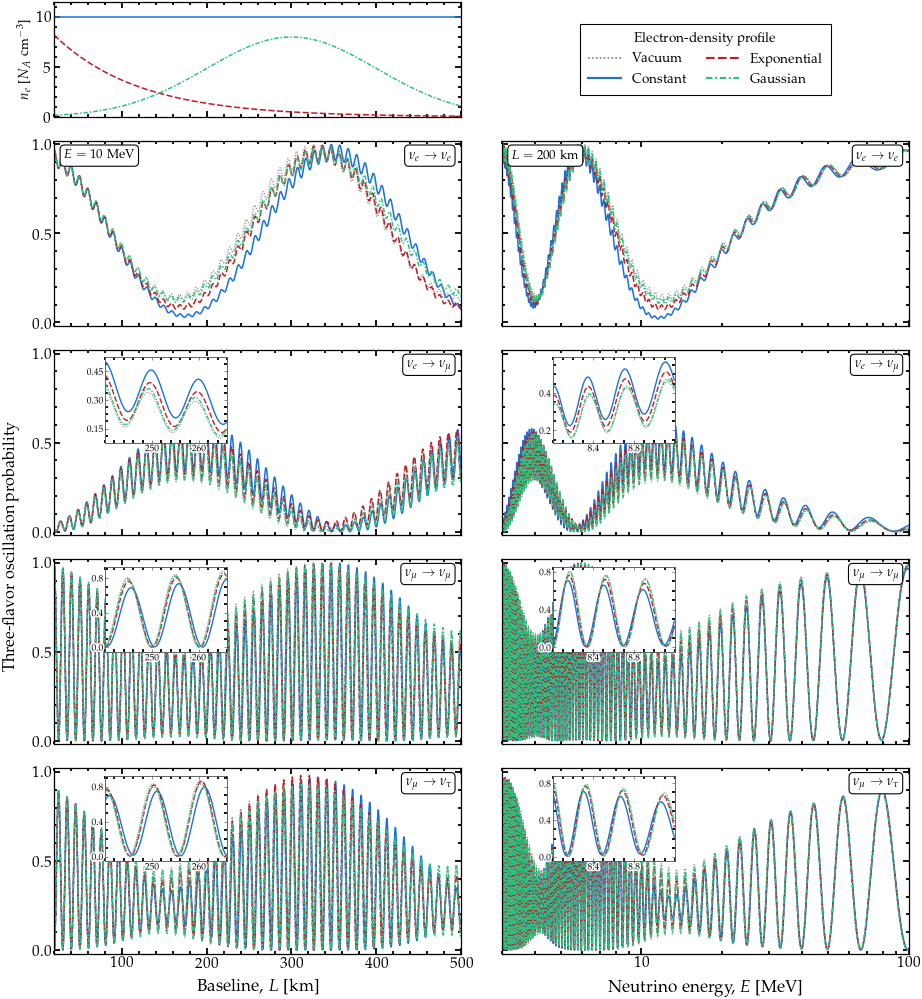

In [18]:
# --- Figure 3g -- drawing it
PV_CH = [(gd.NUE, gd.NUE), (gd.NUE, gd.NUMU), (gd.NUMU, gd.NUMU), (gd.NUMU, gd.NUTAU)]
_FL = {gd.NUE: r'\nu_e', gd.NUMU: r'\nu_\mu', gd.NUTAU: r'\nu_\tau'}
PV_PAIR = {(a, b): r'$%s \to %s$' % (_FL[a], _FL[b]) for a, b in PV_CH}
PV_STYLE = [('vacuum', '0.55', (0, (1, 1.2)), 0.7, 'Vacuum'),
            ('constant', BLUE, '-', 0.85, 'Constant'),
            ('exponential', RED, (0, (4, 1.6)), 0.85, 'Exponential'),
            ('gaussian', GREEN, (0, (3, 1.2, 1, 1.2)), 0.85, 'Gaussian')]
# The lower three channels oscillate too fast to separate at the scale of the panel, so
# each carries an inset over a window where the four curves do separate.
PV_ZOOM = {(gd.NUE, gd.NUMU), (gd.NUMU, gd.NUMU), (gd.NUMU, gd.NUTAU)}
PV_WIN_L, PV_WIN_E = (240.0, 266.0), (8.0, 9.2)
PANEL_H = 1.60

fig = plt.figure(figsize=(WIDE, 1.55 + PANEL_H*len(PV_CH)))
gs = fig.add_gridspec(1 + len(PV_CH), 2, height_ratios=[0.62] + [1]*len(PV_CH),
                      hspace=0.14, wspace=0.10, left=0.075, right=0.985,
                      top=1.0 - 0.05/(1.55 + PANEL_H*len(PV_CH)),
                      bottom=0.58/(1.55 + PANEL_H*len(PV_CH)))
axp = fig.add_subplot(gs[0, 0])
for _key, _col, _ls, _lw, _ in PV_STYLE[1:]:
    _ne = dict(PV_PROFILES)[_key]
    axp.plot(PV_L/gd.UNIT_KM, (_ne(PV_L) if callable(_ne) else np.full(PV_L.shape, _ne))/NA_CM3,
             color=_col, ls=_ls, lw=_lw)
axp.set_xlim(20.0, 500.0); axp.set_ylim(0, 11.5); axp.set_yticks([0, 5, 10])
axp.set_ylabel(r'$n_e$ [$N_A$ cm$^{-3}$]', fontsize=7.5, labelpad=2)
axp.tick_params(labelbottom=False)
axp.xaxis.set_minor_locator(AutoMinorLocator(5)); minor_y(axp, 5)
axl = fig.add_subplot(gs[0, 1]); axl.axis('off')
for _key, _col, _ls, _lw, _lab in PV_STYLE:
    axl.plot([], [], color=_col, ls=_ls, lw=_lw*1.4, label=_lab)
_leg = axl.legend(loc='center', ncol=2, fontsize=7.6, handlelength=2.4, columnspacing=1.4,
                  labelspacing=0.5, frameon=True, edgecolor='black', framealpha=1.0,
                  borderpad=0.6, title='Electron-density profile', title_fontsize=7.6)
_leg.get_frame().set_linewidth(0.6)

pv_axes = []
for _r, (_a, _b) in enumerate(PV_CH):
    axL = fig.add_subplot(gs[_r + 1, 0], sharex=axp)
    axE = fig.add_subplot(gs[_r + 1, 1])
    for _key, _col, _ls, _lw, _ in PV_STYLE:
        axL.plot(PV_L/gd.UNIT_KM, PV_VS_L[_key][:, _a, _b], color=_col, ls=_ls, lw=_lw,
                 rasterized=True)
        axE.semilogx(PV_ES/gd.UNIT_MEV, PV_VS_E[_key][:, _a, _b], color=_col, ls=_ls,
                     lw=_lw, rasterized=True)
    for _ax in (axL, axE):
        _ax.set_ylim(-0.02, 1.02); _ax.set_yticks([0, 0.5, 1.0]); minor_y(_ax, 5)
        corner(_ax, PV_PAIR[(_a, _b)], loc='upper right', x=0.975, y=0.955,
               fontsize=7.2)
    axL.set_xlim(20.0, 500.0); axL.xaxis.set_minor_locator(AutoMinorLocator(5))
    axE.set_xlim(3.0, 100.0); logx(axE)
    axE.xaxis.set_major_formatter(FuncFormatter(_plain))
    axE.tick_params(labelleft=False)
    if _r < len(PV_CH) - 1:
        axL.tick_params(labelbottom=False); axE.tick_params(labelbottom=False)
    if (_a, _b) in PV_ZOOM:
        for _ax, _x, _store, (_x0, _x1) in ((axL, PV_L/gd.UNIT_KM, PV_VS_L, PV_WIN_L),
                                            (axE, PV_ES/gd.UNIT_MEV, PV_VS_E, PV_WIN_E)):
            ins = _ax.inset_axes([0.125, 0.50, 0.30, 0.46])
            _m = (_x >= _x0) & (_x <= _x1)
            for _key, _col, _ls, _lw, _ in PV_STYLE:
                ins.plot(_x[_m], _store[_key][_m, _a, _b], color=_col, ls=_ls, lw=_lw*0.9)
            ins.set_xlim(_x0, _x1)
            _yy = np.concatenate([_store[_key][_m, _a, _b] for _key, *_ in PV_STYLE])
            _pad = 0.06*(_yy.max() - _yy.min())
            ins.set_ylim(_yy.min() - _pad, _yy.max() + _pad)
            ins.xaxis.set_major_locator(MaxNLocator(3, prune='both'))
            ins.yaxis.set_major_locator(MaxNLocator(3, prune='both'))
            ins.tick_params(labelsize=5.2, length=1.5, width=0.4, pad=1.0, color='0.35')
            for _side in ins.spines.values():
                _side.set_linewidth(0.5); _side.set_color('0.35')
            ins.patch.set_alpha(1.0)
            # The tick labels fall outside the inset, over the dense curves of the panel,
            # so each gets a white outline to stay legible.
            for _t in list(ins.get_xticklabels()) + list(ins.get_yticklabels()):
                _t.set_path_effects([pe.withStroke(linewidth=1.8, foreground='white')])
    pv_axes.append((axL, axE))
pv_axes[-1][0].set_xlabel(r'Baseline, $L$ [km]')
pv_axes[-1][1].set_xlabel(r'Neutrino energy, $E$ [MeV]')
corner(pv_axes[0][0], r'$E = 10$ MeV', loc='upper left', x=0.025, y=0.955, fontsize=7.2)
corner(pv_axes[0][1], r'$L = 200$ km', loc='upper left', x=0.025, y=0.955, fontsize=7.2)
# One label for the four probability rows, set just left of the widest tick label so that
# the gap does not change when the panel height does.
fig.canvas.draw()
_rend = fig.canvas.get_renderer()
_x0 = min(t.get_window_extent(_rend).x0 for _pair in pv_axes
          for t in _pair[0].get_yticklabels() if t.get_text())/fig.bbox.width
fig.text(_x0 - 0.10/fig.get_size_inches()[0],
         0.5*(pv_axes[0][0].get_position().y1 + pv_axes[-1][0].get_position().y0),
         r'Three-flavor oscillation probability', rotation=90, ha='right', va='center',
         fontsize=9.0)
fig.savefig(FIGDIR/'prob_vs.pdf', dpi=300)
print('  wrote %s' % (FIGDIR/'prob_vs.pdf'))

## Figure 3f --- a sterile scan over mass splitting and mixing

Six thousand four hundred probabilities per panel, four panels, one comprehension each.
The window is chosen by what the grid resolves rather than by taste: above about
$3$~eV$^2$ the oscillation in $\Delta m^2_{41}$ outruns eighty log-spaced nodes, and the
map would then show aliasing rather than physics. Measured against a four-times finer
grid, the worst swing between adjacent nodes is $0.099$ inside this window and $0.39$
over a full decade.

  sterile_scan_m1_nu read from paper_figure_cache.json, unchanged configuration bf6038be2932 (measured 2026-09-17 on laptop-6)
  sterile_scan_m0p5_nu read from paper_figure_cache.json, unchanged configuration 8f02adc3d10a (measured 2026-09-17 on laptop-6)


  sterile_scan_m1_nubar read from paper_figure_cache.json, unchanged configuration a48502d757da (measured 2026-09-17 on laptop-6)
  sterile_scan_m0p5_nubar read from paper_figure_cache.json, unchanged configuration 55bad0f06edf (measured 2026-09-17 on laptop-6)


  sterile_scan_m1_nu read from paper_figure_cache.json, unchanged configuration bf6038be2932 (measured 2026-09-17 on laptop-6)
  sterile_scan_m0p5_nu read from paper_figure_cache.json, unchanged configuration 8f02adc3d10a (measured 2026-09-17 on laptop-6)


  sterile_scan_m1_nubar read from paper_figure_cache.json, unchanged configuration a48502d757da (measured 2026-09-17 on laptop-6)
  sterile_scan_m0p5_nubar read from paper_figure_cache.json, unchanged configuration 55bad0f06edf (measured 2026-09-17 on laptop-6)
  deepest depletion per panel: -0.267, -0.241, -0.654, -0.865


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/sterile_scan.pdf


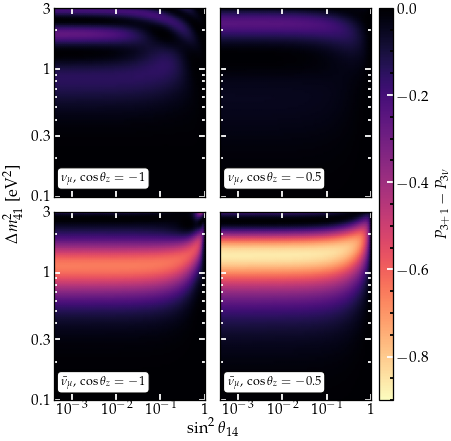

In [19]:
# --- Figure 3f -- the sterile parameter scan
SCAN_N = 80
SCAN_E = 5.0*gd.UNIT_TEV
SCAN_D41 = np.logspace(np.log10(0.1), np.log10(3.0), SCAN_N)
SCAN_S14 = np.logspace(np.log10(0.02), 0.0, SCAN_N)
SCAN_S24 = np.sqrt(0.10)
SCAN_PANELS = [(-1.0, False, r'$\nu_\mu$, $\cos\theta_z = -1$'),
               (-0.5, False, r'$\nu_\mu$, $\cos\theta_z = -0.5$'),
               (-1.0, True,  r'$\bar{\nu}_\mu$, $\cos\theta_z = -1$'),
               (-0.5, True,  r'$\bar{\nu}_\mu$, $\cos\theta_z = -0.5$')]


def sterile_scan(costhz, nubar):
    """P(3+1) - P(3nu) over the plane, for one chord and one sign.

    Cached like every other measured quantity here: 6400 four-flavor Earth
    probabilities per panel is a property of the configuration, not of the run.
    """
    def run():
        L = chord(costhz)
        kw = dict(costhz=costhz, L=L, nu_i=gd.NUMU, nu_f=gd.NUMU, nubar=nubar,
                  rtol=RTOL_FIG, atol=ATOL_FIG)
        std = float(quiet(oscprob.osc_prob_3nu_earth, SCAN_E, **OSC, **kw))
        return [[float(quiet(oscprob.osc_prob_4nu_earth, SCAN_E, s14=s, s24=SCAN_S24,
                             s34=0.0, D41=d, **OSC, **kw)) - std
                 for s in SCAN_S14] for d in SCAN_D41]
    key = ('sterile_scan', float(costhz), bool(nubar), float(SCAN_E), SCAN_N,
           [float(x) for x in SCAN_D41], [float(x) for x in SCAN_S14],
           float(SCAN_S24), RTOL_FIG, ATOL_FIG, sorted(OSC.items()))
    tag = 'sterile_scan_%s_%s' % (('m%g' % abs(costhz)).replace('.', 'p'),
                                  'nubar' if nubar else 'nu')
    return np.asarray(cached(tag, key, run, what='one panel of the sterile scan'))


fig, axes = plt.subplots(2, 2, figsize=(COL, 3.45), sharex=True, sharey=True)
for ax, (cz, nb, label) in zip(axes.ravel(), SCAN_PANELS):
    im = ax.pcolormesh(SCAN_S14**2, SCAN_D41, sterile_scan(cz, nb), cmap='magma_r',
                       vmin=-0.9, vmax=0.0, shading='gouraud', rasterized=True)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim((SCAN_S14**2).min(), (SCAN_S14**2).max())
    ax.set_ylim(SCAN_D41.min(), SCAN_D41.max())
    ax.set_xticks([1e-3, 1e-2, 1e-1, 1.0])
    ax.set_xticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$1$'])
    ax.set_yticks([0.1, 0.3, 1.0, 3.0]); ax.set_yticklabels(['0.1', '0.3', '1', '3'])
    ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    # White on a dark map; the labels stay dark so they read against the page.
    ax.tick_params(which='both', color='white')
    corner(ax, label, loc='lower left', fontsize=7.0, x=0.05, y=0.06)
fig.subplots_adjust(left=0.145, right=0.845, bottom=0.115, top=0.99,
                    wspace=0.10, hspace=0.08)
# One label per direction, centered on the block of panels rather than on the
# canvas, so the colorbar does not pull either off center.
fig.text(0.495, 0.030, r'$\sin^2\theta_{14}$', ha='center', va='bottom', fontsize=9.0)
fig.text(0.032, 0.553, r'$\Delta m^2_{41}$ [eV$^2$]', ha='left', va='center',
         rotation='vertical', fontsize=9.0)
cax = fig.add_axes([0.862, 0.115, 0.032, 0.875])
cb = fig.colorbar(im, cax=cax)
cb.set_label(r'$P_{3+1} - P_{3\nu}$', fontsize=8.5, labelpad=3)
cb.set_ticks([0.0, -0.2, -0.4, -0.6, -0.8])
cb.ax.tick_params(color='white')
print('  deepest depletion per panel: %s'
      % ', '.join('%.3f' % sterile_scan(cz, nb).min() for cz, nb, _ in SCAN_PANELS))
save(fig, 'sterile_scan.pdf')

## Figure 4 --- three oscillograms

**The middle row carries its own energy axis and cannot share the others'.** An eV-scale
sterile splitting over an 11 000 km chord oscillates far too fast at GeV energies for any
grid to represent --- and far too slowly to compute: one row of 200 energies costs 0.56 s
at three flavors and 21 s at 3+1, which is an hour for the panel and aliasing for the
result. At TeV energies the sterile matter resonance is the feature and the panel costs
seconds.

  oscillogram_Earth_3_nu read from paper_figure_cache.json, unchanged configuration 2faf5909e052 (measured 2026-09-12 on laptop-6)
  oscillogram_Earth_3_nu_NSI read from paper_figure_cache.json, unchanged configuration 0d05d7a34a7f (measured 2026-09-12 on laptop-6)


  oscillogram_Earth_3_1 read from paper_figure_cache.json, unchanged configuration 88f9c127fcda (measured 2026-09-12 on laptop-6)


  oscillogram_Earth_3_2 read from paper_figure_cache.json, unchanged configuration f09ccd0d475d (measured 2026-09-12 on laptop-6)


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/earth_oscillogram.pdf


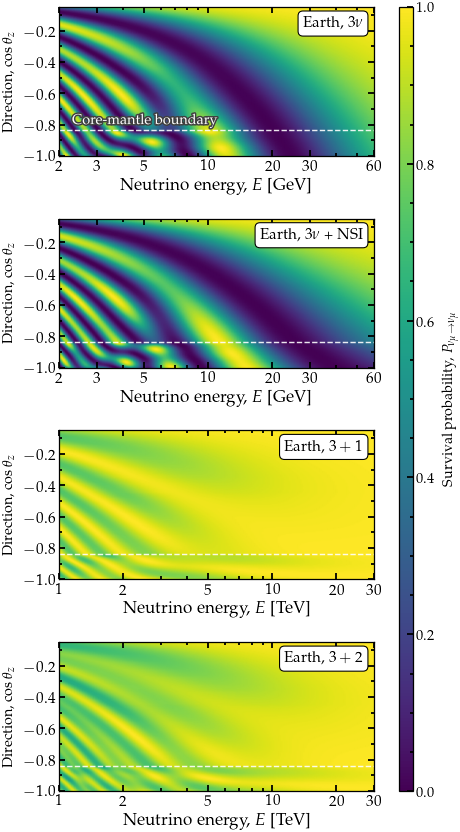

In [20]:
# ------------------------------------------------------- three oscillograms
# Each row carries its own energy window, and it has to.  An eV-scale sterile
# splitting over an 11 000 km chord oscillates far too fast at GeV energies for any
# grid to represent -- and far too slowly to compute: one row of 200 energies costs
# 0.56 s at three flavors and 21 s at 3+1 there, which is an hour for the panel and
# aliasing for the result.  At TeV energies the sterile matter resonance is the
# feature, the phase is small, and the panel costs seconds.
NE, NZ = 200, 170
E_GEV_OSC = np.logspace(np.log10(2.0), np.log10(60.0), NE)*gd.UNIT_GEV
E_TEV_OSC = np.logspace(np.log10(1.0), np.log10(30.0), NE)*gd.UNIT_TEV
CZ = np.linspace(-1.0, -0.05, NZ)
GEV_TICKS, TEV_TICKS = (2, 3, 5, 10, 20, 30, 60), (1, 2, 5, 10, 20, 30)

SCEN = [
    (r'Earth, $3\nu$', E_GEV_OSC, gd.UNIT_GEV, r'Neutrino energy, $E$ [GeV]',
     GEV_TICKS,
     lambda E, cz, Lc: oscprob.osc_prob_3nu_earth(
         E, costhz=cz, L=Lc, nu_i=gd.NUMU, nu_f=gd.NUMU, rtol=RTOL_FIG,
         atol=ATOL_FIG, **OSC)),
    (r'Earth, $3\nu$ + NSI', E_GEV_OSC, gd.UNIT_GEV, r'Neutrino energy, $E$ [GeV]',
     GEV_TICKS,
     lambda E, cz, Lc: oscprob.osc_prob_3nu_earth_nsi(
         E, costhz=cz, L=Lc, nu_i=gd.NUMU, nu_f=gd.NUMU, rtol=RTOL_FIG,
         atol=ATOL_FIG, **OSC, **EPS)),
    (r'Earth, $3+1$', E_TEV_OSC, gd.UNIT_TEV, r'Neutrino energy, $E$ [TeV]',
     TEV_TICKS,
     lambda E, cz, Lc: oscprob.osc_prob_4nu_earth(
         E, costhz=cz, L=Lc, nu_i=gd.NUMU, nu_f=gd.NUMU, rtol=RTOL_FIG,
         atol=ATOL_FIG, **OSC, **STERILE4)),
    # The wrapper takes s25 but has no d25: the phase is not independent there, so we
    # pass the angles and leave every CP phase of the sterile sector at its default.
    (r'Earth, $3+2$', E_TEV_OSC, gd.UNIT_TEV, r'Neutrino energy, $E$ [TeV]',
     TEV_TICKS,
     lambda E, cz, Lc: oscprob.osc_prob_5nu_earth(
         E, costhz=cz, L=Lc, nu_i=gd.NUMU, nu_f=gd.NUMU, rtol=RTOL_FIG,
         atol=ATOL_FIG, **OSC, **STERILE5)),
]

fig, axes = plt.subplots(4, 1, figsize=(COL, 7.3),
                         gridspec_kw=dict(hspace=0.42))
def oscillogram_grid(label, E_ax, call):
    """One panel's worth of probability, computed once and read from disk after.

    Four panels of 170 x 200 points are about three minutes, and every one of those
    points is a function of the configuration rather than of the run.  Cosmetic work on
    this figure -- a tick label, a colorbar -- must not pay for them again.
    """
    def run():
        grid = np.empty((NZ, NE))
        for i, cz in enumerate(CZ):
            grid[i] = np.asarray(quiet(call, E_ax, float(cz), chord(float(cz))))
        return grid.tolist()
    key = ('oscillogram', label, [float(e) for e in E_ax], [float(c) for c in CZ],
           RTOL_FIG, ATOL_FIG, sorted(OSC.items()), sorted(STERILE4.items()),
           sorted(STERILE5.items()), sorted((k, str(v)) for k, v in EPS.items()))
    return np.asarray(cached('oscillogram_%s' % re.sub(r'\W+', '_', label).strip('_'),
                             key, run, what='one oscillogram panel'))


for ax, (label, E_ax, unit, xlabel, ticks, call) in zip(axes, SCEN):
    grid = oscillogram_grid(label, E_ax, call)
    im = ax.pcolormesh(E_ax/unit, CZ, grid, cmap='viridis', vmin=0.0, vmax=1.0,
                       shading='gouraud', rasterized=True)
    logx(ax); snug(ax, E_ax/unit); xticks_at(ax, ticks)
    ax.set_ylim(CZ.min(), CZ.max())
    ax.set_yticks(np.arange(-1.0, 0.0, 0.2)); minor_y(ax, 2)
    ax.set_ylabel(r'Direction, $\cos\theta_z$', fontsize=8.0)
    ax.set_xlabel(xlabel, labelpad=1.5)
    ax.axhline(-0.837, color='w', lw=0.8, ls='--', alpha=0.9)
    corner(ax, label, fontsize=8.5)
axes[0].text(2.3, -0.822, 'Core-mantle boundary', color='white', fontsize=8.0,
             va='bottom', path_effects=[pe.withStroke(linewidth=1.6, foreground='0.25')])
# aspect follows the panel count, so the bar is as tall as the stack beside it.
cb = fig.colorbar(im, ax=list(axes), pad=0.07, fraction=0.045, aspect=56)
cb.set_label(r'Survival probability, $P_{\nu_\mu \to \nu_\mu}$', fontsize=8.0)
cb.ax.tick_params(labelsize=8.0)
save(fig, 'earth_oscillogram.pdf')

## Figure 4b --- four chords from Fermilab

Notebook 4's beam, sent from Fermilab to four named sites. The Earth wrapper takes the two
names, derives the chord and its direction from them, and places slab edges wherever the
chord crosses a PREM shell boundary, with the layered composition of Fig. 4. The energies
are those of a long-baseline beam.

  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/named_baselines.pdf


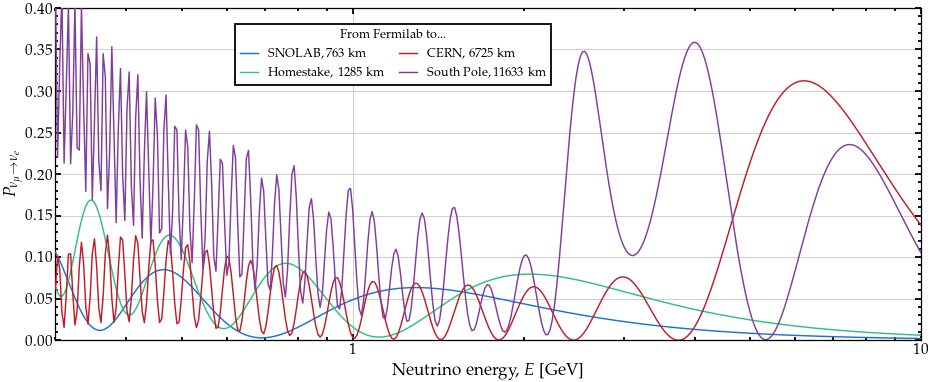

In [21]:
# ------------------------------------------------ four chords from Fermilab
# Notebook 4's beam, sent from Fermilab to four named sites.  The Earth wrapper takes the
# two names, derives the chord and its direction from them, and places slab edges wherever
# the chord crosses a PREM shell boundary; the composition is the layered default of Fig. 4.
SITES = (('SNOLAB', 'snolab', BLUE), ('Homestake', 'homestake', GREEN),
         ('CERN', 'cern', RED), ('South Pole', 'south_pole', PURPLE))
E_BEAM_GEV = np.logspace(np.log10(0.3), np.log10(10.0), 400)

fig, ax = plt.subplots(figsize=(WIDE, 3.0))
for site_label, site, color in SITES:
    here, there = earth.loc_coords_dms['fermilab'], earth.loc_coords_dms[site]
    chord_km = earth.chord_length_inside_earth(here['lat'], here['lon'], there['lat'],
                                               there['lon'])
    P = np.asarray(quiet(oscprob.osc_prob_3nu_earth, E_BEAM_GEV*gd.UNIT_GEV,
                         loc_ini='fermilab', loc_fin=site, nu_i=gd.NUMU, nu_f=gd.NUE,
                         rtol=RTOL_FIG, atol=ATOL_FIG, **OSC))
    ax.plot(E_BEAM_GEV, P, color=color, lw=0.8, zorder=3,
            label=r'%s, $%d$~km' % (site_label, round(chord_km)))
logx(ax)
ax.set_xlim(E_BEAM_GEV[0], E_BEAM_GEV[-1]); ax.set_ylim(0.0, 0.40)
ax.set_xlabel(r'Neutrino energy, $E$ [GeV]', labelpad=2.0)
ax.set_ylabel(r'$P_{\nu_\mu \to \nu_e}$', labelpad=2.0)
ax.grid(True, which='major', color=GRID, lw=0.5); ax.set_axisbelow(True)
ax.legend(loc='upper left', bbox_to_anchor=(0.20, 0.97), ncol=2, fontsize=7.0,
          handlelength=1.4, columnspacing=1.2, borderpad=0.4, title='From Fermilab to...',
          title_fontsize=7.0)
fig.tight_layout(pad=0.4)
save(fig, 'named_baselines.pdf')

## Figure 4c --- a cavity in the Earth's crust

The cavity search of arXiv:1201.6080: a low-energy $\bar{\nu}_e$ beam over $1\,500$~km of
crust, against the same beam with a slab of anomalous density centered on the baseline.
Every cavity has two walls. Every wall is a density jump, so both positions go to
`t_breakpoints`. Leaving them out is not a small error. At a width of $20$~km the
refinement steps over the cavity and returns the empty-crust probability to fourteen
digits, while reporting that it converged to the $10^{-8}$ it was asked for.

  reference peaks at 49.2 MeV, P = 0.9997
  largest shift per cavity: -0.050, +0.039, +0.063, +0.102
  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/cavity.pdf


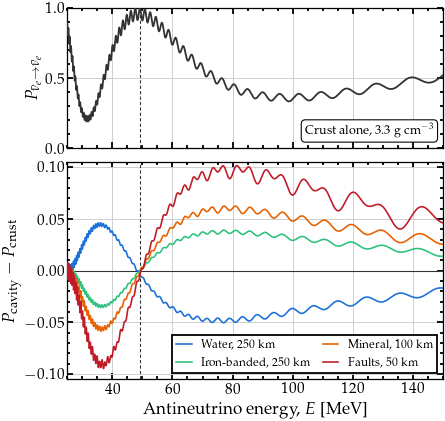

In [22]:
# --------------------------------------------- a cavity in the Earth's crust
# The search of arXiv:1201.6080, done with magnus: a low-energy antineutrino beam over
# 1500 km of crust, against the same beam crossing a slab of anomalous density.  The
# crust is uniform, so the reference needs no profile at all -- the scenario function
# takes a number wherever it takes a function.
CAV_L0 = 1500.0                            # km, source to detector
CAV_RHO_CRUST, CAV_YE_CRUST = 3.3, 0.5     # the outermost PREM layers, averaged
CAV_E = np.linspace(25.0, 150.0, 2500)*gd.UNIT_MEV
CAV_KW = dict(osc_params=OSC, L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE, nubar=True,
              rtol=RTOL_FIG, atol=ATOL_FIG, density_is_of_number_of_electrons=True)
# Water, an iron-banded formation, a mineral deposit, a zone of seismic faults.  The
# widths fall as the density contrast grows, which is how the four were chosen there.
CAVITIES = ((1.0, 0.555, 250.0, BLUE, 'Water, 250 km'),
            (5.0, 0.500, 250.0, GREEN, 'Iron-banded, 250 km'),
            (10.0, 0.500, 100.0, ORANGE, 'Mineral, 100 km'),
            (25.0, 0.500, 50.0, RED, 'Faults, 50 km'))


def cav_ne(rho, ye):
    """Electron density [eV^3] of uniform matter of density rho [g cm^-3]."""
    return matter.num_density_e_func(
        0.0, lambda _: rho, electron_fraction=ye,
        ratio_number_neutrons_to_protons=(1.0-ye)/ye,
        density_matter_is_in_g_per_cm3=True)


NE_CRUST = cav_ne(CAV_RHO_CRUST, CAV_YE_CRUST)


def cav_profile(rho, ye, w):
    """A crust holding one centered cavity, plus the positions of its two walls."""
    d = (CAV_L0 - w)/2.0
    ne_in = cav_ne(rho, ye)

    def profile(l):
        x = np.asarray(l, dtype=float)/gd.UNIT_KM
        return NE_CRUST + (ne_in - NE_CRUST)*((x >= d) & (x <= d + w))

    return profile, np.array([d, d + w])*gd.UNIT_KM


# Twelve thousand five hundred probabilities in under a second: nothing is cached here.
CAV_P0 = np.asarray(quiet(oscprob.osc_prob_matter_std_potential, 3, NE_CRUST, CAV_E,
                          CAV_L0*gd.UNIT_KM, **CAV_KW))
CAV_DP = []
for cav_rho, cav_ye, cav_w, _, _ in CAVITIES:
    cav_prof, cav_walls = cav_profile(cav_rho, cav_ye, cav_w)
    CAV_DP.append(np.asarray(quiet(oscprob.osc_prob_matter_std_potential, 3, cav_prof,
                                   CAV_E, CAV_L0*gd.UNIT_KM, t_breakpoints=cav_walls,
                                   **CAV_KW)) - CAV_P0)

CAV_EM = CAV_E/gd.UNIT_MEV
# Every cavity curve crosses zero at the reference maximum.  The probability is
# stationary there, so a change of density cannot move it at first order.
CAV_E_STAT = float(CAV_EM[CAV_P0.argmax()])

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(COL, 3.30), sharex=True,
                               gridspec_kw=dict(height_ratios=[1.0, 1.55]))
for ax in (ax0, ax1):
    ax.axvline(CAV_E_STAT, color=INK, lw=0.6, ls=(0, (3, 2)), zorder=2)
    ax.grid(True, which='major', color=GRID, lw=0.5)
    ax.set_axisbelow(True)
ax0.plot(CAV_EM, CAV_P0, color=INK, lw=1.0, zorder=3)
ax0.set_ylim(0.0, 1.0); ax0.set_yticks([0.0, 0.5, 1.0])
ax0.set_ylabel(r'$P_{\bar{\nu}_e \to \bar{\nu}_e}$', labelpad=2.0)
corner(ax0, r'Crust alone, $3.3$~g~cm$^{-3}$', loc='lower right', fontsize=7.0,
       x=0.975, y=0.07)
for (cav_rho, cav_ye, cav_w, cav_color, cav_label), cav_dP in zip(CAVITIES, CAV_DP):
    ax1.plot(CAV_EM, cav_dP, color=cav_color, lw=0.9, zorder=3, label=cav_label)
ax1.axhline(0.0, color=INK, lw=0.6, zorder=2)
ax1.set_xlim(CAV_EM[0], CAV_EM[-1]); ax1.set_ylim(-0.105, 0.105)
ax1.set_xlabel(r'Antineutrino energy, $E$ [MeV]', labelpad=2.0)
ax1.set_ylabel(r'$P_{\rm cavity} - P_{\rm crust}$', labelpad=2.0)
ax1.legend(loc='lower right', ncol=2, fontsize=6.6, handlelength=1.3,
           columnspacing=1.0, borderpad=0.35)
fig.tight_layout(pad=0.4)
fig.subplots_adjust(hspace=0.08)
print('  reference peaks at %.1f MeV, P = %.4f' % (CAV_E_STAT, CAV_P0.max()))
print('  largest shift per cavity: %s'
      % ', '.join('%+.3f' % d[np.abs(d).argmax()] for d in CAV_DP))
save(fig, 'cavity.pdf')

## Figure 4d --- the beam swept across a buried body

The reorientation of arXiv:1201.6080. The source and the baseline are held fixed and the
beam is turned through an angle $\alpha$, so the chord cuts a different slice of the same
body at every angle. The body here is a sphere, so the width the beam crosses traces a
semicircle in $\alpha$, and the map is that silhouette projected onto the energy--angle
plane. Outside the silhouette the beam misses the body and the change is exactly zero,
which is the one part of the map that needs no calculation at all.

  the body subtends +/- 9.59 deg; widest crossing 250 km
  change in probability from -0.137 to +0.154


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/cavity_sweep.pdf


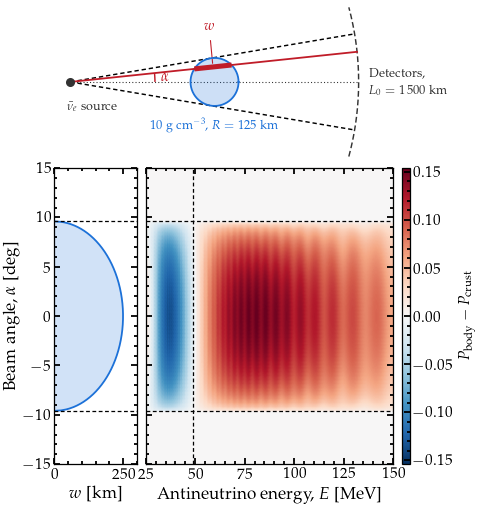

In [23]:
# ----------------------------------------- the beam swept across a buried body
# Hold the source and the 1500 km baseline of the cell above, turn the beam through an
# angle alpha, and let the chord cut a different slice of one buried body.  The body is a
# sphere, so the crossed width traces its silhouette; the map is that silhouette in the
# energy-angle plane.  Where the beam misses, the change is exactly zero by construction.
SWEEP_R, SWEEP_D0 = 125.0, 750.0        # km: the body's radius, and how far along
SWEEP_RHO, SWEEP_YE = 10.0, 0.5         # a heavy mineral deposit
SWEEP_E = np.linspace(25.0, 150.0, 400)*gd.UNIT_MEV
SWEEP_ALPHA = np.linspace(-15.0, 15.0, 220)
SWEEP_NE = cav_ne(SWEEP_RHO, SWEEP_YE)


def sweep_crossing(alpha_deg):
    """Where the beam at this angle enters and leaves the body, in km along the chord."""
    a = np.radians(alpha_deg)
    miss = abs(SWEEP_D0*np.sin(a))
    if miss >= SWEEP_R:
        return None
    half = np.sqrt(SWEEP_R**2 - miss**2)
    mid = SWEEP_D0*np.cos(a)
    return mid - half, mid + half


SWEEP_P0 = np.asarray(quiet(oscprob.osc_prob_matter_std_potential, 3, NE_CRUST, SWEEP_E,
                            CAV_L0*gd.UNIT_KM, **CAV_KW))
SWEEP_DP = np.zeros((len(SWEEP_E), len(SWEEP_ALPHA)))
for sweep_j, sweep_a in enumerate(SWEEP_ALPHA):
    sweep_seg = sweep_crossing(sweep_a)
    if sweep_seg is None:
        continue

    def sweep_profile(l, lo=sweep_seg[0], hi=sweep_seg[1]):
        x = np.asarray(l, dtype=float)/gd.UNIT_KM
        return NE_CRUST + (SWEEP_NE - NE_CRUST)*((x >= lo) & (x <= hi))

    SWEEP_DP[:, sweep_j] = np.asarray(quiet(
        oscprob.osc_prob_matter_std_potential, 3, sweep_profile, SWEEP_E,
        CAV_L0*gd.UNIT_KM, t_breakpoints=np.array(sweep_seg)*gd.UNIT_KM,
        **CAV_KW)) - SWEEP_P0

SWEEP_LIM = max(abs(SWEEP_DP.min()), abs(SWEEP_DP.max()))
SWEEP_A_MAX = np.degrees(np.arcsin(SWEEP_R/SWEEP_D0))
# The silhouette itself: how much body the beam crosses at each angle.  The map's
# envelope in alpha is this curve, which is what the projection means here.
SWEEP_AF = np.linspace(-SWEEP_A_MAX, SWEEP_A_MAX, 400)
SWEEP_WF = 2.0*np.sqrt(np.maximum(
    SWEEP_R**2 - (SWEEP_D0*np.sin(np.radians(SWEEP_AF)))**2, 0.0))

fig = plt.figure(figsize=(COL, 4.30))
# The colorbar takes a column of its own, so the sketch on top can span the panels
# below rather than being pushed off center by it.
sweep_gs = fig.add_gridspec(2, 3, height_ratios=[0.54, 1.0],
                            width_ratios=[1.0, 3.0, 0.10], hspace=0.025, wspace=0.08)

# --- the geometry, drawn to scale: a wedge 1500 km long and 388 km across
axs = fig.add_subplot(sweep_gs[0, :])
SWEEP_Y = CAV_L0*np.sin(np.radians(SWEEP_ALPHA[-1]))
sweep_arc = np.radians(np.linspace(SWEEP_ALPHA[0], SWEEP_ALPHA[-1], 200))
axs.plot(CAV_L0*np.cos(sweep_arc), CAV_L0*np.sin(sweep_arc), color=INK, lw=0.8,
         ls=(0, (4, 2)), zorder=2)
for sweep_s in (-1.0, 1.0):                 # the two beams tangent to the body
    sweep_t = np.radians(sweep_s*SWEEP_A_MAX)
    axs.plot([0.0, CAV_L0*np.cos(sweep_t)], [0.0, CAV_L0*np.sin(sweep_t)],
             color='black', lw=0.8, ls=(0, (3, 2)), zorder=3)
sweep_th = np.linspace(0.0, 2.0*np.pi, 300)
axs.fill(SWEEP_D0 + SWEEP_R*np.cos(sweep_th), SWEEP_R*np.sin(sweep_th), facecolor=BLUE,
         alpha=0.22, lw=0.0, zorder=3)
axs.plot(SWEEP_D0 + SWEEP_R*np.cos(sweep_th), SWEEP_R*np.sin(sweep_th), color=BLUE,
         lw=1.0, zorder=4)
# one beam that clips the body, with the width it crosses drawn on it
SWEEP_A_DRAW = 6.0
sweep_t = np.radians(SWEEP_A_DRAW)
sweep_u = np.array([np.cos(sweep_t), np.sin(sweep_t)])
sweep_h = np.sqrt(SWEEP_R**2 - (SWEEP_D0*np.sin(sweep_t))**2)
sweep_p1 = (SWEEP_D0*np.cos(sweep_t) - sweep_h)*sweep_u
sweep_p2 = (SWEEP_D0*np.cos(sweep_t) + sweep_h)*sweep_u
axs.plot([0.0, CAV_L0*sweep_u[0]], [0.0, CAV_L0*sweep_u[1]], color=RED, lw=1.0, zorder=5)
axs.plot([sweep_p1[0], sweep_p2[0]], [sweep_p1[1], sweep_p2[1]], color=RED, lw=2.8,
         zorder=6, solid_capstyle='butt')
axs.annotate(r'$w$', xy=(0.5*(sweep_p1[0] + sweep_p2[0]), 0.5*(sweep_p1[1] + sweep_p2[1])),
             xytext=(0.5*(sweep_p1[0] + sweep_p2[0]) - 20.0,
                     0.5*(sweep_p1[1] + sweep_p2[1]) + 175.0), fontsize=8.0, color=RED,
             ha='center', va='bottom', arrowprops=dict(arrowstyle='-', color=RED, lw=0.6))
SWEEP_RARC = 440.0
axs.add_patch(mpl.patches.Arc((0.0, 0.0), 2*SWEEP_RARC, 2*SWEEP_RARC, theta1=0.0,
                              theta2=SWEEP_A_DRAW, color=RED, lw=0.8, zorder=5))
axs.annotate(r'$\alpha$', xy=(SWEEP_RARC*np.cos(np.radians(SWEEP_A_DRAW/2)) + 30.0,
                              SWEEP_RARC*np.sin(np.radians(SWEEP_A_DRAW/2))), fontsize=8.5,
             color=RED, ha='left', va='center')
axs.plot([0.0, CAV_L0], [0.0, 0.0], color=INK, lw=0.6, ls=(0, (1, 2)), zorder=2)
axs.plot([0.0], [0.0], marker='o', ms=4.0, color=INK, zorder=7)
axs.annotate(r'$\bar{\nu}_e$ source', xy=(0.0, 0.0), xytext=(-2, -10),
             textcoords='offset points', fontsize=7.0, color=INK, ha='left', va='top')
axs.annotate('Detectors,\n' + r'$L_0 = 1\,500$~km', xy=(CAV_L0, 0.0), xytext=(6, 0),
             textcoords='offset points', fontsize=7.0, color=INK, ha='left', va='center',
             linespacing=1.4)
axs.annotate(r'$10$~g~cm$^{-3}$, $R = 125$~km', xy=(SWEEP_D0, -SWEEP_R), xytext=(0, -7),
             textcoords='offset points', fontsize=7.0, color=BLUE, ha='center', va='top')
axs.set_xlim(-55.0, CAV_L0 + 240.0)
axs.set_ylim(-SWEEP_Y - 30.0, SWEEP_Y + 26.0)
axs.set_aspect('equal'); axs.axis('off')

# --- the silhouette, the map, and the colorbar
axw = fig.add_subplot(sweep_gs[1, 0])
ax = fig.add_subplot(sweep_gs[1, 1], sharey=axw)
cax = fig.add_subplot(sweep_gs[1, 2])
axw.fill_betweenx(SWEEP_AF, 0.0, SWEEP_WF, facecolor=BLUE, alpha=0.20, lw=0.0)
axw.plot(SWEEP_WF, SWEEP_AF, color=BLUE, lw=1.0)
axw.set_xlim(0.0, 300.0); axw.set_xticks([0, 250])
axw.set_xlabel(r'$w$ [km]', labelpad=2.0)
axw.set_ylabel(r'Beam angle, $\alpha$ [deg]', labelpad=2.0)
im = ax.pcolormesh(SWEEP_E/gd.UNIT_MEV, SWEEP_ALPHA, SWEEP_DP.T, cmap='RdBu_r',
                   vmin=-SWEEP_LIM, vmax=SWEEP_LIM, shading='gouraud', rasterized=True)
ax.set_xlabel(r'Antineutrino energy, $E$ [MeV]', labelpad=2.0)
# The stationary point of the cell above: the crust curve peaks there, so no density
# contrast moves the probability at first order and the map changes sign across it.
ax.axvline(float(SWEEP_E[SWEEP_P0.argmax()]/gd.UNIT_MEV), color='black', lw=0.7,
           ls=(0, (3, 2)), zorder=4)
for sweep_ax in (axw, ax):
    for sweep_s in (-1.0, 1.0):
        sweep_ax.axhline(sweep_s*SWEEP_A_MAX, color='black', lw=0.7, ls=(0, (3, 2)),
                         zorder=4)
ax.set_ylim(SWEEP_ALPHA[0], SWEEP_ALPHA[-1])
plt.setp(ax.get_yticklabels(), visible=False)
cb = fig.colorbar(im, cax=cax)
cb.set_label(r'$P_{\rm body} - P_{\rm crust}$', fontsize=8.5, labelpad=3)
print('  the body subtends +/- %.2f deg; widest crossing %.0f km'
      % (SWEEP_A_MAX, SWEEP_WF.max()))
print('  change in probability from %+.3f to %+.3f' % (SWEEP_DP.min(), SWEEP_DP.max()))
save(fig, 'cavity_sweep.pdf')

## Figure 5 --- the Sun: model and observable

The four curves come from the Sun wrappers, which take the BS2005-AGS,OP table by name
(`density_profile='BS05-AGS-OP'`).  For the two sterile cases they also read the
neutron-to-proton ratio from it, $(1 - X)/(1 + X)$ at each radius, where the scenario
functions this figure used before held it at 1; that moves the $3+1$ and $3+2$ curves by
a few $10^{-3}$, and an explicit `ratio_number_neutrons_to_protons` overrides it.  The
standard and NSI curves are unchanged bit for bit.

The check printed under the figure is the adiabatic limit built from the instantaneous
eigenbases alone --- two calls to `eigh` and a contraction, touching none of the package's
averaging machinery, so it works for all four scenarios rather than only the standard
one.  Its detection eigenbasis is taken at the density where the table ends,
$0.98\,R_\odot$, not in vacuum.  Read out in vacuum instead, the reference differs from
the package by up to $10^{-5}$ at 20 MeV, and that is the matter effect of the electrons
still present at the table's last row, not a departure from adiabaticity: the LMA crossing
is adiabatic to $e^{-2000}$ there.  Read out at the edge, the agreement is to machine
precision, which is why the residual panel an earlier version of this figure carried is
gone.

One trap paid for here: `hamiltonian_3nu_nsi` returns $V_{\rm CC}$ times the epsilon matrix
**alone** --- it is zero when every epsilon is --- so the standard matter term has to be
added beside it. Omitting it put this reference 0.178 away from the answer instead of
1e-5, which reads as a spectacular disagreement rather than as a missing term.  The sterile
references take $n_n/n_p$ at each end of the ray from the same table, as the wrappers do.

In [24]:
# The BS2005-AGS,OP table ships with the package, and the Sun wrappers take it by name.
# The columns are read here only to draw the density and to build the reference below.
solar = solarmodels.load_solar_model('BS05-AGS-OP')
r_over_rsun, rho_cgs, x_h = solar['r_over_r_sun'], solar['rho_g_per_cm3'], solar['x_hydrogen']
MEAN_NUCLEON = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
ne_tab = rho_cgs*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*(0.5*(1.0 + x_h))
x_solar = r_over_rsun*gd.SUN_RADIUS*gd.UNIT_KM
log_ne = np.log(ne_tab)
R_SUN = float(x_solar[-1])
assert R_SUN == solarmodels.table_edge('BS05-AGS-OP')


# The same profile the wrappers build, except past the last row, where this one holds the
# edge value and theirs continues the last interval's slope.  Nothing below reaches past it:
# the chords of Figures 5e and 5f run on B16-GS98, which is tabulated to the surface (issue #62).
def ne_sun(l):
    xs = np.clip(np.asarray(l, dtype=float), x_solar[0], x_solar[-1])
    out = np.exp(np.interp(xs, x_solar, log_ne))
    return out[()] if np.ndim(out) == 0 else out


_ne_pkg = solarmodels.electron_density_profile('BS05-AGS-OP')
_inside = np.linspace(0.0, R_SUN, 2001)
assert np.array_equal(ne_sun(_inside), _ne_pkg(_inside))

# The sterile states' neutral-current term needs n_n/n_p; the wrappers read it from the
# same table, (1 - X)/(1 + X), radius by radius.
RATIO_SUN = solarmodels.neutron_to_proton_ratio_profile('BS05-AGS-OP')
RATIO0, RATIO1 = float(RATIO_SUN(0.0)), float(RATIO_SUN(R_SUN))

PER_NE = matter.VCC_func(l=0.0, num_density_e_func=lambda l: 1.0)
print('BS2005-AGS,OP: %d rows, ray 0 to %.0f km; n_e falls by %.1e over it; '
      'n_n/n_p runs %.3f -> %.3f'
      % (len(r_over_rsun), R_SUN/gd.UNIT_KM, ne_tab[0]/ne_tab[-1], RATIO0, RATIO1))


def adiabatic_limit(build_H, energy, vcc0, vcc1, a=gd.NUE, b=gd.NUE):
    r"""The decohered adiabatic limit, from the instantaneous eigenbases alone.

    Decohere in the matter eigenbasis at production, transport along the levels, read
    out in the eigenbasis at the far end of the ray.  This touches none of the package's
    averaging machinery -- two calls to ``eigh`` and a contraction -- so it is an
    independent reference for every scenario rather than only for the standard one,
    where it reduces to the textbook MSW expression.

    ``vcc1`` is the potential where the ray ends.  The table stops at 0.98 R_sun with
    5e20 electrons per cm^3 still there, and a reference read out in vacuum instead
    differs from the package by up to 1e-5 at 20 MeV.  That is the matter effect of the
    edge, not a departure from adiabaticity, and it is what an earlier version of this
    figure drew as a residual panel.

    ``build_H`` also takes n_n/n_p at each end, which only the sterile Hamiltonians read.
    """
    hm = np.asarray(build_H(energy, vcc0, RATIO0), dtype=complex)
    he = np.asarray(build_H(energy, vcc1, RATIO1), dtype=complex)
    _, u_matter = np.linalg.eigh(hm)
    _, u_end = np.linalg.eigh(he)
    return float(np.sum(np.abs(u_matter[a])**2 * np.abs(u_end[b])**2))


OSC4 = dict(OSC); OSC4.update(STERILE4); OSC4.update(d14=0.0, d24=0.0)
OSC5 = dict(OSC); OSC5.update(STERILE5)
OSC5.update(d14=0.0, d24=0.0, d15=0.0, d25=0.0, d35=0.0)
E_AVG = np.logspace(np.log10(0.1), np.log10(20.0), 90)*gd.UNIT_MEV
COMMON = dict(L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE, density_is_of_number_of_electrons=True)
VCC0 = float(PER_NE*ne_sun(0.0))
VCC1 = float(PER_NE*ne_sun(R_SUN))

HV3 = np.asarray(vacuum_hamiltonian(3), dtype=complex)
HV4 = np.asarray(vacuum_hamiltonian(4), dtype=complex)
HV5 = np.asarray(vacuum_hamiltonian(5), dtype=complex)
P3 = np.asarray(matter.matter_potential_projector(3), dtype=complex)
EPS_ORDER = ('eps_ee', 'eps_em', 'eps_et', 'eps_mm', 'eps_mt', 'eps_tt')


def projector(d, ratio):
    return np.asarray(matter.matter_potential_projector(d, ratio), dtype=complex)


# What every Sun wrapper call below shares: the BS2005-AGS,OP table by name, from the
# center to its last row, nu_e to nu_e, the average.  The 5nu wrappers take no d25.
SUN = dict(L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE, average=True, density_profile='BS05-AGS-OP')
OSC5_SUN = {k: v for k, v in OSC5.items() if k != 'd25'}
# The sterile curves read n_n/n_p from the table, so their stored values carry it in their
# key: the entries written when the ratio was held at 1 must not be read back as these.
TABLE_RATIO = ('n_n/n_p from the table', profile_samples(RATIO_SUN, R_SUN))

# 3nu, then the NSI case, then the two steriles: the order the middle panel reads in.
SCEN = [
    (r'$3\nu$', BLUE,
     lambda E: oscprob.osc_prob_3nu_sun(E, R_SUN, **OSC, **SUN),
     lambda E, v, r: HV3/E + v*P3, ()),
    (r'$3\nu$ + NSI', ORANGE,
     lambda E: oscprob.osc_prob_3nu_sun_nsi(E, R_SUN, **OSC, **EPS, **SUN),
     # hamiltonian_3nu_nsi returns V_CC times the epsilon matrix ALONE -- it is zero
     # when every epsilon is -- so the standard matter term has to be added beside it.
     # Omitting it put this reference 0.178 away from the answer rather than 1e-5.
     lambda E, v, r: HV3/E + v*P3 + np.asarray(hamiltonians.hamiltonian_3nu_nsi(
         v, *[EPS[k] for k in EPS_ORDER]), dtype=complex), ()),
    (r'$3+1$', RED,
     lambda E: oscprob.osc_prob_4nu_sun(E, R_SUN, **OSC4, **SUN),
     lambda E, v, r: HV4/E + v*projector(4, r), TABLE_RATIO),
    # Green, not purple: purple marks the resonance densities in the panel above.
    (r'$3+2$', GREEN,
     lambda E: oscprob.osc_prob_5nu_sun(E, R_SUN, **OSC5_SUN, **SUN),
     lambda E, v, r: HV5/E + v*projector(5, r), TABLE_RATIO),
]

BS2005-AGS,OP: 1284 rows, ray 0 to 683929 km; n_e falls by 1.2e+05 over it; n_n/n_p runs 0.466 -> 0.137


  central n_e = 6.13e+25 cm^-3 (the Sun's core is ~6e25)
  solar_3_nu read from paper_figure_cache.json, unchanged configuration 3ed5ef644732 (measured 2026-09-22 on laptop-6)
$3\nu$         P in 0.299-0.545, worst |Magnus - adiabatic| 0.00e+00


  solar_3_nu_NSI read from paper_figure_cache.json, unchanged configuration 98ae2a35e3bd (measured 2026-09-22 on laptop-6)
$3\nu$ + NSI   P in 0.301-0.544, worst |Magnus - adiabatic| 4.61e-15
  solar_3_1 read from paper_figure_cache.json, unchanged configuration e0e6fd92b224 (measured 2026-09-23 on laptop-6)
$3+1$          P in 0.255-0.452, worst |Magnus - adiabatic| 1.11e-16


  solar_3_2 read from paper_figure_cache.json, unchanged configuration 4d5bbfb7d1f7 (measured 2026-09-23 on laptop-6)
$3+2$          P in 0.231-0.403, worst |Magnus - adiabatic| 5.55e-17


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/solar_averaged.pdf


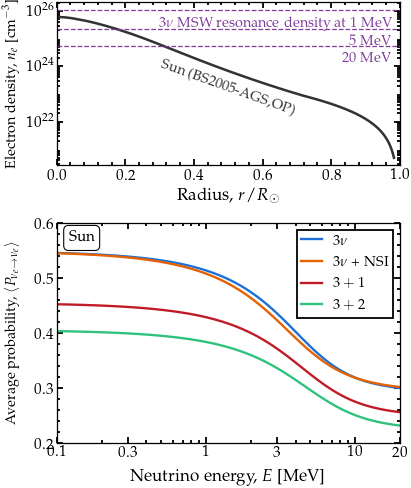

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(COL, 4.1),
                         gridspec_kw=dict(height_ratios=[1.0, 1.35], hspace=0.30))

# --- the model
ax = axes[0]
# The table's own radius column.  R_SUN is the last tabulated radius, 0.983 R_sun, so
# x_solar/R_SUN would stretch the profile to reach the right edge of the panel.
rr = r_over_rsun
# n_e in cm^-3: natural units cube the energy, and nobody quotes a solar electron
# density that way.  gd.UNIT_PER_CM3 is one cm^-3 expressed in eV^3.
PER_CM3 = gd.UNIT_PER_CM3
print('  central n_e = %.2e cm^-3 (the Sun\'s core is ~6e25)' % (ne_tab[0]/PER_CM3))
ax.semilogy(rr, ne_tab/PER_CM3, color=INK, lw=1.4)
cos2th12 = 1.0 - 2.0*OSC['s12']**2
# Staggered horizontally: the three resonance densities are within a decade of each
# other, so labels at a common x sit on top of one another.
# The first label carries the whole statement; the other two need only their energy,
# right-aligned under it so the three read as one column.
LAB = {1.0: r'$3\nu$ MSW resonance density at 1 MeV', 5.0: '5 MeV', 20.0: '20 MeV'}
for Emev in (1.0, 5.0, 20.0):
    nr = OSC['D21']*cos2th12/(2.0*Emev*gd.UNIT_MEV)/PER_NE
    ax.axhline(nr/PER_CM3, color=PURPLE, lw=0.7, ls='--')
    # Under its own line, clear of it: the top line sits at the very top of the panel,
    # so a label placed above it lands outside the axes.
    ax.annotate(LAB[Emev], xy=(0.975, nr/PER_CM3), xytext=(0, -3.5),
                textcoords='offset points', color=PURPLE, fontsize=8.0, ha='right',
                va='top')
logy(ax); ax.set_xlim(0.0, 1.0)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.set_xlabel(r'Radius, $r/R_\odot$', labelpad=1.5)
ax.set_ylabel(r'Electron density, $n_e$ [cm$^{-3}$]', fontsize=8.0)


# --- the averaged observable, checked against the two-eigenbasis reference
for label, color, call, build_H, extra_key in SCEN:
    def run(call=call, build_H=build_H):
        P = np.asarray(quiet(call, E_AVG))
        R = np.array([adiabatic_limit(build_H, e, VCC0, VCC1) for e in E_AVG])
        return dict(P=P.tolist(), R=R.tolist())
    got = cached('solar_%s' % re.sub(r'\W+', '_', label).strip('_'),
                 ('solar', label, [float(e) for e in E_AVG], float(R_SUN),
                  profile_samples(lambda l: PER_NE*ne_sun(l), R_SUN),
                  sorted(OSC.items()), 'reference read out at the table edge') + extra_key,
                 run, what='one averaged solar scenario')
    P, R = np.asarray(got['P']), np.asarray(got['R'])
    axes[1].semilogx(E_AVG/gd.UNIT_MEV, P, color=color, lw=1.3, label=label)
    print('%-14s P in %.3f-%.3f, worst |Magnus - adiabatic| %.2e'
          % (label, P.min(), P.max(), np.abs(P - R).max()))

a = axes[1]
logx(a); snug(a, E_AVG/gd.UNIT_MEV); xticks_at(a, (0.1, 0.3, 1, 3, 10, 20))
a.set_ylim(0.20, 0.60); minor_y(a, 5)
a.set_ylabel(r'Average probability, $\langle P_{\nu_e \to \nu_e}\rangle$',
             fontsize=8.0)
a.set_xlabel(r'Neutrino energy, $E$ [MeV]')
a.legend(loc='upper right', handlelength=1.4)
corner(a, r'Sun', loc='upper left', x=0.035, y=0.965)
fig.subplots_adjust(left=0.20)
fig.align_ylabels(axes)
# Along the curve, and last: label_along reads the slope off transData, so it has to
# run once the axes have their final width.  Called before subplots_adjust, it was
# rotated to an angle the panel no longer had, and the curve cut through the words.
# Anchored by radius, not by index: the model table is sampled far more densely in
# the core, so a fraction of len(rr) lands nowhere near that fraction of the Sun.
label_along(ax, rr, ne_tab/PER_CM3, int(np.searchsorted(rr, 0.30)),
            'Sun (BS2005-AGS,OP)', INK, fontsize=8.0, offset=(0, -13), chord=True)
save(fig, 'solar_averaged.pdf')

## Figure 5c --- three solar models

The same averaged observable on three descriptions of the solar electron density: the
BS2005-AGS,OP table used everywhere else in this notebook, the B16-GS98 table of
Vinyoles et al. (ApJ 835, 202, 2017), and the exponential fit
$n_e = 245\,N_A\,e^{-10.54\,r/R_\odot}$ cm$^{-3}$ that the Sun wrappers use by default.
The two tables agree to a few percent in density and to about $10^{-3}$ in the averaged
probability.  The fit is 2.4 times too dense at the center, and that is the one place
that matters: on an adiabatic passage the average depends on the eigenbases at the two
ends of the ray, and the far end is vacuum.  It moves the curve by up to 0.1.

All three go through the same wrapper, `osc_prob_3nu_sun`: the tables by name, through
`density_profile`, and the fit as its default.  Both tables ship with the package
(`magnus.solarmodels`, which lists the twelve it carries); the B16-GS98 one is the
structure file Aldo Serenelli distributed at `ice.csic.es/personal/aldos/Solar_Data.html`.
The columns are read here only to draw the densities.

In [26]:
B16 = solarmodels.load_solar_model('B16-GS98')
r_b16, rho_b16, x_b16 = B16['r_over_r_sun'], B16['rho_g_per_cm3'], B16['x_hydrogen']
ne_b16_tab = rho_b16*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*(0.5*(1.0 + x_b16))
x_b16_grid = r_b16*gd.SUN_RADIUS*gd.UNIT_KM
log_ne_b16 = np.log(ne_b16_tab)
R_B16 = float(x_b16_grid[-1])
assert R_B16 == solarmodels.table_edge('B16-GS98')


def ne_b16(l):
    xs = np.clip(np.asarray(l, dtype=float), x_b16_grid[0], x_b16_grid[-1])
    out = np.exp(np.interp(xs, x_b16_grid, log_ne_b16))
    return out[()] if np.ndim(out) == 0 else out


R_EXP = gd.SUN_RADIUS*gd.UNIT_KM
r_exp = np.linspace(0.0, 1.0, 801)
ne_exp_tab = gd.NUM_DENSITY_E_SUN_CENTRAL*np.exp(-r_exp*R_EXP/gd.L_SCALE_SUN)
print('B16-GS98: %d rows, ray 0 to %.0f km; central n_e %.2e cm^-3 against %.2e (BS2005)'
      % (len(r_b16), R_B16/gd.UNIT_KM, ne_b16_tab[0]/PER_CM3, ne_tab[0]/PER_CM3))
print('exponential fit: %.2e cm^-3 at the center, %.1f times the table'
      % (ne_exp_tab[0]/PER_CM3, ne_exp_tab[0]/ne_tab[0]))

# All three through the same wrapper: the tables by name, each from the center to its last
# row, and the exponential fit as the wrapper's default.  On a table the wrapper returns bit
# for bit what the scenario call on the same profile does, so the stored curves stand.
MODELS = [
    ('BS05', INK, 'BS2005-AGS,OP (reference)', 1.5, 2, r_over_rsun, ne_tab, R_SUN,
     lambda E: oscprob.osc_prob_3nu_sun(E, R_SUN, **OSC, **SUN),
     lambda l: PER_NE*ne_sun(l)),
    ('B16', BLUE, 'B16-GS98', 1.1, 3, r_b16, ne_b16_tab, R_B16,
     lambda E: oscprob.osc_prob_3nu_sun(E, R_B16, **OSC,
                                        **dict(SUN, density_profile='B16-GS98')),
     lambda l: PER_NE*ne_b16(l)),
    ('exp', ORANGE, 'Exponential fit', 1.1, 4, r_exp, ne_exp_tab, R_EXP,
     lambda E: oscprob.osc_prob_3nu_sun(E, R_EXP, 0.0, **OSC, average=True,
                                        nu_i=gd.NUE, nu_f=gd.NUE),
     lambda l: PER_NE*matter.density_matter_func_exp(l, gd.NUM_DENSITY_E_SUN_CENTRAL,
                                                     gd.L_SCALE_SUN)),
]
P_MODEL = {}
for key, color, label, lw, z, rr_m, ne_m, R_m, call, vcc in MODELS:
    got = cached('solar_model_%s' % key,
                 ('solar model', key, [float(e) for e in E_AVG], float(R_m),
                  profile_samples(vcc, R_m), sorted(OSC.items())),
                 lambda call=call: dict(P=np.asarray(quiet(call, E_AVG)).tolist()),
                 what='one averaged solar curve')
    P_MODEL[key] = np.asarray(got['P'])
for key in ('B16', 'exp'):
    d = P_MODEL[key] - P_MODEL['BS05']
    i = int(np.argmax(np.abs(d)))
    print('%-4s minus BS2005: largest %+.4f at %.2f MeV' % (key, d[i], E_AVG[i]/gd.UNIT_MEV))

B16-GS98: 2000 rows, ray 0 to 695700 km; central n_e 6.07e+25 cm^-3 against 6.13e+25 (BS2005)
exponential fit: 1.48e+26 cm^-3 at the center, 2.4 times the table
  solar_model_BS05 read from paper_figure_cache.json, unchanged configuration 045d9ff7296d (measured 2026-09-22 on laptop-6)


  solar_model_B16 read from paper_figure_cache.json, unchanged configuration ba4c0cc6258e (measured 2026-09-22 on laptop-6)
  solar_model_exp read from paper_figure_cache.json, unchanged configuration 82161fc38d25 (measured 2026-09-22 on laptop-6)
B16  minus BS2005: largest +0.0013 at 4.01 MeV
exp  minus BS2005: largest -0.0985 at 2.49 MeV


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/solar_models.pdf


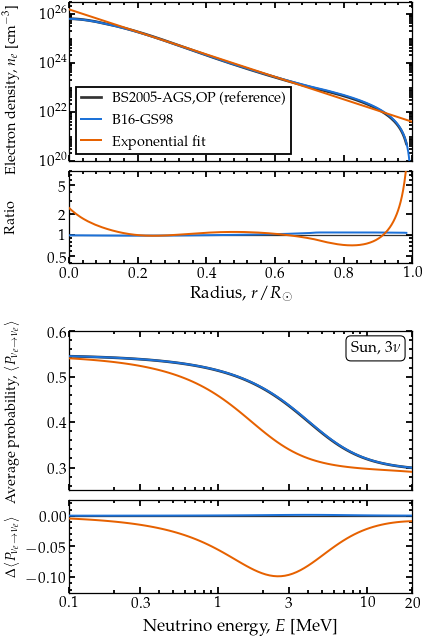

In [27]:
from matplotlib.ticker import FixedLocator

fig = plt.figure(figsize=(COL, 5.5))
outer = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.26)
gs_top = outer[0].subgridspec(2, 1, height_ratios=[1.55, 0.90], hspace=0.08)
gs_bot = outer[1].subgridspec(2, 1, height_ratios=[1.55, 0.90], hspace=0.08)
ax = fig.add_subplot(gs_top[0]); axr = fig.add_subplot(gs_top[1], sharex=ax)
a = fig.add_subplot(gs_bot[0]); ad = fig.add_subplot(gs_bot[1], sharex=a)

# --- the profiles, and their ratio to the reference
for key, color, label, lw, z, rr_m, ne_m, R_m, call, vcc in MODELS:
    ax.semilogy(rr_m, ne_m/PER_CM3, color=color, lw=lw, label=label, zorder=z)
    if key != 'BS05':
        # Only where BS2005 is tabulated: past its last row (0.983 R_sun) the interpolant
        # holds the edge value, and a ratio to that would be an artifact.
        m = rr_m <= r_over_rsun[-1]
        axr.semilogy(rr_m[m], ne_m[m]/ne_sun(rr_m[m]*gd.SUN_RADIUS*gd.UNIT_KM),
                     color=color, lw=lw, zorder=z)
axr.axhline(1.0, color=INK, lw=0.7, zorder=1)
logy(ax); ax.set_ylim(1e20, 3e26); ax.tick_params(labelbottom=False)
# Centered a little below the panel's midpoint: the label is longer than the panel is
# tall, and centered on it the closing bracket ran past the top edge of the figure.
ax.set_ylabel(r'Electron density, $n_e$ [cm$^{-3}$]', fontsize=8.0, y=0.45)
ax.legend(loc='lower left', handlelength=1.4)
axr.set_yscale('log'); axr.set_ylim(0.4, 8.0)
axr.yaxis.set_major_locator(FixedLocator([0.5, 1, 2, 5]))
axr.yaxis.set_major_formatter(FuncFormatter(_plain))
axr.yaxis.set_minor_locator(LogLocator(base=10.0, subs=(2., 3., 4., 5., 6., 7., 8., 9.),
                                       numticks=100))
axr.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ''))
axr.set_xlim(0.0, 1.0); axr.xaxis.set_minor_locator(AutoMinorLocator(5))
axr.set_xlabel(r'Radius, $r/R_\odot$', labelpad=1.5)
axr.set_ylabel('Ratio', fontsize=8.0)

# --- the observable, and its difference from the reference
for key, color, label, lw, z, rr_m, ne_m, R_m, call, vcc in MODELS:
    a.semilogx(E_AVG/gd.UNIT_MEV, P_MODEL[key], color=color, lw=lw, label=label, zorder=z)
    if key != 'BS05':
        ad.semilogx(E_AVG/gd.UNIT_MEV, P_MODEL[key] - P_MODEL['BS05'], color=color, lw=lw,
                    zorder=z)
ad.axhline(0.0, color=INK, lw=0.7, zorder=1)
logx(a); snug(a, E_AVG/gd.UNIT_MEV); xticks_at(a, (0.1, 0.3, 1, 3, 10, 20))
a.tick_params(labelbottom=False)
a.set_ylim(0.25, 0.60); minor_y(a, 5)
a.set_ylabel(r'Average probability, $\langle P_{\nu_e \to \nu_e}\rangle$', fontsize=8.0)
corner(a, r'Sun, $3\nu$', loc='upper right', y=0.94)
logx(ad); snug(ad, E_AVG/gd.UNIT_MEV); xticks_at(ad, (0.1, 0.3, 1, 3, 10, 20))
ad.set_ylim(-0.125, 0.025); ad.yaxis.set_major_locator(FixedLocator([-0.1, -0.05, 0.0]))
minor_y(ad, 5)
ad.set_xlabel(r'Neutrino energy, $E$ [MeV]')
ad.set_ylabel(r'$\Delta \langle P_{\nu_e \to \nu_e} \rangle$', fontsize=8.0)
fig.subplots_adjust(left=0.20)
# One column of labels: each panel would otherwise set its own label just outside its
# own tick labels, and four panels with tick labels of four widths give four positions.
fig.align_ylabels([ax, axr, a, ad])
save(fig, 'solar_models.pdf')

## Figure 5d --- the averaged probability against the production radius

The same observable as Figure 5, with the production point moved instead of the energy:
`L0` runs from the center to $0.8\,R_\odot$ at 1, 5 and 20 MeV, standard and with the NSI
of Figure 5.  Each curve steps from its matter value to the vacuum value at the radius
where the resonance density of that energy meets the profile, which is the statement that
on an adiabatic passage only the density at production enters.

The shaded band is where 90% of the $^8$B neutrinos are made: the 5th to 95th percentile
of the production distribution of the same BS2005-AGS,OP model, from Bahcall's
`bs2005agsopflux` file (astro-ph/0412440), kept beside the structure table.

In [28]:
FLUX = os.path.join('..', 'docs', 'dev', 'adversarial_batteries', 'bs2005agsopflux.csv')
frac = []
with open(FLUX) as fh:
    for line in fh:
        f = line.split()
        if len(f) == 13:
            try:
                frac.append([float(x) for x in f])
            except ValueError:
                continue
frac = np.array(frac)
# Columns: radius, T, log10(n_e/N_A), mass, X(7Be), then the fraction of each flux made in
# the zone: pp, 8B, 13N, 15O, 17F, 7Be, pep, hep.
cum_b8 = np.cumsum(frac[:, 6])/frac[:, 6].sum()
B8_BAND = tuple(float(np.interp(q, cum_b8, frac[:, 0])) for q in (0.05, 0.95))
print('90%% of the 8B neutrinos are made between %.3f and %.3f R_sun' % B8_BAND)

R0 = np.linspace(0.0, 0.8, 41)*gd.SUN_RADIUS*gd.UNIT_KM
PROD_E = (1.0, 5.0, 20.0)
P_PROD = {}
for Emev in PROD_E:
    E = Emev*gd.UNIT_MEV
    def run(E=E):
        std = [float(quiet(oscprob.osc_prob_3nu_sun, E, R_SUN, **OSC,
                           **dict(SUN, L0=float(l0)))) for l0 in R0]
        nsi = [float(quiet(oscprob.osc_prob_3nu_sun_nsi, E, R_SUN, **OSC, **EPS,
                           **dict(SUN, L0=float(l0)))) for l0 in R0]
        return dict(std=std, nsi=nsi)
    got = cached('solar_production_%gMeV' % Emev,
                 ('solar production radius', float(E), [float(l0) for l0 in R0],
                  float(R_SUN), profile_samples(lambda l: PER_NE*ne_sun(l), R_SUN),
                  sorted(OSC.items()),
                  sorted((k, float(np.real(v)), float(np.imag(v))) for k, v in EPS.items())),
                 run, what='one energy, both scenarios, along the production radius')
    P_PROD[Emev] = {k: np.asarray(v) for k, v in got.items()}
    print('%4.0f MeV: %.3f at the center -> %.3f at 0.8 R_sun; NSI moves it by up to %.4f'
          % (Emev, P_PROD[Emev]['std'][0], P_PROD[Emev]['std'][-1],
             np.abs(P_PROD[Emev]['nsi'] - P_PROD[Emev]['std']).max()))

90% of the 8B neutrinos are made between 0.018 and 0.090 R_sun
  solar_production_1MeV read from paper_figure_cache.json, unchanged configuration 6f8b7f27e640 (measured 2026-09-22 on laptop-6)
   1 MeV: 0.513 at the center -> 0.548 at 0.8 R_sun; NSI moves it by up to 0.0058


  solar_production_5MeV read from paper_figure_cache.json, unchanged configuration 889fc4e83662 (measured 2026-09-22 on laptop-6)
   5 MeV: 0.375 at the center -> 0.548 at 0.8 R_sun; NSI moves it by up to 0.0124
  solar_production_20MeV read from paper_figure_cache.json, unchanged configuration 4d2caf43c2a8 (measured 2026-09-22 on laptop-6)
  20 MeV: 0.299 at the center -> 0.548 at 0.8 R_sun; NSI moves it by up to 0.0124


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/solar_production.pdf


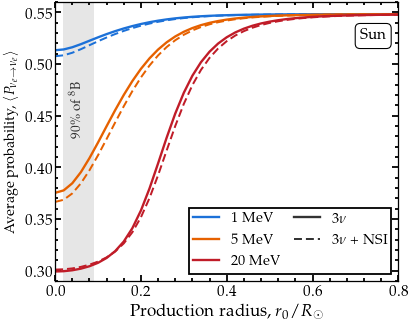

In [29]:
fig, ax = plt.subplots(figsize=(COL, 2.6))
r0 = R0/(gd.SUN_RADIUS*gd.UNIT_KM)
# The band under the curves, labeled upright inside it, in the gap between the 1 and
# 5 MeV curves.
ax.axvspan(B8_BAND[0], B8_BAND[1], color='#e6e6e6', lw=0, zorder=0)
ax.text(0.5*(B8_BAND[0] + B8_BAND[1]), 0.4565, r'$90\%$ of $^8$B', ha='center', va='center',
        rotation=90, fontsize=7.5, color=INK)
for Emev, color in zip(PROD_E, (BLUE, ORANGE, RED)):
    ax.plot(r0, P_PROD[Emev]['std'], color=color, lw=1.3, label=r'$%g$ MeV' % Emev)
    ax.plot(r0, P_PROD[Emev]['nsi'], color=color, lw=1.1, ls=(0, (4, 2)))
ax.plot([], [], color=INK, lw=1.3, label=r'$3\nu$')
ax.plot([], [], color=INK, lw=1.1, ls=(0, (4, 2)), label=r'$3\nu$ + NSI')
ax.set_xlim(0.0, 0.8); ax.set_ylim(0.29, 0.56)
ax.xaxis.set_minor_locator(AutoMinorLocator(5)); minor_y(ax, 5)
ax.set_xlabel(r'Production radius, $r_0/R_\odot$', labelpad=1.5)
ax.set_ylabel(r'Average probability, $\langle P_{\nu_e \to \nu_e}\rangle$', fontsize=8.0)
ax.legend(loc='lower right', handlelength=1.8, ncol=2, columnspacing=1.0)
# Just under the plateau of the curves, clear of the legend below.
corner(ax, r'Sun', loc='upper right', y=0.905)
fig.subplots_adjust(left=0.20)
save(fig, 'solar_production.pdf')

## Figure 5j --- the two-flavor approximation, priced

Most solar analyses solve the 1-2 sector alone on a density scaled by $\cos^2\theta_{13}$
and fold $\theta_{13}$ back in as
$\langle P\rangle^{\rm approx}_{2\nu} = \sin^4\theta_{13} + \cos^4\theta_{13}\,P^{2\nu}$
(Kuo & Pantaleone 1989).  Exact in vacuum; in matter it drops terms of relative size
$2EV_{\rm CC}/\Delta m^2_{31}$ times the $\sin^2\theta_{13}$ admixture.  This cell evaluates
them on the three profiles of Figure 5c: the two-flavor side is the averaged scenario call at
two flavors on the rescaled density, taken from the profile the wrappers build (a wrapper
takes a model by name, and so cannot rescale it); the three-flavor side is the curve of
Figure 5c, read from its cache.  The fit's error is about three times the tables', because its central
density is 2.4 times theirs and the dropped terms scale with it.

In [30]:
C13 = 1.0 - OSC['s13']**2   # cos^2 theta_13
TWO = dict(sth=OSC['s12'], Dm2=OSC['D21'])
# The two-flavor side needs the density itself, to rescale it, so it takes the profile the
# wrappers build from each table (or the fit) and goes through the scenario function.
NE_PROFILE = {
    'BS05': solarmodels.electron_density_profile('BS05-AGS-OP'),
    'B16': solarmodels.electron_density_profile('B16-GS98'),
    'exp': lambda l: matter.density_matter_func_exp(l, gd.NUM_DENSITY_E_SUN_CENTRAL,
                                                    gd.L_SCALE_SUN),
}
REL = {}
for key, color, label, lw, z, rr_m, ne_m, R_m, call, vcc in MODELS:
    ne_fn = NE_PROFILE[key]
    got = cached('solar_two_flavor_%s' % key,
                 ('solar two-flavor reduction', key, [float(e) for e in E_AVG], float(R_m),
                  profile_samples(lambda l, ne_fn=ne_fn: PER_NE*C13*ne_fn(l), R_m),
                  sorted(OSC.items())),
                 lambda ne_fn=ne_fn, R_m=R_m: dict(P2=np.asarray(quiet(
                     oscprob.osc_prob_matter_std_potential, 2,
                     lambda l: C13*ne_fn(l), E_AVG, R_m, TWO, average=True,
                     **COMMON)).tolist()),
                 what='the two-flavor solar curve on the rescaled density')
    P_APPROX = OSC['s13']**4 + C13**2*np.asarray(got['P2'])
    REL[key] = (P_APPROX - P_MODEL[key])/P_MODEL[key]
    print('%-4s relative error %.1e at 0.1 MeV, %.1e at 1 MeV, %.1e at 5 MeV, %.1e at 20 MeV;'
          ' above the three-flavor result everywhere: %s'
          % ((key,) + tuple(REL[key][int(np.argmin(np.abs(E_AVG/gd.UNIT_MEV - x)))]
                            for x in (0.1, 1.0, 5.0, 20.0)) + (bool(np.all(REL[key] > 0.0)),)))

  solar_two_flavor_BS05 read from paper_figure_cache.json, unchanged configuration e4b4e7874727 (measured 2026-09-22 on laptop-6)
BS05 relative error 2.7e-05 at 0.1 MeV, 2.6e-04 at 1 MeV, 1.2e-03 at 5 MeV, 6.2e-03 at 20 MeV; above the three-flavor result everywhere: True
  solar_two_flavor_B16 read from paper_figure_cache.json, unchanged configuration e39b6e7162b5 (measured 2026-09-22 on laptop-6)
B16  relative error 2.6e-05 at 0.1 MeV, 2.6e-04 at 1 MeV, 1.2e-03 at 5 MeV, 6.1e-03 at 20 MeV; above the three-flavor result everywhere: True


  solar_two_flavor_exp read from paper_figure_cache.json, unchanged configuration f7df9c3e316a (measured 2026-09-22 on laptop-6)
exp  relative error 6.4e-05 at 0.1 MeV, 5.9e-04 at 1 MeV, 3.4e-03 at 5 MeV, 2.1e-02 at 20 MeV; above the three-flavor result everywhere: True


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/solar_approx.pdf


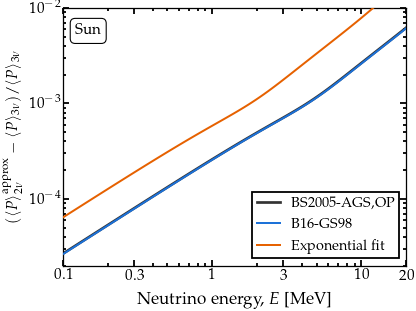

In [31]:
fig, ax = plt.subplots(figsize=(COL, 2.4))
for key, color, label, lw, z, rr_m, ne_m, R_m, call, vcc in MODELS:
    ax.loglog(E_AVG/gd.UNIT_MEV, REL[key], color=color, lw=lw, label=label.replace(' (reference)', ''),
              zorder=z)
logx(ax); logy(ax); snug(ax, E_AVG/gd.UNIT_MEV); xticks_at(ax, (0.1, 0.3, 1, 3, 10, 20))
# The fit's curve leaves the panel above 10 MeV, at 2% by 20 MeV: the axis stops where
# the tables' curves are still legible.
ax.set_ylim(2e-5, 1e-2)
ax.set_xlabel(r'Neutrino energy, $E$ [MeV]')
ax.set_ylabel(r'$(\langle P\rangle^{\rm approx}_{2\nu} - \langle P\rangle_{3\nu})'
              r'/\langle P\rangle_{3\nu}$', fontsize=8.5)
ax.legend(loc='lower right', handlelength=1.6)
corner(ax, r'Sun', loc='upper left', x=0.035, y=0.94)
fig.subplots_adjust(left=0.20)
save(fig, 'solar_approx.pdf')

### Figure 5b --- a Hamiltonian the package never heard of

A gauged $L_e - L_\mu$ symmetry adds a long-range potential sourced by the electrons of the
Sun itself. Nothing about it is built in: the Hamiltonian is a callable returning a Hermitian
matrix, the vacuum and matter terms from the shipped builders plus the new term, and the
averaged probability comes from `average=True` on the direct route,
`osc_prob_energy_baseline`, the same keyword the wrappers take.

L_e - L_mu, 1/m = 1.0 R_sun: V_new/V_CC = 0.100 at the center, 2.4884 at 0.5 R_sun
L_e - L_mu, 1/m = 0.1 R_sun: V_new/V_CC = 0.100 at the center, 0.3799 at 0.5 R_sun


  solar_long_range read from paper_figure_cache.json, unchanged configuration 1f99156f0092 (measured 2026-09-22 on laptop-6)
  P_ee standard 0.299-0.545
    1/m = 1.0 R_sun: 0.318-0.544, largest shift 0.021
    1/m = 0.1 R_sun: 0.297-0.544, largest shift 0.018


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/solar_long_range.pdf


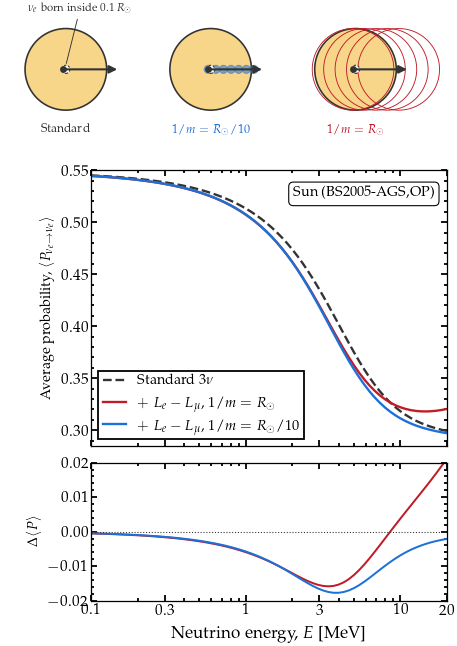

In [32]:
# ------------------------------------------------ Figure 5b: L_e - L_mu in the Sun
def running_integral(y, x):
    """Trapezoidal running integral of y over x, zero at the first node."""
    return np.concatenate([[0.0], np.cumsum(0.5*(y[1:] + y[:-1])*np.diff(x))])


def shc(x):
    """sinh(x)/x, continued to 1 at the origin."""
    x = np.asarray(x, dtype=float)
    out = np.ones_like(x)
    big = np.abs(x) > 1.0e-8
    out[big] = np.sinh(x[big])/x[big]
    return out


def long_range_potential(r_grid, ne_grid, m):
    """V_{e-mu}(r) on r_grid, in units of g'^2, for a spherical n_e(r)."""
    inner = r_grid**2*ne_grid*shc(m*r_grid)
    outer = r_grid*ne_grid*np.exp(-m*r_grid)
    I_in = running_integral(inner, r_grid)
    running_out = running_integral(outer, r_grid)
    I_out = running_out[-1] - running_out
    r_safe = np.where(r_grid > 0.0, r_grid, 1.0e-30)
    return np.exp(-m*r_grid)*I_in/r_safe + shc(m*r_grid)*I_out


LR_CHARGE = np.diag([1.0, -1.0, 0.0]).astype(complex)      # the L_e - L_mu charge
# Two mediator ranges: the solar radius, the analogue of 1/m = R_earth in notebook 19,
# and a tenth of it.  The shorter range samples the profile where it is steepest, so the
# two are not a rescaling of each other.
LR_RANGES = [(1.0, r'$1/m = R_\odot$', RED),
             (0.1, r'$1/m = R_\odot/10$', BLUE)]
V_LR = {}
G2 = {}
for frac, _, _ in LR_RANGES:
    V_LR[frac] = long_range_potential(x_solar, ne_tab, 1.0/(frac*R_SUN))
    # g'^2 fixed so the new potential is a tenth of V_CC at the center in each case,
    # which is what makes the two curves comparable.
    G2[frac] = 0.1*VCC0/V_LR[frac][0]
    print('L_e - L_mu, 1/m = %.1f R_sun: V_new/V_CC = %.3f at the center, %.4f at 0.5 R_sun'
          % (frac, G2[frac]*V_LR[frac][0]/VCC0,
             G2[frac]*np.interp(0.5*R_SUN, x_solar, V_LR[frac])
             / float(PER_NE*ne_sun(0.5*R_SUN))))


def vcc_sun(l):
    """V_CC along the ray, on the tabulated model; takes an array of positions."""
    return PER_NE*ne_sun(l)


def H_lr(frac=None):
    """The solar Hamiltonian as H(E, l): the vacuum and matter terms from the shipped
    builders, plus the long-range term when a mediator range is given.  Written for an
    array of positions, so the engine evaluates it once per slab."""
    def f(E, l):
        h = HV3/E + hamiltonians.hamiltonian_3nu_matter_td(l, vcc_sun)
        if frac is not None:
            v = G2[frac]*np.interp(l, x_solar, V_LR[frac])
            h = h + np.asarray(v)[..., None, None]*LR_CHARGE
        return h
    return f


E_LR = np.logspace(np.log10(0.1), np.log10(20.0), 70)*gd.UNIT_MEV


def _lri_sweep():
    # average=True on the direct route: the closed form, the adiabatic transport or the
    # window average, decided from the Hamiltonian, exactly as behind the wrappers.
    def sweep(frac):
        return np.asarray(quiet(oscprob.osc_prob_energy_baseline, H_lr(frac), E_LR, R_SUN,
                                0.0, nu_i=gd.NUE, nu_f=gd.NUE, average=True)).tolist()
    out = {'std': sweep(None)}
    for frac, _, _ in LR_RANGES:
        out['%g' % frac] = sweep(frac)
    return out


_got = cached('solar_long_range',
              ('lri', 'average=True on osc_prob_energy_baseline', [float(e) for e in E_LR],
               float(R_SUN), [f for f, _, _ in LR_RANGES],
               {'%g' % f: float(G2[f]) for f, _, _ in LR_RANGES}, sorted(OSC.items())),
              _lri_sweep, what='the long-range solar sweep')
P_std = np.asarray(_got['std'])
P_lr = {frac: np.asarray(_got['%g' % frac]) for frac, _, _ in LR_RANGES}
print('  P_ee standard %.3f-%.3f' % (P_std.min(), P_std.max()))
for frac, lab, _ in LR_RANGES:
    print('    1/m = %.1f R_sun: %.3f-%.3f, largest shift %.3f'
          % (frac, P_lr[frac].min(), P_lr[frac].max(),
             np.max(np.abs(P_lr[frac] - P_std))))

from matplotlib.patches import Circle
# The data panels are inset to leave room for their y-labels; the diagram above them is
# given its own axes so that it can span the full column, as a schematic should.
fig = plt.figure(figsize=(COL, 5.15))
_gs = fig.add_gridspec(2, 1, height_ratios=[2.0, 1.0], hspace=0.08,
                       left=0.20, right=0.985, bottom=0.072, top=0.715)
axes = [fig.add_subplot(_gs[0]), None]
axes[1] = fig.add_subplot(_gs[1], sharex=axes[0])
axd = fig.add_axes([0.005, 0.735, 0.99, 0.255])

# What each mediator range lets the neutrino feel.  The charged-current potential is
# local, so the standard case carries no disc at all; a Yukawa term of range 1/m lets
# the neutrino feel every electron within that distance, which at 1/m = R_sun is most
# of the Sun at once and reaches past its surface.
axd.set_xlim(-1.55, 9.45); axd.set_ylim(-1.62, 1.52)
axd.set_aspect('equal'); axd.axis('off')
SUN_FILL = '#f7d68a'
R_D, CX_D, PROD_D = 1.0, [0.0, 3.55, 7.10], -0.06
for _cx, (_rng, _col, _lab) in zip(CX_D, [(None, INK, r'Standard'),
                                          (0.10, BLUE, r'$1/m = R_\odot/10$'),
                                          (1.00, RED,  r'$1/m = R_\odot$')]):
    axd.add_patch(Circle((_cx, 0), R_D, facecolor=SUN_FILL, edgecolor=INK, lw=0.9, zorder=2))
    if _rng is not None:
        # The long-range discs are outlines: filled at this radius they hide the Sun.
        for _s in np.linspace(PROD_D, 1.06, 7 if _rng < 0.5 else 5):
            axd.add_patch(Circle((_cx + _s, 0), _rng*R_D,
                                 facecolor=_col if _rng < 0.5 else 'none',
                                 alpha=0.55 if _rng < 0.5 else 1.0,
                                 edgecolor=_col, lw=0.5, zorder=5))
    axd.add_patch(Circle((_cx, 0), 0.10*R_D, facecolor='white', edgecolor=INK, lw=0.6,
                         ls=(0, (2.2, 1.6)), zorder=6))
    axd.annotate('', xy=(_cx + 1.26, 0), xytext=(_cx + PROD_D, 0), zorder=8,
                 arrowprops=dict(arrowstyle='-|>', color=INK, lw=1.15, shrinkA=0, shrinkB=0))
    axd.plot([_cx + PROD_D], [0], marker='o', ms=2.8, color=INK, zorder=9)
    axd.text(_cx, -1.34, _lab, ha='center', va='top', fontsize=6.8, color=_col)
axd.annotate(r'$\nu_e$ born inside $0.1\,R_\odot$', xy=(CX_D[0], 0.10),
             xytext=(CX_D[0] + 0.35, 1.36), ha='center', va='bottom', fontsize=6.3,
             color=INK, arrowprops=dict(arrowstyle='-', color=INK, lw=0.5,
                                        shrinkA=1, shrinkB=1))

a = axes[0]
a.semilogx(E_LR/gd.UNIT_MEV, P_std, color=INK, lw=1.3, ls='--', label=r'Standard $3\nu$')
for frac, lab, col in LR_RANGES:
    a.semilogx(E_LR/gd.UNIT_MEV, P_lr[frac], color=col, lw=1.3,
               label=r'$+\;L_e - L_\mu$,  ' + lab)
logx(a); snug(a, E_LR/gd.UNIT_MEV); xticks_at(a, (0.1, 0.3, 1, 3, 10, 20))
a.set_ylabel(r'Average probability, $\langle P_{\nu_e \to \nu_e}\rangle$', fontsize=8.0)
a.set_ylim(top=0.55)
a.tick_params(labelbottom=False); minor_y(a, 5)
a.legend(loc='lower left', handlelength=1.6)
corner(a, r'Sun (BS2005-AGS,OP)', loc='upper right', fontsize=8.0)

b = axes[1]
for frac, _, col in LR_RANGES:
    b.semilogx(E_LR/gd.UNIT_MEV, P_lr[frac] - P_std, color=col, lw=1.1)
b.axhline(0.0, color=INK, lw=0.6, ls=':')
logx(b); snug(b, E_LR/gd.UNIT_MEV); xticks_at(b, (0.1, 0.3, 1, 3, 10, 20))
b.set_xlabel(r'Neutrino energy, $E$ [MeV]')
b.set_ylabel(r'$\Delta \langle P \rangle$', fontsize=8.0)
b.set_ylim(-0.02, 0.02)
minor_y(b, 5)
save(fig, 'solar_long_range.pdf')

## Figure 5e --- adiabaticity along a solar chord

A neutrino that crosses the Sun from outside enters where the density vanishes, so it starts
as a vacuum mass eigenstate. If the passage is adiabatic it leaves as the same one, and the
Sun drops out of the flavor composition entirely. Whether that holds is decided by the
adiabaticity parameter of Eq. (hf), the one `magnus.adiabatic` evaluates,

$$\gamma_{jk}(l) = \frac{|\langle v_j|\,d\mathbb{H}/dl\,|v_k\rangle|}{(\lambda_k - \lambda_j)^2},$$

which is large where the passage is non-adiabatic. For two flavors it equals
$|d\theta_m/dl|/\Delta\lambda$, that is $1/(2\gamma_{\rm LZ})$, where
$\gamma_{\rm LZ} = \Delta\lambda/(2|d\theta_m/dl|)$ is the Landau-Zener adiabaticity parameter;
written as above, it needs no mixing angle for three flavors. This cell takes the largest value
over position and over level pair.

  solar_gamma_b0 read from paper_figure_cache.json, unchanged configuration 65b4cecc4e28 (measured 2026-09-24 on laptop-6)
  solar_gamma_b0p6 read from paper_figure_cache.json, unchanged configuration 20970f29a7b8 (measured 2026-09-24 on laptop-6)


  solar_gamma_b0p9 read from paper_figure_cache.json, unchanged configuration 9fc1dddfed2f (measured 2026-09-24 on laptop-6)
  solar_gamma_b0p95 read from paper_figure_cache.json, unchanged configuration dc3c497c8f25 (measured 2026-09-24 on laptop-6)


  b = 0.00 R_sun: crosses gamma = 1 at 19.7 GeV
  b = 0.60 R_sun: crosses gamma = 1 at 23.8 GeV
  b = 0.90 R_sun: crosses gamma = 1 at 42.1 GeV
  b = 0.95 R_sun: crosses gamma = 1 at 61.5 GeV


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/solar_adiabaticity.pdf


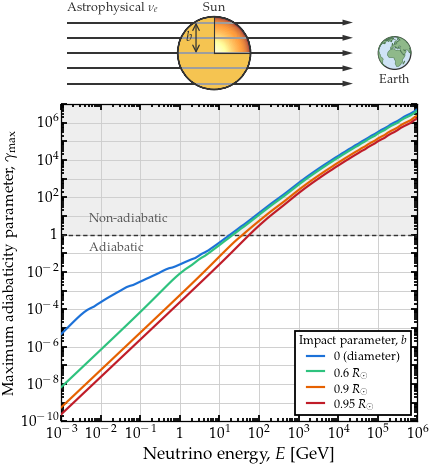

In [33]:
# ------------------------------------- adiabaticity along a solar chord
import magnus.adiabatic as adiabatic
# The chord at impact parameter b, and the worst adiabaticity anywhere on it.  The chords run
# on B16-GS98, which is tabulated out to the surface, so they start and end where the density
# vanishes; BS2005-AGS,OP stops at 0.983 R_sun and a chord past it has no profile (issue #62).
CHORD_MODEL = 'B16-GS98'
ne_chord = solarmodels.electron_density_profile(CHORD_MODEL)
SOLAR_R = gd.SUN_RADIUS*gd.UNIT_KM
SOLAR_H_EI = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
    OSC['s12'], OSC['s23'], OSC['s13'], OSC['dCP'], OSC['D21'], OSC['D31'])
SOLAR_E = np.logspace(-3, 6, 110)          # GeV
SOLAR_B = [(0.0, BLUE, r'$0$ (diameter)'), (0.6, GREEN, r'$0.6\,R_\odot$'),
           (0.9, ORANGE, r'$0.9\,R_\odot$'), (0.95, RED, r'$0.95\,R_\odot$')]


def solar_chord_ne(br):
    """Electron density along the chord at impact parameter br = b/R_sun."""
    b = br*SOLAR_R
    hl = np.sqrt(max(SOLAR_R**2 - b**2, 0.0))

    def ne_b(l):
        return ne_chord(np.sqrt((np.asarray(l, dtype=float) - hl)**2 + b**2))

    return ne_b, hl


def gamma_max(energy, br, n_probe=20000):
    """Worst adiabaticity along the chord, from the package's own diagnostic.

    find_nonadiabatic_windows is what the adiabatic engine uses to decide where it
    needs a Magnus patch.  It evaluates the adiabaticity parameter of Eq. (hf) --
    large where two levels approach, so large means non-adiabatic -- and reports the
    largest value it found.  That is exactly the quantity this figure plots, so the
    figure measures the package rather than a copy of it.
    """
    ne_b, hl = solar_chord_ne(br)

    def H_func(l):
        H = (SOLAR_H_EI/energy).astype(complex).copy()
        H[0, 0] += PER_NE*ne_b(l)
        return H

    info = {}
    adiabatic.find_nonadiabatic_windows(H_func, 0.0, 2*hl, n_probe=n_probe, info=info)
    return float(info['gamma_max'])


def solar_gamma_curve(br):
    """gamma_max against energy, for one impact parameter.  Cached: 110 energies,
    each one an eigendecomposition at 20 000 points along the chord."""
    def run():
        return [gamma_max(e*gd.UNIT_GEV, br) for e in SOLAR_E]
    key = ('solar_gamma_pkg', float(br), [float(x) for x in SOLAR_E],
           sorted(OSC.items()), float(SOLAR_R), CHORD_MODEL)
    tag = 'solar_gamma_b%s' % ('%g' % br).replace('.', 'p')
    return np.asarray(cached(tag, key, run, what='one adiabaticity curve'))


GAMMA = {br: solar_gamma_curve(br) for br, _, _ in SOLAR_B}

fig = plt.figure(figsize=(COL, 3.95))
solar_gs = fig.add_gridspec(2, 1, height_ratios=[0.33, 1.0], hspace=0.01)

# --- the setup, drawn above the measurement: flux in, Sun, flux out, Earth.
axs = fig.add_subplot(solar_gs[0])
SUN_X, SUN_RD, EAR_X, EAR_RD = 4.35, 1.05, 9.55, 0.47
# Each ray runs unbroken from left to right, turning grey over the stretch that
# lies inside the Sun, so the picture shows one trajectory rather than two.
for y_arrow in (-0.88, -0.44, 0.0, 0.44, 0.88):
    chord = np.sqrt(max(SUN_RD**2 - y_arrow**2, 0.0))
    x_in, x_out = SUN_X - chord, SUN_X + chord
    for xa, xb, color in ((0.10, x_in, INK), (x_in, x_out, '0.62'),
                          (x_out, 8.05, INK)):
        axs.plot([xa, xb], [y_arrow, y_arrow], color=color, lw=1.1,
                 solid_capstyle='butt', zorder=5)
    axs.add_patch(mpl.patches.FancyArrow(
        8.05, y_arrow, 0.30, 0.0, width=0.001, head_width=0.17, head_length=0.30,
        length_includes_head=True, facecolor=INK, edgecolor='none', zorder=5))
# A quarter of the Sun is cut away, shaded by its own electron density: bright at
# the center, where the density is highest, dark at the surface.
solar_cmap = plt.get_cmap('afmhot')
solar_edges = np.linspace(0.0, 1.0, 60)
solar_log_ne = np.log10(ne_chord(0.5*(solar_edges[:-1] + solar_edges[1:])*SOLAR_R))
solar_lo, solar_hi = solar_log_ne.min(), solar_log_ne.max()
for r0, r1, log_ne_r in zip(solar_edges[:-1], solar_edges[1:], solar_log_ne):
    shade = (log_ne_r - solar_lo)/(solar_hi - solar_lo)
    axs.add_patch(Wedge((SUN_X, 0.0), r1*SUN_RD, 0.0, 90.0, width=(r1 - r0)*SUN_RD,
                        facecolor=solar_cmap(0.12 + 0.78*shade), edgecolor='none',
                        zorder=4))
axs.add_patch(Wedge((SUN_X, 0.0), SUN_RD, 90.0, 360.0, facecolor='#f5c451',
                    edgecolor='none', zorder=4))
axs.add_patch(Wedge((SUN_X, 0.0), SUN_RD, 0.0, 360.0, width=0.001, edgecolor=INK,
                    facecolor='none', lw=0.8, zorder=6))
axs.plot([SUN_X, SUN_X + SUN_RD], [0, 0], color=INK, lw=0.6, zorder=6)
axs.plot([SUN_X, SUN_X], [0, SUN_RD], color=INK, lw=0.6, zorder=6)
axs.add_patch(Wedge((EAR_X, 0.0), EAR_RD, 0.0, 360.0, facecolor='#cfe3f5',
                    edgecolor=INK, lw=0.7, zorder=4))
solar_lat0, solar_lon0 = np.deg2rad(22.0), np.deg2rad(10.0)
for ring in LAND:
    a = np.deg2rad(np.asarray(ring, dtype=float))
    lon, lat = a[:, 0], a[:, 1]
    cosc = (np.sin(solar_lat0)*np.sin(lat)
            + np.cos(solar_lat0)*np.cos(lat)*np.cos(lon - solar_lon0))
    if (cosc > 0).sum() < 3:
        continue
    xx = np.cos(lat)*np.sin(lon - solar_lon0)
    yy = (np.cos(solar_lat0)*np.sin(lat)
          - np.sin(solar_lat0)*np.cos(lat)*np.cos(lon - solar_lon0))
    far = cosc <= 0
    if far.any():
        nn = np.hypot(xx, yy); nn[nn == 0] = 1.0
        xx = np.where(far, xx/nn, xx); yy = np.where(far, yy/nn, yy)
    axs.add_patch(Polygon(np.column_stack([EAR_X + EAR_RD*xx, EAR_RD*yy]),
                          closed=True, facecolor='#8fb98a', edgecolor='#4f7a55',
                          lw=0.3, zorder=5))
axs.text(0.10, 1.10, r'Astrophysical $\nu_e$', ha='left', va='bottom', fontsize=7.0,
         color=INK)
# The impact parameter, marked on one ray: the perpendicular distance from the
# Sun's center to that trajectory.
axs.annotate('', xy=(SUN_X - 0.52, 0.88), xytext=(SUN_X - 0.52, 0.0),
             arrowprops=dict(arrowstyle='<->', color=INK, lw=0.7,
                             shrinkA=0.0, shrinkB=0.0), zorder=7)
axs.text(SUN_X - 0.62, 0.44, r'$b$', ha='right', va='center', fontsize=7.5,
         color=INK, zorder=7)
axs.text(SUN_X, 1.10, 'Sun', ha='center', va='bottom', fontsize=7.0, color=INK)
axs.text(EAR_X, -EAR_RD - 0.14, 'Earth', ha='center', va='top', fontsize=7.0, color=INK)
axs.set_xlim(-0.05, 10.2); axs.set_ylim(-1.24, 1.45)
axs.set_aspect('equal'); axs.axis('off')

ax = fig.add_subplot(solar_gs[1])
# Grey, not red: the red curve is an impact parameter, the shading is a regime.
ax.axhspan(1.0, 1e12, color='0.5', alpha=0.13, lw=0, zorder=0)
for br, color, label in SOLAR_B:
    ax.loglog(SOLAR_E, GAMMA[br], color=color, lw=1.2, zorder=3, label=label)
ax.axhline(1.0, color=INK, lw=0.8, ls=(0, (3, 2)), zorder=2)
ax.set_xlim(SOLAR_E[0], SOLAR_E[-1]); ax.set_ylim(1e-10, 1e7)
ax.set_yticks([10.0**k for k in range(-10, 8)])
ax.set_yticklabels([('' if k % 2 else (r'$1$' if k == 0 else r'$10^{%d}$' % k))
                    for k in range(-10, 8)])
ax.set_xticks([10.0**k for k in range(-3, 7)])
ax.set_xticklabels([(r'$1$' if k == 0 else r'$10^{%d}$' % k)
                    for k in range(-3, 7)])
# A touch more air under the energy labels than the shared rcParams give.
ax.tick_params(axis='x', which='major', pad=3.4)
ax.xaxis.set_minor_locator(mpl.ticker.LogLocator(base=10.0, subs=tuple(np.arange(2, 10)*0.1),
                                                 numticks=100))
ax.yaxis.set_minor_locator(mpl.ticker.LogLocator(base=10.0, subs=tuple(np.arange(2, 10)*0.1),
                                                 numticks=100))
ax.set_xlabel(r'Neutrino energy, $E$ [GeV]', labelpad=2.0)
ax.set_ylabel(r'Maximum adiabaticity parameter, $\gamma_{\rm max}$', labelpad=2.0,
              fontsize=8.5)
ax.text(5.0e-3, 10.0**0.45, 'Non-adiabatic', fontsize=7.0, color='0.35',
        ha='left', va='bottom')
ax.text(5.0e-3, 10.0**-0.45, 'Adiabatic', fontsize=7.0, color='0.35',
        ha='left', va='top')
ax.grid(True, which='major', color=GRID, lw=0.5); ax.set_axisbelow(True)
leg = ax.legend(loc='lower right', fontsize=6.8, handlelength=1.4, borderpad=0.35,
                labelspacing=0.3, title=r'Impact parameter, $b$', title_fontsize=6.8)
leg.get_frame().set_edgecolor('black')
for br, _, _ in SOLAR_B:
    above = SOLAR_E[GAMMA[br] > 1.0]
    print('  b = %.2f R_sun: crosses gamma = 1 at %s GeV'
          % (br, ('%.3g' % above.min()) if len(above) else 'never'))
save(fig, 'solar_adiabaticity.pdf')

## Figure 5f --- the Sun in the electron-neutrino channel

The line of sight runs into the page, so a point of the disk is an impact parameter and the
neutrino crosses the whole Sun along it, on B16-GS98. What is plotted is the **phase average**
of `average=True`: every interference term kept with its phase, and weighted by the spread of
that phase across a 10 % energy spread.

Above a few GeV some of those phases are set by the matter potential and barely depend on
energy, so no energy spread averages them, and the probability oscillates with $b$ in rings
from $0.003$ to $0.03\,R_\odot$ apart, in places finer than a pixel ($0.0038\,R_\odot$). A
pixel is a range of impact parameters, so each is drawn as the average of the probability over
its own area, 8 by 8 sub-samples of a grid in $b$ that resolves the rings,
$\Delta b = 0.0005\,R_\odot$. The grid is computed in parallel, one process per core; the
paper cache holds it.

  solar_disk_0p01 read from paper_figure_cache.json, unchanged configuration 09192fe52499 (measured 2026-09-24 on laptop-6)
  solar_disk_10 read from paper_figure_cache.json, unchanged configuration b07ab8b315a3 (measured 2026-09-24 on laptop-6)


  solar_disk_30 read from paper_figure_cache.json, unchanged configuration 9a004f6a6000 (measured 2026-09-24 on laptop-6)
  solar_disk_30_core read from paper_figure_cache.json, unchanged configuration 3f2142c467f9 (measured 2026-09-24 on laptop-6)


  solar_disk_100 read from paper_figure_cache.json, unchanged configuration fc5f91c30b9a (measured 2026-09-24 on laptop-6)
  solar_disk_100_core read from paper_figure_cache.json, unchanged configuration 47fe1f608f96 (measured 2026-09-24 on laptop-6)


  solar_disk_300 read from paper_figure_cache.json, unchanged configuration 9ffce11541f1 (measured 2026-09-24 on laptop-6)
  solar_disk_300_core read from paper_figure_cache.json, unchanged configuration 1ea17ad477a5 (measured 2026-09-24 on laptop-6)


  solar_disk_1000 read from paper_figure_cache.json, unchanged configuration 9bb0db9190d7 (measured 2026-09-24 on laptop-6)
  solar_disk_1000_core read from paper_figure_cache.json, unchanged configuration 2eaad3766fdd (measured 2026-09-24 on laptop-6)


  solar_disk_3000 read from paper_figure_cache.json, unchanged configuration 72d143792ddf (measured 2026-09-24 on laptop-6)
  solar_disk_3000_core read from paper_figure_cache.json, unchanged configuration a84368bc9d3d (measured 2026-09-24 on laptop-6)


  solar_disk_10000 read from paper_figure_cache.json, unchanged configuration c39ec54d8045 (measured 2026-09-24 on laptop-6)
  solar_disk_50000 read from paper_figure_cache.json, unchanged configuration 106e02220064 (measured 2026-09-24 on laptop-6)


  vacuum decohered value, sum_i |U_ei|^4 = 0.548143
  $10$~MeV     201 impact parameters, P in [0.548143, 0.548143]
  $10$~GeV    2001 impact parameters, P in [0.465945, 0.654243]
  $30$~GeV    7773 impact parameters, P in [0.302620, 0.613410]
  $100$~GeV   7773 impact parameters, P in [0.276658, 0.571851]
  $300$~GeV   7773 impact parameters, P in [0.033161, 0.548116]
  $1$~TeV     7773 impact parameters, P in [0.399669, 0.553395]
  $3$~TeV     7773 impact parameters, P in [0.518253, 0.551503]
  $10$~TeV    2001 impact parameters, P in [0.540282, 0.548509]
  $50$~TeV    2001 impact parameters, P in [0.542517, 0.544028]


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/solar_tomography.pdf


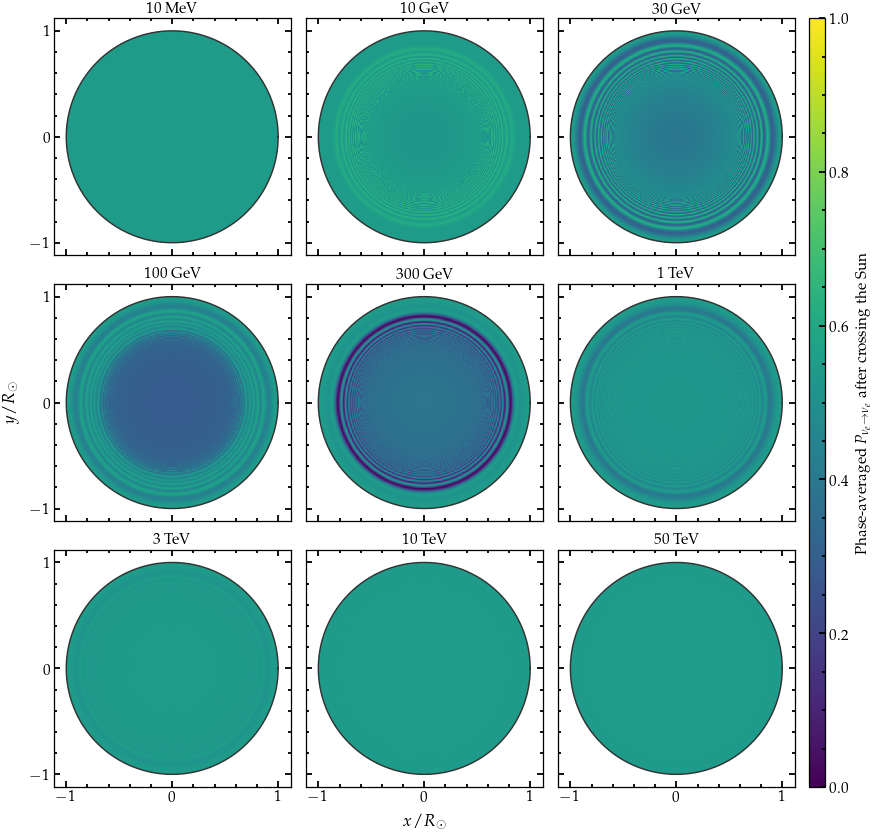

In [34]:
# --------------------------- the Sun in the electron-neutrino channel
# Each pixel is a range of impact parameters; the neutrino crosses the whole Sun along each.
import concurrent.futures
import multiprocessing
import os
import warnings

import magnus.avgprob as avgprob

SOLAR_PANELS = [(0.01, r'$10$~MeV'), (10.0, r'$10$~GeV'), (30.0, r'$30$~GeV'),
                (100.0, r'$100$~GeV'), (300.0, r'$300$~GeV'), (1.0e3, r'$1$~TeV'),
                (3.0e3, r'$3$~TeV'), (1.0e4, r'$10$~TeV'), (5.0e4, r'$50$~TeV')]


SOLAR_STEP = 0.0005                        # R_sun, the uniform grid from 1 GeV up
SOLAR_B_CORE = 0.5                         # inside it, a grid of its own
SOLAR_PER_RING = 5
# Only where the core's rings would show.  Their amplitude in P, read off the uniform grid, is
# 0.006 to 0.04 from 30 GeV to 3 TeV, and aliased it moves pixels by up to 0.02 (at 1 TeV).
# At 10 and 50 TeV it is 0.003 and 0.0006, under one colour step (1/256) before any
# averaging; at 10 GeV the core has no rings inside b = 0.47, and the uniform grid resolves
# those outside it (7.7 samples per ring).
SOLAR_CORE_PANELS = (30.0, 100.0, 300.0, 1.0e3, 3.0e3)


def solar_bgrid(energy_gev):
    # Uniform, and fine enough from b = SOLAR_B_CORE out: no rings at 10 MeV; from 10 GeV,
    # 0.0037 to 0.03 R_sun apart there (measured at db = 0.001 on B16-GS98: 0.0056 at 10 GeV
    # and b = 0.5, 0.027 at 30 GeV and b = 0.7), so seven or more samples to the finest.
    step = 0.005 if energy_gev < 1.0 else SOLAR_STEP
    return np.linspace(0.0, 1.0, int(round(1.0/step)) + 1)


def matter_phase(br, n=4001):
    # The integral of V_CC along the chord, in rad: 8676 across the diameter.
    ne_b, hl = solar_chord_ne(br)
    l = np.linspace(0.0, 2*hl, n)
    v = PER_NE*ne_b(l)
    return float(np.sum(0.5*(v[1:] + v[:-1])*np.diff(l)))


def solar_core_grid():
    # Inside SOLAR_B_CORE the rings are those of the matter phase, 2 pi/|d(phase)/db| apart:
    # 1.8e-4 R_sun at b = 0.11, 5.1e-4 at 0.3, 3.7e-3 at 0.5.  The uniform grid is coarser
    # than that and aliases them.  The phase does not depend on energy, so one grid serves
    # every panel: SOLAR_PER_RING points per ring, and never sparser than the uniform grid.
    bb = np.linspace(0.0, SOLAR_B_CORE, 4001)
    phase = np.array([matter_phase(br) for br in bb])
    ring = 2*np.pi/np.maximum(np.abs(np.gradient(phase, bb)), 1e-300)
    step = np.minimum(SOLAR_STEP, ring/SOLAR_PER_RING)
    count = np.concatenate([[0.0], np.cumsum(0.5*(1/step[1:] + 1/step[:-1])*np.diff(bb))])
    return np.interp(np.arange(0.0, count[-1]), count, bb)


SOLAR_CORE = solar_core_grid()


def solar_point(args):
    # One chord: the phase average of P(nu_e -> nu_e) after the whole crossing.
    energy_gev, br = args
    ne_b, hl = solar_chord_ne(br)
    if hl <= 0.0:
        return np.nan
    return float(quiet(
        oscprob.osc_prob_matter_std_potential, 3, ne_b, energy_gev*gd.UNIT_GEV, 2*hl,
        average=True, osc_params=OSC, L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE,
        density_is_of_number_of_electrons=True))


def solar_disk(energy_gev):
    # P against b on the panel's grid, over one process per core where fork is available.
    def run(grid):
        jobs = [(energy_gev, float(br)) for br in grid]
        try:
            context = multiprocessing.get_context('fork')
        except ValueError:
            return [solar_point(job) for job in jobs]
        workers = max(1, (os.cpu_count() or 2) - 1)
        with warnings.catch_warnings():
            # The kernel runs threads of its own; the workers touch none of them.
            warnings.simplefilter('ignore', DeprecationWarning)
            with concurrent.futures.ProcessPoolExecutor(workers, mp_context=context) as pool:
                return list(pool.map(solar_point, jobs, chunksize=4))
    grid = solar_bgrid(energy_gev)
    key = ('solar_disk_pixels', float(energy_gev), len(grid), sorted(OSC.items()),
           float(SOLAR_R), CHORD_MODEL, avgprob.AVG_PHASE_SPREAD)
    tag = 'solar_disk_%s' % ('%g' % energy_gev).replace('.', 'p').replace('+', '')
    P = np.asarray(cached(tag, key, lambda: run(grid), what='one panel of the solar disk'))
    P[np.isnan(P)] = P[np.isfinite(P)][-1]
    if energy_gev not in SOLAR_CORE_PANELS:
        return grid, P
    # The core on its own grid, stored apart, so that the uniform grid's outer points stand.
    key = ('solar_disk_core', float(energy_gev), len(SOLAR_CORE), SOLAR_B_CORE,
           SOLAR_PER_RING, sorted(OSC.items()), float(SOLAR_R), CHORD_MODEL,
           avgprob.AVG_PHASE_SPREAD)
    core = np.asarray(cached(tag + '_core', key, lambda: run(SOLAR_CORE),
                             what='the core of one panel of the solar disk'))
    outer = grid >= SOLAR_B_CORE
    return np.concatenate([SOLAR_CORE, grid[outer]]), np.concatenate([core, P[outer]])


SOLAR_MAPS = [solar_disk(e) for e, _ in SOLAR_PANELS]

SOLAR_NPIX, SOLAR_SUB = 520, 8
solar_g = np.linspace(-1.0, 1.0, SOLAR_NPIX)
# Each pixel is averaged over its own area: 8 x 8 sub-samples, those inside the limb.
solar_px = solar_g[1] - solar_g[0]
solar_sub = (np.arange(SOLAR_SUB) + 0.5)/SOLAR_SUB - 0.5
solar_sx = (solar_g[:, None] + solar_px*solar_sub[None, :]).ravel()
solar_rr = np.sqrt(solar_sx[None, :]**2 + solar_sx[:, None]**2).reshape(
    SOLAR_NPIX, SOLAR_SUB, SOLAR_NPIX, SOLAR_SUB)
solar_in = solar_rr <= 1.0
# Each sub-sample stands for a square of side solar_w.  Along any direction its spread in r
# has the variance of a band that wide, so it takes the mean of P over that band rather than
# P at its centre: in the core the rings are finer than the sub-samples, which would alias
# them.  The band means are tabulated on a grid far finer than either, then interpolated.
solar_w = solar_px/SOLAR_SUB
solar_rf = np.linspace(0.0, 1.0, 200001)
solar_lo = np.clip(solar_rf - 0.5*solar_w, 0.0, 1.0)
solar_hi = np.clip(solar_rf + 0.5*solar_w, 0.0, 1.0)


def band_integral(grid, P, x):
    # The integral from 0 to x of P interpolated linearly, exactly: quadratic in each interval.
    C = np.concatenate([[0.0], np.cumsum(0.5*(P[1:] + P[:-1])*np.diff(grid))])
    i = np.clip(np.searchsorted(grid, x, side='right') - 1, 0, len(grid) - 2)
    t, h = x - grid[i], grid[i + 1] - grid[i]
    return C[i] + P[i]*t + 0.5*(P[i + 1] - P[i])*t*t/h


def pixel_average(grid, P):
    band = ((band_integral(grid, P, solar_hi) - band_integral(grid, P, solar_lo))
            / (solar_hi - solar_lo))
    values = np.where(solar_in, np.interp(np.clip(solar_rr, 0.0, 1.0), solar_rf, band), 0.0)
    count = solar_in.sum(axis=(1, 3))
    with np.errstate(invalid='ignore'):
        return np.where(count > 0, values.sum(axis=(1, 3))/np.maximum(count, 1), np.nan)


fig, axes = plt.subplots(3, 3, figsize=(WIDE, WIDE*0.92), sharex=True, sharey=True)
solar_th = np.linspace(0.0, 2.0*np.pi, 500)
for ax, (grid, P), (e, label) in zip(axes.ravel(), SOLAR_MAPS, SOLAR_PANELS):
    M = pixel_average(grid, P)
    im = ax.pcolormesh(solar_g, solar_g, M, cmap='viridis', vmin=0.0, vmax=1.0,
                       shading='nearest', rasterized=True)
    ax.plot(np.cos(solar_th), np.sin(solar_th), color=INK, lw=0.8)
    ax.set_aspect('equal'); ax.set_xlim(-1.12, 1.12); ax.set_ylim(-1.12, 1.12)
    ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
    ax.set_title(label, fontsize=8.5, pad=3)
fig.subplots_adjust(left=0.075, right=0.865, bottom=0.075, top=0.965, wspace=0.06,
                    hspace=0.12)
# One label per direction, centred on the block of panels rather than on the canvas.
fig.text(0.470, 0.026, r'$x / R_\odot$', ha='center', va='bottom', fontsize=9.5)
fig.text(0.021, 0.520, r'$y / R_\odot$', ha='left', va='center', rotation='vertical',
         fontsize=9.5)
cax = fig.add_axes([0.880, 0.075, 0.017, 0.890])
cb = fig.colorbar(im, cax=cax)
cb.set_label(r'Phase-averaged $P_{\nu_e \to \nu_e}$ after crossing the Sun', fontsize=8.5,
             labelpad=4)
print('  vacuum decohered value, sum_i |U_ei|^4 = %.6f'
      % float(np.sum(np.abs(np.linalg.eigh(SOLAR_H_EI)[1][0, :])**4)))
for (grid, P), (e, label) in zip(SOLAR_MAPS, SOLAR_PANELS):
    print('  %-10s %5d impact parameters, P in [%.6f, %.6f]'
          % (label, len(grid), np.nanmin(P), np.nanmax(P)))
save(fig, 'solar_tomography.pdf')

## Figure 5g --- neutrinos from a jet inside a collapsing star

A gamma-ray-burst jet makes TeV--PeV neutrinos at its head; while the jet is still inside
the star, they cross the stellar envelope, where the density falls from a fraction of a
gram per cubic centimeter to zero. Every energy between $100$~GeV and $100$~TeV meets its
1--3 resonance somewhere along the way. What a telescope measures is the phase-averaged
probability at Earth, which needs the amplitudes onto the mass states: the cell asks the
scenario function for the evolution operator (`return_evolution_operator=True`), projects
it onto the vacuum mass states, and averages over eight production points spread across
one oscillation length at the jet head. Three envelopes: smooth (Mena et al.; Razzaque
and Smirnov), the same with Kolmogorov turbulence, and the same with the density drop at
the helium-core edge (model C of Mena et al.), declared to the ladder as a breakpoint.
A hand-built grid of $2\cdot10^8$~cm slabs is run at five energies as the control.

In [35]:
# ------------------------------ neutrinos from a jet inside a collapsing star
JET_CM = 1.0e-5*gd.UNIT_KM                 # one cm in eV^-1
JET_RSTAR, JET_R0, JET_RHE = 3.0e12, 6.3e10, 1.0e11    # star, jet head, He-core edge, cm
JET_YE, JET_TOL = 1.0, 1.0e-6
JET_E_TEV = np.geomspace(0.1, 1.0e4, 161)
JET_E = JET_E_TEV*gd.UNIT_TEV


def jet_smooth(r):
    """The hydrogen envelope, g/cm3, r in cm."""
    return 3.3e-6*(JET_RSTAR/r - 1.0)**3


# One realization of forty Kolmogorov modes between 1e10 and 1e12 cm, 20 % rms.  Log-spaced
# modes with amplitude ~ k^(-1/3) give k^(-5/3) in power per unit wavenumber.
JET_LAM = np.geomspace(1.0e12, 1.0e10, 40)
JET_K = 2*np.pi/JET_LAM
JET_AMP = JET_K**(-1.0/3.0)
JET_AMP *= 0.20/np.sqrt(0.5*np.sum(JET_AMP**2))
JET_PHI = np.random.default_rng(7).uniform(0.0, 2*np.pi, 40)


def jet_turbulent(r):
    return jet_smooth(r)*(1.0 + np.sum(JET_AMP*np.cos(JET_K*r + JET_PHI)))


def jet_stepped(r):
    """Model C of Mena et al.: a factor-of-five drop at the helium-core edge."""
    x = JET_RSTAR/r - 1.0
    return 6.3e-6*(20.0*x**2.1 if r < JET_RHE else x**2.5)


JET_PROFILES = {'smooth': (jet_smooth, ()), 'turbulent': (jet_turbulent, ()),
                'stepped': (jet_stepped, (JET_RHE,))}

# The potential of one g/cm3 at Y_e = 1, and from it the oscillation length at the jet
# head, 2 pi / V_CC there; the eight production points are spread across that length.
JET_V1 = matter.VCC_func(0.0, lambda l: matter.num_density_e_func(
    0.0, lambda l: 1.0, electron_fraction=JET_YE, density_matter_is_in_g_per_cm3=True))
JET_LOSC_HEAD = 2*np.pi/(JET_V1*jet_smooth(JET_R0))/JET_CM        # cm
JET_R0S = JET_R0 + JET_LOSC_HEAD*np.arange(8)/8.0


def jet_vacuum_R(e):
    """Columns: the vacuum mass states at energy e, in the flavor basis."""
    return np.linalg.eigh(np.array(hamiltonians.hamiltonian_3nu_vacuum(e, **OSC),
                                   dtype=complex))[1]


def jet_to_earth(U, e):
    """The phase-averaged probability at Earth from the operator across the envelope:
    the mass-state content of what leaves, times the flavor content of each mass state."""
    R = jet_vacuum_R(e)
    return np.abs(R)**2 @ np.abs(R.conj().T @ U)**2


def jet_hand_grid(e, rho, breakpoints, r0):
    """The control: 2e8 cm slabs from r0 to the surface, with the breakpoints as edges."""
    hv = np.array(hamiltonians.hamiltonian_3nu_vacuum(e, **OSC), dtype=complex)

    def H(l):
        return hv + hamiltonians.hamiltonian_3nu_matter(JET_V1*float(rho(l/JET_CM)))

    edges = np.linspace(r0, JET_RSTAR, int((JET_RSTAR - r0)/2.0e8) + 1)
    for b in breakpoints:
        edges = np.unique(np.append(edges, b))
    edges = edges*JET_CM
    Us = quiet(oscprob.compute_evolution_operator_multiple_slabs, H,
               np.stack([edges[:-1], edges[1:]], axis=1), 9, 6)
    U = Us[0]
    for u in Us[1:]:
        U = u @ U
    return U


def jet_earth(name):
    """P at Earth against energy for one envelope, averaged over the production points,
    with the largest difference from the hand-built grid at five energies."""
    rho, bps = JET_PROFILES[name]
    kw = dict(electron_fraction=JET_YE, density_matter_is_in_g_per_cm3=True,
              rtol=JET_TOL, atol=JET_TOL, return_evolution_operator=True)
    if bps:
        kw['t_breakpoints'] = [b*JET_CM for b in bps]

    def run():
        P_earth = np.zeros((len(JET_E), 3, 3))
        for r0 in JET_R0S:
            _, U = quiet(oscprob.osc_prob_matter_std_potential, 3,
                         lambda l: float(rho(l/JET_CM)), JET_E, JET_RSTAR*JET_CM, OSC,
                         L0=r0*JET_CM, **kw)
            for i, e in enumerate(JET_E):
                P_earth[i] += jet_to_earth(np.asarray(U)[i], e)/len(JET_R0S)
        control = 0.0
        for i in range(0, len(JET_E), 40):
            P_hand = np.mean([jet_to_earth(jet_hand_grid(JET_E[i], rho, bps, r0), JET_E[i])
                              for r0 in JET_R0S], axis=0)
            control = max(control, float(np.max(np.abs(P_hand - P_earth[i]))))
        return dict(P_earth=P_earth.tolist(), control=control)

    key = ('jet', name, [float(e) for e in JET_E_TEV], JET_RSTAR, JET_R0, JET_RHE, JET_YE,
           JET_TOL, [float(r) for r in JET_R0S], JET_LAM.tolist(), JET_AMP.tolist(),
           JET_PHI.tolist(), sorted(OSC.items()))
    return cached('jet_%s' % name, key, run, what='one envelope of the jet example')


JET_DATA = {name: jet_earth(name) for name in JET_PROFILES}
for name in JET_PROFILES:
    print('  %-9s ladder vs hand grid, max |dP| = %.1e' % (name, JET_DATA[name]['control']))

  jet_smooth read from paper_figure_cache.json, unchanged configuration 1058389232b6 (measured 2026-09-20 on laptop-6)
  jet_turbulent read from paper_figure_cache.json, unchanged configuration 908a7e660669 (measured 2026-09-20 on laptop-6)


  jet_stepped read from paper_figure_cache.json, unchanged configuration f21c58779d99 (measured 2026-09-20 on laptop-6)
  smooth    ladder vs hand grid, max |dP| = 1.2e-08
  turbulent ladder vs hand grid, max |dP| = 1.8e-08
  stepped   ladder vs hand grid, max |dP| = 2.1e-08


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/jet.pdf


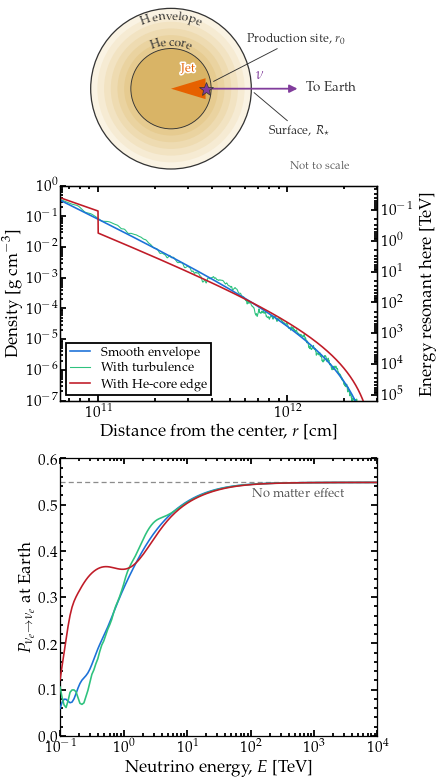

In [36]:
# ---------------------------------------------- the figure: schematic, envelopes, P
from matplotlib.patches import FancyArrowPatch

JET_SERIES = [('smooth', BLUE, 'Smooth envelope'), ('turbulent', GREEN, 'With turbulence'),
              ('stepped', RED, 'With He-core edge')]


def jet_resonant_energy(rho):
    """The energy whose 1-3 resonance sits at density rho (g/cm3, Y_e = 1), in TeV."""
    cos2th13 = 1.0 - 2.0*OSC['s13']**2
    return OSC['D31']*cos2th13/(2.0*JET_V1*rho)/gd.UNIT_TEV


fig = plt.figure(figsize=(COL, 6.5))
gs = fig.add_gridspec(3, 1, height_ratios=[1.25, 1.55, 2.0], hspace=0.26,
                      left=0.16, right=0.86, top=0.995, bottom=0.07)


def curved_text(ax, text, radius, theta_deg, fontsize, color):
    """Characters along the circle of the given radius about the origin, centered on
    theta_deg (90 is the top), reading left to right."""
    fig.canvas.draw()
    rend = fig.canvas.get_renderer()
    inv = ax.transData.inverted()
    widths = []
    for ch in text:
        t = ax.text(0, 0, ch if ch != ' ' else 'i', fontsize=fontsize)
        bb = t.get_window_extent(rend)
        t.remove()
        w = inv.transform((bb.width, 0))[0] - inv.transform((0, 0))[0]
        widths.append(w*(0.7 if ch == ' ' else 1.0))
    pos = np.radians(theta_deg) + 0.5*sum(widths)/radius
    for ch, w in zip(text, widths):
        ang = pos - 0.5*w/radius
        ax.text(radius*np.cos(ang), radius*np.sin(ang), ch, fontsize=fontsize, color=color,
                ha='center', va='center', rotation=np.degrees(ang) - 90.0,
                rotation_mode='anchor', zorder=7)
        pos -= w/radius


# Top: the setup, not to scale
ax0 = fig.add_subplot(gs[0])
ax0.set_aspect('equal')
ax0.axis('off')
ax0.set_xlim(-1.06, 2.25)
ax0.set_ylim(-1.08, 1.08)
RCORE = 0.50
for rr_, fc_ in zip(np.linspace(1.0, RCORE, 7),
                    ['#faf3e3', '#f6ebd3', '#f2e3c2', '#eedbb1', '#ead3a0', '#e6cb90', '#e2c380']):
    ax0.add_patch(Circle((0, 0), rr_, fc=fc_, ec='none', zorder=1))
ax0.add_patch(Circle((0, 0), 1.0, fc='none', ec=INK, lw=0.7, zorder=2))
ax0.add_patch(Circle((0, 0), RCORE, fc='#d9b466', ec=INK, lw=0.5, zorder=2))
ax0.add_patch(Polygon([[0, 0], [0.43, 0.13], [0.43, -0.13]], closed=True, fc=ORANGE,
                      ec='none', zorder=3))
ax0.plot([0.43], [0.0], marker='*', ms=8, color=PURPLE, mec=INK, mew=0.4, zorder=5)
ax0.add_patch(FancyArrowPatch((0.47, 0.0), (1.62, 0.0), arrowstyle='-|>', mutation_scale=9,
                              lw=1.0, color=PURPLE, zorder=4))
ax0.text(1.68, 0.0, 'To Earth', ha='left', va='center', fontsize=7.5, color=INK)
ax0.text(1.10, 0.08, r'$\nu$', ha='center', va='bottom', fontsize=8.5, color=PURPLE)
ax0.text(0.21, 0.17, 'Jet', ha='center', va='bottom', fontsize=6.8, color=ORANGE, zorder=6,
         path_effects=[pe.withStroke(linewidth=1.8, foreground='white')])
curved_text(ax0, 'H envelope', 0.90, 90.0, 6.8, INK)
curved_text(ax0, 'He core', RCORE + 0.075, 90.0, 6.8, INK)
ax0.annotate('Production site, $r_0$', xy=(0.49, 0.07), xytext=(0.95, 0.62), fontsize=6.8,
             color=INK, ha='left', va='center',
             arrowprops=dict(arrowstyle='-', lw=0.5, color=INK, shrinkA=0, shrinkB=2))
ax0.annotate('Surface, $R_\star$', xy=(1.0, -0.02), xytext=(1.22, -0.52), fontsize=6.8,
             color=INK, ha='left', va='center',
             arrowprops=dict(arrowstyle='-', lw=0.5, color=INK, shrinkA=0, shrinkB=2))
ax0.text(2.22, -1.04, 'Not to scale', ha='right', va='bottom', fontsize=6.3, color='0.4',
         style='italic')

# Middle: the three envelopes, with the energy resonant at each density on the right
ax1 = fig.add_subplot(gs[1])
rr = np.geomspace(JET_R0, JET_RSTAR*(1.0 - 1.0e-4), 3000)
for name, color, label in JET_SERIES:
    rho = JET_PROFILES[name][0]
    ax1.plot(rr, [float(rho(x)) for x in rr], color=color,
             lw=0.9 if name != 'turbulent' else 0.6, label=label,
             zorder=3 if name != 'turbulent' else 2)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(JET_R0, JET_RSTAR)
ax1.set_ylim(1.0e-7, 1.0)
ax1.yaxis.set_major_locator(LogLocator(base=10.0, numticks=12))
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=40))
ax1.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax1.tick_params(axis='x', which='major', pad=3.0)
ax1.set_xlabel('Distance from the center, $r$ [cm]', labelpad=1.5)
ax1.set_ylabel(r'Density [g cm$^{-3}$]', labelpad=2)
ax1b = ax1.twinx()
ax1b.set_yscale('log')
ax1b.set_ylim(jet_resonant_energy(1.0e-7), jet_resonant_energy(1.0))
ax1b.set_ylabel('Energy resonant here [TeV]', labelpad=4)
ax1b.yaxis.set_major_locator(LogLocator(base=10.0, numticks=12))
ax1b.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=40))
ax1b.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax1b.tick_params(which='both', direction='in', labelsize=8.5)
ax1.tick_params(right=False, which='both')
ax1.legend(loc='lower left', fontsize=7.2, handlelength=1.6, borderpad=0.28,
           labelspacing=0.22, borderaxespad=0.45)

# Bottom: P(nu_e -> nu_e) at Earth against energy
ax2 = fig.add_subplot(gs[2])
R_vac = jet_vacuum_R(JET_E[0])
P_novac = float((np.abs(R_vac)**2 @ (np.abs(R_vac)**2).T)[gd.NUE, gd.NUE])
ax2.axhline(P_novac, color='0.55', lw=0.7, ls=(0, (4, 2.5)), zorder=1)
ax2.text(3.0e3, P_novac - 0.012, 'No matter effect', ha='right', va='top', fontsize=7.2,
         color='0.35')
for name, color, label in JET_SERIES:
    P = np.asarray(JET_DATA[name]['P_earth'])[:, gd.NUE, gd.NUE]
    ax2.plot(JET_E_TEV, P, color=color, lw=0.9, label=label, zorder=3)
ax2.set_xscale('log')
ax2.set_xlim(0.1, 1.0e4)
ax2.set_ylim(0.0, 0.6)
ax2.tick_params(axis='x', which='major', pad=3.0)
ax2.set_xlabel(r'Neutrino energy, $E$ [TeV]', labelpad=1.5)
ax2.set_ylabel(r'$P_{\nu_e \to \nu_e}$ at Earth', labelpad=2)

# The equal-aspect schematic is shorter than its box: slide it down onto the density panel
fig.canvas.draw()
_p0, _p1 = ax0.get_position(), ax1.get_position()
ax0.set_position([_p0.x0, _p1.y1 + 0.012, _p0.width, _p0.height])
save(fig, 'jet.pdf')

## Figure 5h --- a density mode against the closed form

Behind a supernova shock the medium is turbulent. Decomposed into Fourier modes, a mode of
wavenumber $q$ moves neutrinos between two eigenstates of $\mathbb{H}$ when $q$ matches the
gap between their eigenvalues. Patton, Kneller and McLaughlin solve that in closed form, as
a Rabi formula for one isolated pair of levels over a long region. This cell tests both
assumptions: it sweeps one mode across the gap at four lengths of the turbulent region, and
compares the closed form against \magnus\ at two, three and four flavors.

The quantity is the transition between the two matter levels, not a flavor probability,
because that is what the closed form predicts. It vanishes identically in a smooth medium,
so nothing is subtracted.

L_osc = 10938 km;  resonance at q/Dpsi_32 = 1.0196 (2nu), 1.0000 (3nu), 1.0353 (3+1)
shortest oscillation: 10728 km (2nu), 4881 km (3nu), 12.390 km (3+1)
  turb_levels_1 read from paper_figure_cache.json, unchanged configuration 0d994d265b4e (measured 2026-09-19 on laptop-6)


  turb_levels_3 read from paper_figure_cache.json, unchanged configuration 05a764c3cabc (measured 2026-09-19 on laptop-6)
  turb_levels_10 read from paper_figure_cache.json, unchanged configuration 64ef23c47060 (measured 2026-09-19 on laptop-6)


  turb_levels_30 read from paper_figure_cache.json, unchanged configuration bb0980326e3d (measured 2026-09-19 on laptop-6)
  L =  1 L_osc: slabs 200/200/5297, unitarity <= 1.7e-12, slab doubling <= 2.2e-14
       closed form vs 2nu  27.8% of peak;  2nu vs 3nu   6.1%
  L =  3 L_osc: slabs 200/200/15891, unitarity <= 5.0e-12, slab doubling <= 1.6e-12
       closed form vs 2nu   6.6% of peak;  2nu vs 3nu  12.0%
  L = 10 L_osc: slabs 200/200/52970, unitarity <= 1.7e-11, slab doubling <= 1.1e-08
       closed form vs 2nu   2.2% of peak;  2nu vs 3nu  34.0%
  L = 30 L_osc: slabs 200/403/158912, unitarity <= 5.0e-11, slab doubling <= 8.1e-06
       closed form vs 2nu   0.4% of peak;  2nu vs 3nu  86.1%


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/turbulence_rabi.pdf


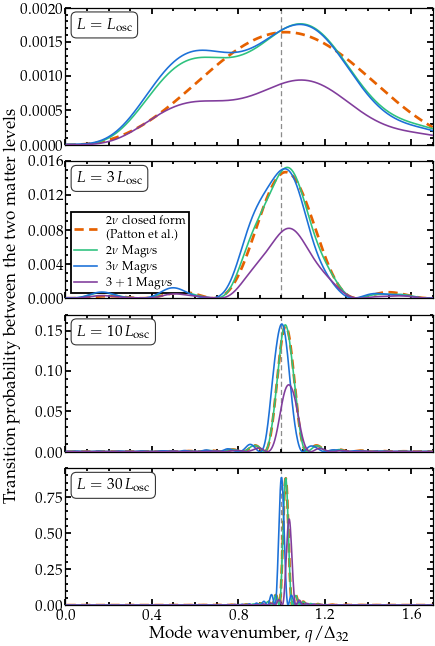

In [37]:
# ------------------------- a density mode against the closed form
TURB_E = 5.0*gd.UNIT_GEV
TURB_RHO0 = 4.0             # g/cm3, the mean density of the region
TURB_C = 0.03               # fractional amplitude of the single mode
TURB_NE0 = matter.num_density_e_func(0.0, lambda l: TURB_RHO0,
                                     density_matter_is_in_g_per_cm3=True)
TURB_V0 = matter.VCC_func(0.0, lambda l: TURB_NE0)

# The same medium at two, three and four flavors.  Two flavors is the (nu_e, nu_mu)
# reduction of the 1-3 sector, which is the system the closed form is written for.
TURB_HV = {
    2: np.array(hamiltonians.hamiltonian_2nu_vacuum(TURB_E, OSC['s13'], OSC['D31']),
                dtype=complex),
    3: np.array(hamiltonians.hamiltonian_3nu_vacuum(TURB_E, **OSC), dtype=complex),
    4: np.array(hamiltonians.hamiltonian_4nu_vacuum(
        TURB_E, OSC4['s12'], OSC4['s23'], OSC4['s13'], OSC4['dCP'], OSC4['s14'],
        OSC4['d14'], OSC4['s24'], OSC4['d24'], OSC4['s34'],
        OSC4['D21'], OSC4['D31'], OSC4['D41']), dtype=complex)}
TURB_MATT = {2: hamiltonians.hamiltonian_2nu_matter,
             3: hamiltonians.hamiltonian_3nu_matter,
             4: hamiltonians.hamiltonian_4nu_matter}
# The pair the mode drives: the two levels that share the electron flavor.  At two
# flavors that is the only pair; at three and four it is levels 2 and 3.
TURB_PAIR = {2: (1, 0), 3: (2, 1), 4: (2, 1)}
TURB_EIG = {}
for _n in (2, 3, 4):
    _w, _V = np.linalg.eigh(TURB_HV[_n] + TURB_MATT[_n](TURB_V0))
    _hi, _lo = TURB_PAIR[_n]
    TURB_EIG[_n] = (_w, _V, abs(_w[_hi] - _w[_lo]))
DPSI32 = TURB_EIG[3][2]
LOSC = 2.0*np.pi/DPSI32
# The Rabi coupling the mode induces between the two levels of the 2nu system, which is
# the kappa of the closed form.
KAPPA2 = 0.5*TURB_C*TURB_V0*abs(np.conj(TURB_EIG[2][1][0, 0])*TURB_EIG[2][1][0, 1])
# The shortest oscillation each flavor count carries.  It sets the slab count: an
# eV-scale splitting puts a 12.4 km oscillation under a region of hundreds of
# thousands of kilometers, and every one of those periods has to be resolved.
TURB_LAM_MIN = {n: 2.0*np.pi/max(abs(TURB_EIG[n][0][j] - TURB_EIG[n][0][i])
                                 for i in range(n) for j in range(i + 1, n))
                for n in (2, 3, 4)}
print('L_osc = %.0f km;  resonance at q/Dpsi_32 = %.4f (2nu), %.4f (3nu), %.4f (3+1)'
      % (LOSC/gd.UNIT_KM, TURB_EIG[2][2]/DPSI32, 1.0, TURB_EIG[4][2]/DPSI32))
print('shortest oscillation: %.0f km (2nu), %.0f km (3nu), %.3f km (3+1)'
      % tuple(TURB_LAM_MIN[n]/gd.UNIT_KM for n in (2, 3, 4)))


def turb_rho(q):
    """Density along the ray: the mean, plus one mode of wavenumber q."""
    def rho(l):
        return TURB_RHO0*(1.0 + TURB_C*np.cos(q*np.asarray(l, dtype=float)))
    return rho


def turb_operator(n, q, L, n_slabs):
    """Evolution operator across the region, at n flavors, on a uniform slab grid.

    The refinement ladder is not used here.  A profile that oscillates everywhere has no
    feature for it to place slabs around, so the grid is uniform by construction and the
    count is set from the shortest oscillation present; what has to be shown instead is
    that doubling it does not move the answer, which `turb_levels` reports.
    """
    def H(l):
        x = np.asarray(l, dtype=float)
        return TURB_HV[n] + TURB_MATT[n](TURB_V0*(1.0 + TURB_C*np.cos(q*x)))

    e = np.linspace(0.0, L, n_slabs + 1)
    Us = np.asarray(quiet(oscprob.compute_evolution_operator_multiple_slabs,
                          H, np.stack([e[:-1], e[1:]], axis=1), 9, 6))
    # The time-ordered product, earliest slab applied first.  Written as a loop
    # rather than np.linalg.multi_dot, whose search for an optimal
    # parenthesization is cubic in the number of factors and never returns when
    # that number is in the hundreds of thousands.
    U = Us[0]
    for u in Us[1:]:
        U = u @ U
    return U


def turb_p_levels(n, q, L, n_slabs):
    """Probability of leaving as the upper level, having entered as the lower one."""
    _, V, _ = TURB_EIG[n]
    hi, lo = TURB_PAIR[n]
    U = turb_operator(n, q, L, n_slabs)
    return float(abs((V.conj().T @ U @ V)[hi, lo])**2), \
        float(np.abs(U.conj().T @ U - np.eye(n)).max())


def turb_closed_form(q, L):
    """Eq. (turb_rabi): the Rabi formula of Patton, Kneller and McLaughlin."""
    p = 0.5*(TURB_EIG[2][2] - q)
    om = np.hypot(p, KAPPA2)
    return float(KAPPA2**2/(p*p + KAPPA2*KAPPA2)*np.sin(om*L)**2)


# The four region lengths, in units of L_osc, and the sweep they share.  The window is
# symmetric about the three-flavor gap, so q = Dpsi_32 sits at the same place in every
# panel; 801 points put a dozen across the narrowest resonance, at 30 L_osc.
TURB_NLAM = [1, 3, 10, 30]
TURB_Q = np.linspace(0.005, 1.7, 801)


def turb_levels(nlam):
    """The four curves of one panel, plus the controls that stand behind them."""
    L = nlam*LOSC

    def run():
        rec = {'closed': [turb_closed_form(r*DPSI32, L) for r in TURB_Q], 'n_slabs': {}}
        for n in (2, 3, 4):
            ns = max(200, int(6*L/TURB_LAM_MIN[n]))
            vals = [turb_p_levels(n, r*DPSI32, L, ns) for r in TURB_Q]
            rec['magnus%d' % n] = [v for v, _ in vals]
            rec['unitarity%d' % n] = max(u for _, u in vals)
            # the control: the same points on twice as many slabs
            step = 50
            twice = [turb_p_levels(n, TURB_Q[i]*DPSI32, L, 2*ns)[0]
                     for i in range(0, len(TURB_Q), step)]
            rec['doubling%d' % n] = max(
                abs(rec['magnus%d' % n][i] - t)
                for i, t in zip(range(0, len(TURB_Q), step), twice))
            # String keys, because that is what JSON returns on the way back in:
            # the cell must read the same whether it computed this or read it.
            rec['n_slabs'][str(n)] = ns
        return rec

    key = ('turb_levels', int(nlam), float(TURB_C), float(TURB_RHO0), float(TURB_E),
           [float(r) for r in TURB_Q], sorted(OSC.items()), sorted(OSC4.items()))
    return cached('turb_levels_%d' % nlam, key, run, what='one panel of the comparison')


TURB_LEV = {nlam: turb_levels(nlam) for nlam in TURB_NLAM}
for nlam in TURB_NLAM:
    c = TURB_LEV[nlam]
    cf, m2 = np.asarray(c['closed']), np.asarray(c['magnus2'])
    m3, m4 = np.asarray(c['magnus3']), np.asarray(c['magnus4'])
    print('  L = %2d L_osc: slabs %d/%d/%d, unitarity <= %.1e, slab doubling <= %.1e'
          % (nlam, c['n_slabs']['2'], c['n_slabs']['3'], c['n_slabs']['4'],
             max(c['unitarity%d' % n] for n in (2, 3, 4)),
             max(c['doubling%d' % n] for n in (2, 3, 4))))
    print('       closed form vs 2nu %5.1f%% of peak;  2nu vs 3nu %5.1f%%'
          % (100*np.abs(cf - m2).max()/m2.max(), 100*np.abs(m2 - m3).max()/m3.max()))

YMAX_LEV = [0.002, 0.016, 0.17, 0.95]
SER = [(2, GREEN, r'$2\nu$ Mag$\nu$s'), (3, BLUE, r'$3\nu$ Mag$\nu$s'),
       (4, PURPLE, r'$3+1$ Mag$\nu$s')]
fig, axes = plt.subplots(len(TURB_NLAM), 1, figsize=(COL, 5.05), sharex=True)
fig.subplots_adjust(hspace=0.12, left=0.175, right=0.985, top=0.985, bottom=0.075)
for ax, nlam, ymax in zip(axes, TURB_NLAM, YMAX_LEV):
    c = TURB_LEV[nlam]
    ax.axvline(1.0, color='0.55', lw=0.7, ls=(0, (4, 2.5)), zorder=1)
    ax.plot(TURB_Q, np.asarray(c['closed']), color=ORANGE, lw=1.5, ls=(0, (3.4, 2.0)),
            zorder=2, label=r'$2\nu$ closed form' + '\n(Patton et al.)')
    for n, color, lab in SER:
        ax.plot(TURB_Q, np.asarray(c['magnus%d' % n]), color=color, lw=0.9,
                zorder=3 + n, label=lab)
    ax.set_xlim(0.0, 1.7)
    ax.set_ylim(0.0, ymax)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
    ax.text(0.030, 0.93, r'$L = L_{\rm osc}$' if nlam == 1
            else r'$L = %d\,L_{\rm osc}$' % nlam, transform=ax.transAxes,
            ha='left', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=INK, lw=0.6))
axes[1].legend(loc='lower left', fontsize=6.8, handlelength=1.8, borderpad=0.28,
               labelspacing=0.30, borderaxespad=0.45)
axes[-1].set_xlabel(r'Mode wavenumber, $q/\Delta_{32}$', labelpad=1.5)
fig.canvas.draw()
_inv = fig.transFigure.inverted()
_left = min(a.get_tightbbox(fig.canvas.get_renderer()).transformed(_inv).x0 for a in axes)
_ymid = 0.5*(axes[0].get_position().y1 + axes[-1].get_position().y0)
fig.text(_left - 0.020, _ymid, r'Transition probability between the two matter levels',
         va='center', ha='center', rotation='vertical',
         fontsize=plt.rcParams['axes.labelsize'])
save(fig, 'turbulence_rabi.pdf')

## Figure 5i --- the same sweep, in the flavor channel

What a detector sees is a flavor probability, not a transition between matter levels. This
cell sweeps the same mode and reports $P_{\nu_\mu \to \nu_e}$, at the same four region
lengths and the same three flavor counts, over a range wide enough to hold all three
three-flavor gaps. Alongside them it draws the flavor probability that follows from the
closed form, computed from its rotating-wave propagator rotated to the flavor basis.

  turb_flavor_1 read from paper_figure_cache.json, unchanged configuration 6da8f07ef48d (measured 2026-09-19 on laptop-6)
  turb_flavor_3 read from paper_figure_cache.json, unchanged configuration c402d7112e9c (measured 2026-09-19 on laptop-6)


  turb_flavor_10 read from paper_figure_cache.json, unchanged configuration 7ab32986f79a (measured 2026-09-19 on laptop-6)
  turb_flavor_30 read from paper_figure_cache.json, unchanged configuration d308eb42f896 (measured 2026-09-19 on laptop-6)
  L =  1 L_osc: the smooth medium alone gives P(numu -> nue) = 0.0016 / 0.0006 / 0.0138 at 2nu / 3nu / 3+1
  L =  3 L_osc: the smooth medium alone gives P(numu -> nue) = 0.0140 / 0.0007 / 0.0363 at 2nu / 3nu / 3+1
  L = 10 L_osc: the smooth medium alone gives P(numu -> nue) = 0.1384 / 0.0011 / 0.0685 at 2nu / 3nu / 3+1
  L = 30 L_osc: the smooth medium alone gives P(numu -> nue) = 0.3840 / 0.0005 / 0.0080 at 2nu / 3nu / 3+1


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/turbulence.pdf


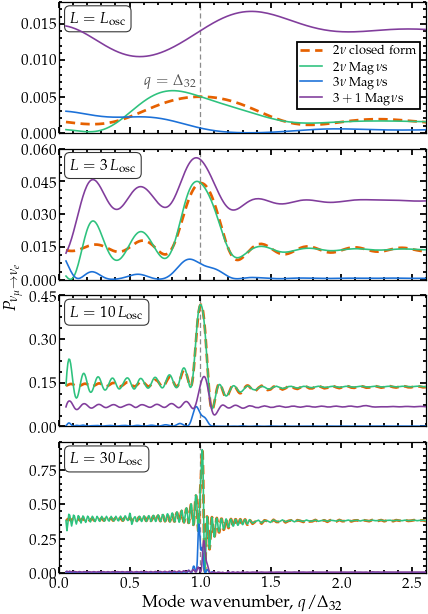

In [38]:
# ---------------------- the same sweep, in the flavor channel
# Wide enough to carry the three regimes: modes faster than every gap, modes near one,
# and modes far slower than all of them.
TURB_QF = np.concatenate([np.linspace(0.05, 0.45, 60, endpoint=False),
                          np.linspace(0.45, 1.35, 260, endpoint=False),
                          np.linspace(1.35, 2.60, 60)])


def turb_p_mue(n, q, L, n_slabs):
    """P(numu -> nue); q of None is the smooth medium, carrying no mode at all."""
    if q is None:
        def H(l):
            x = np.asarray(l, dtype=float)
            return TURB_HV[n] + TURB_MATT[n](TURB_V0*(1.0 + 0.0*x))

        e = np.linspace(0.0, L, n_slabs + 1)
        Us = np.asarray(quiet(oscprob.compute_evolution_operator_multiple_slabs,
                              H, np.stack([e[:-1], e[1:]], axis=1), 9, 6))
        U = Us[0]
        for u in Us[1:]:
            U = u @ U
    else:
        U = turb_operator(n, q, L, n_slabs)
    return float(abs(U[0, 1])**2)


def turb_flavor(nlam):
    """P(numu -> nue) against wavenumber, at each flavor count, for one region length."""
    L = nlam*LOSC

    def run():
        rec = {}
        for n in (2, 3, 4):
            ns = max(200, int(6*L/TURB_LAM_MIN[n]))
            rec['P%d' % n] = [turb_p_mue(n, r*DPSI32, L, ns) for r in TURB_QF]
            rec['smooth%d' % n] = turb_p_mue(n, None, L, ns)
        return rec

    key = ('turb_flavor', int(nlam), float(TURB_C), float(TURB_RHO0), float(TURB_E),
           [float(r) for r in TURB_QF], sorted(OSC.items()), sorted(OSC4.items()))
    return cached('turb_flavor_%d' % nlam, key, run, what='one panel of the channel')


TURB_FLA = {nlam: turb_flavor(nlam) for nlam in TURB_NLAM}
for nlam in TURB_NLAM:
    c = TURB_FLA[nlam]
    print('  L = %2d L_osc: the smooth medium alone gives P(numu -> nue) = '
          '%.4f / %.4f / %.4f at 2nu / 3nu / 3+1'
          % (nlam, c['smooth2'], c['smooth3'], c['smooth4']))

# The flavor probability that follows from the closed form: the rotating-wave propagator
# of the two-level (1-3) system at the mean density, rotated to the flavor basis.  It is
# analytic, so nothing here is cached.
_w2, _V2, _gap2 = TURB_EIG[2]
_lbar2 = 0.5*(_w2[0] + _w2[1])
_kc2 = 0.5*TURB_C*TURB_V0*np.conj(_V2[0, 0])*_V2[0, 1]      # |_kc2| is kappa


def turb_closed_form_flavor(q, L):
    """P(numu -> nue) from the closed form's propagator, at wavenumber q over length L."""
    p = 0.5*(_gap2 - q)
    om = np.sqrt(p**2 + abs(_kc2)**2)
    m = np.array([[-p, _kc2], [np.conj(_kc2), p]])
    u_rot = np.exp(-1j*_lbar2*L)*(np.cos(om*L)*np.eye(2) - 1j*np.sin(om*L)/om*m)
    u_mat = np.diag([np.exp(1j*q*L/2), np.exp(-1j*q*L/2)]) @ u_rot   # undo the rotation
    u_fla = _V2 @ u_mat @ _V2.conj().T
    return float(abs(u_fla[0, 1])**2)


TURB_CFF = {nlam: np.array([turb_closed_form_flavor(r*DPSI32, nlam*LOSC) for r in TURB_QF])
            for nlam in TURB_NLAM}

YMAX_FLA = [0.018, 0.06, 0.45, 0.95]
SERF = [(2, GREEN, r'$2\nu$ Mag$\nu$s'), (3, BLUE, r'$3\nu$ Mag$\nu$s'),
        (4, PURPLE, r'$3+1$ Mag$\nu$s')]
fig, axes = plt.subplots(len(TURB_NLAM), 1, figsize=(COL, 5.05), sharex=True)
fig.subplots_adjust(hspace=0.12, left=0.175, right=0.985, top=0.945, bottom=0.075)
for ax, nlam, ymax in zip(axes, TURB_NLAM, YMAX_FLA):
    c = TURB_FLA[nlam]
    ax.axvline(1.0, color='0.55', lw=0.7, ls=(0, (4, 2.5)), zorder=1)
    ax.plot(TURB_QF, TURB_CFF[nlam], color=ORANGE, lw=1.5, ls=(0, (3.4, 2.0)), zorder=2,
            label=r'$2\nu$ closed form')
    for n, color, lab in SERF:
        ax.plot(TURB_QF, np.asarray(c['P%d' % n]), color=color, lw=0.9,
                zorder=3 + n, label=lab)
    ax.set_xlim(0.0, 2.6)
    ax.set_ylim(0.0, ymax)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
    ax.text(0.030, 0.93, r'$L = L_{\rm osc}$' if nlam == 1
            else r'$L = %d\,L_{\rm osc}$' % nlam, transform=ax.transAxes,
            ha='left', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=INK, lw=0.6))
# One label, on the side of the line the curves leave free.
axes[0].text(1.0 - 0.035, 0.40, r'$q = \Delta_{32}$',
             transform=axes[0].get_xaxis_transform(), ha='right', va='center',
             fontsize=8.5, color='0.35')
axes[0].legend(loc='center right', bbox_to_anchor=(1.0, 0.44), fontsize=7.2,
               handlelength=1.7, borderpad=0.28, labelspacing=0.22, borderaxespad=0.45)
axes[-1].set_xlabel(r'Mode wavenumber, $q/\Delta_{32}$', labelpad=1.5)
fig.canvas.draw()
_inv = fig.transFigure.inverted()
_left = min(a.get_tightbbox(fig.canvas.get_renderer()).transformed(_inv).x0 for a in axes)
_ymid = 0.5*(axes[0].get_position().y1 + axes[-1].get_position().y0)
fig.text(_left - 0.020, _ymid, r'$P_{\nu_\mu \to \nu_e}$', va='center', ha='center',
         rotation='vertical', fontsize=plt.rcParams['axes.labelsize'])
save(fig, 'turbulence.pdf')

## The sterile gaps --- what a fourth state adds

A sterile state adds an eigenvalue, and with it three more gaps for the medium to resonate
with. At an eV-scale mass they are nearly three orders of magnitude above the active ones:
where $\Delta_{32}$ asks for a mode of $10\,938$~km, they ask for modes of $12.4$~km.
Nothing here is drawn; these are the numbers the text quotes, and the accuracy control that
backs them.

In [39]:
# ------------------------------------ the same sweep with a sterile state
TURB4_L = 12000.0*gd.UNIT_KM
H_TURB4 = (np.array(hamiltonians.hamiltonian_4nu_vacuum(
               TURB_E, OSC4['s12'], OSC4['s23'], OSC4['s13'], OSC4['dCP'],
               OSC4['s14'], OSC4['d14'], OSC4['s24'], OSC4['d24'], OSC4['s34'],
               OSC4['D21'], OSC4['D31'], OSC4['D41']), dtype=complex)
           + hamiltonians.hamiltonian_4nu_matter(
               matter.VCC_func(0.0, lambda l: TURB_NE0)))
TURB4_W = np.linalg.eigvalsh(H_TURB4)
DPSI4 = [abs(TURB4_W[3] - TURB4_W[k]) for k in (0, 1, 2)]      # 41, 42, 43
LAM4_KM = [2.0*np.pi/dpsi/gd.UNIT_KM for dpsi in DPSI4]
print('sterile splittings ask for modes of %.4f, %.4f and %.4f km; the region holds '
      '%.0f of the shortest' % (LAM4_KM[0], LAM4_KM[1], LAM4_KM[2],
                                TURB4_L/gd.UNIT_KM/LAM4_KM[0]))

print('the longest region used in the figures, %.0f km, holds %.0f periods of the '
      'shortest' % (37.3*10938.5, 37.3*10938.5/LAM4_KM[0]))

# A profile that oscillates everywhere is invisible to the structural tests, so what has
# to answer for the accuracy is the refinement ladder.  Four settings at the resonance
# that the figure shows: two tolerances, and two slab-count floors forced on top.
TURB4_SETTINGS = [(RTOL_FIG, None), (1.0e-6, None), (RTOL_FIG, 5000), (RTOL_FIG, 20000)]
TURB4_KW = dict(osc_params=OSC4, density_matter_is_in_g_per_cm3=True)


def turb_convergence():
    """P(nue -> nue) at q = Dpsi_42, under four accuracy settings."""
    def run():
        out = []
        for rtol, n_slabs in TURB4_SETTINGS:
            kw = dict(TURB4_KW, rtol=rtol, atol=rtol*1.0e-2,
                      nu_i=gd.NUE, nu_f=gd.NUE)
            if n_slabs is not None:
                kw['n_slabs'] = n_slabs
            out.append(float(quiet(oscprob.osc_prob_matter_std_potential, 4,
                                   turb_rho(DPSI4[1]), TURB_E, TURB4_L, **kw)))
        return out

    key = ('turb_convergence', float(TURB_C), float(TURB_RHO0), float(TURB_E),
           float(TURB4_L), sorted(OSC4.items()),
           [(float(r), n) for r, n in TURB4_SETTINGS])
    return cached('turb_convergence', key, run, what='four accuracy settings')


for (rtol, n_slabs), p_ee in zip(TURB4_SETTINGS, turb_convergence()):
    print('  rtol %.0e, n_slabs floor %-7s: P(nue -> nue) = %.9f'
          % (rtol, n_slabs, p_ee))

sterile splittings ask for modes of 12.3900, 12.4065 and 12.4211 km; the region holds 969 of the shortest
the longest region used in the figures, 408006 km, holds 32930 periods of the shortest
  turb_convergence read from paper_figure_cache.json, unchanged configuration ee6dcf1e4b43 (measured 2026-09-19 on laptop-6)
  rtol 1e-08, n_slabs floor None   : P(nue -> nue) = 0.789353003
  rtol 1e-06, n_slabs floor None   : P(nue -> nue) = 0.789353003
  rtol 1e-08, n_slabs floor 5000   : P(nue -> nue) = 0.789353003
  rtol 1e-08, n_slabs floor 20000  : P(nue -> nue) = 0.789353003


## Figure 6 --- a supernova shock

Rows 1 and 2 share the full-ray axis; row 3 is a window at the front and gets its own.

The front is 0.1% of the ray at most, so it cannot show on the full-ray axis --- the inset
is the only place the two columns differ to the eye. Two flavors is not drawn: with only
$\Delta m^2_{21}$ available at 15 MeV it spans 0.998 to 1.000.

**Note which engine answers.** The paper describes an adiabatic strategy at length and it
is *not* what runs here: a baseline scan at one energy goes to the cumulative engine, and
declared breakpoints make the hybrid stand aside in any case. The cell prints it.

vacuum oscillation length at 15 MeV: 494 km; the ray spans 142 of them
engine answering this figure: 'cumulative' (declined: none)


  shock_3_nu_0p07 read from paper_figure_cache.json, unchanged configuration 63268e3f7c79 (measured 2026-09-12 on laptop-6)
  width   0.07 km  $3\nu$        full P in 0.215-1.000


/tmp/ipykernel_2377836/806406878.py:144: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, lines = top.indicate_inset(


  shock_3_1_0p07 read from paper_figure_cache.json, unchanged configuration 3633b955cc57 (measured 2026-09-12 on laptop-6)
  width   0.07 km  $3+1$         full P in 0.045-0.999


  shock_3_nu_NSI_0p07 read from paper_figure_cache.json, unchanged configuration 78c29cb0a81d (measured 2026-09-12 on laptop-6)
  width   0.07 km  $3\nu$ + NSI  full P in 0.228-1.000


...

/tmp/ipykernel_2377836/806406878.py:144: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, lines = top.indicate_inset(


  shock_3_1_70 read from paper_figure_cache.json, unchanged configuration 768756083638 (measured 2026-09-12 on laptop-6)
  width  70.00 km  $3+1$         full P in 0.007-0.999


  shock_3_nu_NSI_70 read from paper_figure_cache.json, unchanged configuration 1e505f5887a5 (measured 2026-09-12 on laptop-6)
  width  70.00 km  $3\nu$ + NSI  full P in 0.005-1.000


  shock_3_2_70 read from paper_figure_cache.json, unchanged configuration 7b6824771359 (measured 2026-09-12 on laptop-6)
  width  70.00 km  $3+2$         full P in 0.077-0.992


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/shock_probability.pdf


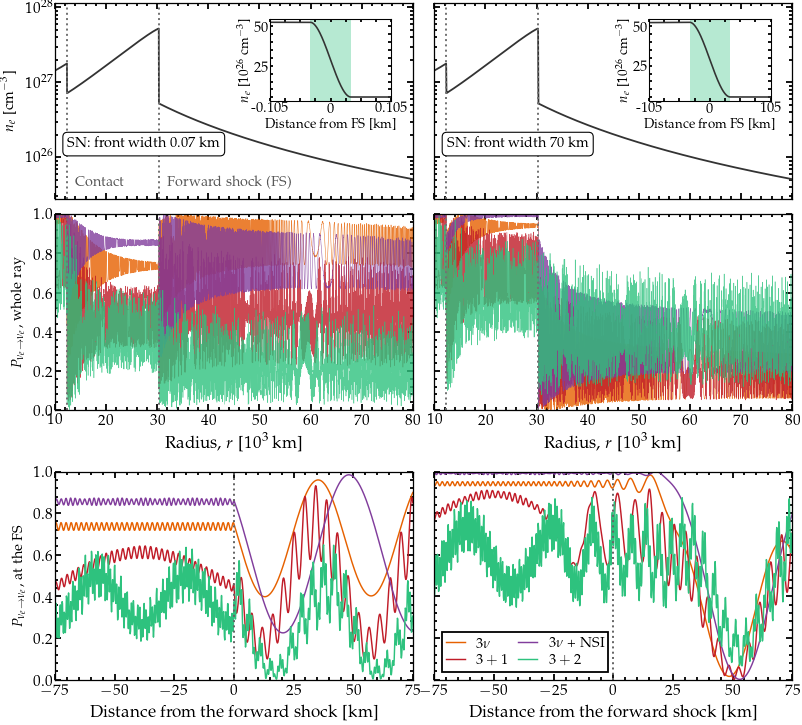

In [40]:
KM = gd.UNIT_KM
MEAN_NUCLEON = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
R_CONTACT_KM, R_FORWARD_KM = 12348.0, 30323.0
R0_KM, R1_KM = 1.0e4, 8.0e4
L0, L1 = R0_KM*KM, R1_KM*KM
ENERGY = 15.0*gd.UNIT_MEV


def smoothstep(u):
    u = np.clip(np.asarray(u, dtype=float), 0.0, 1.0)
    return u*u*(3.0 - 2.0*u)


def rarefaction(r_km, r_shock_km):
    """ln f(x) = [0.28 - 0.69 ln(x_s/km)] [arcsin(1 - x/x_s)]^1.1  (Fogli et al. 2003)."""
    u = np.clip(1.0 - np.asarray(r_km, dtype=float)/r_shock_km, 0.0, 1.0)
    return np.exp((0.28 - 0.69*np.log(r_shock_km))*np.arcsin(u)**1.1)


def sn_shock_ne(width_frac, contact_jump=2.5, y_e=0.5):
    """Electron number density along the ray, for a front of the given width."""
    w_km = float(width_frac)*(R1_KM - R0_KM)

    def ne(l):
        r = np.asarray(l, dtype=float)/KM
        rho = 1.0e14*r**(-2.4)
        shocked = smoothstep((R_FORWARD_KM + 0.5*w_km - r)/w_km)
        factor = 1.0 + shocked*(10.0*rarefaction(r, R_FORWARD_KM) - 1.0)
        inside = smoothstep((R_CONTACT_KM + 0.5*w_km - r)/w_km)
        factor = factor*(1.0 + inside*(contact_jump - 1.0))
        out = rho*factor*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*y_e
        return out[()] if np.ndim(out) == 0 else out

    return ne


def shock_breakpoints(width_frac):
    w_km = float(width_frac)*(R1_KM - R0_KM)
    edges = []
    for r in (R_CONTACT_KM, R_FORWARD_KM):
        edges += [(r - 0.5*w_km)*KM, (r + 0.5*w_km)*KM]
    return np.array([L0] + sorted(edges) + [L1])


WIDTHS = (1.0e-6, 1.0e-3)
OSC4 = dict(OSC); OSC4.update(STERILE4); OSC4.update(d14=0.0, d24=0.0)
OSC5_SHOCK = dict(OSC); OSC5_SHOCK.update(STERILE5)
OSC5_SHOCK.update(d14=0.0, d24=0.0, d15=0.0, d25=0.0, d35=0.0)
OSC2 = dict(sth=OSC['s12'], Dm2=OSC['D21'])
HALF_KM = 75.0
WIN = (R_FORWARD_KM - HALF_KM, R_FORWARD_KM + HALF_KM)
L_OSC_KM = 4.0*np.pi*ENERGY/OSC['D21']/KM
print('vacuum oscillation length at %g MeV: %.0f km; the ray spans %.0f of them'
      % (ENERGY/gd.UNIT_MEV, L_OSC_KM, (R1_KM - R0_KM)/L_OSC_KM))

Ls_full = np.linspace(1.02*L0, L1, 4000)
Ls_win = np.linspace(WIN[0]*KM, WIN[1]*KM, 1000)
COMMON = dict(L0=L0, nu_i=gd.NUE, nu_f=gd.NUE,
              density_is_of_number_of_electrons=True, rtol=RTOL_FIG, atol=ATOL_FIG)

SCEN = [
    (r'$3\nu$', ORANGE, lambda ne, bp, Ls: oscprob.osc_prob_matter_std_potential(
        3, ne, ENERGY, Ls, OSC, t_breakpoints=bp, **COMMON)),
    (r'$3+1$', RED, lambda ne, bp, Ls: oscprob.osc_prob_matter_std_potential(
        4, ne, ENERGY, Ls, OSC4, t_breakpoints=bp, **COMMON)),
    (r'$3\nu$ + NSI', PURPLE, lambda ne, bp, Ls: oscprob.osc_prob_matter_nsi(
        3, ne, ENERGY, Ls, OSC, EPS, t_breakpoints=bp, **COMMON)),
    (r'$3+2$', GREEN, lambda ne, bp, Ls: oscprob.osc_prob_matter_std_potential(
        5, ne, ENERGY, Ls, OSC5_SHOCK, t_breakpoints=bp, **COMMON)),
]

# Which engine answers?  Worth reporting, because the paper describes an adiabatic
# strategy at length and it is NOT what runs here: a baseline scan at one energy goes
# to the cumulative engine, and declared breakpoints make the hybrid stand aside in
# any case.  The whole ray is the Magnus ladder.
info = {}
quiet(oscprob.osc_prob_matter_std_potential, 3, sn_shock_ne(1e-3), ENERGY,
      Ls_full[:40], OSC, t_breakpoints=shock_breakpoints(1e-3),
      strategy_info=info, **COMMON)
print('engine answering this figure: %r (declined: %s)'
      % (info.get('engine'), [d[0] for d in (info.get('declined') or [])] or 'none'))

# Rows 1 and 2 share the full-ray axis and sit tight against each other; row 3 is a
# different axis entirely (a window at the front), so it gets its own block and its
# own gap.  A single hspace cannot do both.
fig = plt.figure(figsize=(WIDE, 6.3))
outer = fig.add_gridspec(2, 1, height_ratios=[2.25, 1.15], hspace=0.20)
gs_top = outer[0].subgridspec(2, 2, height_ratios=[1.15, 1.15], hspace=0.08,
                              wspace=0.06)
gs_bot = outer[1].subgridspec(1, 2, wspace=0.06)
axes = np.empty((3, 2), dtype=object)
for c in range(2):
    axes[0, c] = fig.add_subplot(gs_top[0, c])
    axes[1, c] = fig.add_subplot(gs_top[1, c], sharex=axes[0, c])
    axes[2, c] = fig.add_subplot(gs_bot[0, c])

for col, width in enumerate(WIDTHS):
    ne = sn_shock_ne(width)
    bp = shock_breakpoints(width)
    w_km = width*(R1_KM - R0_KM)
    wlab = ('%.2f' % w_km).rstrip('0').rstrip('.')
    top, mid, bot = axes[0, col], axes[1, col], axes[2, col]

    top.semilogy(Ls_full/KM/1.0e3, np.asarray(ne(Ls_full))/gd.UNIT_PER_CM3,
                 color=INK, lw=1.0)
    logy(top)
    # Limits from the data: they were pinned to the old MeV^3 scaling, which put the
    # cm^-3 curve thirty decades off the panel.
    ne_full = np.asarray(ne(Ls_full))/gd.UNIT_PER_CM3
    top.set_ylim(0.55*ne_full.min(), 2.2*ne_full.max())
    # Placed against the density rather than the panel top, so it sits over the flat
    # part of the profile instead of over its rise.
    top.text(0.035, 1.5e26, r'SN: front width %s km' % wlab, transform=
             top.get_yaxis_transform(), ha='left', va='center', fontsize=8.0,
             color='black', zorder=10,
             bbox=dict(boxstyle='round,pad=0.32', facecolor='white',
                       edgecolor='black', linewidth=0.6))

    # The front is 0.1% of the ray at most, so it cannot show on the axis above.  The
    # inset is the same window the bottom row uses, and is the only place the two
    # columns differ to the eye.
    # The inset spans a few front widths, not a fixed window: at 0.07 km a +/- 75 km
    # view shows a vertical line and no shaded band at all.
    half_in = max(1.5*w_km, 0.05)
    r_in = np.linspace(R_FORWARD_KM - half_in, R_FORWARD_KM + half_in, 600)
    ins = top.inset_axes([0.60, 0.50, 0.34, 0.42])
    # Scaled to 1e-5 MeV^3 so the axis needs no offset text, which collided with the
    # inset's own title at this size.
    ins.plot(r_in - R_FORWARD_KM,
             np.asarray(ne(r_in*KM))/gd.UNIT_PER_CM3/1.0e26, color=INK, lw=0.9)
    ins.axvspan(-0.5*w_km, 0.5*w_km, color=GREEN, alpha=0.35, lw=0, zorder=0)
    ins.set_xlim(-half_in, half_in)
    ins.set_xticks((-half_in, 0.0, half_in))
    ins.set_xticklabels([('%g' % v) for v in (-half_in, 0, half_in)])
    ins.yaxis.set_major_locator(plt.MaxNLocator(2))
    ins.tick_params(labelsize=8.0, pad=0.8, length=1.6)
    for side in ins.spines.values():
        side.set_linewidth(0.6)
    ins.set_xlabel(r'Distance from FS [km]', fontsize=7.4, labelpad=1.0)
    ins.set_ylabel(r'$n_e$ [$10^{26}$ cm$^{-3}$]', fontsize=7.4, labelpad=1.0)
    # A box on the parent marking where the inset was taken from, with corner
    # connectors.  At 0.07 km the box is a hairline, which is the honest width.
    lo, hi = top.get_ylim()
    rect, lines = top.indicate_inset(
        ((R_FORWARD_KM - half_in)/1.0e3, lo, 2.0*half_in/1.0e3, hi - lo),
        inset_ax=ins, edgecolor='0.45', linewidth=0.5, alpha=1.0)
    # Neither the marking box nor its connectors survive: the box spans the full height
    # of the panel, so at 70 km it reads as a shaded block standing over the shock.
    rect.set(visible=False)
    for ln in lines:
        ln.set(visible=False)

    for label, color, call in SCEN:
        def _run(call=call, ne=ne, bp=bp):
            return dict(full=np.asarray(quiet(call, ne, bp, Ls_full)).tolist(),
                        win=np.asarray(quiet(call, ne, bp, Ls_win)).tolist())
        _g = cached('shock_%s_%s' % (re.sub(r'\W+', '_', label).strip('_'),
                                     ('%g' % w_km).replace('.', 'p')),
                    ('shock', label, float(w_km), float(ENERGY),
                     [float(x) for x in Ls_full[::40]], [float(x) for x in Ls_win[::40]],
                     sorted(OSC.items()), sorted(STERILE4.items()),
                     sorted(STERILE5.items()), sorted((k, str(v)) for k, v in EPS.items())),
                    _run, what='one shock scenario at one front width')
        P_full, P_win = np.asarray(_g['full']), np.asarray(_g['win'])
        mid.plot(Ls_full/KM/1.0e3, P_full, color=color, lw=0.3, alpha=0.8)
        bot.plot(Ls_win/KM - R_FORWARD_KM, P_win, color=color, lw=0.8, label=label)
        print('  width %6.2f km  %-13s full P in %.3f-%.3f'
              % (w_km, label, P_full.min(), P_full.max()))

    for ax in (top, mid):
        ax.set_xlim(R0_KM/1.0e3, R1_KM/1.0e3)
        ax.xaxis.set_minor_locator(AutoMinorLocator(5))
        for r in (R_CONTACT_KM, R_FORWARD_KM):
            ax.axvline(r/1.0e3, color='0.45', lw=1.1, ls=':')
    top.tick_params(labelbottom=False)
    mid.set_ylim(0.0, 1.0); minor_y(mid, 5)
    mid.set_xlabel(r'Radius, $r$ [$10^3$ km]')

    bot.set_xlim(-HALF_KM, HALF_KM)
    bot.xaxis.set_minor_locator(AutoMinorLocator(5))
    bot.axvline(0.0, color='0.4', lw=1.1, ls=':')
    bot.set_ylim(0.0, 1.0); minor_y(bot, 5)
    bot.set_xlabel(r'Distance from the forward shock [km]')

    if col:
        for ax in (top, mid, bot):
            ax.tick_params(labelleft=False)

axes[0, 0].set_ylabel(r'$n_e$ [cm$^{-3}$]', fontsize=8.0)
axes[1, 0].set_ylabel(r'$P_{\nu_e \to \nu_e}$, whole ray', fontsize=8.0)
axes[2, 0].set_ylabel(r'$P_{\nu_e \to \nu_e}$, at the FS', fontsize=8.0)
axes[2, 1].legend(loc='lower left', handlelength=1.3, ncol=2, columnspacing=0.7,
                  labelspacing=0.2, fontsize=8.0)
# Named on both rows that show them: the bottom row speaks of "the forward shock"
# while the profile above carries two, which is a question a reader should not have
# to hold open.
for r, name in ((R_CONTACT_KM, 'Contact'), (R_FORWARD_KM, 'Forward shock (FS)')):
    axes[0, 0].annotate(name, xy=(r/1.0e3, 0.04),
                        xycoords=axes[0, 0].get_xaxis_transform(),
                        xytext=(4.5, 0), textcoords='offset points',
                        fontsize=8.0, color='0.35', ha='left', va='bottom')
save(fig, 'shock_probability.pdf')

## Figure 6b --- the shock signature against energy

The observable of a supernova signal is averaged twice over: over the phase accumulated
after the last front, which no detector resolves, and over the phase accumulated between
the two fronts, which makes the two crossings interfere and turns over every few keV in
energy, so that any detector's resolution smears it out.  A mean of the resolved scan over
the last stretch of the ray keeps that interference and is not the observable.

On a profile with declared fronts, `average=True` propagates the probability at 41 energies
across a window of $\pm 10\%$ and returns their mean, warning that it did so and quoting the
standard error of the mean (`avgprob.averaged_probabilities_numerically`).  This cell calls
that route directly, once per energy, so that it also has the standard errors to draw, and
checks at 15 MeV that `average=True` returns the same number.  Without a shock the profile is
smooth and the same keyword takes the adiabatic route, which certifies.

In [41]:
def undisturbed_ne(l):
    r = np.asarray(l, dtype=float)/KM
    out = 1.0e14*r**(-2.4)*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*0.5
    return out[()] if np.ndim(out) == 0 else out


E_SN = np.logspace(np.log10(5.0), np.log10(60.0), 60)*gd.UNIT_MEV
KW_SN = dict(L0=L0, nu_i=gd.NUE, nu_f=gd.NUE, density_is_of_number_of_electrons=True)
got = cached('shock_energy_none',
             ('shock energy', 'none', [float(e) for e in E_SN], float(L1),
              [float(undisturbed_ne(x)) for x in np.linspace(L0, L1, 9)], sorted(OSC.items())),
             lambda: dict(P=np.asarray(quiet(oscprob.osc_prob_matter_std_potential, 3,
                                             undisturbed_ne, E_SN, L1, OSC, average=True,
                                             **KW_SN)).tolist()),
             what='the no-shock averaged curve, adiabatic route')
SN_ENERGY = {'none': dict(mean=np.asarray(got['P']))}
print('no shock: adiabatic route, P in %.3f..%.3f' % (SN_ENERGY['none']['mean'].min(),
                                                      SN_ENERGY['none']['mean'].max()))
for key, width in (('0p07', 1.0e-6), ('70', 1.0e-3)):
    ne, bp = sn_shock_ne(width), shock_breakpoints(width)

    def prob_of_energy(e, ne=ne, bp=bp):
        return np.asarray(quiet(oscprob.osc_prob_matter_std_potential, 3, ne, e, L1, OSC,
                                t_breakpoints=bp, **KW_SN))

    def run(prob_of_energy=prob_of_energy):
        means, sems = [], []
        for e in E_SN:
            m, sem = avgprob.averaged_probabilities_numerically(prob_of_energy, float(e))
            means.append(float(m)); sems.append(float(sem))
        return dict(mean=means, sem=sems)
    got = cached('shock_energy_%s' % key,
                 ('shock energy', key, [float(e) for e in E_SN], float(L1),
                  [float(ne(x)) for x in np.linspace(L0, L1, 9)], sorted(OSC.items()),
                  float(avgprob.AVG_DEFAULT_ENERGY_SPREAD), int(avgprob.AVG_DEFAULT_N_SAMPLES)),
                 run, what='one shock width, the energy-window average at every energy')
    SN_ENERGY[key] = {k: np.asarray(v) for k, v in got.items()}
    w_km = width*(R1_KM - R0_KM)
    print('fronts %g km: window means in %.3f..%.3f, standard errors up to %.3f'
          % (w_km, SN_ENERGY[key]['mean'].min(), SN_ENERGY[key]['mean'].max(),
             SN_ENERGY[key]['sem'].max()))
    # average=True on the same call is this route: same window, same samples, same number.
    k = int(np.argmin(np.abs(E_SN/gd.UNIT_MEV - 15.0)))
    P_kw = float(quiet(oscprob.osc_prob_matter_std_potential, 3, ne, float(E_SN[k]), L1, OSC,
                       t_breakpoints=bp, average=True, **KW_SN))
    print('  at %.2f MeV: average=True %.6f, this route %.6f, difference %.1e'
          % (E_SN[k]/gd.UNIT_MEV, P_kw, SN_ENERGY[key]['mean'][k],
             abs(P_kw - SN_ENERGY[key]['mean'][k])))

  shock_energy_none read from paper_figure_cache.json, unchanged configuration 3f726a0d06ea (measured 2026-09-20 on laptop-6)
no shock: adiabatic route, P in 0.025..0.046
  shock_energy_0p07 read from paper_figure_cache.json, unchanged configuration 4c7214322518 (measured 2026-09-20 on laptop-6)
fronts 0.07 km: window means in 0.046..0.575, standard errors up to 0.042


  at 14.95 MeV: average=True 0.574680, this route 0.574680, difference 1.1e-16
  shock_energy_70 read from paper_figure_cache.json, unchanged configuration e178aae30f6d (measured 2026-09-20 on laptop-6)
fronts 70 km: window means in 0.034..0.565, standard errors up to 0.033


  at 14.95 MeV: average=True 0.370974, this route 0.370974, difference 1.1e-16


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/shock_energy.pdf


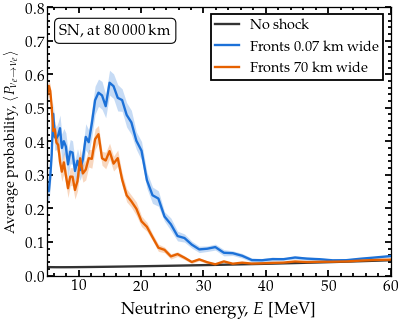

In [42]:
fig, ax = plt.subplots(figsize=(COL, 2.5))
ax.plot(E_SN/gd.UNIT_MEV, SN_ENERGY['none']['mean'], color=INK, lw=1.3, label='No shock')
for key, color, label in (('0p07', BLUE, 'Fronts 0.07 km wide'),
                          ('70', ORANGE, 'Fronts 70 km wide')):
    m, s = SN_ENERGY[key]['mean'], SN_ENERGY[key]['sem']
    ax.fill_between(E_SN/gd.UNIT_MEV, m - s, m + s, color=color, alpha=0.25, lw=0)
    ax.plot(E_SN/gd.UNIT_MEV, m, color=color, lw=1.3, label=label)
ax.set_xlim(5.0, 60.0); ax.set_ylim(0.0, 0.8)
ax.xaxis.set_minor_locator(AutoMinorLocator(5)); minor_y(ax, 5)
ax.set_xlabel(r'Neutrino energy, $E$ [MeV]')
ax.set_ylabel(r'Average probability, $\langle P_{\nu_e \to \nu_e}\rangle$', fontsize=8.0)
ax.legend(loc='upper right', handlelength=1.6)
corner(ax, r'SN, at $80\,000$ km', loc='upper left', x=0.035, y=0.94)
fig.subplots_adjust(left=0.20)
save(fig, 'shock_energy.pdf')

### Figure 8 --- what an astrophysical flux arrives as

Decohered over the distance, so the observable is the flavor composition. Standard
oscillations make it independent of energy; the figure asks which new physics does not.

  astro_vacuum read from paper_figure_cache.json, unchanged configuration 0b3a6f73fb96 (measured 2026-09-21 on laptop-6)
  astro_liv read from paper_figure_cache.json, unchanged configuration f6e1715bcbe4 (measured 2026-09-21 on laptop-6)


  astro_earth_nsi read from paper_figure_cache.json, unchanged configuration 95ad779e8715 (measured 2026-09-21 on laptop-6)
  astro_pseudo_dirac read from paper_figure_cache.json, unchanged configuration eeaddf717484 (measured 2026-09-21 on laptop-6)
  Standard 3\nu        survival at 1 TeV 0.548/0.407/0.386 -> at 10 PeV 0.548/0.407/0.386
  LIV                  survival at 1 TeV 0.548/0.407/0.386 -> at 10 PeV 0.894/0.502/0.454


  NSI through Earth    survival at 1 TeV 0.546/0.395/0.383 -> at 10 PeV 0.546/0.396/0.383
  3+1                  sterile takes 0.133-0.133 of the flux before renormalizing
  3+1                  survival at 1 TeV 0.454/0.321/0.386 -> at 10 PeV 0.454/0.321/0.386
  Pseudo-Dirac, \nu_2  sterile takes 0.193-0.193 of the flux before renormalizing
  Pseudo-Dirac, \nu_2  survival at 1 TeV 0.503/0.315/0.350 -> at 10 PeV 0.503/0.315/0.350


/tmp/ipykernel_2377836/2618499921.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3, w_pad=0.3, h_pad=0.4)


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/astro_composition.pdf


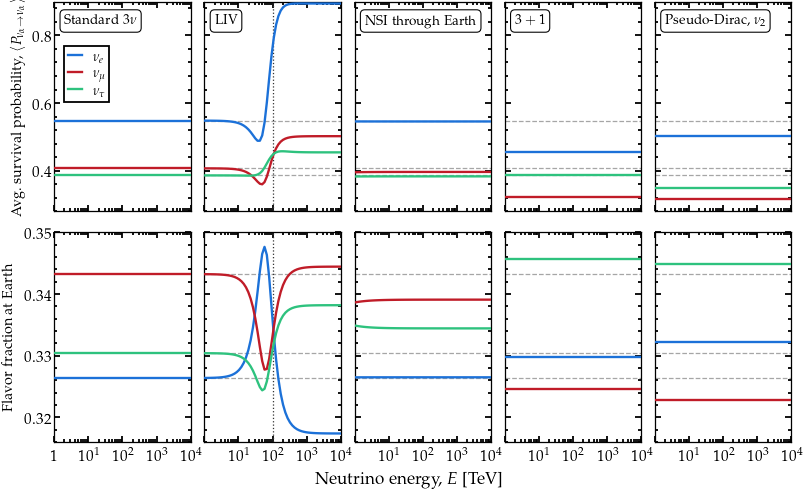

In [43]:
# ------------------------------------ Figure 8: what an astrophysical flux arrives as
# A neutrino from a distant source arrives decohered, so what is observable is not a
# probability curve but the flavor composition.  For standard oscillations that
# composition does not depend on energy at all; the point of the figure is which new
# physics makes it depend on energy, and where.
E_ASTRO = np.logspace(np.log10(1.0e3), np.log10(1.0e7), 60)*gd.UNIT_GEV   # 1 TeV to 10 PeV
PION_SOURCE = np.array([1.0/3.0, 2.0/3.0, 0.0])       # pion decay, before oscillating
COSTHZ_ASTRO = -1.0                                   # straight through the core
L_ASTRO = earth.distance_traveled_inside_earth(COSTHZ_ASTRO)*gd.CONV_KM_TO_INV_EV

# The LIV eigenvalue is fixed by where we want the new term to equal the vacuum one,
# rather than chosen for its size: at E_STAR the two are the same to within a percent.
N_LIV, E_STAR = 1, 100.0e3*gd.UNIT_GEV
B3_ASTRO = float(OSC['D31'])/(2.0*E_STAR**(N_LIV + 1))

# The wrappers carry the phase average with one keyword: each pair's interference is
# weighted by exp(-sigma^2 phi'^2/2), phi' the slope of its phase in ln E.  So the baseline
# has to be astrophysical in fact: at 100 Mpc every pair has decohered at every energy
# drawn and the spread sigma drops out, while over 1e8 km, less than an astronomical unit,
# some pairs keep part of their phase from 1 to 100 TeV, and the wrapper warns there that
# the result depends on the spread.
L_SOURCE = 100.0*3.0857e19*gd.CONV_KM_TO_INV_EV        # 100 Mpc [eV^-1]
LIV_ASTRO = dict(sxi12=OSC['s12'], sxi23=OSC['s23'], sxi13=OSC['s13'], dxiCP=0.0,
                 b1=0.0, b2=0.0, b3=B3_ASTRO, Lambda=1.0, n_liv=N_LIV)


def _astro_vac():
    return dict(p3=np.asarray(oscprob.osc_prob_3nu_vacuum(
                    E_ASTRO, L_SOURCE, average=True, **OSC)).tolist(),
                p4=np.asarray(oscprob.osc_prob_4nu_vacuum(
                    E_ASTRO, L_SOURCE, average=True, s14=STERILE4['s14'], s24=STERILE4['s24'],
                    s34=STERILE4['s34'], D41=STERILE4['D41'], **OSC)).tolist())


_av = cached('astro_vacuum',
             ('astro_vac', 'wrapper', [float(e) for e in E_ASTRO], float(L_SOURCE),
              sorted(OSC.items()), sorted(STERILE4.items())), _astro_vac,
             what='the decohered vacuum matrices')
P_VAC3, P_VAC4 = np.asarray(_av['p3']), np.asarray(_av['p4'])
P_LIV = np.asarray(cached(
    'astro_liv',
    ('astro_liv', 'wrapper', [float(e) for e in E_ASTRO], float(L_SOURCE), N_LIV,
     float(B3_ASTRO), sorted(OSC.items())),
    lambda: np.asarray(oscprob.osc_prob_3nu_vacuum_liv(
        E_ASTRO, L_SOURCE, average=True, **LIV_ASTRO, **OSC)).tolist(),
    what='the decohered matrices with a Lorentz-violating term'))
# Through the Earth the flux is already decohered when it arrives, so the two legs
# compose as probability matrices rather than as amplitudes.
# The ladder starts at 32 slabs, as in the paper's listing: on a coarser first level the
# matter term alone winds more than pi across a slab, and the expansion says so.
P_EARTH = np.asarray(cached(
    'astro_earth_nsi',
    ('astro_earth', [float(e) for e in E_ASTRO], COSTHZ_ASTRO, float(L_ASTRO),
     sorted(OSC.items()), sorted((k, str(v)) for k, v in EPS.items()), 32),
    lambda: np.asarray(oscprob.osc_prob_3nu_earth_nsi(E_ASTRO, costhz=COSTHZ_ASTRO, L=L_ASTRO,
                                                       n_slabs=32, **OSC, **EPS, rtol=1e-6,
                                                       atol=1e-8)).tolist(),
    what='the Earth leg with non-standard interactions'))
P_NSI = np.einsum('ij,ejk->eik', P_VAC3[0], P_EARTH)

# Pseudo-Dirac: each mass state may be two states split by a tiny delta m^2.  Pairing is
# chosen per state, and that is the whole of the physics here: pair all three and every
# active-active probability halves by the same factor, so the composition is untouched.
# Pair one, and the suppression is uneven and the composition moves.  We pair the second
# mass state alone.  At 100 Mpc a splitting of 1e-13 eV^2 winds the pair's phase through
# 78 rad or more at every energy drawn, so the pair has decohered.  No wrapper ships this
# Hamiltonian, so it is built as a matrix and handed to osc_prob_energy_baseline, which
# takes a fixed matrix to its decohered limit: it groups the spectrum itself, and finds
# four singletons.
PD_PAIRS = {1: 1.0e-13}
U_PMNS = np.asarray(hamiltonians.pmns_mixing_matrix(
    OSC['s12'], OSC['s23'], OSC['s13'], OSC['dCP']), dtype=complex)
M2_PMNS = np.array([0.0, float(OSC['D21']), float(OSC['D31'])])


def _astro_pd():
    out = []
    for e in E_ASTRO:
        H = hamiltonians.hamiltonian_pseudo_dirac_vacuum(e, U_PMNS, M2_PMNS, PD_PAIRS)
        out.append(np.asarray(oscprob.osc_prob_energy_baseline(
            H, e, L_SOURCE, average=True)).tolist())
    return out


P_PD = np.asarray(cached(
    'astro_pseudo_dirac',
    ('astro_pd', 'direct route', [float(e) for e in E_ASTRO], sorted(PD_PAIRS.items()),
     float(L_SOURCE), sorted(OSC.items())),
    _astro_pd, what='the decohered matrices with one pseudo-Dirac pair'))

COMP_STD = np.einsum('a,eab->eb', PION_SOURCE, P_VAC3)
COMP_STD = COMP_STD/COMP_STD.sum(axis=1)[:, None]
CASES = [(r'Standard $3\nu$', P_VAC3, 3),
         (r'LIV',            P_LIV,  3),
         (r'NSI through Earth', P_NSI, 3),
         (r'$3+1$',           P_VAC4, 4),
         (r'Pseudo-Dirac, $\nu_2$', P_PD, 4)]
FCOL = {0: BLUE, 1: RED, 2: GREEN}
FLAB = {0: r'$\nu_e$', 1: r'$\nu_\mu$', 2: r'$\nu_\tau$'}

fig, axes = plt.subplots(2, 5, figsize=(WIDE, 4.1), sharex=True, sharey='row',
                         gridspec_kw=dict(hspace=0.10, wspace=0.10))
for col, (label, P, d) in enumerate(CASES):
    src = np.zeros(d); src[:3] = PION_SOURCE
    comp = np.einsum('a,eab->eb', src, P)[:, :3]
    # Renormalized to the active flavors: what a detector measures is the ratio among
    # the three it can see, and the sterile share is not observed rather than being a
    # fourth number to compare against.
    comp = comp/comp.sum(axis=1)[:, None]
    top, bot = axes[0, col], axes[1, col]
    for a in range(3):
        # The standard case under every panel, so that a small departure from it is
        # visible.  Three of the four cases are flat in energy; without the reference a
        # reader cannot see which of them sit at a different value.
        if col > 0:
            top.semilogx(E_ASTRO/gd.UNIT_TEV, P_VAC3[:, a, a], color='0.65', lw=0.7,
                         ls='--', zorder=1)
            bot.semilogx(E_ASTRO/gd.UNIT_TEV, COMP_STD[:, a], color='0.65', lw=0.7,
                         ls='--', zorder=1)
        top.semilogx(E_ASTRO/gd.UNIT_TEV, P[:, a, a], color=FCOL[a], lw=1.3, zorder=3,
                     label=FLAB[a] if col == 0 else None)
        bot.semilogx(E_ASTRO/gd.UNIT_TEV, comp[:, a], color=FCOL[a], lw=1.3, zorder=3)
    for ax in (top, bot):
        logx(ax); snug(ax, E_ASTRO/gd.UNIT_TEV)
    bot.xaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=12))
    unit_as_one(bot, which='x')
    corner(top, label, loc='upper left', x=0.075, fontsize=7.6)
    if d > 3:
        lost = 1.0 - np.einsum('a,eab->eb', src, P)[:, :3].sum(axis=1)
        print('  %-20s sterile takes %.3f-%.3f of the flux before renormalizing'
              % (label.replace('$', ''), lost.min(), lost.max()))
    print('  %-20s survival at 1 TeV %.3f/%.3f/%.3f -> at 10 PeV %.3f/%.3f/%.3f'
          % (label.replace('$', ''), P[0, 0, 0], P[0, 1, 1], P[0, 2, 2],
             P[-1, 0, 0], P[-1, 1, 1], P[-1, 2, 2]))
for _a in axes[1, :]:
    _a.tick_params(axis='x', which='major', pad=4.5)
fig.supxlabel(r'Neutrino energy, $E$ [TeV]',
              fontsize=plt.rcParams['axes.labelsize'], x=0.55, y=0.050)
axes[0, 0].set_ylabel(r'Avg.~survival probability, $\langle P_{\nu_\alpha \to \nu_\alpha}\rangle$',
                      fontsize=8.0)
axes[1, 0].set_ylabel(r'Flavor fraction at Earth', fontsize=8.0)
# Ranges chosen to show the differences rather than the distance from zero: every
# survival probability here lives above 0.30, and every flavor fraction between 0.31
# and 0.35.  The top is left to the data, so the LIV excursion is not clipped.
axes[0, 0].set_ylim(0.28, 0.90); minor_y(axes[0, 0], 5)
axes[1, 0].set_ylim(0.316, 0.35); minor_y(axes[1, 0], 5)
axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0.02, 0.82), handlelength=1.1,
                  fontsize=7.4, ncol=1, labelspacing=0.25, borderpad=0.3)
axes[0, 1].axvline(E_STAR/gd.UNIT_TEV, color=INK, lw=0.7, ls=':')
axes[1, 1].axvline(E_STAR/gd.UNIT_TEV, color=INK, lw=0.7, ls=':')
fig.tight_layout(pad=0.3, w_pad=0.3, h_pad=0.4)
# Only the first column keeps its leftmost tick label; in the others it would sit
# against the previous panel's right spine.  This has to be done on the drawn text.
# sharex makes the five columns share one Ticker, so a formatter set on any of them
# governs all of them, and hiding a tick's label is undone by the next draw.
fig.canvas.draw()
for _ax in axes[1, 1:]:
    for _lb in _ax.get_xticklabels():
        if _lb.get_text() in ('$1$', '1'):
            _lb.set_visible(False)
save(fig, 'astro_composition.pdf')

### Figure 8b --- the composition on the flavor triangle

Two of the departures of Figure 8, each as a curve in its own parameter: the eigenvalue of
the Lorentz-violating operator at 100 TeV, and the two active--sterile angles of the $3+1$
case, grown together from zero. Every composition lies within 0.03 of the standard point,
so the triangle is drawn over 0.30 to 0.40 on each axis. The simplex is drawn by
`python-ternary`, an extra of the notebooks and not a dependency of the package; the
layout, labels, ticks and marker styles follow the author's flavor-triangle figures
elsewhere.

  standard, vacuum: 0.3264 : 0.3432 : 0.3304
  LIV at   0.1 times the vacuum term: 0.3376 : 0.3358 : 0.3266
  LIV at   1.0 times the vacuum term: 0.3357 : 0.3333 : 0.3310
  LIV at  10.0 times the vacuum term: 0.3193 : 0.3432 : 0.3375
  3+1 at sin^2 = 0.1: 0.3298 : 0.3246 : 0.3457
  3+1 at sin^2 = 0.2: 0.3376 : 0.3225 : 0.3399
  3+1 at sin^2 = 0.3: 0.3495 : 0.3342 : 0.3164
  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/astro_ternary.pdf


/home/mbustamante/anaconda3/lib/python3.12/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


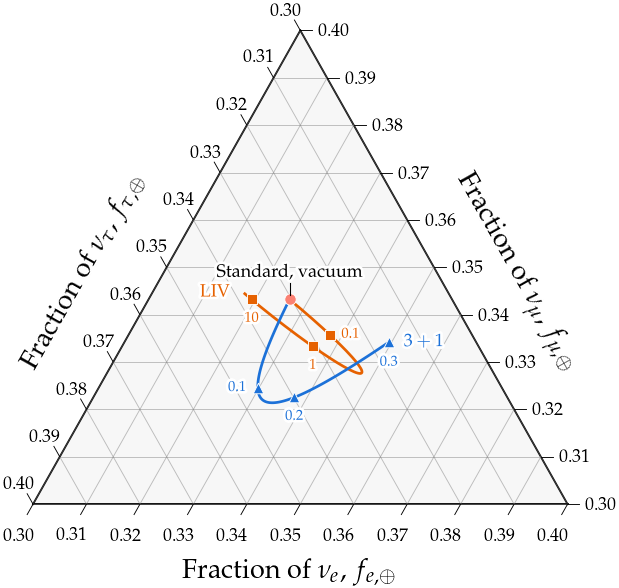

In [44]:
# ------------------------------------ Figure 8b: the composition on the flavor triangle
import ternary

E_TRI = 100.0*gd.UNIT_TEV
F_VAC = COMP_STD[0]
# LIV: b3 grows from zero at 100 TeV.  The ratio of the new term to the vacuum one runs
# from 1e-3 to 1e3, which at the fixed b3 of Figure 8 is its sweep from 3 TeV to 3 PeV.
TRI_RATIOS = np.concatenate([[0.0], np.logspace(-3.0, 3.0, 241)])
B3_UNIT = float(OSC['D31'])/(2.0*E_TRI**2)


def tri_liv(ratio):
    P = np.asarray(oscprob.osc_prob_3nu_vacuum_liv(
        E_TRI, L_SOURCE, average=True, **dict(LIV_ASTRO, b3=ratio*B3_UNIT), **OSC))
    f = np.einsum('a,ab->b', PION_SOURCE, P)
    return f/f.sum()


# 3+1: sin^2 theta_14 = sin^2 theta_24 grow together from zero; the fractions are
# renormalized to the three active flavors, as in Figure 8.
TRI_S2 = np.linspace(0.0, 0.3, 121)


def tri_sterile(s2):
    P = np.asarray(oscprob.osc_prob_4nu_vacuum(
        E_TRI, L_SOURCE, average=True, s14=np.sqrt(s2), s24=np.sqrt(s2), s34=0.0,
        D41=STERILE4['D41'], **OSC))
    src = np.zeros(4); src[:3] = PION_SOURCE
    f = np.einsum('a,ab->b', src, P)[:3]
    return f/f.sum()


F_LIV = np.array([tri_liv(r) for r in TRI_RATIOS])
F_STERILE = np.array([tri_sterile(s2) for s2 in TRI_S2])
print('  standard, vacuum: %.4f : %.4f : %.4f' % tuple(F_VAC))
for r in (0.1, 1.0, 10.0):
    kk = int(np.argmin(np.abs(TRI_RATIOS - r)))
    print('  LIV at %5.1f times the vacuum term: %.4f : %.4f : %.4f' % ((r,) + tuple(F_LIV[kk])))
for s2 in (0.1, 0.2, 0.3):
    kk = int(np.argmin(np.abs(TRI_S2 - s2)))
    print('  3+1 at sin^2 = %.1f: %.4f : %.4f : %.4f' % ((s2,) + tuple(F_STERILE[kk])))

# A zoomed simplex: each fraction from 0.30 to 0.40 (0.30 + 0.30 + 0.30 + 0.10 = 1), at
# scale 10 so that one unit is 0.01.  Points go through convert_coordinates in the order
# (b, r, l) = (f_e, f_mu, f_tau): nu_e along the bottom, nu_mu up the right side, nu_tau
# down the left side.
LO, HI, SCALE = 0.30, 0.40, 10
fig, tax = ternary.figure(scale=SCALE)
tax.ax.axis('off')
fig.set_facecolor('w')
tax.set_axis_limits({'b': [LO, HI], 'l': [LO, HI], 'r': [LO, HI]})
tax.boundary(linewidth=1.0)
tax.gridlines(color='gray', multiple=1, linewidth=0.5, ls='-', alpha=0.5)
tax.left_axis_label(r'Fraction of $\nu_\tau$, $f_{\tau, \oplus}$', fontsize=15, offset=0.16)
tax.right_axis_label(r'Fraction of $\nu_\mu$, $f_{\mu, \oplus}$', fontsize=15, offset=0.16)
tax.bottom_axis_label(r'Fraction of $\nu_e$, $f_{e, \oplus}$', fontsize=15, offset=0.08)
tax.get_ticks_from_axis_limits(multiple=1)
tax.set_custom_ticks(linewidth=0.5, multiple=1, offset=0.022, clockwise=False, tick_formats='%.2f')


def tri_conv(points):
    return tax.convert_coordinates(np.atleast_2d(points), axisorder='brl')


def tri_xy(point):
    p = np.asarray(tri_conv(point))[0]
    return p[0] + 0.5*p[1], np.sqrt(3.0)/2.0*p[1]


def tri_note(text, x, y, ha='left', va='center', size=10, color='k'):
    t = tax.ax.annotate(text, xy=(x, y), xycoords='data', color=color, fontsize=size, ha=ha,
                        va=va, zorder=200)
    t.set_path_effects([pe.Stroke(linewidth=3, foreground='white'), pe.Normal()])
    return t


tax.plot(tri_conv(F_LIV), linewidth=1.5, color=ORANGE, zorder=50)
tax.plot(tri_conv(F_STERILE), linewidth=1.5, color=BLUE, zorder=50)
for r, lab, off, ha, va in ((0.1, '0.1', (0.22, 0.0), 'left', 'center'),
                            (1.0, '1', (0.0, -0.22), 'center', 'top'),
                            (10.0, '10', (0.0, -0.22), 'center', 'top')):
    kk = int(np.argmin(np.abs(TRI_RATIOS - r)))
    tax.scatter(tri_conv(F_LIV[kk]), marker='s', color=ORANGE, edgecolor='w', s=28,
                linewidths=0.5, zorder=100)
    tri_note(lab, *np.add(tri_xy(F_LIV[kk]), off), ha=ha, va=va, size=8, color=ORANGE)
for s2, lab, off, ha, va in ((0.1, '0.1', (-0.22, 0.0), 'right', 'center'),
                             (0.2, '0.2', (0.0, -0.22), 'center', 'top'),
                             (0.3, '0.3', (0.0, -0.24), 'center', 'top')):
    kk = int(np.argmin(np.abs(TRI_S2 - s2)))
    tax.scatter(tri_conv(F_STERILE[kk]), marker='^', color=BLUE, edgecolor='w', s=34,
                linewidths=0.5, zorder=100)
    tri_note(lab, *np.add(tri_xy(F_STERILE[kk]), off), ha=ha, va=va, size=8, color=BLUE)
tax.scatter(tri_conv(F_VAC), marker='o', color='salmon', edgecolor='w', s=40, linewidths=0.5,
            zorder=101, alpha=1.0)
tri_note(r'LIV', *np.add(tri_xy(F_LIV[-1]), (-0.28, 0.02)), ha='right', color=ORANGE)
tri_note(r'$3+1$', *np.add(tri_xy(F_STERILE[-1]), (0.28, 0.0)), ha='left', color=BLUE)
xv, yv = tri_xy(F_VAC)
tax.ax.plot([xv, xv], [yv + 0.08, yv + 0.30], color='k', lw=0.6, zorder=150)
tri_note(r'Standard, vacuum', xv, yv + 0.32, ha='center', va='bottom')
tax.clear_matplotlib_ticks()
tax._redraw_labels()
fig.tight_layout()
save(fig, 'astro_ternary.pdf')

## Figures 8c, 8d and 8e --- geoneutrinos

Antineutrinos from uranium and thorium decays in the crust and the mantle, reaching
Borexino at Gran Sasso, 1.4 km underground, from a few km to a full Earth diameter away.
Three figures: the geometry, with a quarter of the Earth cut away; the survival
probability against energy from four production points, resolved down to the pair split by
$\Delta m^2_{31}$; and where the detectable flux comes from, with what oscillations leave of
it. The Earth wrapper propagates from the far end of a chord, so the production point in
the local crust is run from the detector with the two depths in swapped roles and the
zenith angle taken at the production point: the survival probability of a flavor is the
same along a path and along its reverse. The energy curves, the local scan and the flux
integral are cached.

In [45]:
# ------------------------------------ Figures 8c-8e: geoneutrinos, the inputs
# Every probability is nubar_e survival on the Earth wrapper, with PREM's ocean layer
# replaced by rock, since Gran Sasso is a continental site.
D_DET, D_LOCAL = 1.4, 10.0             # km: the detector, and the local production depth
KW_GEO = dict(nubar=True, nu_i=gd.NUE, nu_f=gd.NUE, density_matter_ocean=2.65)
# Twelve energies per cycle of the pair split by Dm31^2 on the longest chord, 7,300 km,
# uniform in 1/E so that they are uniform in phase.  The window is the detectable one:
# inverse beta decay opens at 1.8 MeV, the uranium chain ends at 3.3 MeV.
E_GEO = 1.0/np.linspace(1.0/1.8, 1.0/3.3, 22500)*gd.UNIT_MEV
#              key        depth [km]  cos(theta_z)  run from the detector?
GEO_POINTS = [('local',        10.0,  0.078, True),
              ('far_crust',    20.0, -0.272, False),
              ('mantle',     1000.0, -0.552, False),
              ('core',       2800.0, -0.872, False)]
GEO_LABEL = {'local': r'Local crust, 100 km', 'far_crust': r'Far crust, 3\,400 km',
             'mantle': r'Mantle, 4\,300 km', 'core': r'Through core, 7\,300 km'}
GEO_COLOR = {'local': GREEN, 'far_crust': BLUE, 'mantle': ORANGE, 'core': RED}


def geo_depths(depth, from_detector, unit=1.0):
    # The wrapper's two depths, in the order the call needs them: the reversed call puts
    # the detector at the source's slot.
    return (dict(source_depth=D_DET*unit, detector_depth=depth*unit) if from_detector
            else dict(source_depth=depth*unit, detector_depth=D_DET*unit))


def geo_curve(depth, costhz, from_detector):
    return np.asarray(oscprob.osc_prob_3nu_earth(
        E_GEO, costhz=costhz, **geo_depths(depth, from_detector, gd.UNIT_KM), **KW_GEO))


GEO_CURVES, GEO_L = {}, {}
for key, depth, costhz, from_detector in GEO_POINTS:
    GEO_L[key] = earth.distance_traveled_inside_earth(costhz, **geo_depths(depth, from_detector))
    GEO_CURVES[key] = np.asarray(cached(
        'geo_energy_%s' % key,
        ('geo energy', key, depth, costhz, from_detector, D_DET, 1.8, 3.3, len(E_GEO),
         sorted(OSC.items()), sorted((k, str(v)) for k, v in KW_GEO.items())),
        lambda depth=depth, costhz=costhz, fd=from_detector: geo_curve(depth, costhz, fd).tolist(),
        what='nubar_e survival against energy from the %s production point' % key))
    edges = earth.prem_layer_edges_along_chord(costhz, **geo_depths(depth, from_detector))
    print('  %-9s %5.0f km deep, cos = %+.3f: L = %6.1f km, %d PREM boundaries, P in %.3f..%.3f'
          % (key, depth, costhz, GEO_L[key], len(edges), GEO_CURVES[key].min(),
             GEO_CURVES[key].max()))

# The line drawn across every panel: the phase average in vacuum, from the closed form.
P_GEO_VACUUM = float(oscprob.osc_prob_3nu_vacuum(E_GEO[0], 1.0e8*gd.UNIT_KM, average=True,
                                                  nubar=True, nu_i=gd.NUE, nu_f=gd.NUE, **OSC))
# Matter raises the average along each chord.  The passage is adiabatic, so the average is
# the two-endpoint form of the paper's Sec. 4.10, which the direct entry point takes when
# the profile is handed to it as a smooth function with no declared breakpoints.  The
# Earth wrapper cannot be asked for it: it declares the PREM boundaries itself and so goes
# down the energy-window route, whose standard error, 0.05, exceeds the shift.
E_GEO_AVG = 1.0/np.linspace(1.0/1.8, 1.0/3.3, 301)*gd.UNIT_MEV


def geo_matter_average(depth, costhz):
    geo = dict(source_depth=depth, detector_depth=D_DET)
    L = earth.distance_traveled_inside_earth(costhz, **geo)

    def rho(l):
        r = earth.earth_radial_distance_from_depth(costhz, l/gd.UNIT_KM, **geo)
        return earth.density_matter_func_prem(r, density_matter_ocean=2.65)

    return np.asarray(oscprob.osc_prob_matter_std_potential(
        3, rho, E_GEO_AVG, L*gd.UNIT_KM, OSC, average=True, nubar=True, nu_i=gd.NUE,
        nu_f=gd.NUE, electron_fraction=earth.Y_E_MANTLE_PREM,
        density_matter_is_in_g_per_cm3=True)).tolist()


GEO_MATTER_AVG = cached(
    'geo_matter_average',
    ('geo matter average', [(k, d, c) for k, d, c, fd in GEO_POINTS if not fd], D_DET, 1.8,
     3.3, len(E_GEO_AVG), sorted(OSC.items()), float(earth.Y_E_MANTLE_PREM), 2.65),
    lambda: {k: geo_matter_average(d, c) for k, d, c, fd in GEO_POINTS if not fd},
    what='the phase average in matter along the three far chords, adiabatic route')
print('  vacuum phase average %.4f' % P_GEO_VACUUM)
for key, val in GEO_MATTER_AVG.items():
    v = np.asarray(val)
    print('  %-9s matter raises the average by %+.2f%% to %+.2f%%'
          % (key, 100*(v.min()/P_GEO_VACUUM - 1), 100*(v.max()/P_GEO_VACUUM - 1)))

  geo_energy_local read from paper_figure_cache.json, unchanged configuration 2a4eb62e4c6b (measured 2026-09-21 on laptop-6)
  local        10 km deep, cos = +0.078: L =  100.2 km, 1 PREM boundaries, P in 0.128..1.000
  geo_energy_far_crust read from paper_figure_cache.json, unchanged configuration ad0f68339ea6 (measured 2026-09-21 on laptop-6)
  far_crust    20 km deep, cos = -0.272: L = 3395.4 km, 6 PREM boundaries, P in 0.126..1.000


  geo_energy_mantle read from paper_figure_cache.json, unchanged configuration 85dd139f0033 (measured 2026-09-21 on laptop-6)
  mantle     1000 km deep, cos = -0.552: L = 4314.9 km, 7 PREM boundaries, P in 0.127..1.000
  geo_energy_core read from paper_figure_cache.json, unchanged configuration b390abeea1e6 (measured 2026-09-21 on laptop-6)
  core       2800 km deep, cos = -0.872: L = 7295.1 km, 9 PREM boundaries, P in 0.125..1.000


  geo_matter_average read from paper_figure_cache.json, unchanged configuration 1feecf128998 (measured 2026-09-21 on laptop-6)
  vacuum phase average 0.5481
  far_crust matter raises the average by +0.28% to +0.51%
  mantle    matter raises the average by +0.36% to +0.67%
  core      matter raises the average by +0.41% to +0.75%


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/geoneutrinos.pdf


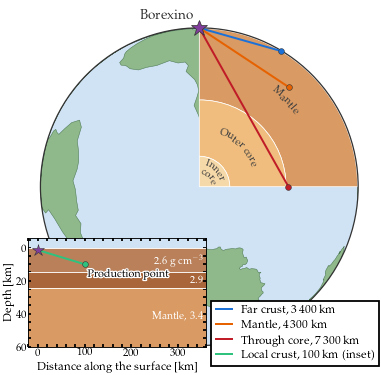

In [46]:
# ------------------------------------ Figure 8c: the geometry
# A quarter of the Earth cut away, the four production points, and the local crust in an
# inset.  The land polygons are those of Figure 3e, projected so that Gran Sasso
# (42.5 N, 13.6 E) sits at the top of the limb: the projection is centred 90 degrees
# south of it, on the same meridian.
from matplotlib.patches import Rectangle

R_E = gd.EARTH_RADIUS
GEO_LAYERS = [(0.0, 1221.5, '#f6d9a8'), (1221.5, 3480.0, '#f0bd7e'),
              (3480.0, 6346.6, '#d99a63'), (6346.6, R_E, '#a9663a')]
R_DET = R_E - D_DET


def source_xy(depth_km, L_km):
    # Where a production point at that depth and chord length sits, in units of R_E, with
    # the detector at the top of the cut and the chord in the plane of the cut.
    r_s = R_E - depth_km
    cosa = (R_DET**2 + r_s**2 - L_km**2)/(2*R_DET*r_s)
    a = np.arccos(np.clip(cosa, -1.0, 1.0))
    return r_s*np.sin(a)/R_E, r_s*np.cos(a)/R_E


def curved_text(ax, text, radius, theta_deg, fontsize, color):
    # One character at a time along the arc of a layer, each rotated to the local tangent.
    f = ax.figure; f.canvas.draw(); rend = f.canvas.get_renderer()
    t = ax.text(0, 0, 'a b', fontsize=fontsize); w_ab = t.get_window_extent(rend).width
    t.remove()
    t = ax.text(0, 0, 'ab', fontsize=fontsize); w_space = w_ab - t.get_window_extent(rend).width
    t.remove()
    widths = []
    for ch in text:
        if ch == ' ':
            widths.append(w_space); continue
        t = ax.text(0, 0, ch, fontsize=fontsize); widths.append(t.get_window_extent(rend).width)
        t.remove()
    pix_per_unit = ax.transData.transform((1, 0))[0] - ax.transData.transform((0, 0))[0]
    angs = np.array(widths)/pix_per_unit/radius
    a = np.deg2rad(theta_deg) + angs.sum()/2.0
    for ch, da in zip(text, angs):
        am = a - da/2.0
        ax.text(radius*np.cos(am), radius*np.sin(am), ch, fontsize=fontsize, color=color,
                ha='center', va='center', rotation=np.degrees(am) - 90.0,
                rotation_mode='anchor', zorder=7)
        a -= da


fig, ax = plt.subplots(figsize=(COL, COL*1.02))
ax.set_aspect('equal'); ax.axis('off'); ax.set_xlim(-1.12, 1.12); ax.set_ylim(-1.12, 1.16)
surface = Wedge((0, 0), 1.0, 90.0, 360.0, facecolor='#cfe3f5', edgecolor='none', zorder=1)
ax.add_patch(surface)
lat0, lon0 = np.deg2rad(42.5 - 90.0), np.deg2rad(13.6)
for ring in LAND:
    a = np.deg2rad(np.asarray(ring, dtype=float)); lon, lat = a[:, 0], a[:, 1]
    cosc = np.sin(lat0)*np.sin(lat) + np.cos(lat0)*np.cos(lat)*np.cos(lon - lon0)
    if (cosc > 0).sum() < 3:
        continue
    x = np.cos(lat)*np.sin(lon - lon0)
    y = np.cos(lat0)*np.sin(lat) - np.sin(lat0)*np.cos(lat)*np.cos(lon - lon0)
    far = cosc <= 0
    if far.any():
        n = np.hypot(x, y); n[n == 0] = 1.0
        x = np.where(far, x/n, x); y = np.where(far, y/n, y)
    patch = Polygon(np.column_stack([x, y]), closed=True, facecolor='#8fb98a',
                    edgecolor='#4f7a55', lw=0.3, zorder=2)
    ax.add_patch(patch); patch.set_clip_path(surface)
for r0, r1, col in GEO_LAYERS[::-1]:
    ax.add_patch(Wedge((0, 0), r1/R_E, 0.0, 90.0, width=(r1 - r0)/R_E, facecolor=col,
                       edgecolor='white', lw=0.4, zorder=3))
ax.add_patch(Wedge((0, 0), 1.0, 0.0, 360.0, facecolor='none', edgecolor=INK, lw=0.7, zorder=6))
curved_text(ax, 'Inner', 0.148, 45.0, 5.6, '0.25')
curved_text(ax, 'core', 0.092, 45.0, 5.6, '0.25')
curved_text(ax, 'Outer core', 0.37, 45.0, 6.0, '0.25')
curved_text(ax, 'Mantle', 0.77, 45.0, 6.0, '0.25')
ax.plot([0.0], [1.0], marker='*', ms=9, color=PURPLE, mec=INK, mew=0.4, zorder=8)
ax.text(-0.04, 1.03, 'Borexino', fontsize=7.5, ha='right', va='bottom', color=INK, zorder=8)
for key, depth, costhz, from_detector in GEO_POINTS:
    if from_detector:
        continue
    xs, ys = source_xy(depth, GEO_L[key])
    ax.plot([0.0, xs], [R_DET/R_E, ys], color=GEO_COLOR[key], lw=1.1, zorder=7)
    ax.plot([xs], [ys], marker='o', ms=3.2, color=GEO_COLOR[key], mec=INK, mew=0.3, zorder=8)
    ax.plot([], [], color=GEO_COLOR[key], lw=1.1, label=GEO_LABEL[key])
ax.plot([], [], color=GREEN, lw=1.1, label='Local crust, 100 km (inset)')
leg = ax.legend(loc='lower right', bbox_to_anchor=(1.02, -0.02), fontsize=6.4, handlelength=1.4,
                frameon=True, borderpad=0.4, labelspacing=0.3, framealpha=1.0,
                facecolor='white', edgecolor='black')
leg.set_zorder(30)
# The inset: the local crust, to scale in distance and stretched in depth.
ins = ax.inset_axes([0.02, 0.05, 0.50, 0.30], zorder=25)
ins.set_facecolor('white'); ins.patch.set_alpha(1.0)
ins.set_xlim(-20.0, 360.0); ins.set_ylim(60.0, -6.0)
for y0, y1, col in [(-6.0, 0.0, '#cfe3f5'), (0.0, 15.0, '#b9805a'), (15.0, 24.4, '#a9663a'),
                    (24.4, 60.0, '#d99a63')]:
    ins.add_patch(Rectangle((-20.0, y0), 380.0, y1 - y0, facecolor=col, edgecolor='none',
                            zorder=1))
for y in (0.0, 15.0, 24.4):
    ins.axhline(y, color='white', lw=0.5, zorder=2)
ins.text(352, 8.0, r'2.6 g cm$^{-3}$', fontsize=5.8, ha='right', va='center', color='white',
         zorder=4)
ins.text(352, 19.7, r'2.9', fontsize=5.8, ha='right', va='center', color='white', zorder=4)
ins.text(352, 42.0, r'Mantle, 3.4', fontsize=5.8, ha='right', va='center', color='white',
         zorder=4)
ins.plot([0.0], [D_DET], marker='*', ms=7, color=PURPLE, mec=INK, mew=0.3, zorder=6)
x_loc = np.sqrt(GEO_L['local']**2 - (D_LOCAL - D_DET)**2)
ins.plot([0.0, x_loc], [D_DET, D_LOCAL], color=GREEN, lw=1.1, zorder=5)
ins.plot([x_loc], [D_LOCAL], marker='o', ms=3.2, color=GREEN, mec=INK, mew=0.3, zorder=6)
ins.text(x_loc + 6, D_LOCAL + 3.0, 'Production point', fontsize=6.0, color='black', ha='left',
         va='top', zorder=6, path_effects=[pe.withStroke(linewidth=1.4, foreground='white')])
ins.set_xlabel('Distance along the surface [km]', fontsize=6.4, labelpad=1.0)
ins.set_ylabel('Depth [km]', fontsize=6.4, labelpad=1.0)
ins.tick_params(labelsize=6.0, pad=1.0, length=1.8)
ins.set_xticks([0, 100, 200, 300]); ins.set_yticks([0, 20, 40, 60])
for side in ins.spines.values():
    side.set_linewidth(0.5)
save(fig, 'geoneutrinos.pdf')

  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/geoneutrino_energy.pdf


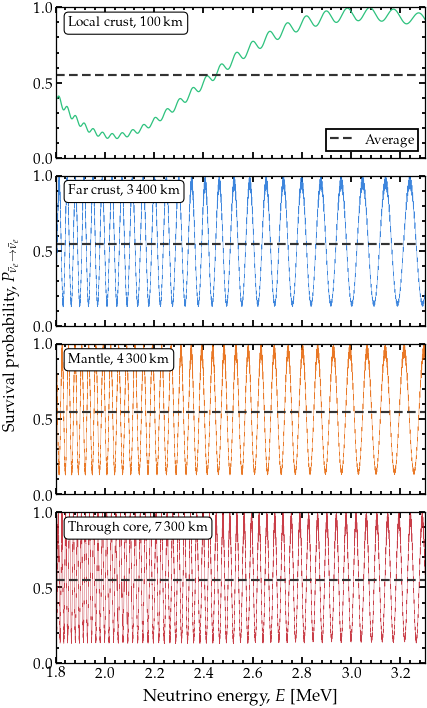

In [47]:
# ------------------------------------ Figure 8d: survival against energy, four production points
fig, axes = plt.subplots(4, 1, figsize=(COL, 5.6), sharex=True, gridspec_kw=dict(hspace=0.12))
for ax, (key, depth, costhz, from_detector) in zip(axes, GEO_POINTS):
    ax.plot(E_GEO/gd.UNIT_MEV, GEO_CURVES[key], color=GEO_COLOR[key],
            lw=(0.7 if key == 'local' else 0.25), alpha=(1.0 if key == 'local' else 0.85),
            rasterized=True)
    ax.axhline(P_GEO_VACUUM, color=INK, lw=1.2, ls=(0, (4, 2)), label='Average')
    ax.set_ylim(0.0, 1.0); ax.set_yticks([0.0, 0.5, 1.0]); minor_y(ax, 5)
    ax.set_xlim(1.8, 3.3); ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    corner(ax, GEO_LABEL[key], loc='upper left', x=0.035, y=0.94, fontsize=7.5)
axes[0].legend(loc='lower right', handlelength=1.8, fontsize=7.5)
axes[-1].set_xlabel(r'Neutrino energy, $E$ [MeV]')
fig.text(0.066, 0.53, r'Survival probability, $P_{\bar\nu_e \to \bar\nu_e}$', rotation=90,
         ha='center', va='center', fontsize=9.0)
fig.subplots_adjust(left=0.165, right=0.98, top=0.98, bottom=0.08)
# The curves are rasterized (22,500 points each); 300 dpi keeps the fast ripple.
fig.savefig(FIGDIR/'geoneutrino_energy.pdf', dpi=300)
print('  wrote %s' % (FIGDIR/'geoneutrino_energy.pdf'))

  geo_local_scan read from paper_figure_cache.json, unchanged configuration 346e88efe073 (measured 2026-09-21 on laptop-6)
  geo_flux_unoscillated read from paper_figure_cache.json, unchanged configuration 45f13c54c845 (measured 2026-09-21 on laptop-6)


  geo_flux_window_average read from paper_figure_cache.json, unchanged configuration 2e2a9da3c953 (measured 2026-09-21 on laptop-6)
  crust 61% of the detectable flux; within 100 km 17%, 350 km 30%, 1000 km 43%; oscillations leave 54%
  the two pieces of the average meet at 331 km: 0.5422 through the crust, 0.5297 in vacuum


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/geoneutrino_flux.pdf


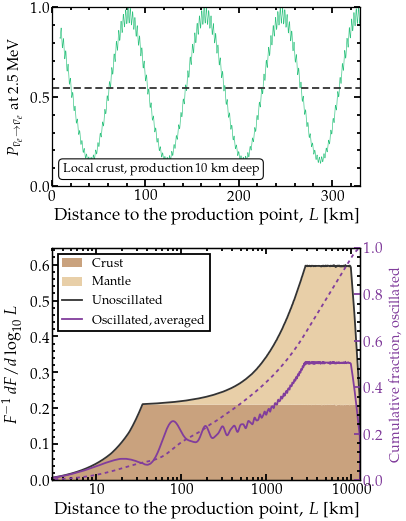

In [48]:
# ------------------------------------ Figure 8e: where the flux comes from, and what survives
# (i) P(2.5 MeV, L) across the local crust, resolved: 0.25 km steps, ten per cycle of the
# fast pair, for a production point 10 km deep at every distance the reversed call reaches,
# from straight below the detector to the horizon.
_RS, _RD = R_E - D_DET, R_E - D_LOCAL


def local_L_of_c(c):
    return np.sqrt(_RS**2 - (_RD*np.sqrt(1.0 - c*c))**2) - _RD*c


def local_c_of_L(L):
    lo, hi = 0.0, 1.0
    for _ in range(80):
        mid = 0.5*(lo + hi)
        if local_L_of_c(mid) > L:
            lo = mid
        else:
            hi = mid
    return 0.5*(lo + hi)


L_LOCAL = np.arange(local_L_of_c(1.0), local_L_of_c(0.0)*0.999, 0.25)
P_LOCAL = np.asarray(cached(
    'geo_local_scan',
    ('geo local scan', D_DET, D_LOCAL, 2.5, [float(x) for x in L_LOCAL[::100]], len(L_LOCAL),
     sorted(OSC.items()), sorted((k, str(v)) for k, v in KW_GEO.items())),
    lambda: [float(oscprob.osc_prob_3nu_earth(2.5*gd.UNIT_MEV, costhz=local_c_of_L(L),
                                               source_depth=D_DET*gd.UNIT_KM,
                                               detector_depth=D_LOCAL*gd.UNIT_KM, **KW_GEO))
             for L in L_LOCAL],
    what='nubar_e survival at 2.5 MeV against distance across the local crust'))

# (ii) The flux, Eq. (geoflux) of the paper: the emission integrated over the Earth with the
# inverse square of the distance, in coordinates centred on the detector.  The simplest
# Earth that carries both reservoirs: a spherically symmetric crust 35 km thick holding
# 7 TW of radiogenic power at Th/U = 4.5 (0.67 ppm U, 3.0 ppm Th), a mantle to 2891 km
# with the abundances of the geochemical model of Bellini et al. (0.0127 ppm U, 0.0446 ppm
# Th), nothing in the core, and the density of PREM throughout.  Per chain decay, 0.392 (U)
# and 0.147 (Th) antineutrinos lie above the inverse-beta-decay threshold.
N_AV, YR = 6.02214076e23, 3.15576e7
LAM_U, LAM_TH = np.log(2.0)/(4.468e9*YR), np.log(2.0)/(1.405e10*YR)        # 1/s
NU_U, NU_TH, A_U, A_TH = 0.392, 0.147, 238.0, 232.0
CRUST_KM, MANTLE_KM = 35.0, 2891.0
ABUND = dict(crust=(0.67e-6, 3.0e-6), mantle=(0.0127e-6, 0.0446e-6))     # (U, Th) mass fractions


def geo_emissivity(r_km):
    # Detectable antineutrinos per second per cm^3 at radius r.
    d = R_E - r_km
    U = np.where(d <= CRUST_KM, ABUND['crust'][0], np.where(d <= MANTLE_KM, ABUND['mantle'][0], 0.0))
    Th = np.where(d <= CRUST_KM, ABUND['crust'][1], np.where(d <= MANTLE_KM, ABUND['mantle'][1], 0.0))
    return earth.density_matter_func_prem(r_km)*(U/A_U*NU_U*LAM_U + Th/A_TH*NU_TH*LAM_TH)*N_AV


L_FLUX = np.logspace(0.0, np.log10(2*R_E), 900)                           # km, 1 to the diameter


def _geo_flux_unoscillated():
    # dPhi/dL: the L^2 of the volume element cancels the inverse square, leaving the
    # emissivity integrated over the directions in which the shell at L lies inside the Earth.
    psis = np.linspace(0.0, np.pi, 40001)
    dPhi, dPhi_crust = np.zeros_like(L_FLUX), np.zeros_like(L_FLUX)
    for i, L in enumerate(L_FLUX):
        r = np.sqrt(R_E**2 + L**2 - 2*R_E*L*np.cos(psis)); inside = r <= R_E
        if not inside.any():
            continue
        em = geo_emissivity(r[inside]); crust = (R_E - r[inside]) <= CRUST_KM
        w = 0.5*np.sin(psis[inside])
        dPhi[i] = trapz(em*w, psis[inside])*1.0e5                        # per s per cm^2 per km
        dPhi_crust[i] = trapz(np.where(crust, em, 0.0)*w, psis[inside])*1.0e5
    return dict(dPhi=dPhi.tolist(), dPhi_crust=dPhi_crust.tolist())


got = cached('geo_flux_unoscillated',
             ('geo flux', [float(x) for x in L_FLUX[::50]], len(L_FLUX), CRUST_KM, MANTLE_KM,
              sorted(ABUND.items()), NU_U, NU_TH, 40001),
             _geo_flux_unoscillated, what='the unoscillated geoneutrino flux by distance')
DPHI, DPHI_CRUST = np.asarray(got['dPhi']), np.asarray(got['dPhi_crust'])

# (iii) The survival probability averaged over the detectable window with equal weight in
# energy: through the crust with the reversed call up to the horizon of a point 10 km deep,
# 331 km; the vacuum closed form beyond, where matter moves the average by 0.01 at the
# seam and by less farther out.  Twelve energies per cycle of the fast pair throughout.
L_HORIZON = local_L_of_c(0.0)


def geo_window_average(L):
    cycles = OSC['D31']*L*gd.UNIT_KM/(4*np.pi)*(1/(1.8*gd.UNIT_MEV) - 1/(3.3*gd.UNIT_MEV))
    E = 1.0/np.linspace(1.0/1.8, 1.0/3.3, max(240, int(12*cycles)))*gd.UNIT_MEV
    if local_L_of_c(1.0) <= L <= L_HORIZON:
        P = np.asarray(oscprob.osc_prob_3nu_earth(E, costhz=local_c_of_L(L),
                                                   source_depth=D_DET*gd.UNIT_KM,
                                                   detector_depth=D_LOCAL*gd.UNIT_KM, **KW_GEO))
    else:
        P = np.asarray(oscprob.osc_prob_3nu_vacuum(E, L*gd.UNIT_KM, nubar=True, nu_i=gd.NUE,
                                                    nu_f=gd.NUE, **OSC))
    return float(trapz(P, E)/(E[-1] - E[0]))


P_WINDOW = np.asarray(cached(
    'geo_flux_window_average',
    ('geo window average', [float(x) for x in L_FLUX[::50]], len(L_FLUX), D_DET, D_LOCAL, 1.8,
     3.3, 12, sorted(OSC.items()), sorted((k, str(v)) for k, v in KW_GEO.items())),
    lambda: [geo_window_average(L) for L in L_FLUX],
    what='the window-averaged survival probability against distance'))
DPHI_OSC = DPHI*P_WINDOW
TOTAL, TOTAL_OSC = trapz(DPHI, L_FLUX), trapz(DPHI_OSC, L_FLUX)
CUM = np.array([trapz(DPHI[:i + 1], L_FLUX[:i + 1]) for i in range(len(L_FLUX))])/TOTAL
CUM_OSC = np.array([trapz(DPHI_OSC[:i + 1], L_FLUX[:i + 1]) for i in range(len(L_FLUX))])/TOTAL_OSC


def _at(x):
    return int(np.searchsorted(L_FLUX, x))


print('  crust %.0f%% of the detectable flux; within 100 km %.0f%%, 350 km %.0f%%, 1000 km %.0f%%; '
      'oscillations leave %.0f%%' % (100*trapz(DPHI_CRUST, L_FLUX)/TOTAL, 100*CUM[_at(100)],
                                     100*CUM[_at(350)], 100*CUM[_at(1000)], 100*TOTAL_OSC/TOTAL))
print('  the two pieces of the average meet at %.0f km: %.4f through the crust, %.4f in vacuum'
      % (L_HORIZON, P_WINDOW[_at(L_HORIZON) - 1], P_WINDOW[_at(L_HORIZON)]))

fig, axes = plt.subplots(2, 1, figsize=(COL, 4.4),
                         gridspec_kw=dict(height_ratios=[1.0, 1.3], hspace=0.30))
a = axes[0]
a.plot(L_LOCAL, P_LOCAL, color=GREEN, lw=0.35, rasterized=True)
a.axhline(P_GEO_VACUUM, color=INK, lw=1.0, ls=(0, (4, 2)))
a.set_xlim(0.0, 330.0); a.set_ylim(0.0, 1.0); a.set_yticks([0.0, 0.5, 1.0]); minor_y(a, 5)
a.xaxis.set_minor_locator(AutoMinorLocator(5))
a.set_xlabel(r'Distance to the production point, $L$ [km]', labelpad=1.5)
a.set_ylabel(r'$P_{\bar\nu_e \to \bar\nu_e}$ at 2.5 MeV', fontsize=8.5)
corner(a, 'Local crust, production 10 km deep', loc='lower left', x=0.035, y=0.06, fontsize=7.0)
b = axes[1]
w = L_FLUX*np.log(10.0)          # per unit log10 L: the area under a curve is the share
b.fill_between(L_FLUX, 0.0, DPHI_CRUST*w/TOTAL, color='#c9a27e', lw=0, label='Crust')
b.fill_between(L_FLUX, DPHI_CRUST*w/TOTAL, DPHI*w/TOTAL, color='#e8cfa8', lw=0, label='Mantle')
b.plot(L_FLUX, DPHI*w/TOTAL, color=INK, lw=1.0, label='Unoscillated')
b.plot(L_FLUX, DPHI_OSC*w/TOTAL, color=PURPLE, lw=1.0, label='Oscillated, averaged')
b.set_xscale('log'); b.set_xlim(3.0, 2*R_E); b.set_ylim(0.0, 1.08*float((DPHI*w/TOTAL).max()))
b.xaxis.set_major_formatter(FuncFormatter(_plain))
b.set_xlabel(r'Distance to the production point, $L$ [km]', labelpad=1.5)
b.set_ylabel(r'$F^{-1}\, dF / d\log_{10} L$', fontsize=9.0, labelpad=4.0)
b2 = b.twinx()
b2.plot(L_FLUX, CUM_OSC, color=PURPLE, lw=1.0, ls=(0, (2, 2)))
b2.set_ylim(0.0, 1.0); b2.set_ylabel('Cumulative fraction, oscillated', fontsize=8.0, color=PURPLE)
b2.tick_params(axis='y', colors=PURPLE); minor_y(b2, 5)
b.legend(loc='upper left', fontsize=7.0, handlelength=1.6)
fig.subplots_adjust(left=0.18, right=0.86)
fig.savefig(FIGDIR/'geoneutrino_flux.pdf', dpi=300)
print('  wrote %s' % (FIGDIR/'geoneutrino_flux.pdf'))

## Figure 7 --- a smooth profile: reach, and the flavor ceiling

Four rows on one shared time axis, which spans three decades, so the cost of a flavor
count can be read against the others directly.

machine: Linux-7.0.0-28-generic-x86_64-with-glibc2.39 | interleaved control: 0.986
Earth column: present


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/smooth_reach.pdf
  d=2 Magnus                 best 8.00e-12, tightest 8.00e-12
  d=2 NuOscProbExact         best 2.56e-11, tightest 2.56e-11
  d=2 Magnus, order 6        best 1.31e-12, tightest 1.31e-12
  d=2 Magnus, order 8        best 1.13e-12, tightest 1.13e-12
  d=2 NuOscProbExact, rtol   best 6.41e-12, tightest 6.41e-12
  d=3 Magnus                 best 2.86e-13, tightest 2.86e-13
  d=3 NuOscProbExact         best 2.52e-11, tightest 2.63e-11   <- rises
  d=3 Magnus, order 6        best 1.57e-13, tightest 1.57e-13
  d=3 Magnus, order 8        best 3.16e-14, tightest 3.16e-14
  d=3 NuOscProbExact, rtol   best 6.00e-11, tightest 6.00e-11   (1e-10 unreachable, floor ~2.7e-11)
  d=4 Magnus                 best 2.73e-12, tightest 2.73e-12
  d=4 NuOscProbExact         best 8.03e-12, tightest 8.03e-12
  d=4 Magnus, order 6        best 1.22e-12, tightest 1.22e-12
  d=4 M

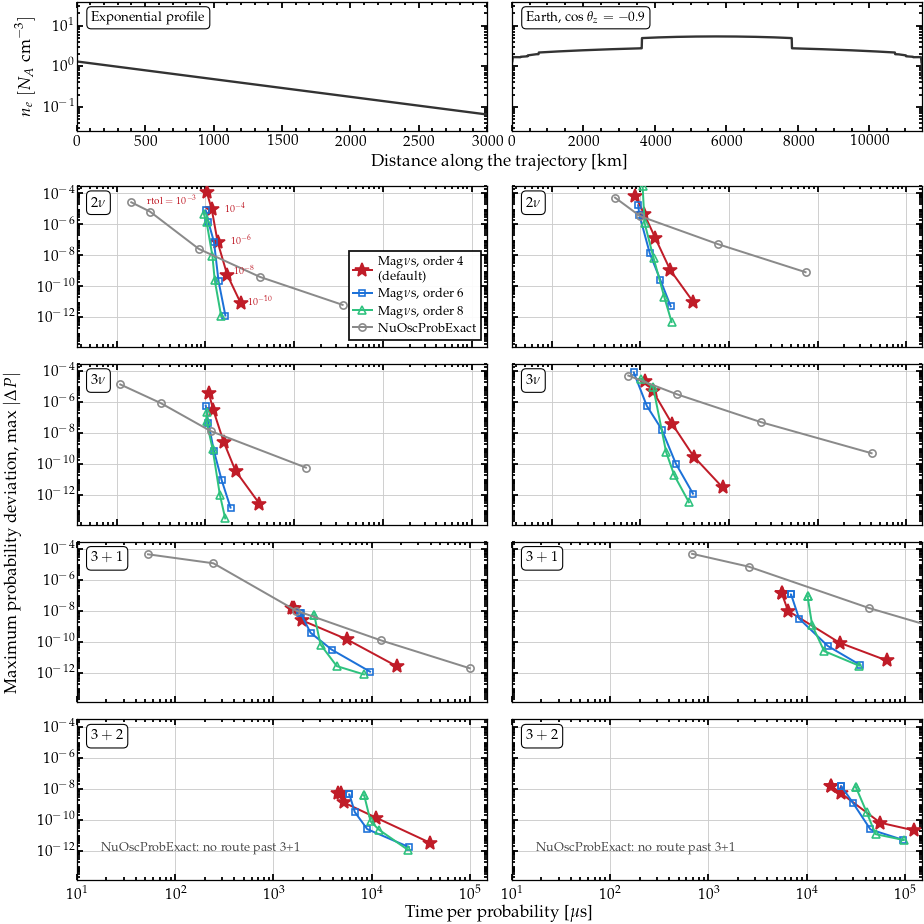

In [49]:
# ------------------------------------------------------------ smooth profile
BENCH = json.loads((HERE/'external_profile_benchmarks.json').read_text())
print('machine: %s | interleaved control: %s'
      % (BENCH['machine'], BENCH['control_ratio']))

GREY = '#8a8a8a'
# Where each rtol label sits relative to its marker, in points, with its alignment.
# The order-4 curve is nearly vertical on this profile -- five points spanning eight
# decades in error and barely one in time -- so no rule places these well and they are
# positioned by hand.  Drag them with docs/dev/nudge_fig11_labels.py, which prints this
# dict back with whatever you leave them at.
# One set of placements per column.  The two columns put their curves at different
# slopes and different places on the shared time axis, so a single set of offsets
# cannot serve both; the Earth set starts as a copy and is dragged separately with
# docs/dev/nudge_fig11_labels.py.
RTOL_LABEL_OFFSETS = {
    'exp': {
        '1e-03': (-19.4, -8.6, 'center', 'bottom'),
        '1e-04': (18.7, -0.3, 'right', 'center'),
        '1e-06': (18.7, 0.2, 'right', 'center'),
        '1e-08': (3.8, 1.4, 'left', 'center'),
        '1e-10': (3.8, 0.0, 'left', 'center'),
    },
    'earth': {
        '1e-03': (26.6, -2.9, 'right', 'center'),
        '1e-04': (8.0, -2.0, 'left', 'top'),
        '1e-06': (8.0, -1.0, 'left', 'center'),
        '1e-08': (6.0, -7.0, 'left', 'top'),
        '1e-10': (8.0, 0.0, 'left', 'center'),
    },
}
# The Earth column.  Its reference is still being built, so the right-hand panels are
# laid out and left empty rather than drawn from partial data -- a half-filled panel
# would be read as a result.
_prem = HERE/'external_prem_chord_benchmarks.json'
PREM_BENCH = json.loads(_prem.read_text()) if _prem.exists() else None
print('Earth column: %s' % ('present' if PREM_BENCH else 'not yet measured'))

fig, all_axes = plt.subplots(5, 2, figsize=(WIDE, 7.0),
                             gridspec_kw=dict(hspace=0.11, wspace=0.06,
                                              height_ratios=[0.80, 1, 1, 1, 1],
                                              left=0.085, right=0.985,
                                              top=0.985, bottom=0.062))
ax_rho = all_axes[0]
cols = [all_axes[1:, 0], all_axes[1:, 1]]
# The extra air under the top row: its abscissa is a distance and the four below it are a
# time, so the two blocks are different plots that happen to share a page.  Without the
# gap the density panel reads as the first row of the block underneath it.
for _a in ax_rho:
    _b = _a.get_position()
    _a.set_position([_b.x0, _b.y0 + 0.042, _b.width, _b.height])

# ---- top row: what each column's neutrinos actually cross -----------------------
PER_NE = matter.VCC_func(l=0.0, num_density_e_func=lambda l: 1.0)


def ne_of_rho(rho_g_cm3):
    """Electron number density from a matter density, in N_A cm^-3."""
    return np.array([matter.num_density_e_func(
        0.0, lambda _l, _v=v: _v, electron_fraction=0.5,
        density_matter_is_in_g_per_cm3=True) for v in np.atleast_1d(rho_g_cm3)]
    )/gd.N_AV/gd.UNIT_PER_CM3


# Left: the exponential profile Figure 11 is measured on, V0 exp(-3 l / L) over 3000 km.
_l_exp = np.linspace(0.0, 3000.0, 400)
ax_rho[0].semilogy(_l_exp, 1.0e-13*np.exp(-3.0*_l_exp/3000.0)/PER_NE/gd.N_AV
                   / gd.UNIT_PER_CM3, '-', color=INK, lw=1.3)
ax_rho[0].set_xlim(0.0, 3000.0)
corner(ax_rho[0], 'Exponential profile', loc='upper left', fontsize=7.5, y=0.93)

# Right: the PREM chord at cos(theta_z) = -0.9.  Its closest approach to the centre is at
# the midpoint, so r^2 = r_min^2 + (l - L/2)^2 along the chord.
_L_ch = earth.distance_traveled_inside_earth(-0.9)
_half = 0.5*_L_ch
_rmin = np.sqrt(gd.EARTH_RADIUS**2 - _half**2)
_l_ch = np.linspace(0.0, _L_ch, 1500)
ax_rho[1].semilogy(_l_ch, ne_of_rho(earth.density_matter_func_prem(
    np.sqrt(_rmin**2 + (_l_ch - _half)**2))), '-', color=INK, lw=1.3)
ax_rho[1].set_xlim(0.0, _L_ch)
corner(ax_rho[1], r'Earth, $\cos\theta_z = -0.9$', loc='upper left', fontsize=7.5,
       y=0.93)

for _a in ax_rho:
    logy(_a)
# A shared vertical range across the two profiles.  Separate ranges made the exponential
# and the Earth look comparably dense, which is the one thing this row exists to deny.
_ne_all = np.concatenate([_ln.get_ydata() for _a in ax_rho for _ln in _a.get_lines()])
for _a in ax_rho:
    _a.set_ylim(_ne_all.min()/2.5, _ne_all.max()*7.0)   # headroom for the corner label
ax_rho[0].set_ylabel(r'$n_e\ [N_A\ {\rm cm}^{-3}]$')
ax_rho[1].tick_params(labelleft=False)

# ---- the four flavor panels of each column --------------------------------------
# Order 4 takes the red the closed form used to carry, and the closed form goes grey:
# the three Magnus orders are the comparison this figure now makes, and the slab code is
# the baseline they are read against.
SERIES_STYLE = [
    ('Magnus',          '-*', RED,   8.0, 'Mag$\\nu$s, order 4\n(default)'),
    ('Magnus, order 6', '-s', BLUE,  3.6, r'Mag$\nu$s, order 6'),
    ('Magnus, order 8', '-^', GREEN, 4.0, r'Mag$\nu$s, order 8'),
    ('NuOscProbExact, rtol', '-o', GREY, 4.0, 'NuOscProbExact'),
]
# The n_slabs series stays in the JSON beside this one, unplotted.  Both codes are now
# dialled by the same requested tolerance, which is the comparison the panel claims to
# make; the slab-count sweep was chosen by hand and quietly handed the closed form a
# discretisation Magnus had to find for itself.

for col_key, axes, bench in zip(('exp', 'earth'), cols, (BENCH, PREM_BENCH)):
    if bench is None:
        # Frames, ticks and flavour labels, but no curves: the reference is still being
        # built, and a partially drawn panel would be read as a measurement.
        for ax, fl in zip(axes, (2, 3, 4, 5)):
            logx(ax); logy(ax)
            ax.tick_params(axis='x', pad=4.5)
            ax.xaxis.set_major_formatter(FuncFormatter(
                lambda v, _p: r'$10^{%d}$' % int(round(np.log10(v)))))
            ax.grid(True, which='major', color=GRID, lw=0.5, zorder=0)
            ax.set_axisbelow(True)
            corner(ax, FLAVOR_LABEL[fl], loc='upper left', fontsize=8.0)
        stamp(axes[0], 'Earth chord: measurement pending', x=0.05, y=0.12,
              fontsize=7.0)
        continue
    for ax, case in zip(axes, bench['cases']):
        by_name = {s['name']: s for s in case['series']}
        for name, mk, colr, ms, lab in SERIES_STYLE:
            s = by_name.get(name)
            if s is None:
                continue
            drawn = [p for p in s['points'] if not p.get('unreachable')]
            if not drawn:
                continue
            t = [p['us_per_probability'] for p in drawn]
            e = [p['max_abs_error'] for p in drawn]
            ax.loglog(t, e, mk, color=colr, ms=ms, mfc='none' if mk != '-*' else colr,
                      mew=0.9, lw=1.1, zorder=5, label=lab)
        logx(ax); logy(ax)
        ax.tick_params(axis='x', pad=4.5)      # a little air under the 10^x labels
        # 10^x on the shared time axis, in place of the plain integers used elsewhere.
        ax.xaxis.set_major_formatter(FuncFormatter(
            lambda v, _p: r'$10^{%d}$' % int(round(np.log10(v)))))
        # Left column only.  The Earth curves run diagonally and much closer together
        # than the exponential ones, so five dial labels there sat on the curves they
        # annotate; the dial is the same in both columns and saying it once is enough.
        # RTOL_LABEL_OFFSETS keeps its 'earth' entries, unused, so the labels can be
        # put back by relaxing this condition alone.
        if case is bench['cases'][0] and col_key == 'exp':
            # The dial that produced each point, written beside the default-order curve
            # only.  On four curves the labels collided; on one they still say what the
            # sweep was, which is the thing a reader cannot infer from the axes.
            pts = by_name['Magnus']['points']
            hi = max(range(len(pts)), key=lambda k: pts[k]['max_abs_error'])
            for k, pt in enumerate(pts):
                exp = int(round(np.log10(pt['rtol'])))
                txt = r'$10^{%d}$' % exp
                # Only the left column spells out what the dial is.  Saying it twice
                # is redundant, and on the Earth panel the long form has nowhere to sit:
                # its first marker is a few points below the frame and the slab code's
                # curve occupies the space to its left.
                if k == hi and col_key == 'exp':
                    txt = r'rtol $=10^{%d}$' % exp
                dx, dy, ha, va = RTOL_LABEL_OFFSETS[col_key][pt['label']]
                ax.annotate(txt, xy=(pt['us_per_probability'], pt['max_abs_error']),
                            xytext=(dx, dy), textcoords='offset points',
                            ha=ha, va=va,
                            fontsize=5.6, color=RED, zorder=6, annotation_clip=True)

        # Major ticks only: the minor decades of a four-decade log axis would put nine
        # lines between every label and swamp the curves they are meant to help read.
        ax.grid(True, which='major', color=GRID, lw=0.5, zorder=0)
        ax.set_axisbelow(True)
        corner(ax, FLAVOR_LABEL[case['flavours']], loc='upper left', fontsize=8.0)
        if case['flavours'] == 5:
            ax.text(0.06, 0.20, 'NuOscProbExact: no route past 3+1',
                    transform=ax.transAxes, ha='left', va='center', fontsize=7.0,
                    color='#4a4a4a', style='italic')

ALL_T = [p['us_per_probability'] for c in BENCH['cases'] for s_ in c['series']
         for p in s_['points'] if not p.get('unreachable')]
ALL_E = [p['max_abs_error'] for c in BENCH['cases'] for s_ in c['series']
         for p in s_['points'] if not p.get('unreachable')]
for axes in cols:
    for ax in axes:
        ax.set_xlim(0.7*min(ALL_T), 1.5*max(ALL_T))
        ax.set_ylim(min(ALL_E)/2.5, max(ALL_E)*2.5)
    # The 3+1 and 3+2 rows carry nothing below a millisecond, so the limit that suits
    # the two-flavor panels leaves a third of each of these empty.  They start a decade
    # in instead; the upper limit stays shared, so times remain readable across rows.
    for ax in axes[-2:]:
        ax.set_xlim(1.0e1, 1.5*max(ALL_T))
for ax in cols[0][:-1]:
    ax.tick_params(labelbottom=False)
for ax in cols[1]:
    ax.tick_params(labelleft=False)
for ax in cols[1][:-1]:
    ax.tick_params(labelbottom=False)

# The legend belongs with the profiles: it names the curves before the reader meets them.
_h, _l = cols[0][0].get_legend_handles_labels()
cols[0][0].legend(_h, _l, loc='lower right', fontsize=7.2, handlelength=1.4,
                  borderpad=0.35, labelspacing=0.35, framealpha=0.92,
                  handletextpad=0.5)

# One label per shared axis, centred on the block rather than on a panel.
fig.text(0.535, 0.022, r'Time per probability [$\mu$s]', ha='center',
         fontsize=plt.rcParams['axes.labelsize'])
# One label for the density row too.  The two panels keep their own tick values, since
# the trajectories differ in length, but the quantity is the same and saying so twice
# is just noise.
fig.text(0.535, ax_rho[0].get_position().y0 - 0.038,
         'Distance along the trajectory [km]', ha='center',
         fontsize=plt.rcParams['axes.labelsize'])
# Centred on the four measurement panels, not on the figure: the top row is a different
# quantity and this label does not describe it.
_top = cols[0][0].get_position().y1
_bot = cols[0][-1].get_position().y0
fig.text(0.006, 0.5*(_top + _bot), r'Maximum probability deviation, max $|\Delta P|$',
         va='center', rotation='vertical', fontsize=plt.rcParams['axes.labelsize'])
save(fig, 'smooth_reach.pdf')
for case in BENCH['cases']:
    for s in case['series']:
        # A point can be recorded without an error: past some tolerance the round-off of
        # the slab product overtakes the discretisation error, no slab count meets the
        # request, and the search reports the floor it reached instead.  That is the
        # method's own limit, kept in the file and skipped here.
        got = [p for p in s['points'] if not p.get('unreachable')]
        missed = [p for p in s['points'] if p.get('unreachable')]
        best = min(p['max_abs_error'] for p in got)
        last = got[-1]['max_abs_error']
        note = '   <- rises' if last > best*1.01 else ''
        if missed:
            note += '   (%s unreachable, floor ~%.1e)' % (
                ', '.join(m['label'] for m in missed),
                missed[0].get('best_error_estimate') or float('nan'))
        print('  d=%d %-22s best %.2e, tightest %.2e%s'
              % (case['flavours'], s['name'], best, last, note))

## Figure 8 --- what a shock front costs, and what declaring it is worth

machine: Linux-7.0.0-31-generic-x86_64-with-glibc2.39 | control spread 1.05x over 2 samples


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/shock_cost.pdf


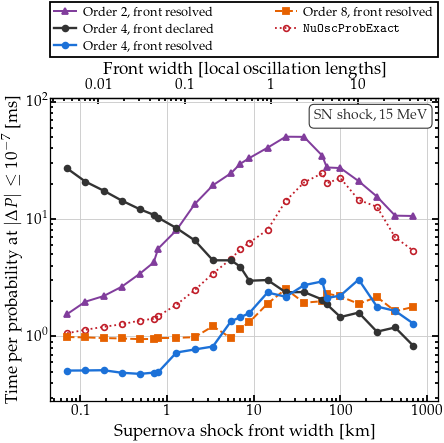

In [50]:
# ------------------------------------------------ the shock, priced at a fixed accuracy
# What a front costs, and what declaring it is worth.  Phase 1 of gen_shock_cost.py found
# the smallest slab count that reaches the target for each arm; Phase 2 timed exactly
# those settings, re-timing one cheap control every eight cases so the single-shot
# timings at the expensive end carry a measured bound on how much the machine moved.
COST = json.loads((HERE/'external_shock_cost.json').read_text())
# 1e-7, not 1e-8: it is the tightest target the closed form reaches at every width.
# At 1e-8 its error bottoms at 1.1e-08 and 1.5e-08 at the two middle widths and rises
# after, so two of its five points would not exist -- and those two are the ones the
# figure most needs, being where its cost peaks.
TARGET, LOSC = 1.0e-7, COST['l_osc_local_km']
# One timed call returns the whole cumulative scan, so its time is divided by the number
# of baselines in it.  This is the same per-probability normalisation Fig. 11 uses; the
# first draft of this figure plotted the call time under a per-probability label, which
# is the right shape and the wrong scale by a factor of 61.
NBASE = COST['n_baselines']
print('machine: %s | control spread %.2fx over %d samples'
      % (COST['machine'], COST['control']['spread'], len(COST['control']['seconds'])))


def priced(code):
    r"""(widths, seconds) for one arm at the figure's target, and the widths it missed.

    A width the arm never reached inside the memory budget has no time to plot, so it is
    returned separately rather than dropped: a gap in a curve and a curve that stops are
    different statements, and only one of them is true here.
    """
    rows = sorted((c for c in COST['cases']
                   if c['code'] == code and c['target'] == TARGET),
                  key=lambda c: c['width'])
    # NaN, not a dropped row.  Dropping the unreachable widths still leaves their
    # neighbours adjacent in the array, so the line is drawn straight across the gap and
    # asserts a time at widths where none exists; a NaN breaks the line there instead.
    w = np.array([c['width_km'] for c in rows])
    t = np.array([1.0e3*c['seconds']/NBASE if c.get('seconds') else np.nan for c in rows])
    return (w, t), [c['width_km'] for c in rows if not c.get('n_slabs')]


(QW, QT), _ = priced('order 2, resolved')
(DW, DT), _ = priced('order 4, declared')
(RW, RT), _ = priced('order 4, resolved')
(EW, ET), _ = priced('order 8, resolved')
(NW, NT), NMISS = priced('NuOscProbExact')

fig, ax = plt.subplots(figsize=(COL, 3.55))

# Order 2 is the midpoint slab product -- one sample per slab, no commutator, which is
# exactly what a constant-density slab has.  It is in the figure beside the closed form
# because the two share that limitation and share the peak, while orders 4 and 8 do not.
ax.loglog(QW, QT, '-^', color=PURPLE, ms=3.4, lw=1.1, zorder=4,
          label=r'Order 2, front resolved')
ax.loglog(DW, DT, '-o', color=INK, ms=3.2, lw=1.3, zorder=5,
          label=r'Order 4, front declared')
ax.loglog(RW, RT, '-o', color=BLUE, ms=3.2, lw=1.3, zorder=5,
          label=r'Order 4, front resolved')
ax.loglog(EW, ET, '--s', color=ORANGE, ms=2.9, lw=1.1, zorder=4,
          label=r'Order 8, front resolved')
ax.loglog(NW, NT, ':o', color=RED, ms=3.2, mfc='none', mew=0.9, lw=1.0, zorder=3,
          label=r'{\tt NuOscProbExact}')

# Nothing is unreachable at this target; the marker is kept for the tighter ones, where
# the closed form's error turns around before arriving and a point would be a fiction.
for w in NMISS:
    ax.plot(w, 0.845, 'x', ms=5.4, color=RED, mew=1.3, zorder=6,
            transform=ax.get_xaxis_transform(), clip_on=False)
if NMISS:
    # Below the crosses and below the corner label, which sits over the right-hand one.
    ax.text(np.sqrt(NMISS[0]*NMISS[-1]), 0.800, r'floors above $10^{-8}$', color=RED,
            transform=ax.get_xaxis_transform(), ha='center', va='top', fontsize=7.0)

logx(ax); logy(ax)
ax.set_xlabel(r'Supernova shock front width [km]', labelpad=2.0)
ax.set_ylabel(r'Time per probability at $|\Delta P| \leq 10^{-7}$ [ms]', labelpad=2.0)
ax.set_xlim(0.045, 1.35e3)
ax.set_ylim(0.28, 108.0)
ax.grid(True, which='major', color=GRID, lw=0.5)
ax.set_axisbelow(True)

# The same widths in local oscillation lengths, which is the number that says whether a
# front is thin: 16 km at the contact density.  rc puts ticks on all four spines, so the
# top ones are turned off here to leave the second axis alone.
ax.tick_params(axis='x', top=False, which='both')
sec = ax.secondary_xaxis('top', functions=(lambda w: w/LOSC, lambda u: u*LOSC))
sec.set_xlabel(r'Front width [local oscillation lengths]', labelpad=3.0)
sec.set_xscale('log')
sec.xaxis.set_major_formatter(FuncFormatter(_plain))
sec.xaxis.set_minor_formatter(FuncFormatter(lambda *_: ''))

# Above the panel, not inside it.  The four curves between them cross the full width at
# both the top and the bottom of the axes, so an inset legend has nowhere to sit: the
# first draft put it lower left, where it hid the thin-front end of the very curve the
# figure is about.  The second axis takes the top, so the legend sits above that.
ax.legend(loc='lower left', bbox_to_anchor=(0.0, 1.135, 1.0, 0.10), mode='expand',
          ncol=2, handlelength=1.7, columnspacing=0.9, handletextpad=0.5,
          labelspacing=0.3, borderaxespad=0.0, fontsize=7.2)
# Which profile the four curves were priced on, in the top right corner.
ax.text(0.972, 0.962, r'SN shock, $15$~MeV', transform=ax.transAxes,
        ha='right', va='top', fontsize=7.8, color=INK, zorder=7,
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=INK, lw=0.6))
fig.tight_layout(pad=0.4)
save(fig, 'shock_cost.pdf')

## Figure 9 --- six codes through the Earth

**The matter potential is matched first**, and matching it does not buy a curve that falls
forever. The cell after the figure shows why.

  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/speed_accuracy_combined.pdf


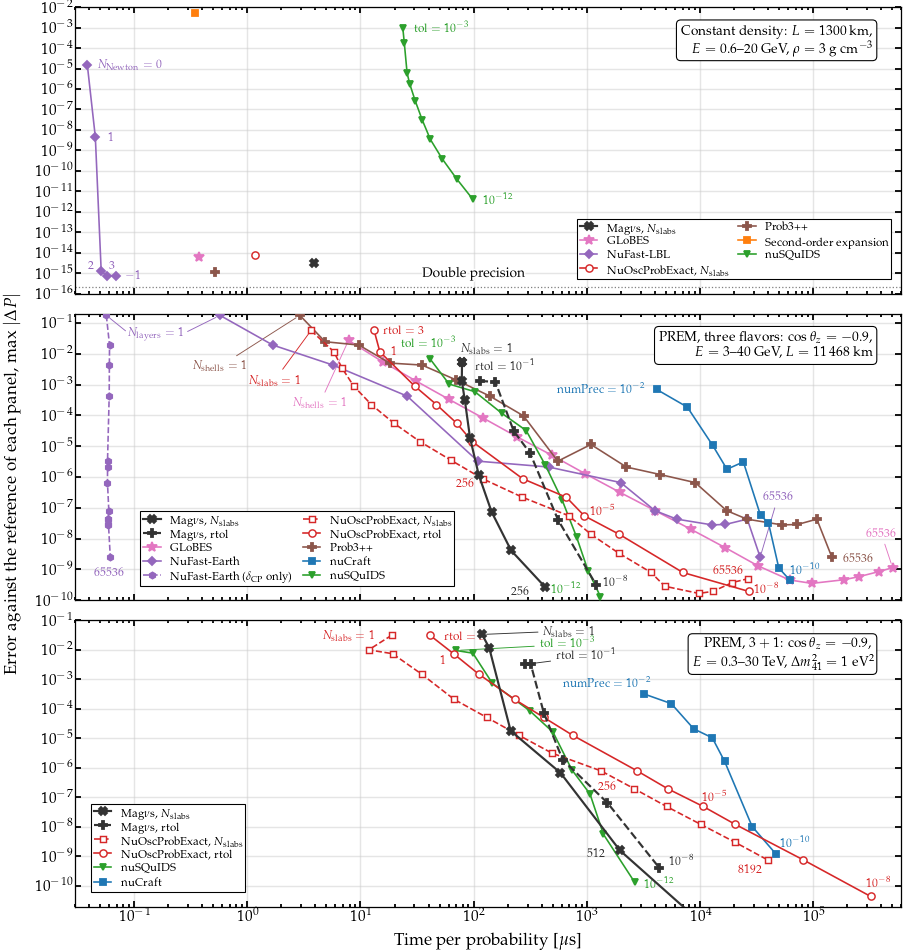

In [51]:
# ------------------------------------------------ three speed-accuracy planes
# Nothing here is measured at build time.  The external series are frozen in the
# repository, and so is Mag(nu)s' -- both produced by the benchmark harness in
# resources/benchmarks under its manifest's own protocols: ACCURACY untimed against
# each code's own 50-digit reference in that code's own conventions, and AMORTIZED,
# a 25-step delta_CP scan, for the time per grid point.
CONST_PLANE = json.loads((HERE/'external_speed_accuracy_const.json').read_text())
EARTH_PLANE = json.loads((HERE/'external_earth_plane.json').read_text())
PREM = json.loads((HERE/'external_prem_speed_accuracy_new.json').read_text())

# One x range for all three panels, the union of what they reach, so that a cost
# carries by eye from one setup to the next.
XLIM_ALL = (3.0e-2, 6.0e5)
LABEL_TR = (0.985, 0.95, 'right', 'top')

# Marker, colour and size EXACTLY as the companion paper draws them, so that a reader
# holding the two figures together tracks one code by one appearance.  Mag(nu)s is the
# only addition, and the only curve in ink: it is the code this paper is about, and
# nothing else on the plane is black except the axes and the legend frames.  It gets
# two curves for the reason NuFast-Earth does -- one code, two dials that do not
# dominate one another -- so they share a colour and differ in marker and line.
STYLE = {'NuOscProbExact': ('-o', 'C3', 4.0),
         'NuOscProbExact (1 thread)': ('-o', 'C3', 4.0),
         'NuOscProbExact (tolerance)': ('-o', 'C3', 4.0),
         'NuOscProbExact (double-double)': ('--s', 'C3', 3.2),
         'NuOscProbExact (eigensolver)': (':^', 'C1', 3.8),
         'nuSQuIDS': ('-v', 'C2', 3.6),
         'nuCraft': ('-s', 'C0', 3.4),
         'NuFast-LBL': ('-D', 'C4', 3.2),
         'NuFast-Earth': ('-D', 'C4', 3.2),
         'NuFast-Earth (dCP only)': ('--h', 'C4', 3.4),
         'GLoBES': ('-*', 'C6', 6.0),
         'Prob3++': ('-P', 'C5', 4.4),
         'Second-order expansion': ('-s', 'C1', 3.6),
         'Magnus': ('-X', INK, 4.2), 'Magnus (tolerance)': ('--P', INK, 4.0)}
# The slab curve on the Earth panels is the broken one, as it is there.
PREM_STYLE_OVERRIDE = {'NuOscProbExact': ('--s', 'C3', 3.2)}

RELABEL = {'NuOscProbExact': r'NuOscProbExact, $N_{\rm slabs}$',
           'NuOscProbExact (tolerance)': 'NuOscProbExact, rtol',
           'NuOscProbExact (double-double)': r'NuOscProbExact, $N_{\rm slabs}$',
           'NuOscProbExact (eigensolver)': 'NuOscProbExact, eigensolver',
           'NuOscProbExact (1 thread)': 'NuOscProbExact, 1 thread',
           'NuFast-Earth (dCP only)': r'NuFast-Earth ($\delta_{\rm CP}$ only)',
           'Magnus': r'Mag$\nu$s, $N_{\rm slabs}$',
           'Magnus (tolerance)': r'Mag$\nu$s, rtol'}


def by_dial(points):
    r"""Returns `points` in the order the DIAL sets, not the order of cost.

    Sorting by cost is right whenever the cost actually moves.  It is wrong for a
    series whose cost does not: NuFast-Earth's delta_CP curve spans 1.1x in cost
    against 15x to 7880x for everything else here, so ordering it by cost orders it
    by measurement noise and draws a U that is entirely an artifact.
    """
    try:
        values = [float(q['label']) for q in points]
    except (ValueError, KeyError):
        return list(points)
    return sorted(points, key=lambda q: float(q['label']),
                  reverse=min(values) < 1.0)


def magnus_first(series_list):
    r"""Mag(nu)s at the head, everything else in file order: drawing order is legend
    order, and a reader looking for this paper's own code should not have to search
    two columns for it.  Overplotting is unaffected; the Mag(nu)s curves carry their
    own zorder."""
    mag = [s for s in series_list if s['name'].startswith('Magnus')]
    return mag + [s for s in series_list if not s['name'].startswith('Magnus')]


#: Mag(nu)s' tolerance sweep is drawn only to here.  The two tighter rungs it was
#: measured at, 1e-10 and 1e-12, land beneath the lower edge of both Earth panels on
#: the companion figure's ranges, which this figure keeps; they are in the frozen
#: series either way, and Section 8.8 quotes what they reach.
MAGNUS_RTOL_FLOOR = 1.0e-8


def _drawn(series):
    r"""The points of `series` this figure draws, which for Mag(nu)s' tolerance curve
    stops at MAGNUS_RTOL_FLOOR rather than running off the bottom of the panel."""
    pts = by_dial(series['points'])
    if series['name'] == 'Magnus (tolerance)':
        pts = [q for q in pts if float(q['label']) >= MAGNUS_RTOL_FLOOR]
    return pts


def draw_plane(ax, series_list, only=None, prem=False):
    r"""Draws one speed-accuracy plane; returns the anchors its labels attach to."""
    anchors = {}
    for series in magnus_first(series_list):
        if only is not None and series['name'] not in only:
            continue
        style = STYLE.copy()
        if prem:
            style.update(PREM_STYLE_OVERRIDE)
        marker, color, size = style.get(series['name'], ('-o', '0.4', 3.2))
        pts = _drawn(series)
        label = RELABEL.get(series['name'], series['name'])
        kw = dict(ms=size, color=color, lw=0.9, zorder=4, label=label)
        if series['name'].startswith('NuOscProbExact'):
            kw.update(mfc='white', mew=0.8, zorder=5)
        if series['name'].startswith('Magnus'):
            kw.update(zorder=6, lw=1.2)
        t = [q['us_per_probability'] for q in pts]
        e = [q['max_abs_error'] for q in pts]
        ax.loglog(t, e, marker, **kw)
        for q in pts:
            anchors[(label, q['label'])] = (q['us_per_probability'],
                                            q['max_abs_error'], color)
    return anchors


def annotate(ax, anchors, items, fontsize=6.6):
    r"""The knob rungs, named on the curve they belong to.  A sixth element asks for a
    thin leader line, for a label that has to sit clear of the curves to stay legible."""
    for item in items:
        (name, label), text, dx, dy, ha = item[:5]
        if (name, label) not in anchors:
            continue
        x, y, colour = anchors[(name, label)]
        extra = {}
        if len(item) > 5 and item[5]:
            extra['arrowprops'] = dict(arrowstyle='-', linewidth=0.5, color=colour,
                                       shrinkA=1.0, shrinkB=2.5)
        ax.annotate(text, xy=(x, y), xytext=(dx, dy), textcoords='offset points',
                    fontsize=fontsize, color=colour, ha=ha, **extra)


fig, axes = plt.subplots(3, 1, sharex=True, figsize=(WIDE, 7.4))

# --- constant density.  Only the fastest point at each accuracy is drawn: four of
# these codes have an INERT dial here, Mag(nu)s among them.  With one slab of constant
# density there is nothing to subdivide, so every setting returns the same answer.
CONST_ONLY = ('GLoBES', 'NuFast-LBL', 'NuOscProbExact', 'Prob3++',
              'Second-order expansion', 'nuSQuIDS', 'Magnus')
a0 = {}
for series in magnus_first(CONST_PLANE['series']):
    if series['name'] not in CONST_ONLY:
        continue
    pts = [q for q in series['points']
           if q.get('best_at_this_accuracy', True) and q['max_abs_error'] is not None]
    if not pts:
        continue
    pts.sort(key=lambda q: (-q['max_abs_error'], q['us_per_probability']))
    marker, color, size = STYLE.get(series['name'], ('-o', '0.4', 3.2))
    label = RELABEL.get(series['name'], series['name'])
    kw = dict(ms=size, color=color, lw=0.9, zorder=4, label=label)
    if series['name'].startswith('NuOscProbExact'):
        kw.update(mfc='white', mew=0.8, zorder=5)
    if series['name'].startswith('Magnus'):
        kw.update(zorder=6, lw=1.2)
    axes[0].loglog([q['us_per_probability'] for q in pts],
                   [q['max_abs_error'] for q in pts], marker, **kw)
    for q in pts:
        a0[(label, q['label'])] = (q['us_per_probability'], q['max_abs_error'], color)

annotate(axes[0], a0, [
    (('NuFast-LBL', '0'), r'$N_{\rm Newton} = 0$', 6.0, -1.5, 'left'),
    (('NuFast-LBL', '1'), '1', 7, -2, 'left'),
    (('NuFast-LBL', '2'), '2', -4, 2, 'right'),
    (('NuFast-LBL', '3'), '3', 4.2, 4.1, 'right'),
    (('NuFast-LBL', '-1'), r'$-1$', 5.6, -2.0, 'left'),
    (('nuSQuIDS', '1e-03'), r'tol $= 10^{-3}$', 6.0, -1.8, 'left'),
    (('nuSQuIDS', '1e-12'), r'$10^{-12}$', 21.3, -2.9, 'right')])
axes[0].axhline(2.2e-16, color='0.5', ls=':', lw=0.7, zorder=1)
axes[0].set_yticks([10.0**k for k in range(-16, -1)])
axes[0].set_ylim(1.0e-16, 1.0e-2)
stamp(axes[0], 'Double precision', x=0.42, y=0.045, fontsize=7.6)
corner(axes[0], 'Constant density:  $L = 1300$~km,\n'
       r'$E = 0.6$--$20$ GeV,  $\rho = 3$ g cm$^{-3}$', loc='upper right',
       fontsize=7.6)

# --- PREM, three flavors.
a1 = draw_plane(axes[1], EARTH_PLANE['series'], prem=True)
annotate(axes[1], a1, [
    (('NuOscProbExact, rtol', '3e+00'), r'rtol $= 3$', 5.1, -2.0, 'left'),
    (('NuOscProbExact, rtol', '1e-05'), r'$10^{-5}$', 3.1, 0.7, 'left'),
    ((r'NuOscProbExact, $N_{\rm slabs}$', '1'), r'$N_{\rm slabs} = 1$',
     -5.8, -29.0, 'right', True),
    ((r'NuOscProbExact, $N_{\rm slabs}$', '256'), '256', -5, -4, 'right'),
    (('nuSQuIDS', '1e-12'), r'$10^{-12}$', -27.4, 2.1, 'left'),
    ((r'NuFast-Earth ($\delta_{\rm CP}$ only)', '1'),
     r'$N_{\rm layers} = 1$', 12.2, -10.7, 'left'),
    (('Prob3++', '1'), r'$N_{\rm shells} = 1$', -59.3, -29.6, 'left', True),
    (('Prob3++', '65536'), '65536', 6, -2, 'left'),
    (('GLoBES', '1'), r'$N_{\rm shells} = 1$', -31.0, -36.3, 'left', True),
    (('GLoBES', '65536'), '65536', -14.6, 17.8, 'left', True),
    (('nuCraft', '1e-02'), r'numPrec $= 10^{-2}$', -7.0, -1.8, 'right'),
    (('nuCraft', '1e-10'), r'$10^{-10}$', 0.2, 3.7, 'left'),
    (('nuSQuIDS', '1e-03'), r'tol $= 10^{-3}$', -15.9, 6.8, 'left'),
    (('NuFast-Earth', '65536'), '65536', 1.7, 32.1, 'left', True),
    ((r'NuFast-Earth ($\delta_{\rm CP}$ only)', '65536'), '65536',
     7.4, -9.8, 'right'),
    ((r'NuOscProbExact, $N_{\rm slabs}$', '65536'), '65536', -19.0, 3.3, 'left'),
    (('NuOscProbExact, rtol', '1e+00'), '1', 6, -2, 'left'),
    (('NuOscProbExact, rtol', '1e-08'), r'$10^{-8}$', 3.1, -0.9, 'left'),
    # Both ends of both Magnus curves, on the same principle as the rest.
    ((r'Mag$\nu$s, $N_{\rm slabs}$', '1'), r'$N_{\rm slabs} = 1$', 28.3, 5.9, 'right'),
    ((r'Mag$\nu$s, $N_{\rm slabs}$', '256'), '256', -18.8, -3.7, 'left'),
    ((r'Mag$\nu$s, rtol', '1e-01'), r'rtol $= 10^{-1}$', -2.8, 5.8, 'left'),
    ((r'Mag$\nu$s, rtol', '1e-08'), r'$10^{-8}$', 4.1, -0.7, 'left')])
axes[1].set_yticks([10.0**k for k in range(-10, 0)])
axes[1].set_ylim(1.0e-10, 2.0e-1)
corner(axes[1], r'PREM, three flavors:  $\cos\theta_z = -0.9$,' + '\n'
       r'$E = 3$--$40$ GeV,  $L = 11\,468$~km', loc='upper right', fontsize=7.6)

# --- PREM, 3+1: restricted to the codes that can express a sterile state, and to one
# of NuOscProbExact's two root strategies, whose curves coincide to the last bit.
a2 = draw_plane(axes[2], PREM['sterile_3plus1']['series'], prem=True,
                only={'NuOscProbExact (double-double)', 'NuOscProbExact (tolerance)',
                      'nuSQuIDS', 'nuCraft', 'Magnus', 'Magnus (tolerance)'})
annotate(axes[2], a2, [
    (('NuOscProbExact, rtol', '3e+00'), r'rtol $=3$', 7.5, -2.5, 'left'),
    (('NuOscProbExact, rtol', '1e-05'), r'$10^{-5}$', -0.8, 3.1, 'left'),
    ((r'NuOscProbExact, $N_{\rm slabs}$', '1'), r'$N_{\rm slabs}=1$',
     -37.8, -1.2, 'left'),
    ((r'NuOscProbExact, $N_{\rm slabs}$', '256'), '256', 8.4, -9.8, 'right'),
    (('nuSQuIDS', '1e-03'), r'tol $= 10^{-3}$', 46.3, 1.9, 'left', True),
    (('nuSQuIDS', '1e-12'), r'$10^{-12}$', 5.1, -2.9, 'left'),
    (('nuCraft', '1e-02'), r'numPrec $= 10^{-2}$', 3.6, 4.0, 'right'),
    (('nuCraft', '1e-10'), r'$10^{-10}$', 2.1, 4.2, 'left'),
    ((r'NuOscProbExact, $N_{\rm slabs}$', '8192'), '8192', -16.6, -7.3, 'left'),
    (('NuOscProbExact, rtol', '1e+00'), '1', -7.4, -5.8, 'left'),
    (('NuOscProbExact, rtol', '1e-08'), r'$10^{-8}$', -2.6, 5.4, 'left'),
    # Both ends of both Magnus curves.  The slab curve's last drawn rung is 512: its
    # 2048-slab point reaches 1.0e-11, below this panel's lower edge.
    ((r'Mag$\nu$s, $N_{\rm slabs}$', '1'), r'$N_{\rm slabs} = 1$', 62.7, 0.6, 'right', True),
    ((r'Mag$\nu$s, $N_{\rm slabs}$', '512'), '512', -8.2, -3.7, 'right'),
    ((r'Mag$\nu$s, rtol', '1e-01'), r'rtol $= 10^{-1}$', 17.3, 2.9, 'left', True),
    ((r'Mag$\nu$s, rtol', '1e-08'), r'$10^{-8}$', 5.5, 1.5, 'left')])
axes[2].set_yticks([10.0**k for k in range(-11, 0)])
axes[2].set_ylim(2.0e-11, 1.0e-1)
corner(axes[2], r'PREM, $3+1$:  $\cos\theta_z = -0.9$,' + '\n'
       r'$E = 0.3$--$30$ TeV,  $\Delta m_{41}^2 = 1$ eV$^2$', loc='upper right',
       fontsize=7.6)

# Ticks are matplotlib's defaults on both axes, which is what the companion figure
# uses: decade majors labelled in scientific notation and the default minor subdivision.
# This paper's own `logx` would print them as 0.1, 1, 10, 10000, which is the house
# style everywhere else here but not what this figure is meant to be laid beside.
for ax in axes:
    # No set_xscale/set_yscale here: loglog() has already set both, and calling them
    # again resets the locators, which silently discarded the explicit decade ticks
    # set above.
    ax.set_xlim(*XLIM_ALL)
    ax.set_axisbelow(True)
    ax.grid(True, axis='both', which='major', color=GRID, lw=0.8, alpha=0.5, zorder=0)
for ax, loc, anchor, ncol in ((axes[0], 'lower right', (0.995, 0.03), 2),
                              (axes[1], 'lower left', (0.0716, 0.03), 2),
                              (axes[2], 'lower left', (0.012, 0.03), 1)):
    leg = ax.legend(loc=loc, bbox_to_anchor=anchor, fontsize=6.4, ncol=ncol,
                    handlelength=1.5, labelspacing=0.22, columnspacing=0.9,
                    borderpad=0.3)
    leg.get_frame().set_linewidth(0.6)
# One "N_layers = 1" serves both NuFast-Earth curves, so it gets a leader to each:
# out of its left edge to the delta_CP-only curve's first marker, out of its right edge
# to the full curve's.  Drawn only after the limits are set, since the label's own box
# is not known until it has been rendered.
def _first_marker(series_name):
    series = next(x for x in EARTH_PLANE['series'] if x['name'] == series_name)
    point = by_dial(series['points'])[0]
    return point['us_per_probability'], point['max_abs_error']


_label = next(t for t in axes[1].texts
              if hasattr(t, 'xyann') and t.get_text() == r'$N_{\rm layers} = 1$')
# Anchored to the LABEL, not to converted data coordinates: savefig re-lays the figure
# out with a tight bounding box, which moves the axes under any data-space endpoint and
# leaves the line detached from the text it is meant to touch.
for _side, _target in (((0.0, 0.5), _first_marker('NuFast-Earth (dCP only)')),
                       ((1.0, 0.5), _first_marker('NuFast-Earth'))):
    axes[1].annotate('', xy=_target, xycoords='data', xytext=_side,
                     textcoords=_label, zorder=6,
                     arrowprops=dict(arrowstyle='-', linewidth=0.5, color='C4',
                                     shrinkA=2.0, shrinkB=2.5))

axes[2].set_xlabel(r'Time per probability [$\mu$s]')
fig.supylabel(r'Error against the reference of each panel,  max $|\Delta P|$',
              fontsize=9.5, x=0.038)
fig.subplots_adjust(hspace=0.07, left=0.115, right=0.995, top=0.995, bottom=0.06)
save(fig, 'speed_accuracy_combined.pdf')

### Why the matched curve used to stop falling

An earlier version of this plane scored Mag$\nu$s against {\tt NuOscProbExact}'s
reference, matching the two charged-current potentials by handing Mag$\nu$s an electron
fraction of $0.5000948$ instead of $0.5$. That curve flattened near $1.6 \cdot 10^{-7}$
and no solver setting on either side reached beneath it. The floor was not a property of
either solver, and it was not, as we first read it, the potential match running out in
some general way. It has a single identifiable cause, and the cell below names it.

In [52]:
# Why matching V_CC through the electron fraction leaves a floor, and what the
# floor is worth.  This is a note about a measurement convention, not about the solver:
# every number the paper quotes for Magnus is measured against Magnus' OWN reference,
# where no such floor exists.
VCC_MATCH = 1.0001896489716906     # NuOscProbExact's V_CC over ours, at any density

print('On an Earth chord V_CC is NOT linear in Y_e.  oscprob.py derives the average')
print('nucleon mass from the composition -- r = (1-Y_e)/Y_e, layer by layer -- because')
print('a medium with Y_e = 0.4656 and r = 1 is matter that cannot exist.  So scaling')
print('Y_e scales the potential by very slightly more than the scale asked for:')
r_half = earth.neutron_to_proton_ratio_from_electron_fraction(0.5)
r_match = earth.neutron_to_proton_ratio_from_electron_fraction(0.5*VCC_MATCH)


def avg_nucleon(r):
    return (gd.MASS_PROTON + gd.MASS_NEUTRON*r)/(1.0 + r)


slip = avg_nucleon(r_half)/avg_nucleon(r_match) - 1.0
print('  r  goes %.10f -> %.10f' % (r_half, r_match))
print('  the average nucleon mass moves with it, and V_CC picks up a further %.3e' % slip)
print('  which is exactly the height the matched curve used to flatten at.')
print()
print('Matching a potential through the composition is therefore only ever good to')
print('that order.  The measurement this paper reports avoids the question entirely:')
print('the benchmark manifest asks for a per-code reference in each code\'s own')
print('conventions, so Magnus is scored at Y_e = 1/2 against a reference built with')
print('Magnus\' own constants, and the residual is the solver\'s alone.')

On an Earth chord V_CC is NOT linear in Y_e.  oscprob.py derives the average
nucleon mass from the composition -- r = (1-Y_e)/Y_e, layer by layer -- because
a medium with Y_e = 0.4656 and r = 1 is matter that cannot exist.  So scaling
Y_e scales the potential by very slightly more than the scale asked for:
  r  goes 1.0000000000 -> 0.9996207740
  the average nucleon mass moves with it, and V_CC picks up a further 1.306e-07
  which is exactly the height the matched curve used to flatten at.

Matching a potential through the composition is therefore only ever good to
that order.  The measurement this paper reports avoids the question entirely:
the benchmark manifest asks for a per-code reference in each code's own
conventions, so Magnus is scored at Y_e = 1/2 against a reference built with
Magnus' own constants, and the residual is the solver's alone.


## Figure 10 --- what an averaged probability costs, by configuration

The other cost figures trade time against accuracy. This one cannot, and the reason is
worth stating rather than working around.

On the BS2005-AGS,OP model the averaged probability has **no accuracy dial**. The
evolution is adiabatic the whole way out -- the adiabaticity parameter stays a factor of
eleven or more below the threshold that would open a non-adiabatic window, at every
flavor count from $0.1$ to $20$~MeV -- and every eigenvalue pair is fully decohered by
the time the neutrino arrives. So the level-crossing matrix is the identity, the
expression collapses to an eigendecomposition at production and another at detection, and
the answer is exact to about $10^{-15}$. Sweeping any of `n_points`, `threshold`,
`n_probe`, `magnus_exp_order` or `integration_method` returns bit-identical output. There
is nothing to converge, so there is nothing to put on an error axis.

What is left worth showing is the price, across the scenarios the package covers. Read
the figure down the column: the cost is set by the **number of states**, not by what the
Hamiltonian contains. Each NSI row sits on top of its standard counterpart, and Lorentz
violation adds roughly a tenth. That is the claim the synopsis makes about the method,
and this is the only figure that shows it.

The open squares are what the same number costs *without* the closed form: one `DOP853`
solve of the coherent evolution, then the phase average taken from it over a tapered
window at the far end of the ray. Both parts are inside the quoted time, and the two
routes agree on the probability to between 5 and 8e-5 -- without that agreement the
comparison would be between two different quantities. The tolerance, `rtol = 1e-8`, is
the loosest that still returns the answer: 1e-4 gives 0.004 where the answer is 0.546,
and 1e-6 is still 1.3e-2 away.

The four sterile rows carry an arrow instead. A step solver has to resolve the fastest
phase in the Hamiltonian, and an eV-scale `D41` puts about 5.5e7 cycles along the ray
against 1.4e5 at three flavors -- on an identical segment, 3+1 takes 305,162 right-hand
sides where 3nu takes 926. Those solves run for tens of hours, so they are projected from
a measured segment rather than run, and nothing projected is drawn at a coordinate. The
projection is checked on the four rows whose reference could actually be run: it lands
2.6 % high at three flavors -- 401 s projected against 391 s measured -- and 17 to 19 %
high on the other three.

machine: Linux-7.0.0-30-generic-x86_64-with-glibc2.39 | interleaved control: 0.968
x-axis spans 1 to 1e+07 ms (7.0 decades); 4 measured, 4 projected


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/solar_average_cost.pdf


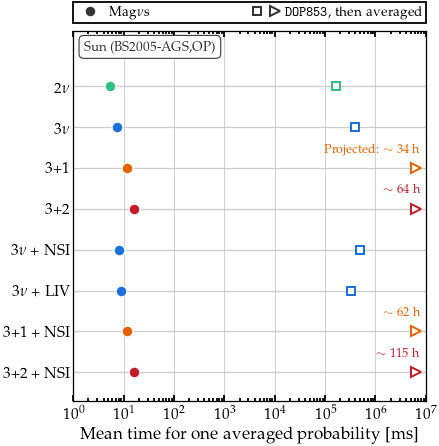

In [53]:
# ------------------------------------------- averaged probability, by configuration
COST = json.loads((HERE/'external_solar_average_cost.json').read_text())
print('machine: %s | interleaved control: %.3f'
      % (COST['machine'], COST['control_ratio']))

# Color carries the flavor count, which is the variable the figure is about; the
# standard and new-physics blocks are separated by a rule rather than by hue, so a
# reader compares 3nu + NSI against 3nu by looking straight up the column.
FLAV_COLOR = {2: GREEN, 3: BLUE, 4: ORANGE, 5: RED}
ORDER = ['2nu', '3nu', '3+1', '3+2',
         '3nu + NSI', '3nu + LIV', '3+1 + NSI', '3+2 + NSI']
rows = sorted(COST['cases'], key=lambda r: ORDER.index(r['label']))
yy = np.arange(len(rows))[::-1]
# Both series share one axis, so the range is taken from both rather than typed in.
# Only MEASURED references set the upper end: the projected ones run to tens of hours
# and would push the axis out four further decades to hold arrows that mean "off this
# scale" anyway.
meas = [r for r in rows if r.get('reference_measured')]
XLO = 10.0**np.floor(np.log10(min(r['ms'] for r in rows)) - 0.35)
XHI = 10.0**np.ceil(np.log10(1.0e3*max(r['reference_seconds'] for r in meas)) + 0.55)
print('x-axis spans %.3g to %.3g ms (%.1f decades); %d measured, %d projected'
      % (XLO, XHI, np.log10(XHI/XLO), len(meas), len(rows) - len(meas)))

# Drawn at COL, the width it is included at.  An earlier version drew this at COL*2
# for a \columnwidth slot, so LaTeX shrank it by half and every label reached the page
# at half the size the rc asks for.  Sizes come from the notebook rc block above; none
# are set here, so this figure matches the rest.
fig, ax = plt.subplots(figsize=(COL, 3.55))
first_proj = True
for yi, r in zip(yy, rows):
    c = FLAV_COLOR[r['flavors']]
    # One rule per row, gray and full width.  Colour is carried by the markers alone,
    # so the eye reads position along a common baseline rather than three line segments
    # of different hue and length per row.
    ax.plot([XLO, XHI], [yi, yi], lw=0.7, color=GRID, zorder=1)
    ax.plot(r['ms'], yi, 'o', ms=6.0, color=c, mec='white', mew=0.7, zorder=4)
    if r.get('reference_measured'):
        ax.plot(1.0e3*r['reference_seconds'], yi, 's', ms=4.6, mfc='white',
                mec=c, mew=1.1, zorder=4)
    else:
        # Not measured, so not drawn at a coordinate.  A hollow triangle at the edge
        # says "past here" without planting an unmeasured number anywhere a reader
        # could take one off the axis.
        # Positioned as a fraction of the axes, not as a multiple of XHI: on a
        # seven-decade log axis a factor like 0.9 is a hair from the spine, and the
        # marker was overhanging it.
        ax.plot(0.972, yi, '>', ms=5.2, mfc='white', mec=c, mew=1.1, zorder=4,
                transform=ax.get_yaxis_transform(), clip_on=False)
        # Only the first of these says what the number means; the ones below inherit
        # the reading, and repeating the word on every row crowds the panel.
        hrs = r['reference_seconds']/3600.0
        lab = (r'Projected: $\sim%.0f$ h' % hrs) if first_proj else (r'$\sim%.0f$ h' % hrs)
        first_proj = False
        ax.text(0.982, yi + 0.30, lab, transform=ax.get_yaxis_transform(),
                ha='right', va='bottom', color=c, fontsize=7.0)

ax.set_yticks(yy)
ax.set_yticklabels([r['label'].replace('nu', r'$\nu$') for r in rows])
ax.set_xscale('log')
ax.set_xlim(XLO, XHI)
ax.set_ylim(-0.7, len(rows) + 0.35)
ax.set_xlabel(r'Mean time for one averaged probability [ms]', labelpad=2.0)
ax.grid(True, axis='x', which='major', color=GRID, lw=0.5)
ax.set_axisbelow(True)
ax.tick_params(axis='y', which='both', length=0, left=False, right=False)
ax.tick_params(axis='x', which='major', pad=3.6)
ax.xaxis.set_major_locator(mpl.ticker.LogLocator(base=10.0, numticks=20))
ax.xaxis.set_minor_locator(mpl.ticker.LogLocator(base=10.0, subs=tuple(np.arange(2, 10)*0.1),
                                                 numticks=20))
ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
h_dot = plt.Line2D([], [], ls='none', marker='o', ms=6.0, color=INK,
                   mec='white', mew=0.7)
h_sq = plt.Line2D([], [], ls='none', marker='s', ms=4.6, mfc='white', mec=INK, mew=1.1)
h_tr = plt.Line2D([], [], ls='none', marker='>', ms=5.2, mfc='white', mec=INK, mew=1.1)
# Above the panel, not inside it.  Every row spans the full width, so an inset legend
# has nowhere to sit that does not cover a row; in the first draft it hid 3+2 + NSI
# completely.  The square and the triangle share one entry because they are one series
# -- the same integration, measured where that was possible and projected where it was
# not -- and the triangles are labelled with their times where they are drawn.
ax.legend([h_dot, (h_sq, h_tr)],
          [r'Mag$\nu$s', r'{\tt DOP853}, then averaged'],
          handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.7)},
          loc='lower left', bbox_to_anchor=(0.0, 1.02, 1.0, 0.102), mode='expand',
          ncol=2, handlelength=1.8, columnspacing=1.0, handletextpad=0.5,
          borderaxespad=0.0, fontsize=7.6)

# Which profile these eight rows were priced on, said inside the panel so the figure
# carries it without the caption.
ax.text(0.030, 0.975, r'Sun (BS2005-AGS,OP)', transform=ax.transAxes,
        ha='left', va='top', fontsize=7.5, color=INK, zorder=6,
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=INK, lw=0.6))
fig.tight_layout(pad=0.6)
save(fig, 'solar_average_cost.pdf')

## Figure 11 --- what asking for more workers buys

`n_jobs` reads like a performance knob. On the request it most often meets --- many energies
sharing one baseline --- raising it **turns the batched engine off**, and the cell prints what
that trade costs. The curves are the other case, where nothing is traded away.

machine: Linux-7.0.0-31-generic-x86_64-with-glibc2.39
topology: i5-1334U: 2 performance cores (hyperthreaded, 4 logical) + 8 efficiency cores = 10 physical, 12 logical
shared baseline, 5000 energies: scan_separable at 1 worker 0.111 s, per-point at 10 workers 1.070 s -> 9.6x SLOWER


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/njobs_scaling.pdf


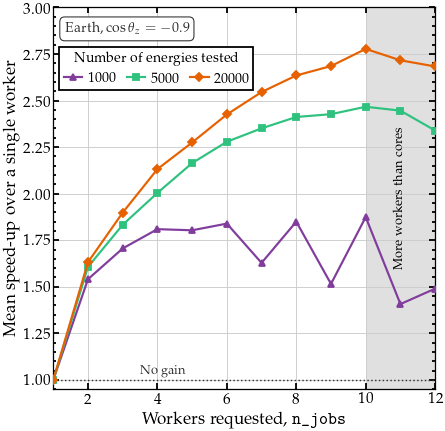

In [54]:
# ------------------------------------------------ what asking for more workers buys
# Wall clock against n_jobs on an Earth chord, produced by gen_njobs_scaling.py with one
# thread per process and the worker counts interleaved round-robin, so a drift in the
# machine lands on every count rather than on one.  Nothing is recomputed here: a figure
# that timed itself would report whichever machine executed the notebook.
JOBS = json.loads((HERE/'external_njobs_scaling.json').read_text())
NCORE, NLOG = JOBS['n_physical_cores'], 12
# Every energy carries its own baseline, which the batched engine never accepts, so both
# ends of each ratio run the same per-point path: the ratio is what the workers did and
# nothing else.  The default case, one baseline shared by the whole scan, is the
# cautionary one, and it is a number rather than a curve -- printed below.
SIZES = ((1000, '-^', PURPLE), (5000, '-s', GREEN), (20000, '-D', ORANGE))


def jobs_rows(arm):
    r"""One arm's rows, in worker-count order."""
    return sorted(JOBS['arms'][arm]['rows'], key=lambda r: r['n_jobs'])


def border_of(ax, label):
    r"""The drawn left and bottom borders of a boxed label, in axes coordinates.

    A text's position is the text itself; the box around it reaches further out by the
    box padding.  Anything that must line up with the drawn border has to measure it.
    """
    ax.figure.canvas.draw()
    box = label.get_bbox_patch().get_window_extent(ax.figure.canvas.get_renderer())
    return tuple(ax.transAxes.inverted().transform((box.x0, box.y0)))


def legend_at(ax, legend, left, top):
    r"""Move the legend's drawn frame to (left, top) in axes coordinates.

    `bbox_to_anchor` is not the frame: matplotlib insets the legend from the anchor by
    `borderaxespad` times the font size, so anchoring a legend and a label at the same x
    leaves their borders a font-size apart.  Measure the frame and correct the anchor;
    the transform is affine, so the first correction is already exact.
    """
    inv = ax.transAxes.inverted()
    for _ in range(6):
        ax.figure.canvas.draw()
        frame = legend.get_frame().get_window_extent(ax.figure.canvas.get_renderer())
        x0, _ = inv.transform((frame.x0, frame.y0))
        _, y1 = inv.transform((frame.x1, frame.y1))
        if abs(left - x0) < 1e-9 and abs(top - y1) < 1e-9:
            return legend
        anchor = legend.get_bbox_to_anchor()
        ax_x, ax_y = inv.transform((anchor.x0, anchor.y0))
        legend.set_bbox_to_anchor((ax_x + (left - x0), ax_y + (top - y1)),
                                  transform=ax.transAxes)
    raise RuntimeError('legend placement did not converge')


def workers_panel(ax):
    r"""The frame every worker-count panel shares: the region past the cores, and unity."""
    ax.axvspan(NCORE, NLOG, color='0.88', lw=0, zorder=0)
    ax.text(0.5*(NCORE + NLOG), 0.5, 'More workers than cores', rotation=90,
            ha='center', va='center', color='black', zorder=3, fontsize=7.2,
            transform=ax.get_xaxis_transform())
    ax.axhline(1.0, color=INK, lw=0.8, ls=':', zorder=1)
    ax.set_xlabel(r'Workers requested, \texttt{n\_jobs}', labelpad=2.0)
    ax.set_xlim(1, NLOG)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_minor_locator(NullLocator())     # a worker count has nothing between
    ax.grid(True, which='major', color=GRID, lw=0.5)
    ax.set_axisbelow(True)


def corner_label(ax, text):
    r"""The rounded label naming the chord, in the top left corner of a panel."""
    return ax.text(0.030, 0.962, text, transform=ax.transAxes, ha='left', va='top',
                   fontsize=7.8, color=INK, zorder=6,
                   bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=INK, lw=0.6))


# What the knob costs where a caller most often reaches for it: one baseline shared by
# the whole scan, which is the case the batched engine exists for and gives up above one
# worker.  This is the sentence the paper quotes, so the notebook prints it.
SHARED = jobs_rows('5000 points, one baseline')
print('machine: %s' % JOBS['machine'])
print('topology: %s' % JOBS['topology'])
print('shared baseline, 5000 energies: %s at 1 worker %.3f s, %s at %d workers %.3f s'
      ' -> %.1fx SLOWER'
      % (SHARED[0]['engine'], SHARED[0]['mean_seconds'],
         SHARED[NCORE-1]['engine'], NCORE, SHARED[NCORE-1]['mean_seconds'],
         SHARED[NCORE-1]['mean_seconds']/SHARED[0]['mean_seconds']))

fig, ax = plt.subplots(figsize=(COL, 3.35))
workers_panel(ax)
ax.text(3.5, 1.015, 'No gain', ha='left', va='bottom', color=INK, fontsize=7.2)
for n_points, marker, color in SIZES:
    rows = jobs_rows('%d points' % n_points)
    ax.plot([r['n_jobs'] for r in rows], [r['speedup'] for r in rows], marker,
            color=color, ms=3.4, lw=1.2, zorder=4, label=r'$%d$' % n_points)
ax.set_ylabel(r'Mean speed-up over a single worker', labelpad=2.0)
ax.set_ylim(0.95, 3.0)
ax.set_box_aspect(1.0)
CORNER = corner_label(ax, r'Earth, $\cos\theta_z = %.1f$' % JOBS['costhz'])
LEFT, BELOW = border_of(ax, CORNER)
# Three across, under the corner label: the entries are bare sizes, so one row of them
# reads as a sequence rather than as three separate statements.
leg = ax.legend(loc='upper left', bbox_to_anchor=(LEFT, BELOW), ncol=3, borderaxespad=0.0,
                title=r'Number of energies tested', fontsize=7.8,
                handlelength=1.3, columnspacing=0.8, handletextpad=0.4)
leg.get_title().set_fontsize(7.8)
# Last: the title's size is what fixes the frame's height.
legend_at(ax, leg, LEFT, BELOW - 0.012)
fig.tight_layout(pad=0.4)
save(fig, 'njobs_scaling.pdf')

## Figure B.1 --- what a parallel speed-up depends on

The two scans too short to time on this machine, kept because what they show is the protocol
rather than the package: three ways of measuring the same thing, disagreeing by as much as the
worker count moves the answer.

  500 energies: 0.385 s serial, worst cv over the three protocols 0.38
 1000 energies: 0.718 s serial, worst cv over the three protocols 0.20


  wrote /tmp/claude-1000/-home-mbustamante-Research-magnus/a0d2e3ee-05d1-4f5e-8936-3df18ac27060/scratchpad/i62/nb28_figs/njobs_protocol.pdf


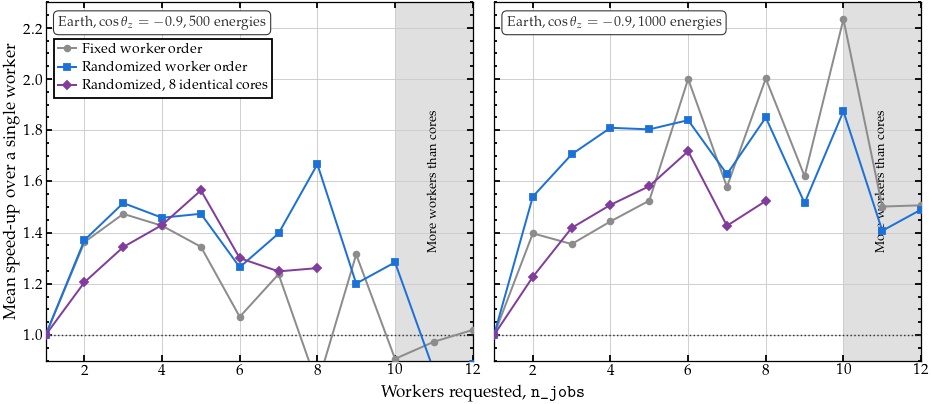

In [55]:
# ------------------------------------------------ what a parallel speed-up depends on
# The same knob on the two scans too short to time on this machine, measured three ways.
# The point of the panel is the spread between the three, not any one curve: at these
# sizes a round lasts a few tenths of a second, and the protocol moves the answer by as
# much as the worker count does.
PROTOCOLS = (('fixed order', '-o', '0.55', 'Fixed worker order'),
             ('randomised', '-s', BLUE, 'Randomized worker order'),
             ('pinned', '-D', PURPLE, 'Randomized, 8 identical cores'))
# The arm names are the keys the generator wrote, British spelling and all; the labels
# above are what the figure says.
PANELS = ((500, {'fixed order': '500 points, fixed order',
                 'randomised': '500 points, randomised',
                 'pinned': '500 points, pinned'}),
          (1000, {'fixed order': '1000 points, fixed order',
                  'randomised': '1000 points',
                  'pinned': '1000 points, pinned'}))

for n_points, names in PANELS:
    worst = max(max(r['cv'] for r in jobs_rows(a)) for a in names.values())
    print('%5d energies: %.3f s serial, worst cv over the three protocols %.2f'
          % (n_points, jobs_rows(names['randomised'])[0]['mean_seconds'], worst))

fig, axes = plt.subplots(1, 2, figsize=(WIDE, 3.0), sharey=True)
for ax, (n_points, names) in zip(axes, PANELS):
    workers_panel(ax)
    for key, marker, color, label in PROTOCOLS:
        rows = jobs_rows(names[key])
        ax.plot([r['n_jobs'] for r in rows], [r['speedup'] for r in rows], marker,
                color=color, ms=3.2, lw=1.1, zorder=4, label=label)
    # Starts at 0.9, so the fixed-order curve leaves the panel where it drops below one.
    # That is where it is worst, and the point of the panel; the caption says so.
    ax.set_ylim(0.9, 2.3)
    corner = corner_label(ax, r'Earth, $\cos\theta_z = %.1f$, $%d$ energies'
                              % (JOBS['costhz'], n_points))
    if ax is axes[0]:
        left_corner = corner
    ax.set_xlabel('')
axes[0].set_ylabel(r'Mean speed-up over a single worker', labelpad=2.0)
fig.tight_layout(pad=0.4)
# One label for two panels that share an axis, centred on the pair rather than on the
# figure: the y label widens the figure on the left, so figure centre reads as off-centre
# under the data.  Both the gap to the tick labels and the centre are measured, because
# closing the gap between the panels moves them.
fig.subplots_adjust(wspace=0.05)
fig.canvas.draw()
_bottom = min(t.get_window_extent(fig.canvas.get_renderer()).y0
              for ax in axes for t in ax.get_xticklabels() if t.get_text())
fig.supxlabel(r'Workers requested, \texttt{n\_jobs}', va='top',
              fontsize=plt.rcParams['axes.labelsize'],
              x=0.5*(axes[0].get_position().x0 + axes[1].get_position().x1),
              y=_bottom/fig.bbox.height - 0.04/fig.get_size_inches()[1])
LEFT2, BELOW2 = border_of(axes[0], left_corner)
leg2 = axes[0].legend(loc='upper left', bbox_to_anchor=(LEFT2, BELOW2), fontsize=7.8,
                      handlelength=1.3, handletextpad=0.4, labelspacing=0.3,
                      borderaxespad=0.0)
legend_at(axes[0], leg2, LEFT2, BELOW2 - 0.012)
save(fig, 'njobs_protocol.pdf')

## What was written

Every figure in `resources/paper/main.tex`, as a PDF.

```bash
python notebooks/make_notebooks.py --only 28
```

In [56]:
for name in sorted(p.name for p in FIGDIR.glob('*.pdf')):
    print('  %-28s %8.1f kB' % (name, (FIGDIR/name).stat().st_size/1024.0))

  architecture.pdf                205.8 kB
  astro_composition.pdf           210.7 kB
  astro_ternary.pdf               166.8 kB
  biprobability.pdf               190.9 kB
  bsm.pdf                         195.3 kB
  cavity.pdf                      171.3 kB
  cavity_sweep.pdf                390.2 kB
  density_arrangement.pdf         169.9 kB
  earth_oscillogram.pdf          1015.8 kB
  geoneutrino_energy.pdf          304.0 kB
  geoneutrino_flux.pdf            202.2 kB
  geoneutrinos.pdf                107.3 kB
  jet.pdf                         201.9 kB
  layers.pdf                      205.6 kB
  named_baselines.pdf             160.9 kB
  njobs_protocol.pdf              216.6 kB
  njobs_scaling.pdf               214.4 kB
  nu_nubar_earth.pdf              196.0 kB
  phase_vs_profile.pdf            225.0 kB
  prem_profile.pdf                199.5 kB
  prob_vs.pdf                    1928.5 kB
  shock_cost.pdf                  174.3 kB
  shock_energy.pdf                156.6 kB
  shock_pro

---

**Previous:** [Animated scenes](27_magnus_animations.ipynb)  
**Next:** [Pseudo-Dirac neutrinos](29_magnus_pseudo_dirac.ipynb) --- tiny splittings, coherent blocks, and where the effect is invisible  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Documentation](https://mbustama.github.io/Magnus/) &middot; [All notebooks](.)